# Thalmann z=3 — results
Individual-difference IDRNN (z=3) vs dimension-matched Vanilla, across tasks (2-armed + restless; horizon held out). Two canonical models: **S1** (`thalmann_z3_full`) and **pooled S1+S2** (`thalmann_z3_s2_full`). Panel a (held-out NLL) is from the S1 nested-CV.

In [6]:

# === thalmann results — shared setup (palette / fonts / helpers) ===
import os, json, glob, logging
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearsonr
from cycler import cycler
from matplotlib.colors import to_rgb, to_hex
try:
    from pingouin import bayesfactor_ttest, bayesfactor_pearson
except Exception:
    bayesfactor_ttest = bayesfactor_pearson = None
from nature_plot_style import nature_colors
matplotlib.set_loglevel("error")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams.update({
    "pdf.fonttype": 42, "font.family": "sans-serif",
    "font.sans-serif": ["Nimbus Sans", "DejaVu Sans"],
    "font.size": 7, "axes.titlesize": 8, "axes.titleweight": "bold",
    "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7, "legend.frameon": False, "axes.linewidth": 1,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": cycler("color", [
        "#dd9e9e", "#D04C4C", "#f59e57", "#6f6484", "#101e41", "#fccc9b", "#666666",
    ]),
})
MM = 1 / 25.4
W_FULL   = 180 * MM   # 7.087 in — full page width (hard max)
W_SINGLE = 89  * MM   # 3.504 in — single column

# constrained_layout fits everything WITHIN the figsize instead of overflowing it
plt.rcParams["figure.constrained_layout.use"] = True

def save_fig(fig, path, dpi=600, max_mm=180):
    """Save at the fig's exact size (no tight-crop) and assert the width cap."""
    w_in, h_in = fig.get_size_inches()
    assert w_in * 25.4 <= max_mm + 0.5, f"{w_in*25.4:.1f} mm > {max_mm} mm: {path}"
    fig.savefig(path, dpi=dpi)          # NO bbox_inches="tight"

def lighten(color, amount=0.5):
    c = np.array(to_rgb(color)); white = np.array([1, 1, 1])
    return to_hex(c + (white - c) * amount)

# Palette mirrors synthetic_publication_panels.ipynb (Nature style, manual hexes).
# Light/dark pairings (CP=light, EM=dark) preserved so panel-a pairs read.
COL_Q_EM       = "#6f64842c"                       # dark grey-blue  (ill-spec EM)
COL_Q_CP       = lighten(COL_Q_EM, 0.4)            # light grey-blue (ill-spec CP)
COL_FQ_CP      = "#dd9e9e"                          # light red       (cog model CP)
COL_FQ_EM      = "#D04C4C"                          # mid-dark red    (cog model EM)
COL_IDRNN      = "#132551"                          # nature navy     (IDRNN)
COL_RNN_CP     = lighten(COL_IDRNN, 0.2)            # light blue      (CP RNN)
COL_IDRNN_H    = nature_colors['Blue'][2]           # mid blue        (IDRNN h)
COL_VANILLA    = "#f59e57"                          # nature orange   (Vanilla)
COL_VAN_H      = "#fccc9b"                           # light orange    (Vanilla+h)
COL_VAN_H_LAST = nature_colors['Skin tones'][1]     # light brown     (Vanilla+h last)
COL_TRUE       = nature_colors['Grey'][5]           # near-black

def fmt_bf(bf):
    if bf is None or not np.isfinite(bf): return "—"
    return f"{bf:.1e}" if bf >= 1000 else (f"{bf:.1f}" if bf >= 10 else f"{bf:.2f}")

def paired_bf(a, b):
    """JZS BF for a paired difference (a vs b), aligned by row, NaNs dropped."""
    a = np.asarray(a, float); b = np.asarray(b, float); m = np.isfinite(a) & np.isfinite(b)
    if bayesfactor_ttest is None or m.sum() < 3: return float("nan")
    t = stats.ttest_rel(a[m], b[m]).statistic
    return float(bayesfactor_ttest(t, int(m.sum()), paired=True))

def bracket(ax, x1, x2, y, h, txt):
    ax.plot([x1, x2], [y + h, y + h], lw=0.5, c="black")
    ax.text((x1 + x2) / 2, y + h * 1.1, txt, ha="center", va="bottom", fontsize=6)



## Panel a — held-out NLL per participant
Per-fold nested-CV, seed-averaged. Held-out NLL uses the **marginalized + causal** likelihood (`compute_rnn_likelihoods_torch`: z inferred causally from data up to trial t and integrated over q(z|x)) — matching the synthetic pipeline, **not** the `model(xin,xin)` point estimate (which understated the latent). Paired Bayes factors over held-out participants; CP-RNN (z=0) vs IDRNN tests the held-out latent benefit; RNNs ≫ cog models.

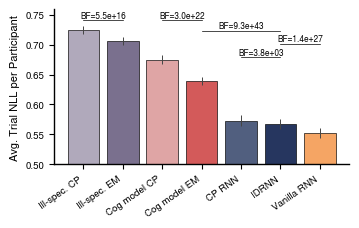

NLL per trial: {'nll_ill_cp': 0.7251, 'nll_ill_em': 0.7065, 'nll_cog_cp': 0.6753, 'nll_cog_em': 0.6394, 'nll_cp_rnn_all': 0.5728, 'nll_idrnn_all': 0.5669, 'nll_vanilla_all': 0.5521} | chance 0.9704
BF  ill-CP/EM=BF=5.5e+16  cog-CP/EM=BF=3.0e+22  CP-RNN/IDRNN=BF=3.8e+03  Van/IDRNN=BF=1.4e+27  cogEM/IDRNN=BF=9.3e+43


In [4]:
# === panel a — held-out NLL per participant (marginalized+causal eval; matches synthetic panel a) ===
# Held-out NLL via compute_rnn_likelihoods_torch (causal: z from data up to t; marginalized over
# q(z|x)), per-trial. Chance = trial-weighted uniform: 2-armed -> log2, restless -> log4, weighted
# by each task's valid-trial share (tasks differ in #actions). Paired Bayes factors over participants.
NLL_CSV = "final_plots/thalmann_z3_s2_pooled/per_participant_nll_marginal.csv"
df = pd.read_csv(NLL_CSV)

# trial-weighted chance from the held-out valid-trial counts
tid = np.load("data_thalmann_s2/task_ids_per_block.npy")
nt0 = nt1 = 0.0
for _f in range(3):
    _c = np.load(f"data_thalmann_s2/fold{_f}/c_test.npy"); _v = (_c >= 0)
    nt0 += _v[:, tid == 0].sum(); nt1 += _v[:, tid == 1].sum()
chance = float((nt0 * np.log(2) + nt1 * np.log(4)) / (nt0 + nt1))

cog_keys = [("nll_ill_cp", "Ill-spec. CP", COL_Q_CP), ("nll_ill_em", "Ill-spec. EM", COL_Q_EM),
            ("nll_cog_cp", "Cog model CP", COL_FQ_CP), ("nll_cog_em", "Cog model EM", COL_FQ_EM),
            ("nll_cp_rnn_all", "CP RNN", COL_RNN_CP), ("nll_idrnn_all", "IDRNN", COL_IDRNN),
            ("nll_vanilla_all", "Vanilla RNN", COL_VANILLA)]
keys   = [k for k, _, _ in cog_keys]
labels = [l for _, l, _ in cog_keys]
cols   = [c for _, _, c in cog_keys]
means  = [df[k].mean() for k in keys]
sems   = [stats.sem(df[k].dropna()) for k in keys]
xs     = np.arange(len(labels))

bf_Q  = paired_bf(df["nll_ill_cp"],  df["nll_ill_em"])
bf_FQ = paired_bf(df["nll_cog_cp"],  df["nll_cog_em"])
bf_RNNCP_IDRNN = paired_bf(df["nll_cp_rnn_all"],  df["nll_idrnn_all"])
bf_Van_IDRNN   = paired_bf(df["nll_vanilla_all"], df["nll_idrnn_all"])
bf_IDRNN_FQ_EM = paired_bf(df["nll_cog_em"],      df["nll_idrnn_all"])

fig, ax = plt.subplots(figsize=(3.6, 2.3))
ax.bar(xs, means, color=cols, alpha=0.92, edgecolor="black", linewidth=0.5, zorder=2)
ax.errorbar(xs, means, yerr=sems, fmt="none", ecolor="#444444", elinewidth=0.7, capsize=0, zorder=3)
ax.axhline(chance, ls=":", color=COL_TRUE, lw=1.2, zorder=1)
#ax.text(len(labels) - 0.45, chance-0.02, " chance", va="center", ha="left", fontsize=6, color=COL_TRUE)
ymax = max(means) + max(sems); h_step = 0.05 * (chance - min(means)); yb = ymax + h_step
bracket(ax, 0, 1, yb-0.02,                 h_step * 0.3, fmt_bf(bf_Q))
bracket(ax, 2, 3, yb-0.02,                 h_step * 0.3, fmt_bf(bf_FQ))
bracket(ax, 4, 5, yb-3*h_step-0.02,                 h_step * 0.3, fmt_bf(bf_RNNCP_IDRNN))
bracket(ax, 5, 6, yb-h_step * 1.9-0.02,  h_step * 0.3, fmt_bf(bf_Van_IDRNN))
bracket(ax, 3, 5, yb -0.85 * h_step-0.02, h_step * 0.3, fmt_bf(bf_IDRNN_FQ_EM))
ax.set_xticks(xs); ax.set_xticklabels(labels, rotation=35, ha="right")
ax.set_ylabel("Avg. Trial NLL per Participant")
ax.set_ylim(bottom=0.5, top=0.76)#chance + h_step * 1.7) #
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("final_plots/thalmann_z3_s2_pooled/panel_a_heldout_nll.png", dpi=600, bbox_inches="tight")
plt.savefig("final_plots/thalmann_z3_s2_pooled/panel_a_heldout_nll.pdf", dpi=600, bbox_inches="tight")
plt.show()
print("NLL per trial:", {k: round(df[k].mean(), 4) for k in keys}, "| chance", round(chance, 4))
print(f"BF  ill-CP/EM={fmt_bf(bf_Q)}  cog-CP/EM={fmt_bf(bf_FQ)}  CP-RNN/IDRNN={fmt_bf(bf_RNNCP_IDRNN)}  "
      f"Van/IDRNN={fmt_bf(bf_Van_IDRNN)}  cogEM/IDRNN={fmt_bf(bf_IDRNN_FQ_EM)}")

## Panel a (robustness) — per-seed NLL
Marginalized held-out NLL is **stable across retrain seeds** (consistent ordering Vanilla < IDRNN < CP-RNN), so panel a is not a single-seed artifact. The latent's *predictive* benefit (CP-RNN − IDRNN) is **positive but small** (mean ≈ +0.006 NLL, positive in 4/5 seeds). The inferential test is the **participant-level** paired BF in panel a (BF ≈ 3.8e3, decisive); the seed-level n is too small to test on its own. Bottom line: the held-out latent helps choice prediction reliably but modestly — its larger value is representational.

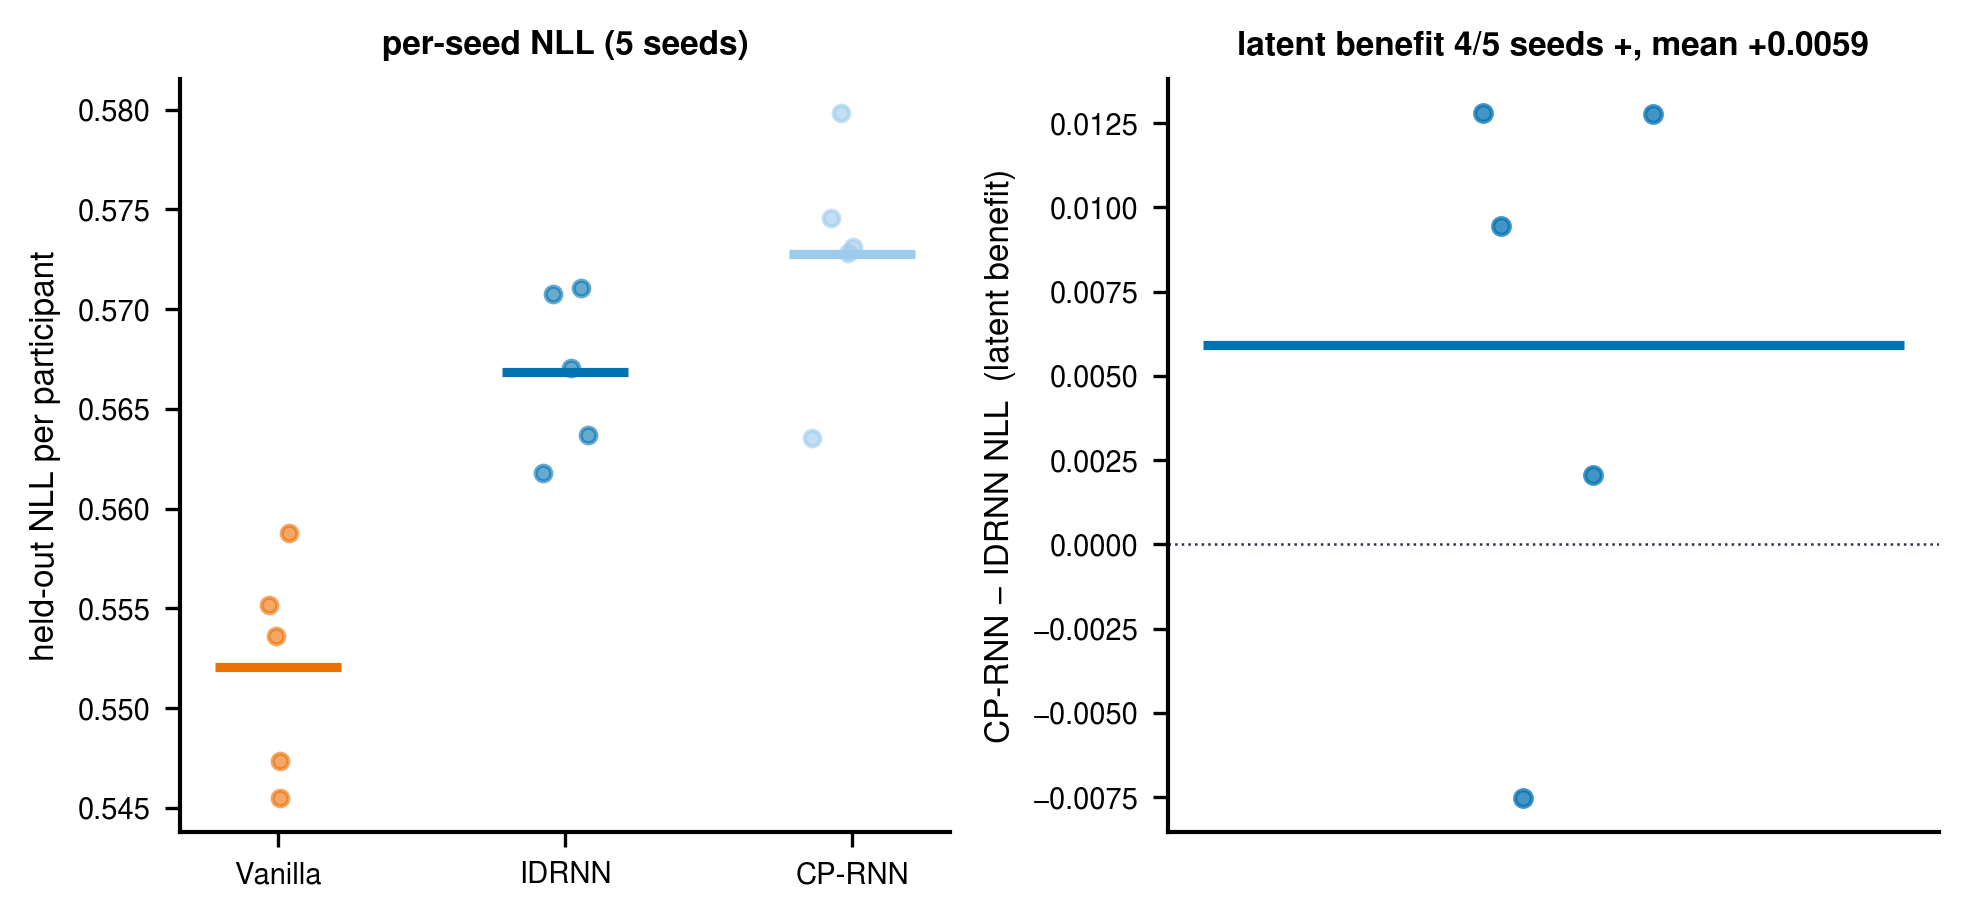

In [ ]:
# === panel a-seeds — per-seed held-out NLL robustness + latent benefit ===
# (a) NLL is stable across the 15 retrain seeds -> panel-a is not a single-seed artifact.
# (b) latent benefit = CP-RNN(z=0) - IDRNN per seed: small but consistently positive.
from scipy import stats
df = pd.read_csv("final_plots/thalmann_z3_s2_pooled/per_seed_nll_marginal.csv")
bf_seed = paired_bf(df["cp_rnn"], df["idrnn"])          # seed-level: does latent help on average?
n_pos = int((df["cp_rnn"] > df["idrnn"]).sum())
rng = np.random.default_rng(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.6, 3.1))
for j, (k, c, lab) in enumerate([("vanilla", COL_VANILLA, "Vanilla"),
                                 ("idrnn", COL_IDRNN, "IDRNN"),
                                 ("cp_rnn", COL_RNN_CP, "CP-RNN")]):
    ax1.scatter(np.full(len(df), j) + rng.normal(0, 0.06, len(df)), df[k], s=14, color=c, alpha=.6, zorder=2)
    ax1.hlines(df[k].mean(), j - 0.22, j + 0.22, color=c, lw=2.2, zorder=3)
ax1.set_xticks([0, 1, 2]); ax1.set_xticklabels(["Vanilla", "IDRNN", "CP-RNN"])
ax1.set_ylabel("held-out NLL per participant"); ax1.set_title(f"per-seed NLL ({len(df)} seeds)")

ax2.axhline(0, color=COL_TRUE, lw=.6, ls=":")
ax2.scatter(rng.normal(0, 0.06, len(df)), df["cp_minus_idrnn"], s=16, color=COL_IDRNN, alpha=.75, zorder=2)
ax2.hlines(df["cp_minus_idrnn"].mean(), -0.22, 0.22, color=COL_IDRNN, lw=2.2, zorder=3)
ax2.set_xticks([]); ax2.set_ylabel("CP-RNN − IDRNN NLL  (latent benefit)")
ax2.set_title(f"latent benefit {n_pos}/{len(df)} seeds +, mean {df['cp_minus_idrnn'].mean():+.4f}")
fig.tight_layout()
fig.savefig("final_plots/thalmann_z3_s2_pooled/panel_a_perseed.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"NLL mean(SD) over seeds:  IDRNN {df.idrnn.mean():.4f}({df.idrnn.std():.4f})  "
      f"CP-RNN {df.cp_rnn.mean():.4f}({df.cp_rnn.std():.4f})  Vanilla {df.vanilla.mean():.4f}({df.vanilla.std():.4f})")
print(f"latent benefit (CP-RNN−IDRNN): {df.cp_minus_idrnn.mean():+.4f} ± {df.cp_minus_idrnn.std():.4f}; "
      f"positive {n_pos}/{len(df)} seeds; seed-level {fmt_bf(bf_seed)}")

In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import Image, display, Markdown
MODELS = {'S1 (session 1)':'final_plots/thalmann_z3_full',
          'Pooled S1+S2':'final_plots/thalmann_z3_s2_full'}
COL_I, COL_V = COL_IDRNN, COL_VANILLA
def show(p, w=950):
    display(Image(filename=p, width=w)) if os.path.exists(p) else print('missing:', p)

## 2. Panel b — decodability, two framings
**LOO R² > 0 = genuine out-of-sample signal.** The LOO prediction–target *r* is shown too: its large negatives are the no-information anti-correlation artifact (not signal). IDRNN carries signal on working memory + openness; Vanilla does not.

### S1 (session 1): LOO R² (left) vs LOO pred–target r (right)

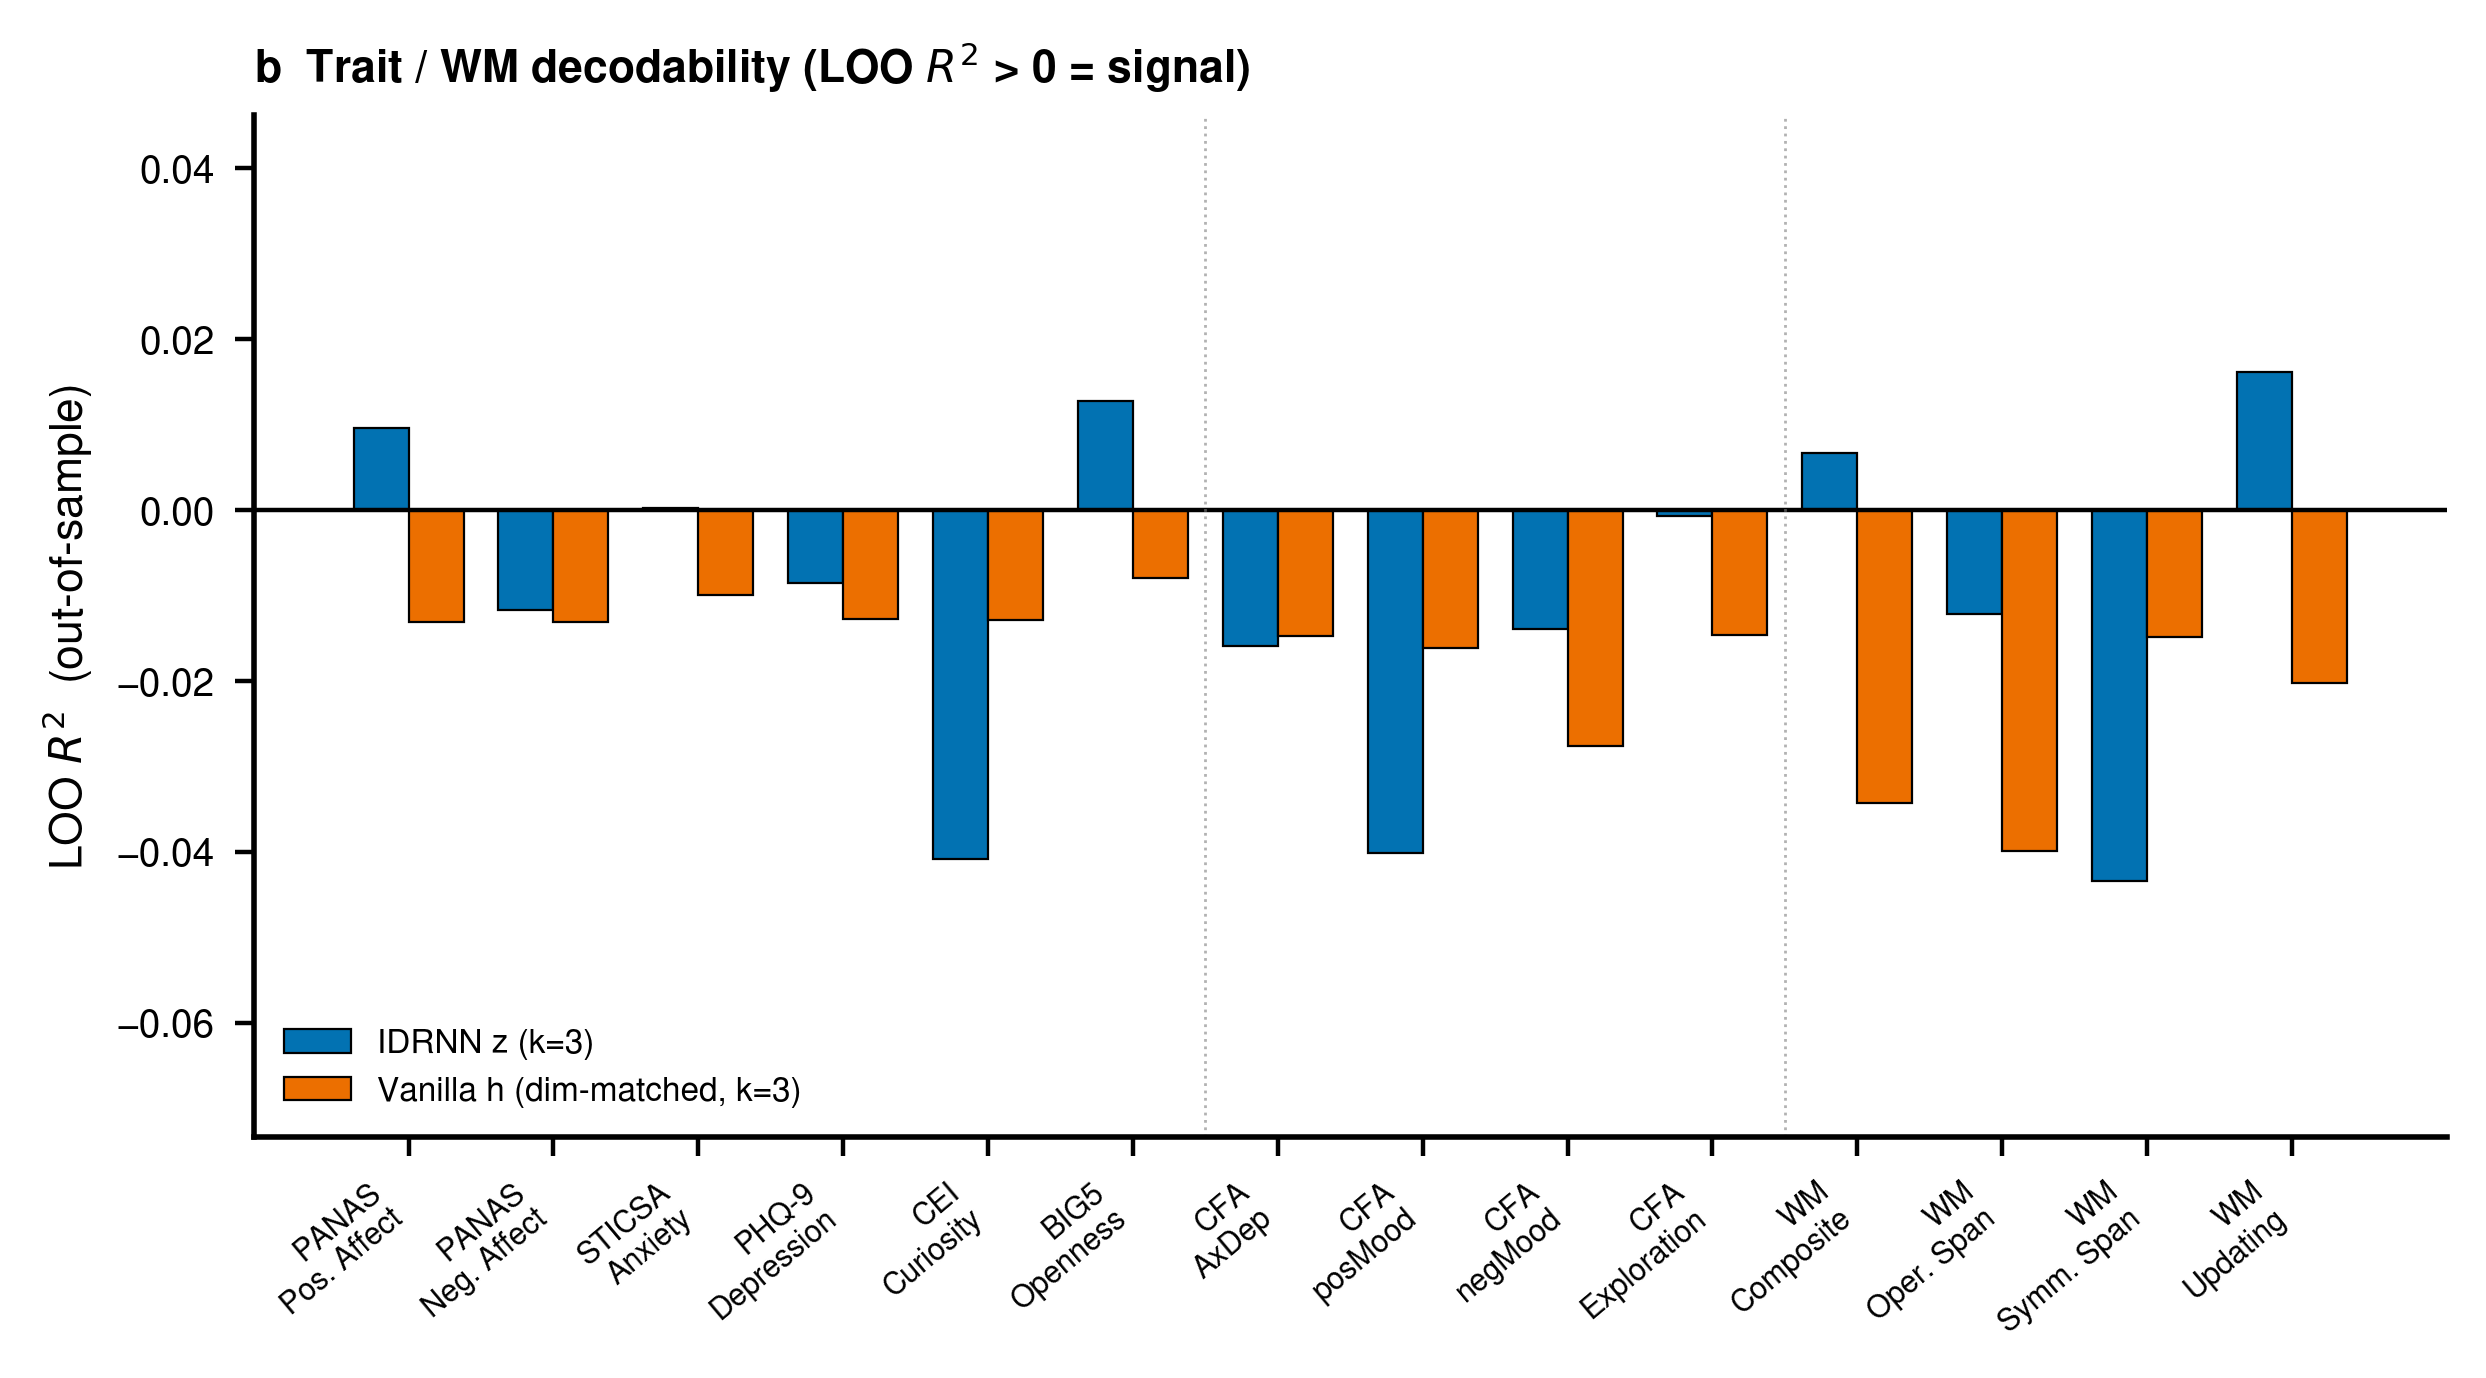

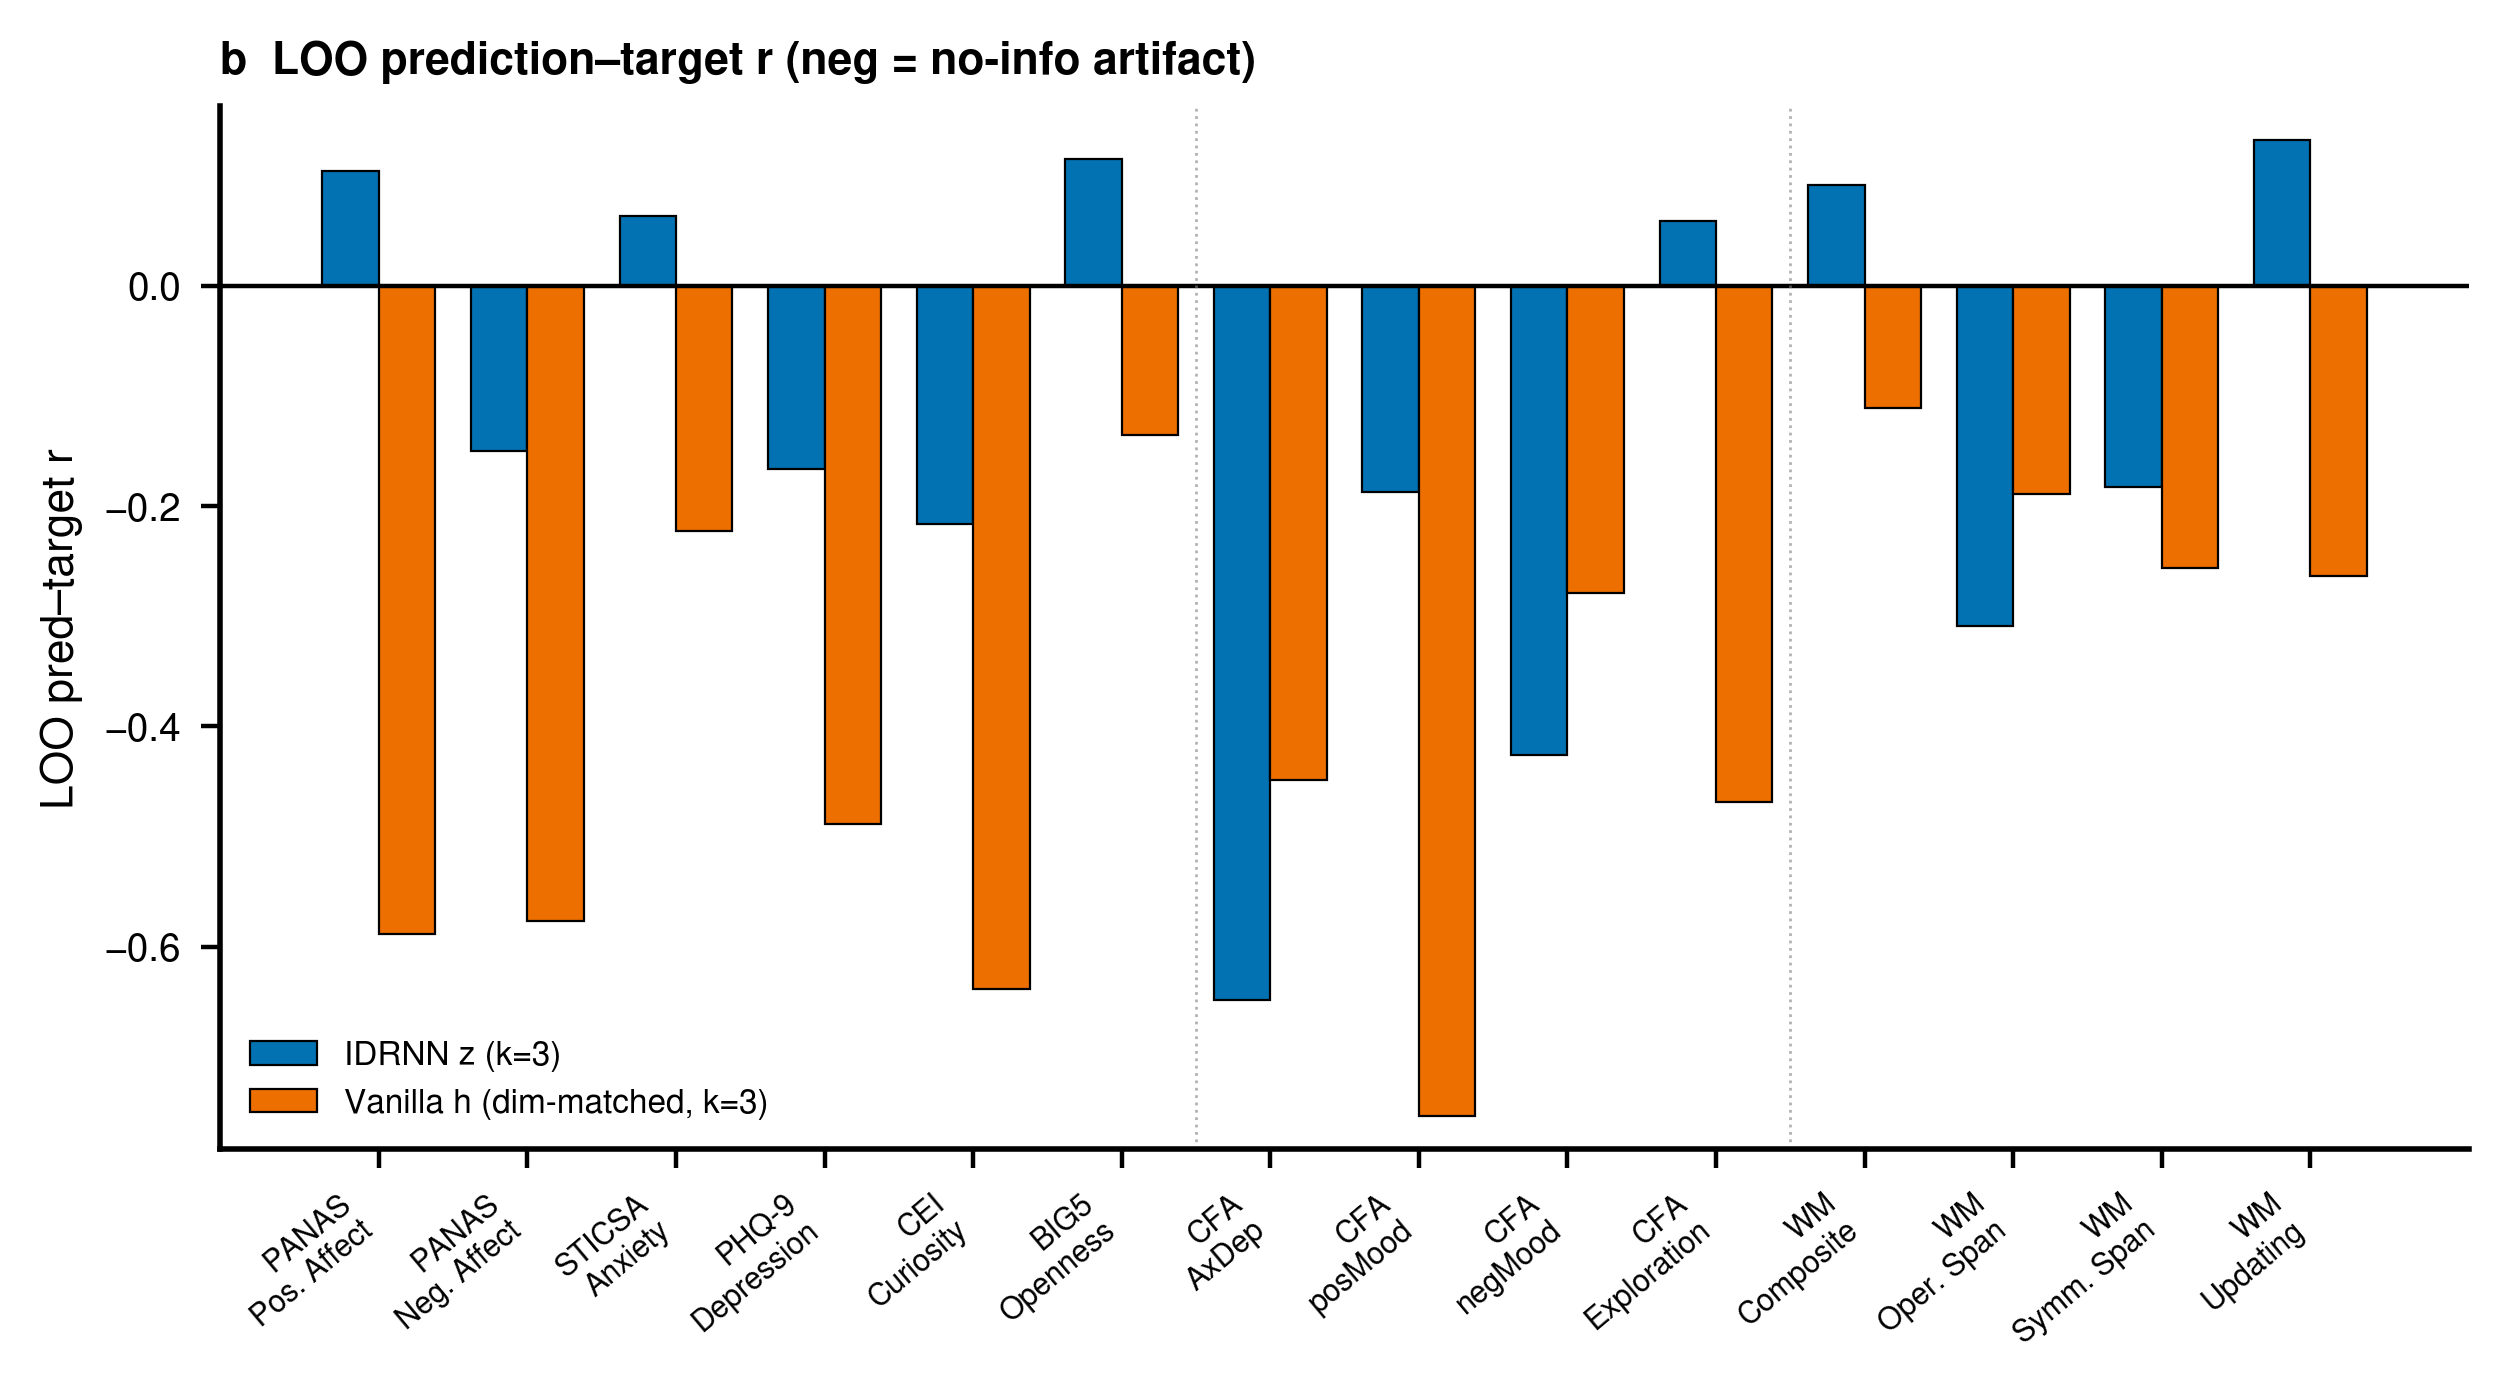

### Pooled S1+S2: LOO R² (left) vs LOO pred–target r (right)

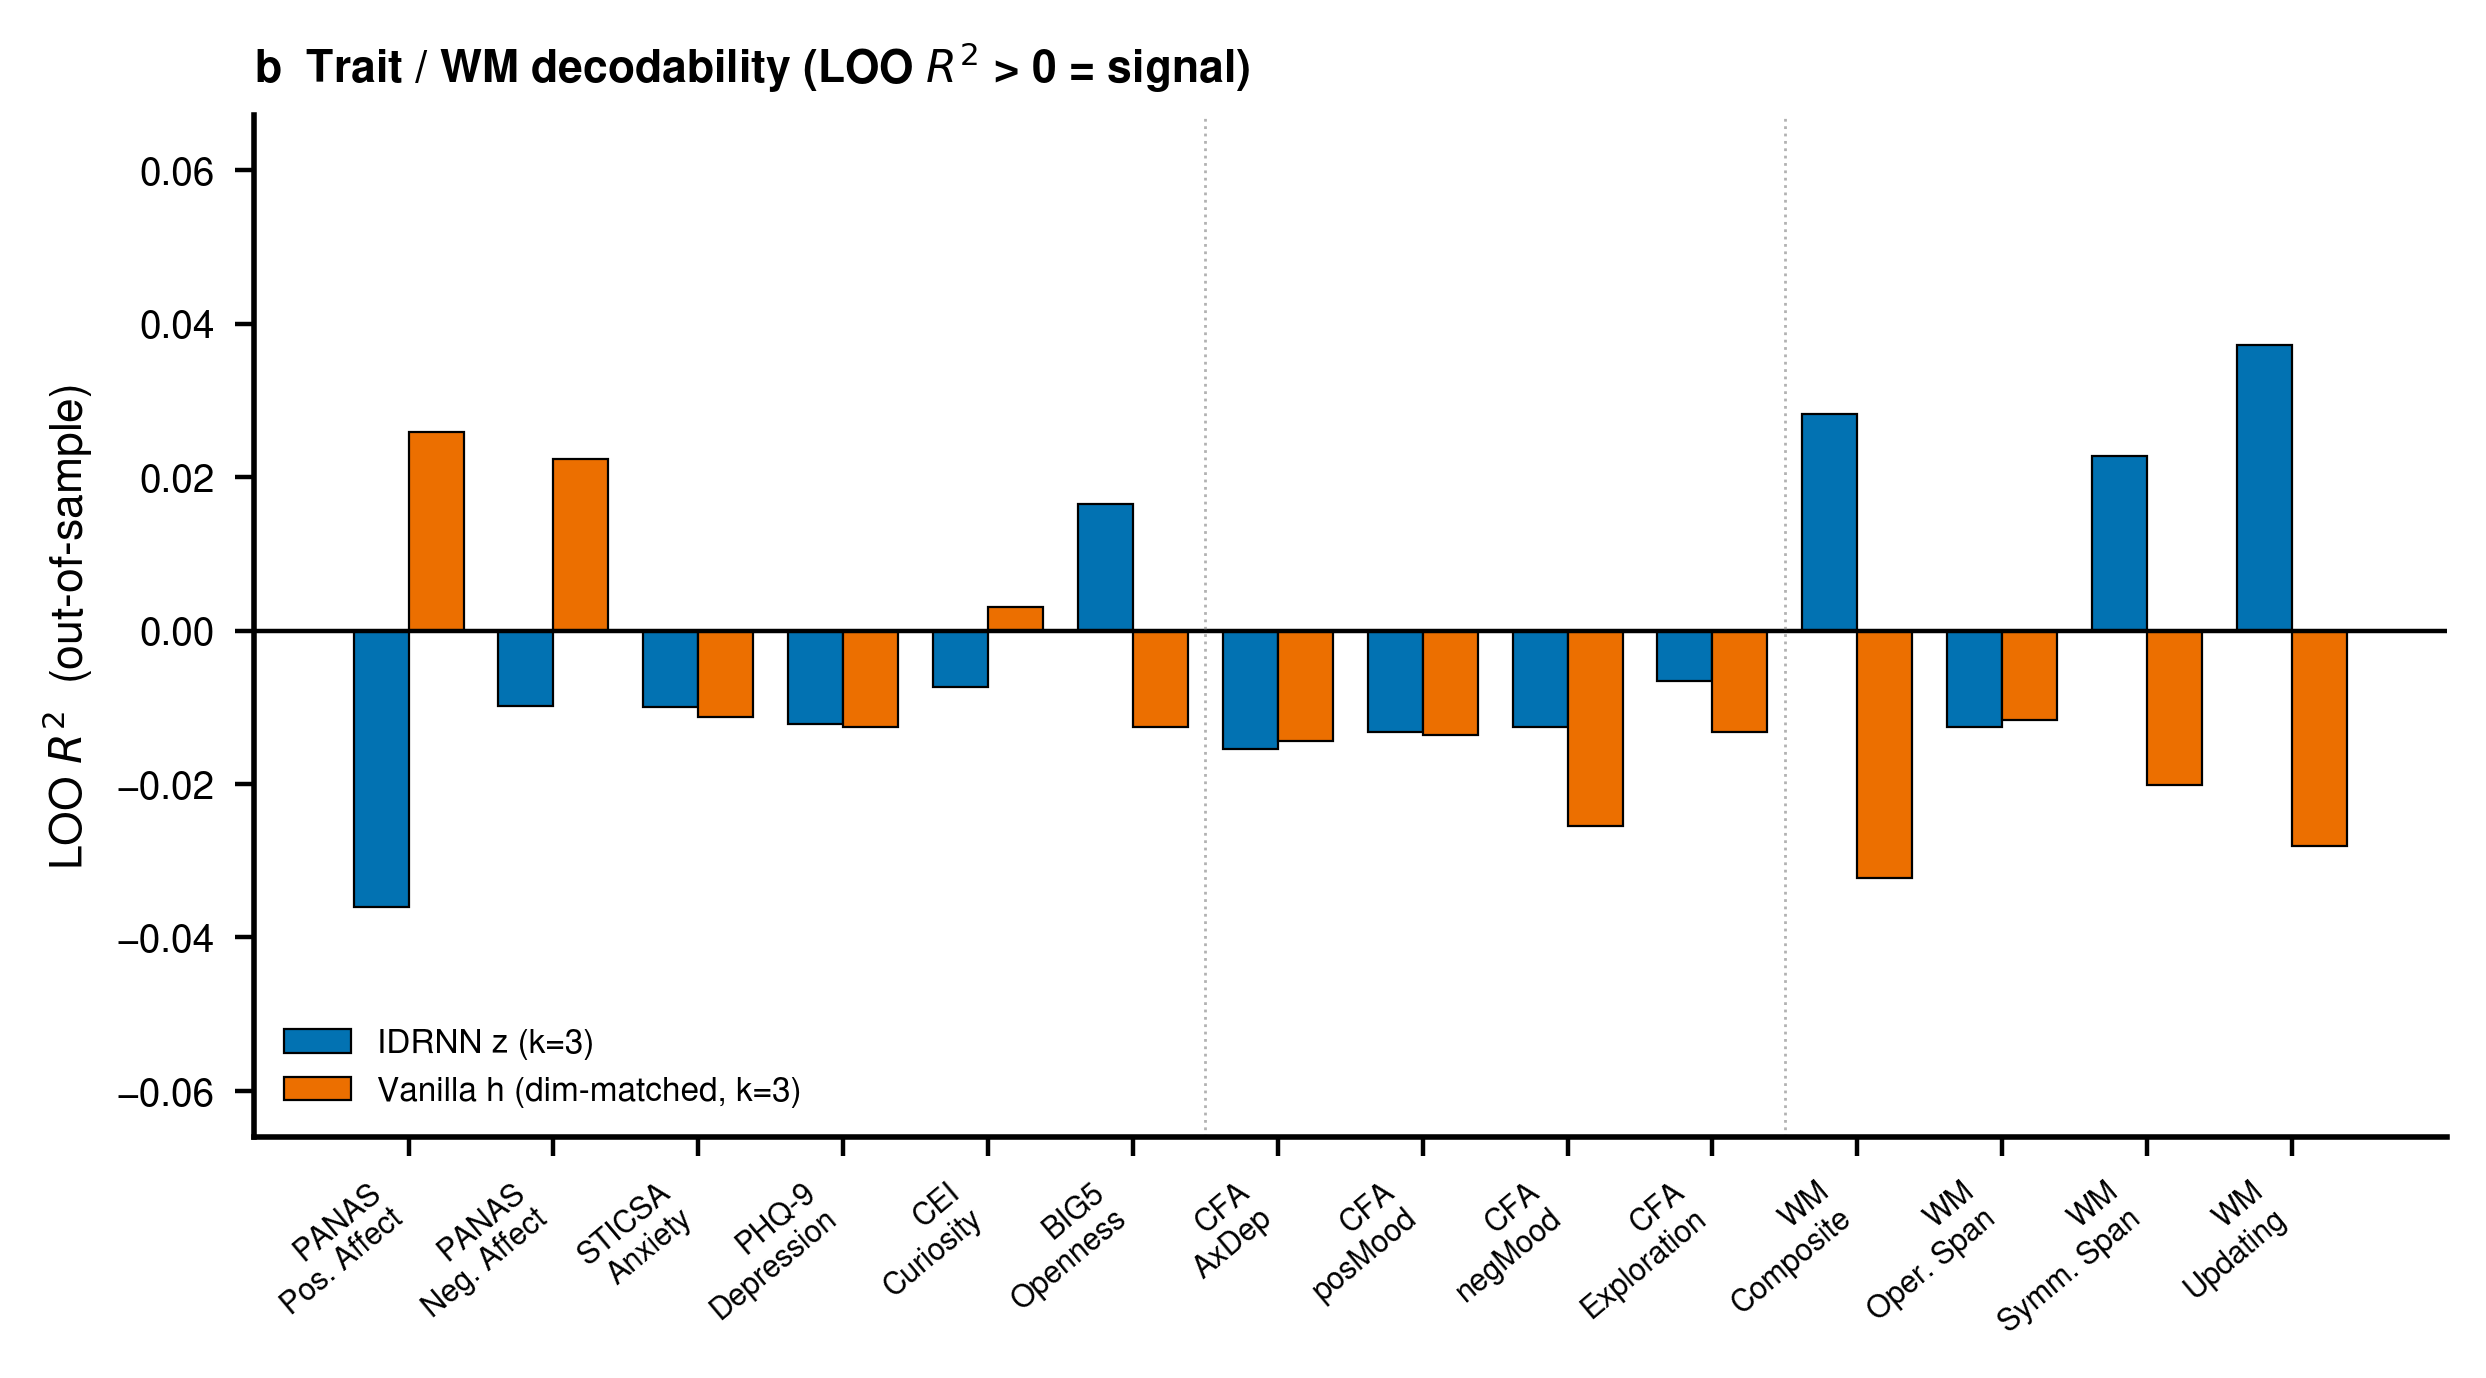

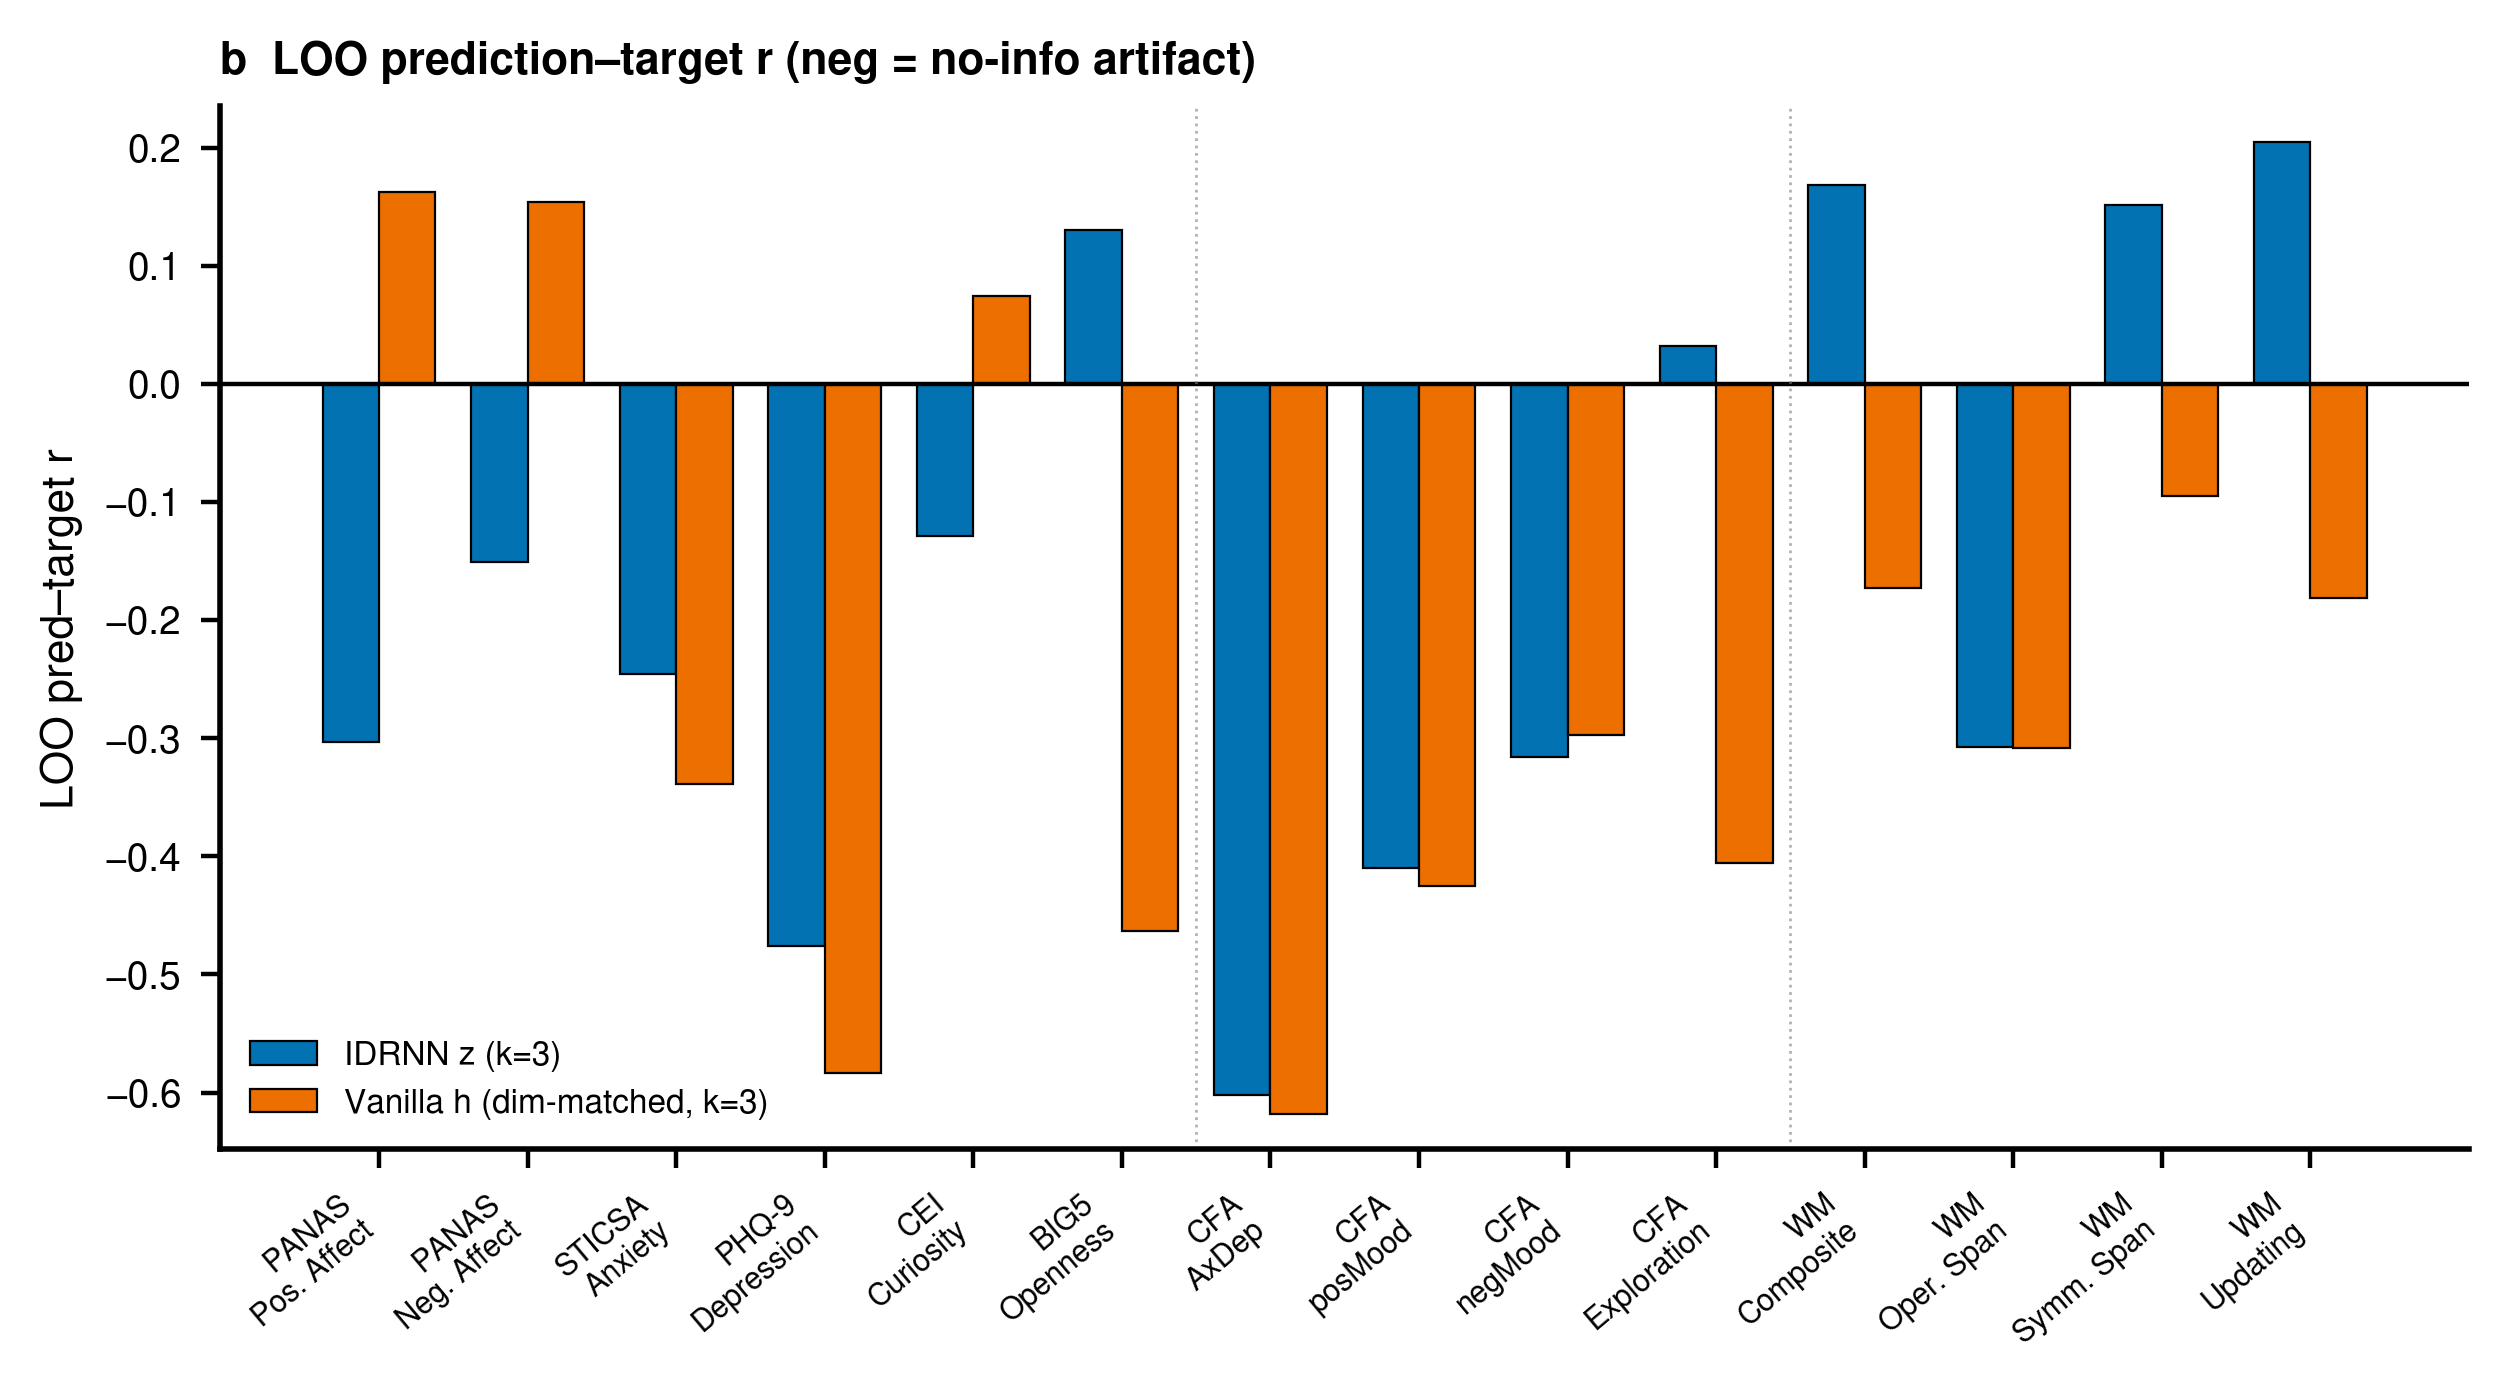

In [3]:
for n,b in MODELS.items():
    display(Markdown(f'### {n}: LOO R² (left) vs LOO pred–target r (right)'))
    show(f'{b}/publication_figure/panel_b_r2.png', 700); show(f'{b}/publication_figure/panel_b_loor.png', 700)

## 3. Seed-averaged decodability (selection-free)
Mean ± SD of LOO R² across 10 seeds of the final model — no seed selection. `frac_pos` = fraction of seeds with R²>0 (robustness).

### S1 (session 1)

,target,idrnn_loo_r2_mean,idrnn_loo_r2_sd,idrnn_frac_pos,vanilla_loo_r2_mean,vanilla_frac_pos
0,PANAS_PA,-0.008,0.015,0.5,-0.013,0.0
1,PANAS_NA,-0.014,0.012,0.1,-0.012,0.0
2,STICSA,-0.006,0.007,0.2,-0.015,0.0
3,PHQ,-0.011,0.001,0.0,-0.012,0.0
4,CEI,-0.011,0.004,0.0,-0.012,0.0
5,BIG5_open,0.014,0.010,0.9,-0.010,0.0
6,AxDep,-0.015,0.002,0.0,-0.015,0.0
7,posMood,-0.025,0.015,0.0,-0.015,0.0
8,negMood,-0.018,0.009,0.0,-0.022,0.0
9,Exp,-0.017,0.019,0.3,-0.014,0.0


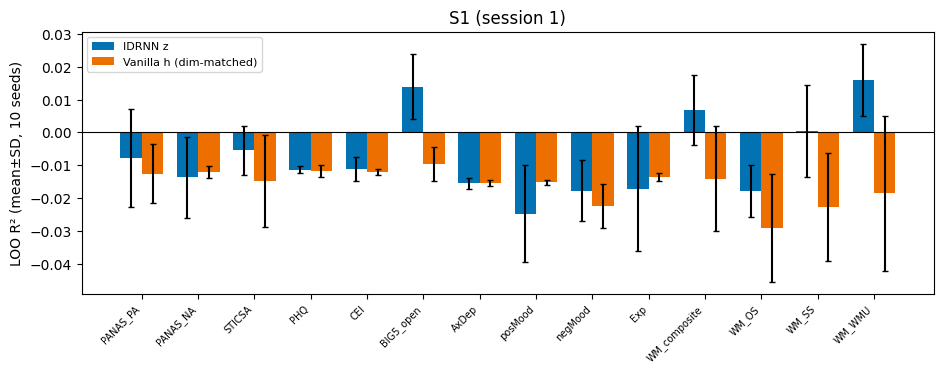

### Pooled S1+S2

,target,idrnn_loo_r2_mean,idrnn_loo_r2_sd,idrnn_frac_pos,vanilla_loo_r2_mean,vanilla_frac_pos
0,PANAS_PA,-0.022,0.015,0.0,0.025,0.9
1,PANAS_NA,-0.009,0.002,0.0,0.021,0.7
2,STICSA,-0.014,0.012,0.0,-0.012,0.0
3,PHQ,-0.011,0.001,0.0,-0.013,0.0
4,CEI,-0.011,0.003,0.0,-0.027,0.2
5,BIG5_open,0.022,0.005,1.0,-0.010,0.0
6,AxDep,-0.016,0.003,0.0,-0.015,0.0
7,posMood,-0.013,0.001,0.0,-0.020,0.0
8,negMood,-0.014,0.001,0.0,-0.024,0.0
9,Exp,-0.017,0.019,0.3,-0.015,0.0


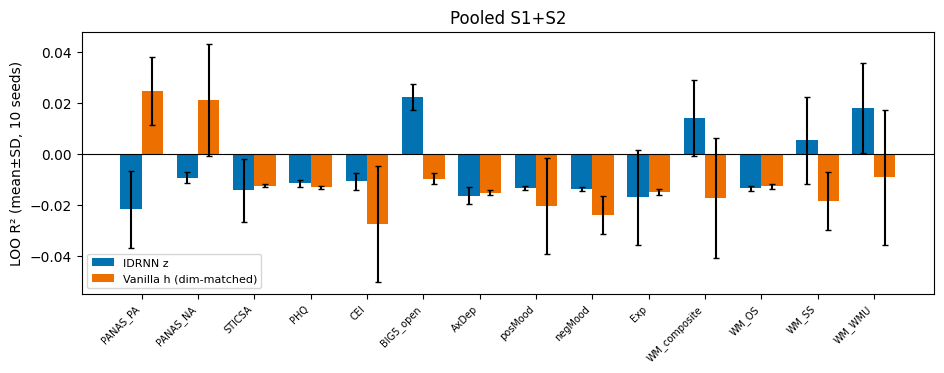

In [4]:
for n,b in MODELS.items():
    df = pd.read_csv(f'{b}/decoding/seed_averaged_decoding.csv')
    display(Markdown(f'### {n}'))
    display(df[['target','idrnn_loo_r2_mean','idrnn_loo_r2_sd','idrnn_frac_pos','vanilla_loo_r2_mean','vanilla_frac_pos']].round(3))
    x=np.arange(len(df)); w=.38; fig,ax=plt.subplots(figsize=(11,3.4))
    ax.bar(x-w/2, df.idrnn_loo_r2_mean, w, yerr=df.idrnn_loo_r2_sd, color=COL_I, capsize=2, label='IDRNN z')
    ax.bar(x+w/2, df.vanilla_loo_r2_mean, w, yerr=df.vanilla_loo_r2_sd, color=COL_V, capsize=2, label='Vanilla h (dim-matched)')
    ax.axhline(0,color='k',lw=.8); ax.set_xticks(x); ax.set_xticklabels(df.target, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('LOO R² (mean±SD, 10 seeds)'); ax.set_title(n); ax.legend(fontsize=8); plt.show()

## 4. IDRNN latent ↔ trait correlations
Direct Pearson/Spearman per z-dimension, multiple-R, and LOO R² (the honest metric).

In [5]:
for n,b in MODELS.items():
    df = pd.read_csv(f'{b}/decoding/idrnn_latent_correlations.csv')
    keep=[c for c in df.columns if any(k in c for k in ['target','pearson_r','spearman_rho','multiple_R','loo_R2'])]
    display(Markdown(f'### {n}')); display(df[keep].round(3))

### S1 (session 1)

,target,z0_pearson_r,z0_spearman_rho,z1_pearson_r,z1_spearman_rho,z2_pearson_r,z2_spearman_rho,multiple_R,loo_R2
0,PANAS_PA,-0.128,-0.124,0.158,0.153,0.028,0.080,0.195,0.010
1,PANAS_NA,-0.093,-0.097,0.095,0.094,0.060,0.105,0.140,-0.012
2,STICSA,0.075,0.065,-0.164,-0.159,0.022,0.037,0.174,0.000
3,PHQ,0.028,0.025,-0.114,-0.127,-0.043,0.013,0.126,-0.009
4,CEI,0.080,0.060,0.112,0.079,-0.004,-0.009,0.147,-0.041
5,BIG5_open,-0.013,-0.066,0.102,0.071,0.168,0.157,0.207,0.013
6,AxDep,-0.001,-0.007,-0.059,-0.060,-0.006,0.066,0.061,-0.016
7,posMood,-0.004,0.020,0.165,0.153,-0.001,0.032,0.165,-0.040
8,negMood,-0.078,-0.065,-0.042,-0.051,0.027,0.186,0.091,-0.014
9,Exp,0.120,0.132,0.152,0.152,0.007,-0.031,0.197,-0.001


### Pooled S1+S2

,target,z0_pearson_r,z0_spearman_rho,z1_pearson_r,z1_spearman_rho,z2_pearson_r,z2_spearman_rho,multiple_R,loo_R2
0,PANAS_PA,-0.071,-0.078,-0.018,0.003,-0.109,-0.099,0.143,-0.036
1,PANAS_NA,-0.008,-0.025,0.004,0.024,-0.135,-0.129,0.138,-0.010
2,STICSA,0.085,0.107,0.050,0.046,0.016,0.006,0.107,-0.010
3,PHQ,0.040,0.080,0.040,0.038,0.002,-0.023,0.060,-0.012
4,CEI,0.024,0.005,-0.090,-0.046,0.092,0.078,0.123,-0.007
5,BIG5_open,0.088,0.081,-0.073,-0.013,-0.181,-0.196,0.217,0.017
6,AxDep,0.058,0.065,0.002,-0.008,-0.028,-0.054,0.061,-0.015
7,posMood,-0.032,-0.005,-0.092,-0.068,-0.031,-0.031,0.110,-0.013
8,negMood,0.044,0.085,0.046,0.033,-0.097,-0.181,0.108,-0.013
9,Exp,0.035,0.021,-0.157,-0.148,0.102,0.124,0.184,-0.007


## 5. Panel e — generative cross-task regret (R1→R4)
R1 human · R2 exact-env single-seed · R3 exact-env marg-RNG · R4 marg-env+RNG. Marginalisation recovers the transfer signal the single exact rollout misses.

### S1 (session 1)

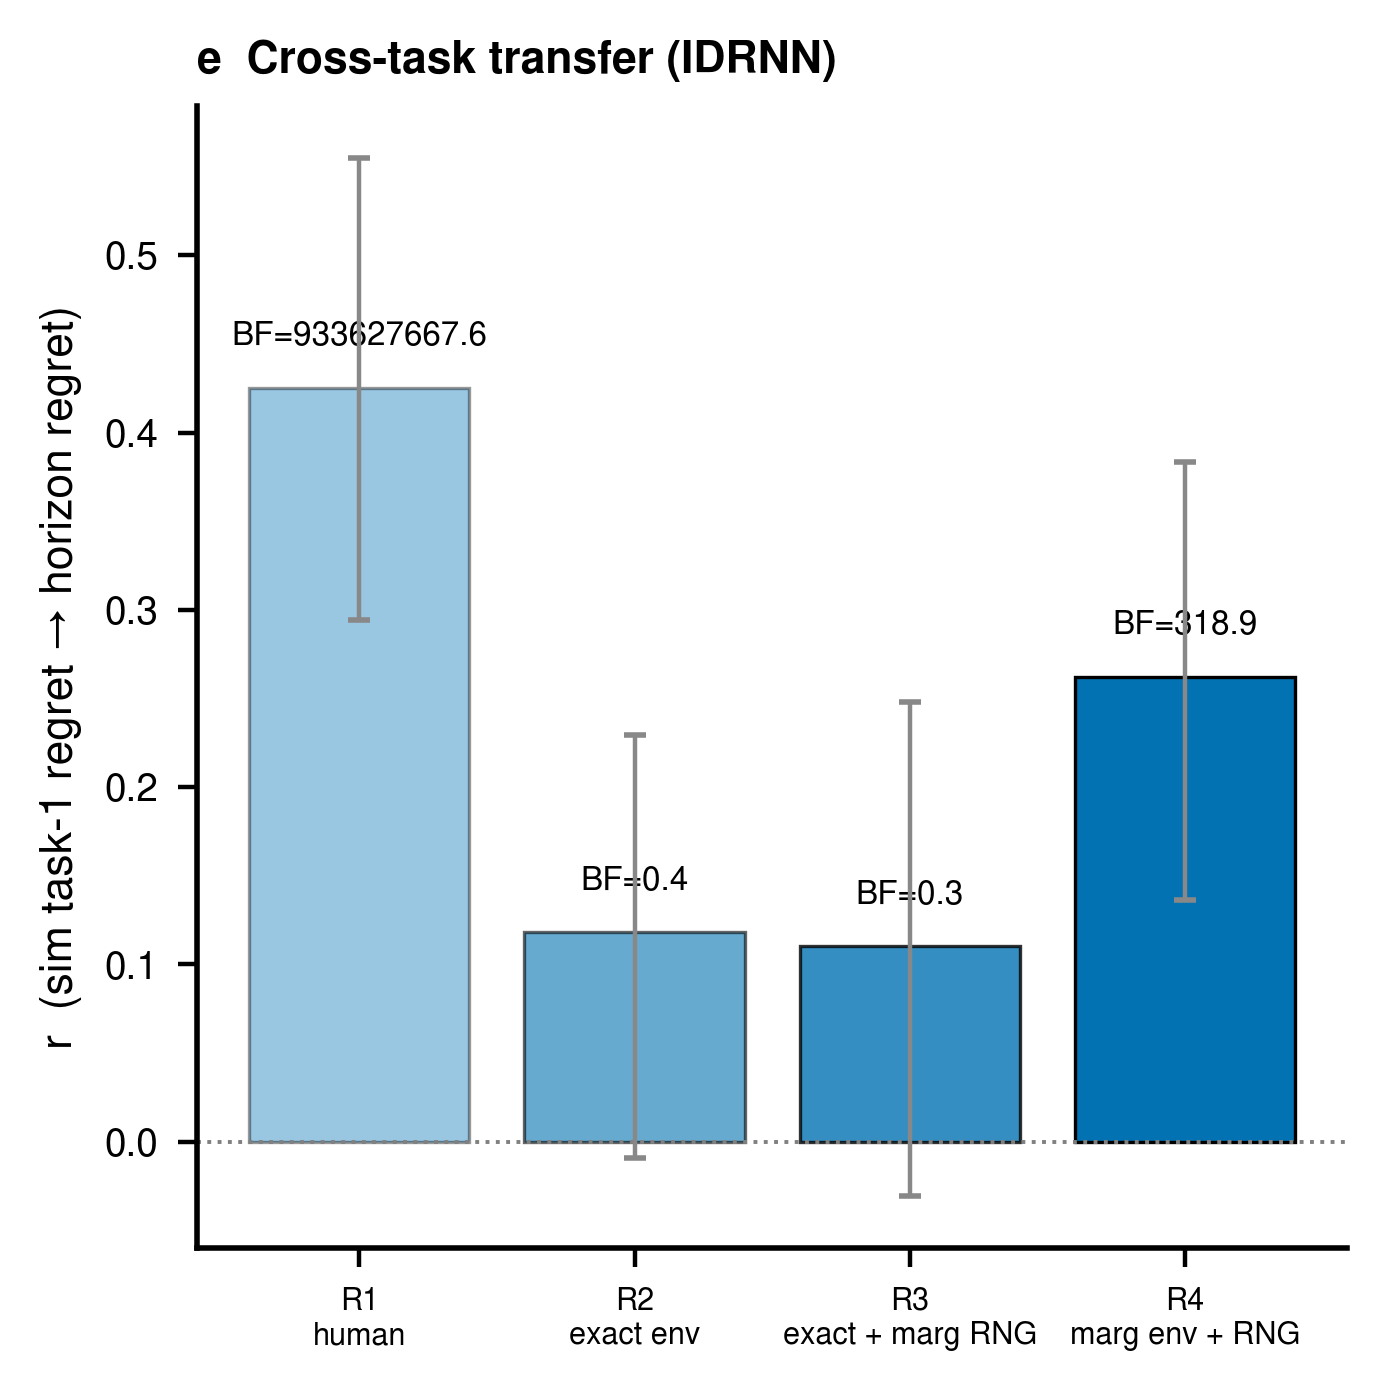

### Pooled S1+S2

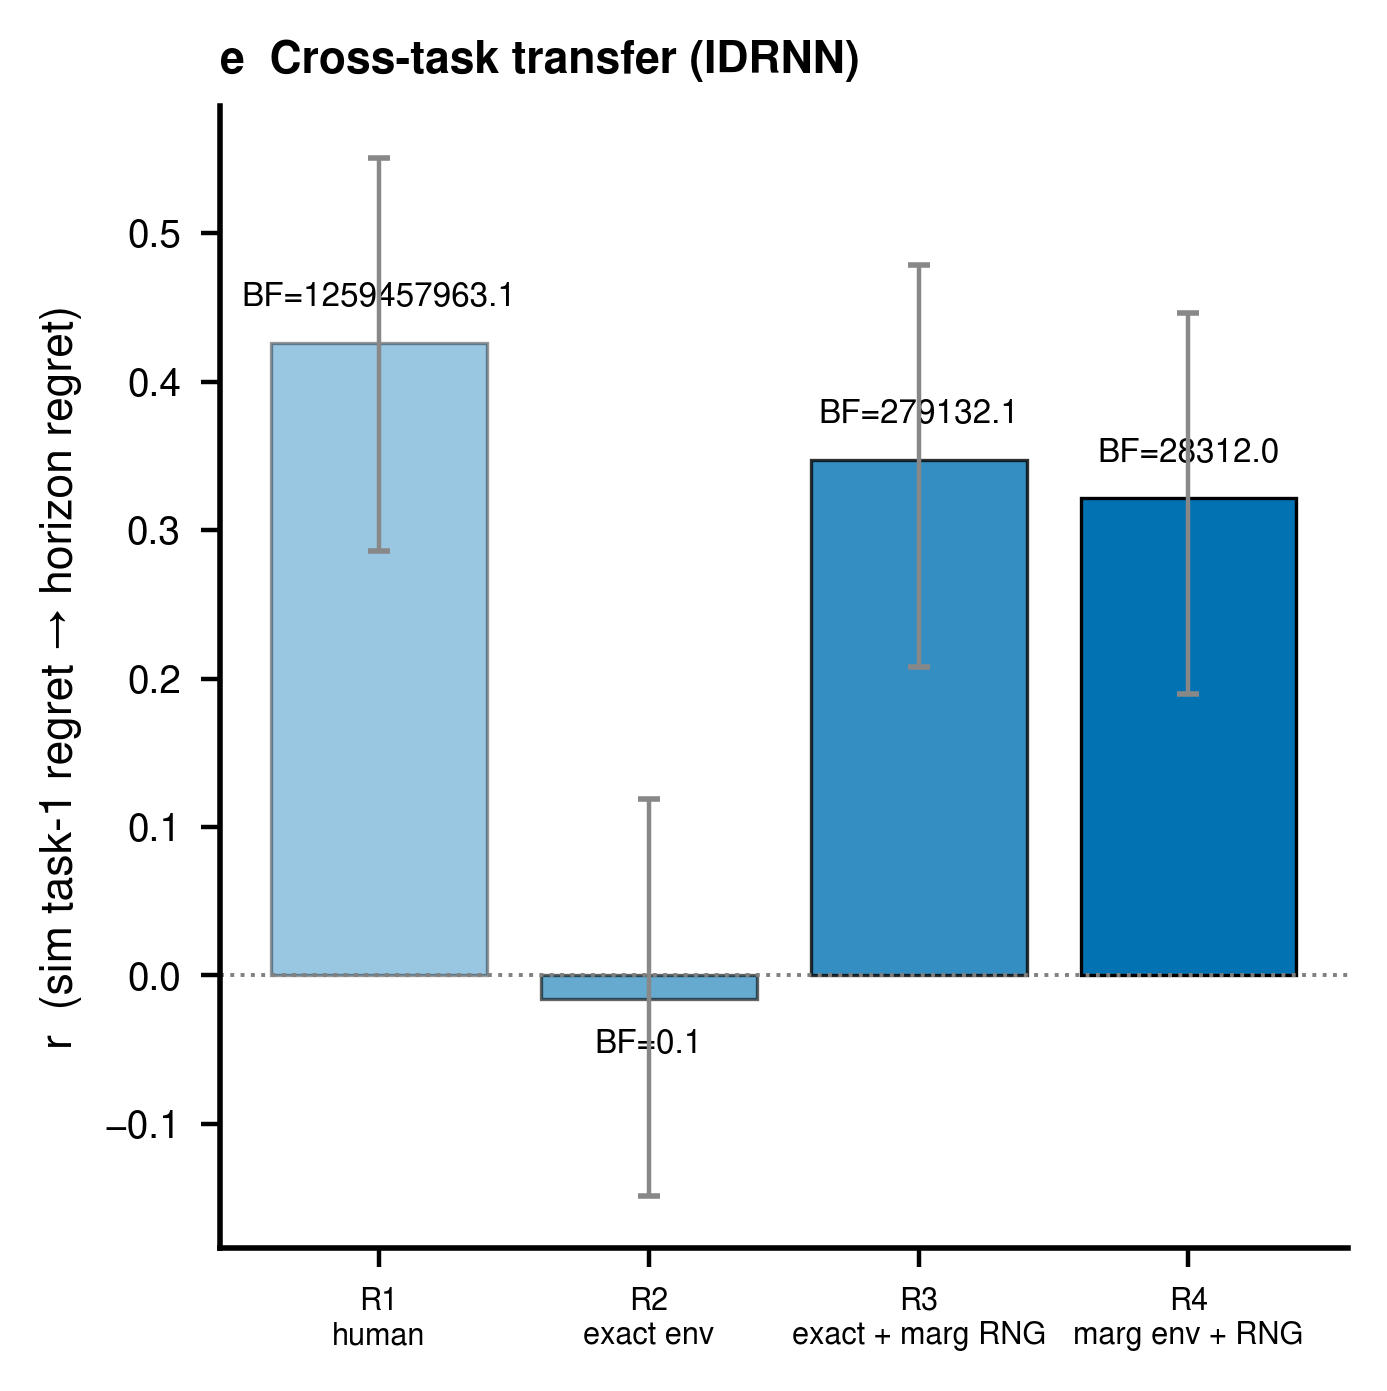

In [6]:
for n,b in MODELS.items():
    display(Markdown(f'### {n}')); show(f'{b}/publication_figure/panel_e.png', 520)

## 6. Regret → held-out target: prediction matrix (both source tasks)
Robustness to the fixed-schedule design: predict horizon regret + WM + questionnaires from **task 0** (top rows) and **task 1** (bottom rows) regret. R4 marginalises over counterfactual environments, so it does not use the shared schedule.

### S1 (session 1)

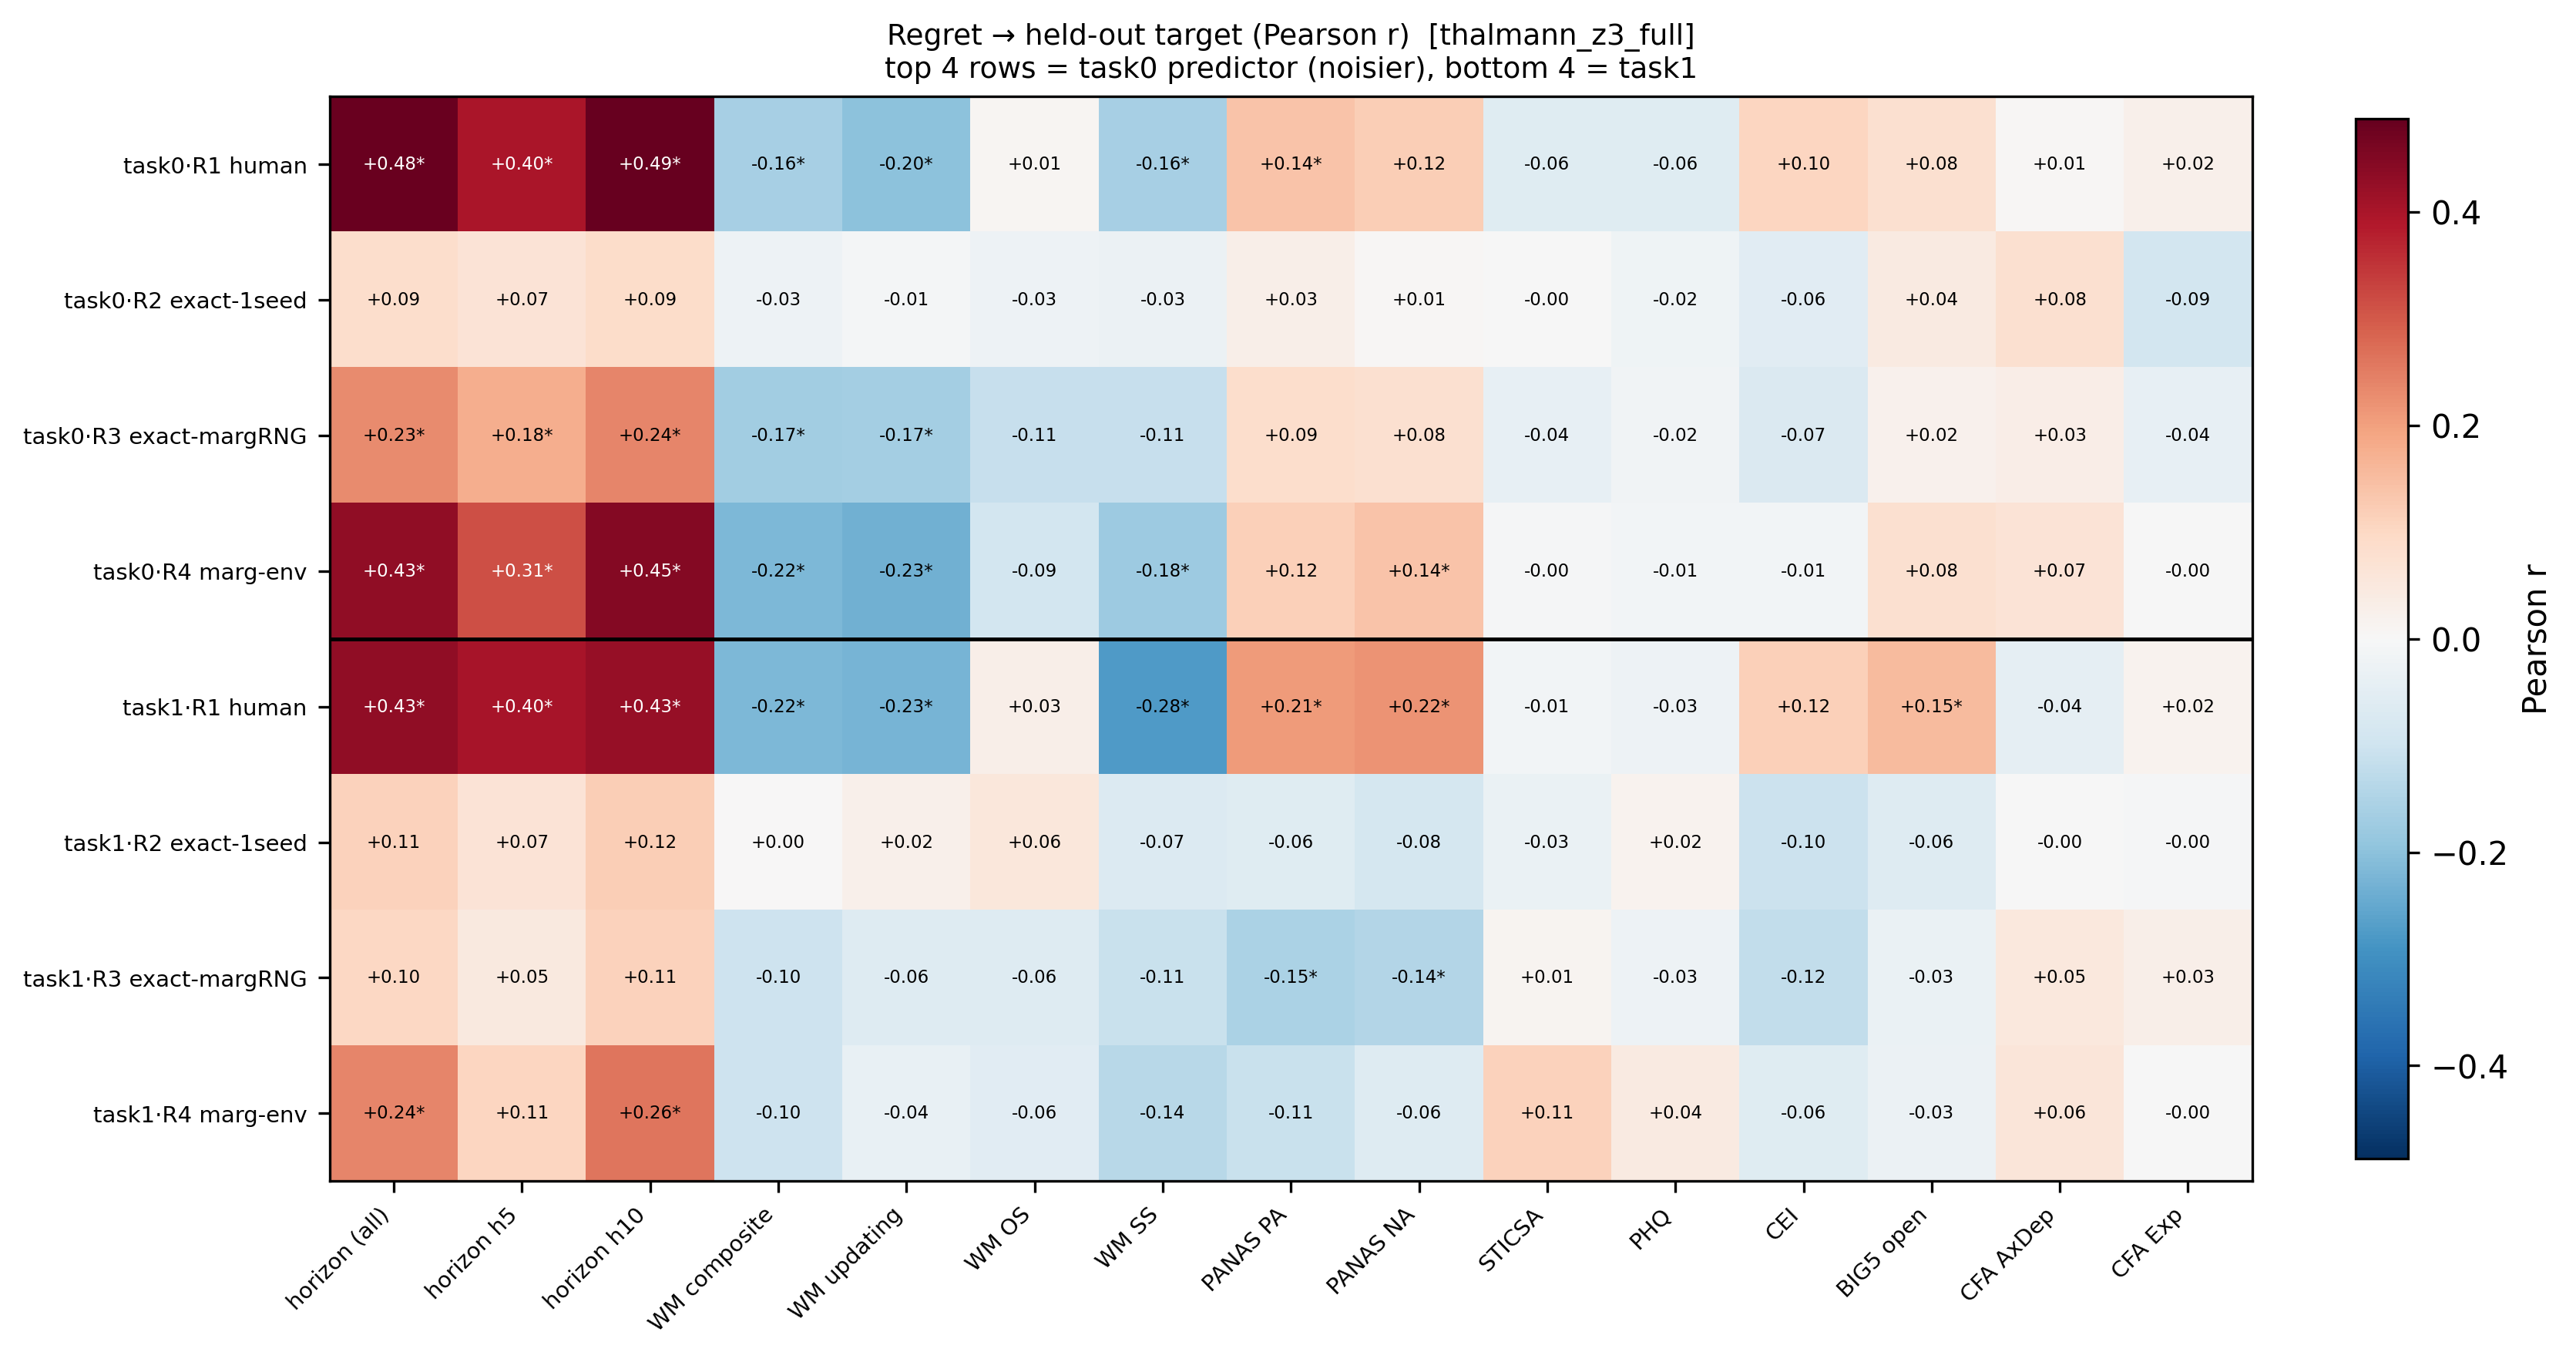

### Pooled S1+S2

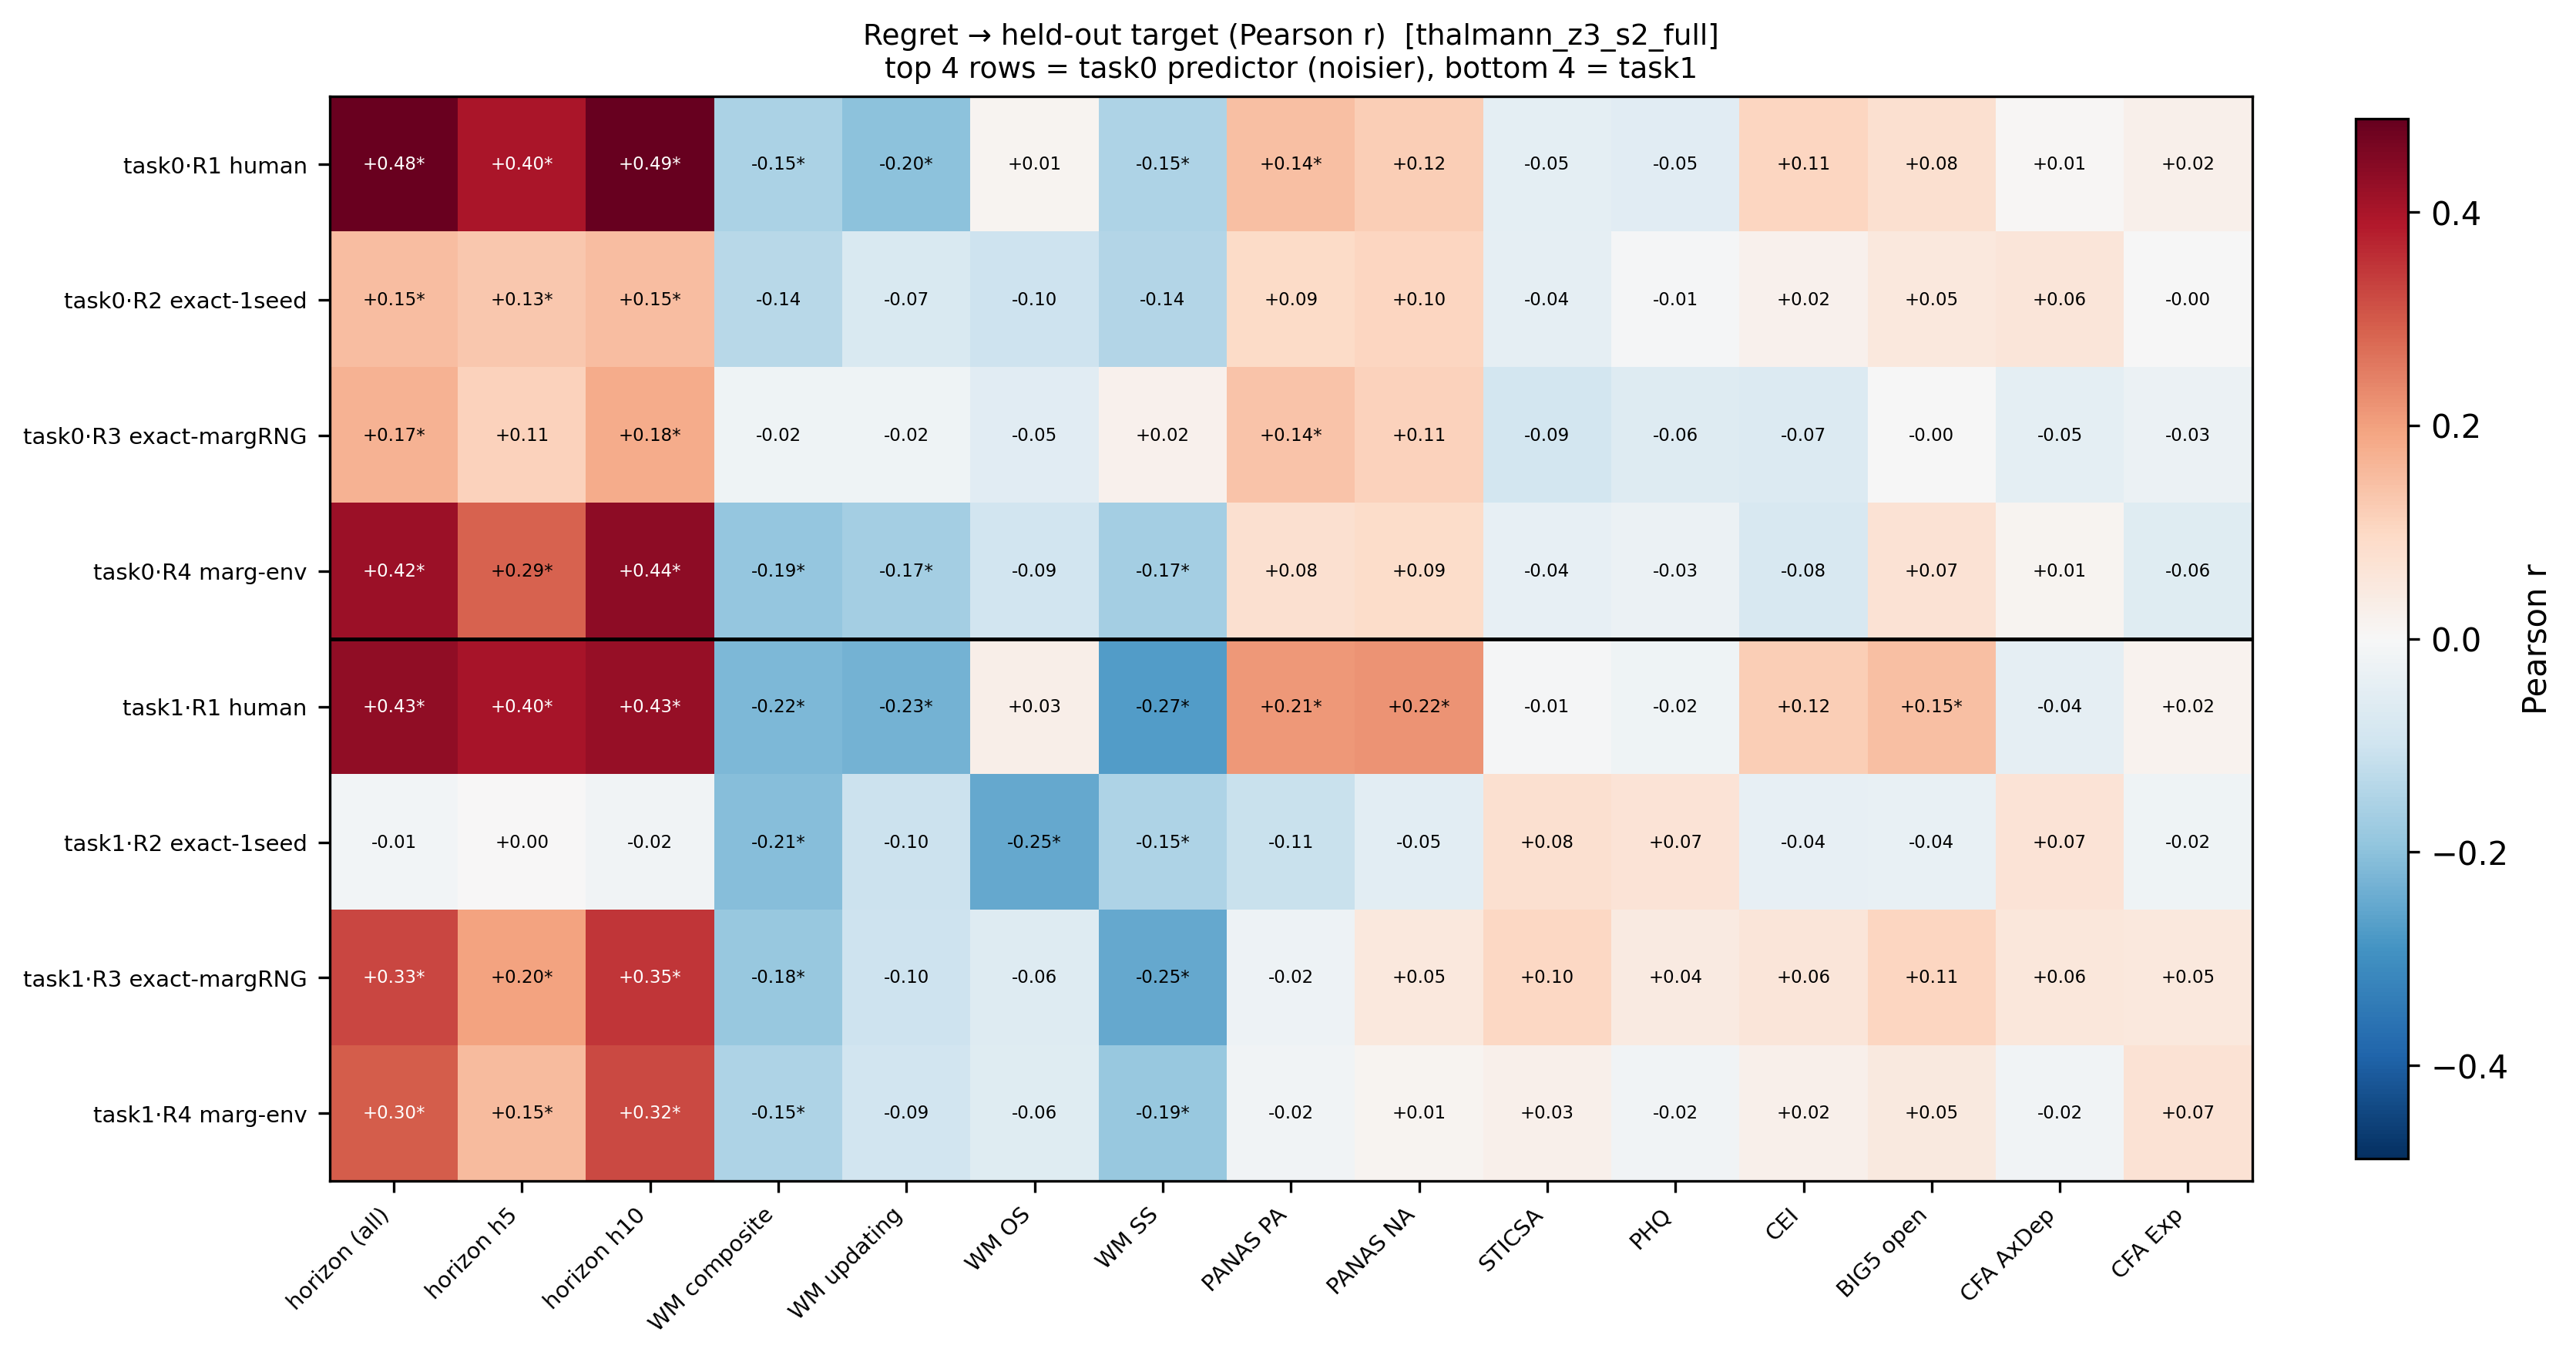

In [7]:
for n,b in MODELS.items():
    display(Markdown(f'### {n}')); show(f'{b}/regret/regret_prediction_matrix.png', 1150)

### 6b. Headline: horizon & WM prediction — task0 vs task1, human (R1) vs counterfactual (R4)

In [8]:
rows=[]
for n,b in MODELS.items():
    df=pd.read_csv(f'{b}/regret/regret_prediction_matrix.csv')
    for tgt in ['horizon (all)','WM composite','WM updating']:
        for src in ['task0','task1']:
            for reg in ['R1 human','R4 marg-env']:
                s=df[(df.source==src)&(df.regret==reg)&(df.target==tgt)]
                if len(s): rows.append(dict(model=n,target=tgt,source=src,regret=reg,r=round(s.pearson_r.iloc[0],3),p=round(s.pearson_p.iloc[0],4)))
display(pd.DataFrame(rows).pivot_table(index=['model','target'],columns=['source','regret'],values='r'))

source                          task0                task1            
regret                       R1 human R4 marg-env R1 human R4 marg-env
model          target                                                 
Pooled S1+S2   WM composite    -0.154      -0.187   -0.219      -0.149
               WM updating     -0.200      -0.167   -0.231      -0.094
               horizon (all)    0.482       0.417    0.433       0.296
S1 (session 1) WM composite    -0.161      -0.221   -0.219      -0.100
               WM updating     -0.199      -0.234   -0.227      -0.037
               horizon (all)    0.482       0.432    0.432       0.238

## 6c. Generative prediction — 9 panels (pooled S1+S2)
{held-out horizon regret, working memory, openness} × {task0+task1 combined, task0 only, task1 only}, each with all four regressions R1–R4. Combined predictor = z-scored mean of task0 & task1 regret.

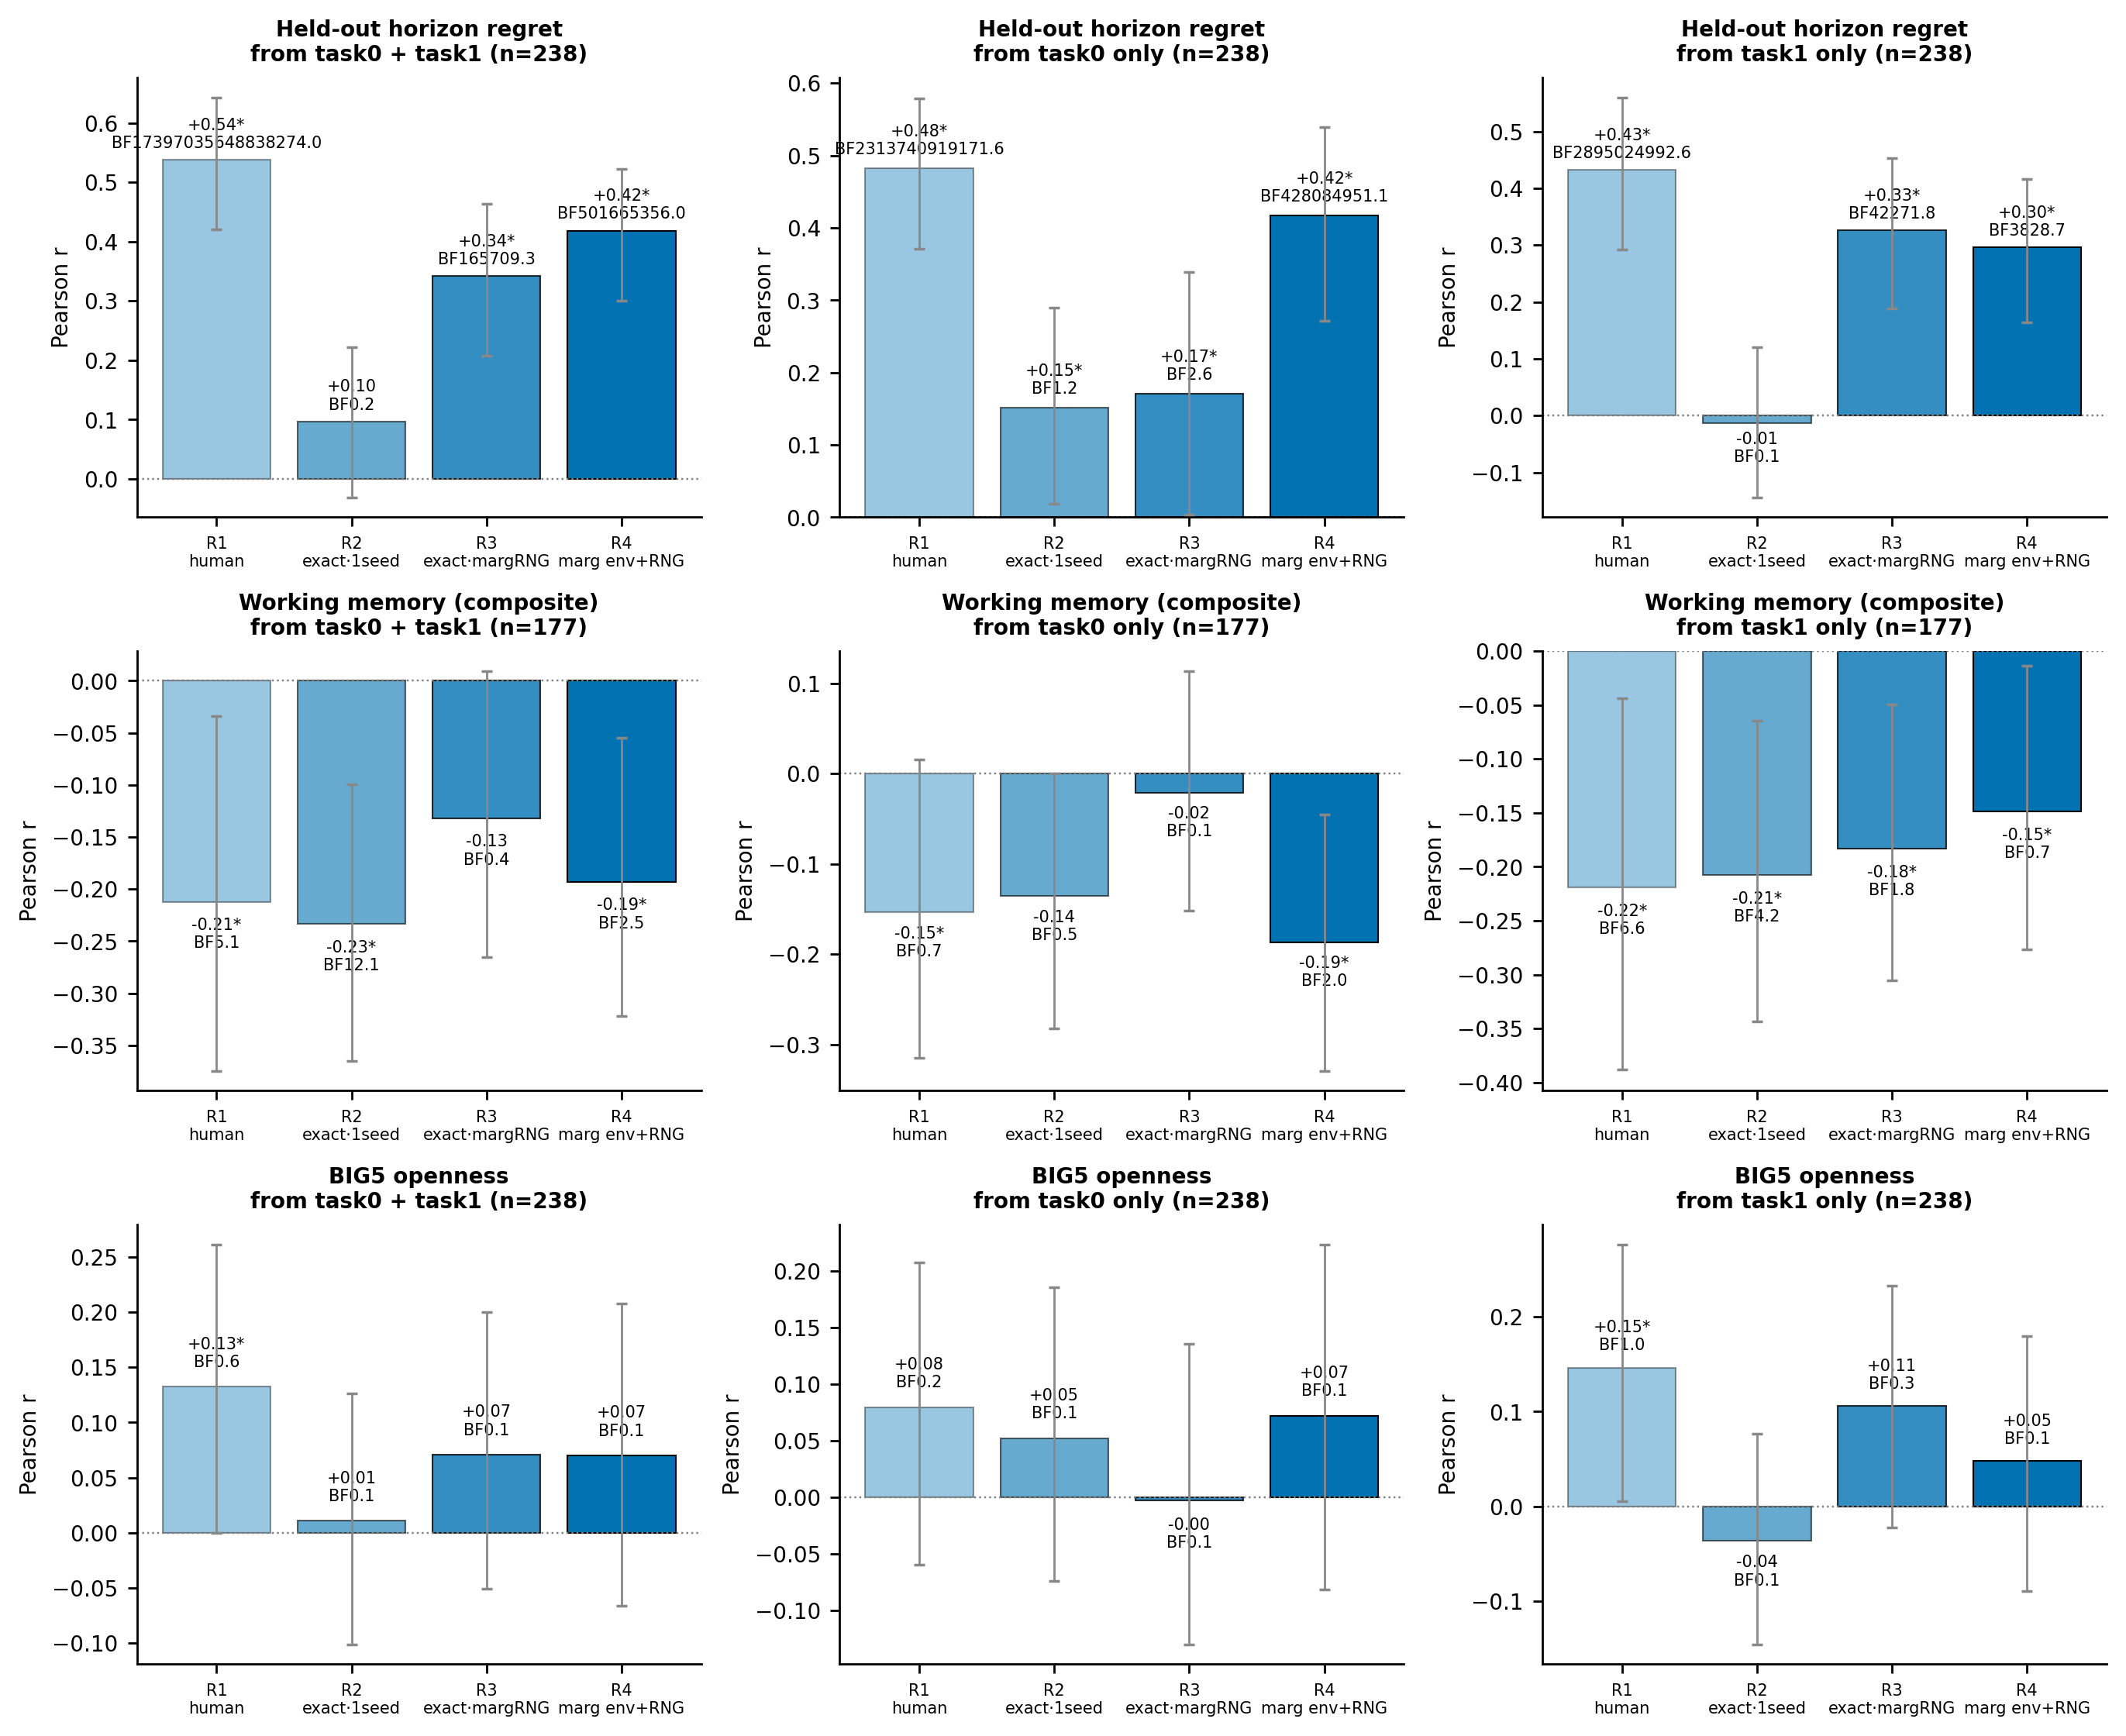

In [9]:
show('final_plots/thalmann_z3_s2_full/regret/generative_prediction/composite_3x3.png', 1100)

In [10]:
sdf=pd.read_csv('final_plots/thalmann_z3_s2_full/regret/generative_prediction/generative_prediction_summary.csv')
for tk in ['horizon_regret','working_memory','openness']:
    display(Markdown(f'**{tk}** (Pearson r; bold/star = p<.05)'))
    display(sdf[sdf.target==tk].pivot_table(index='source',columns='regression',values='r').round(3))

**horizon_regret** (Pearson r; bold/star = p<.05)

regression,R1,R2,R3,R4
source,,,,
both,0.538,0.097,0.342,0.419
task0,0.482,0.152,0.171,0.417
task1,0.433,-0.013,0.326,0.296


**working_memory** (Pearson r; bold/star = p<.05)

regression,R1,R2,R3,R4
source,,,,
both,-0.212,-0.234,-0.132,-0.193
task0,-0.154,-0.136,-0.021,-0.187
task1,-0.219,-0.207,-0.183,-0.149


**openness** (Pearson r; bold/star = p<.05)

regression,R1,R2,R3,R4
source,,,,
both,0.133,0.011,0.071,0.070
task0,0.079,0.052,-0.003,0.072
task1,0.146,-0.036,0.106,0.048


Also saved as individual panels in `final_plots/thalmann_z3_s2_full/regret/generative_prediction/<target>__<source>.png/pdf`.

## 6d. Held-out horizon regret from **task0 only** — R1–R4 + Steiger(R4 vs human)
Standalone & self-contained (loads its own data), in the `synthetic_publication_panels` aesthetic (Nature palette/fonts, bootstrap-CI error bars, bootstrap dot cloud, per-bar BF₁₀). The Steiger test between R4 (model counterfactual) and R1 (human raw) is annotated as a bracket in the same style as the Bayes factors. Pooled S1+S2.

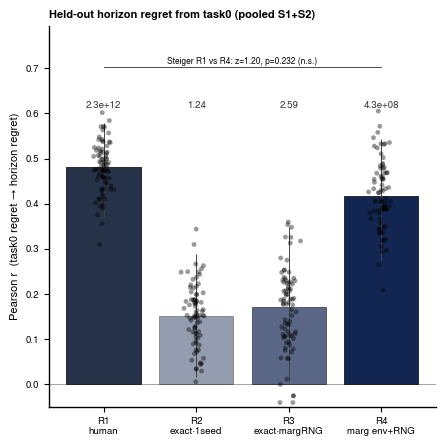

per-bar BF10: R1=2.3e+12, R2=1.24, R3=2.59, R4=4.3e+08
Steiger R1(human) vs R4(model marg-env): z=1.20, p=0.232 (n.s.), n=238


In [6]:
# Held-out HORIZON regret predicted from TASK0 only (pooled S1+S2), synthetic aesthetic.
import numpy as np, matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearsonr
from pingouin import bayesfactor_pearson
from nature_plot_style import nature_colors
plt.rcParams.update({"pdf.fonttype":42,"font.family":"sans-serif",
    "font.sans-serif":["Nimbus Sans","DejaVu Sans"],"font.size":8,"axes.titlesize":8,
    "axes.titleweight":"bold","axes.labelsize":8,"xtick.labelsize":7,"ytick.labelsize":7,
    "legend.frameon":False,"axes.linewidth":1,"axes.spines.top":False,"axes.spines.right":False})
COL_TRUE=nature_colors["Grey"][5]; COL_IDRNN="#132551"
def fmt_bf(bf):
    return "—" if (bf is None or not np.isfinite(bf)) else (f"{bf:.1e}" if bf>=1000 else (f"{bf:.1f}" if bf>=10 else f"{bf:.2f}"))
def bracket(ax,x1,x2,y,h,txt):
    ax.plot([x1,x2],[y+h,y+h],lw=0.5,c="black")
    ax.text((x1+x2)/2,y+h*1.1,txt,ha="center",va="bottom",fontsize=6)
def steiger(r12,r13,r23,n):
    r12,r13,r23=np.clip([r12,r13,r23],-0.9999,0.9999)
    z12,z13=np.arctanh(r12),np.arctanh(r13); rbar=(r12**2+r13**2)/2
    f=(1-r23)/(2*(1-rbar)); h=(1-f*rbar)/(1-rbar); var=(2*(1-r23)/(n-1))*h
    if var<=0: return 0.0,1.0
    z=(z12-z13)/np.sqrt(var); return float(z), float(2*stats.norm.sf(abs(z)))

d=np.load("final_plots/thalmann_z3_s2_full/regret/step1_cross_task_regret.npz")
y=d["hum_regret_task3"]
BARS=[("R1\nhuman",            d["hum_regret_task0"],                   COL_TRUE,  1.00),
      ("R2\nexact·1seed",  d["sim_regret_task0_r2_exact_single"],   COL_IDRNN, 0.45),
      ("R3\nexact·margRNG",d["sim_regret_task0_r3_exact_margrng"],  COL_IDRNN, 0.70),
      ("R4\nmarg env+RNG",      d["sim_regret_task0_r4_marg"],           COL_IDRNN, 1.00)]
recs=[]; rng=np.random.default_rng(1)
for lab,x,col,al in BARS:
    m=np.isfinite(x)&np.isfinite(y); xv,yv=x[m],y[m]; nb=len(xv)
    r=float(pearsonr(xv,yv)[0]); boots=np.empty(2000)
    for i in range(2000):
        idx=rng.integers(0,nb,nb); boots[i]=np.corrcoef(xv[idx],yv[idx])[0,1]
    lo,hi=np.nanpercentile(boots,[2.5,97.5])
    recs.append(dict(label=lab,color=col,alpha=al,r=r,ci=(lo,hi),boots=boots,bf=float(bayesfactor_pearson(r,nb)),n=nb))

fig,ax=plt.subplots(figsize=(4.5,4.5))
xs=np.arange(len(recs)); heights=[r["r"] for r in recs]
sd_err=[float(np.std(r["boots"])) for r in recs]   # ±SD of the bootstrap-r distribution
for xi,r in zip(xs,recs):
    ax.bar(xi,r["r"],color=r["color"],alpha=r["alpha"],edgecolor="black",linewidth=0.5,zorder=2)
ax.errorbar(xs,heights,yerr=sd_err,fmt="none",ecolor="#444444",elinewidth=0.7,capsize=0,zorder=3)
rng_pts=np.random.default_rng(7)
for xi,r in zip(xs,recs):
    s=rng_pts.choice(r["boots"],80,replace=False); j=rng_pts.normal(0,0.05,80)
    ax.scatter(xi+j,s,s=12,c="black",alpha=0.4,edgecolors="none",zorder=4)
allb=np.concatenate([r["boots"] for r in recs]); y_top=float(np.nanpercentile(allb,99))+0.04
for xi,r in zip(xs,recs):
    ax.text(xi,y_top,fmt_bf(r["bf"]),ha="center",fontsize=7,color="#333333")
# Steiger test: R4 (idx 3) vs human R1 (idx 0), dependent correlations sharing horizon
mm=np.isfinite(y)&np.isfinite(d["hum_regret_task0"])&np.isfinite(d["sim_regret_task0_r4_marg"]); n=int(mm.sum())
ry1=pearsonr(d["hum_regret_task0"][mm],y[mm])[0]; ry4=pearsonr(d["sim_regret_task0_r4_marg"][mm],y[mm])[0]
r14=pearsonr(d["hum_regret_task0"][mm],d["sim_regret_task0_r4_marg"][mm])[0]
z,p=steiger(ry1,ry4,r14,n)
star="***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "n.s."
bracket(ax,0,3,y_top+0.06,0.03,f"Steiger R1 vs R4: z={z:.2f}, p={p:.3f} ({star})")
ax.axhline(0,color="grey",lw=0.5,zorder=1)
ax.set_xticks(xs); ax.set_xticklabels([r["label"] for r in recs],fontsize=7)
ax.set_ylabel("Pearson r  (task0 regret → horizon regret)")
ax.set_title("Held-out horizon regret from task0 (pooled S1+S2)",loc="left")
ax.set_ylim(min(0,min(heights))-0.05, y_top+0.18)
plt.tight_layout(); plt.show()
print(f"per-bar BF10: " + ", ".join(f"{r['label'].splitlines()[0]}={fmt_bf(r['bf'])}" for r in recs))
print(f"Steiger R1(human) vs R4(model marg-env): z={z:.2f}, p={p:.3f} ({star}), n={n}")


## 6e. Same panel — human task0 observations from **Session 1 only**
Tests whether the human's edge over the model (R1 > R4 in 6d) is just its 2-session reliability advantage. R1 = human task0 regret from Session 1 only; model bars (R2–R4) and the held-out horizon target unchanged. **The gap closes** — R4 (model) now matches/exceeds the single-session human R1. Reuses helpers from cell 6d.

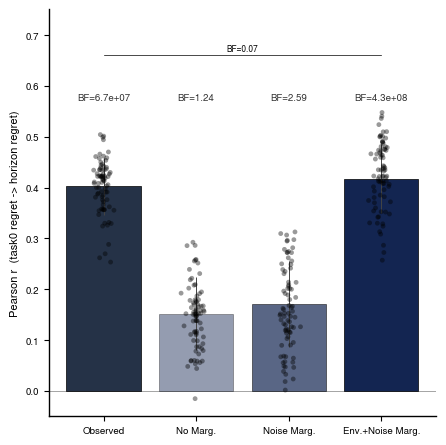

R1(human S1)=+0.403  R4(model)=+0.416  gap=-0.013; BF=0.07 (R1 vs R4), n=236


In [2]:
# R1 (human task0 regret) recomputed from SESSION 1 ONLY; R2-R4 + horizon target as in 6d.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import pearsonr
from pingouin import bayesfactor_pearson
d=np.load("final_plots/thalmann_z3_s2_full/regret/step1_cross_task_regret.npz")
subids=d["subids"].astype(int); y=d["hum_regret_task3"]
ab=pd.read_csv("data/final2armedBanditSession1.csv"); o={}
for s,g in ab.groupby("ID"):
    a=g[["reward1","reward2"]].values.astype(float); o[int(s)]=float((a.max(1)-g["reward"].values).mean())
R1=np.array([o.get(int(s),np.nan) for s in subids])
BARS=[("R1\nhuman (S1)",      R1,                                      COL_TRUE,  1.00),
      ("R2\nexact·1seed",  d["sim_regret_task0_r2_exact_single"],   COL_IDRNN, 0.45),
      ("R3\nexact·margRNG",d["sim_regret_task0_r3_exact_margrng"],  COL_IDRNN, 0.70),
      ("R4\nmarg env+RNG",      d["sim_regret_task0_r4_marg"],           COL_IDRNN, 1.00)]
recs=[]; rng=np.random.default_rng(1)
for lab,x,col,al in BARS:
    m=np.isfinite(x)&np.isfinite(y); xv,yv=x[m],y[m]; nb=len(xv)
    r=float(pearsonr(xv,yv)[0]); boots=np.empty(2000)
    for i in range(2000):
        idx=rng.integers(0,nb,nb); boots[i]=np.corrcoef(xv[idx],yv[idx])[0,1]
    lo,hi=np.nanpercentile(boots,[2.5,97.5])
    recs.append(dict(label=lab,color=col,alpha=al,r=r,ci=(lo,hi),boots=boots,bf=float(bayesfactor_pearson(r,nb))))
fig,ax=plt.subplots(figsize=(4.5,4.5)); xs=np.arange(4); heights=[r["r"] for r in recs]
sd_err=[float(np.std(r["boots"])) for r in recs]   # ±SD of the bootstrap-r distribution
for xi,r in zip(xs,recs): ax.bar(xi,r["r"],color=r["color"],alpha=r["alpha"],edgecolor="black",linewidth=0.5,zorder=2)
ax.errorbar(xs,heights,yerr=sd_err,fmt="none",ecolor="#444444",elinewidth=0.7,capsize=0,zorder=3)
rp=np.random.default_rng(7)
for xi,r in zip(xs,recs):
    sm=rp.choice(r["boots"],80,replace=False); ax.scatter(xi+rp.normal(0,0.05,80),sm,s=12,c="black",alpha=0.4,edgecolors="none",zorder=4)
allb=np.concatenate([r["boots"] for r in recs]); y_top=float(np.nanpercentile(allb,99))+0.04
for xi,r in zip(xs,recs): ax.text(xi,y_top,fmt_bf(r["bf"]),ha="center",fontsize=7,color="#333333")
mm=np.isfinite(R1)&np.isfinite(y)&np.isfinite(d["sim_regret_task0_r4_marg"]); n=int(mm.sum())
ry1=pearsonr(R1[mm],y[mm])[0]; ry4=pearsonr(d["sim_regret_task0_r4_marg"][mm],y[mm])[0]
# Bayes factor for R1(human) vs R4(model): paired BF on the per-subject z-scored
# cross-products that decompose each Pearson r (same paired-BF device as the
# synthetic panels). BF>1 favours the two correlations differing.
_zc=lambda a:(np.asarray(a,float)-np.asarray(a,float).mean())/(np.asarray(a,float).std()+1e-12)
bf_cmp=paired_bf(_zc(R1[mm])*_zc(y[mm]), _zc(d["sim_regret_task0_r4_marg"][mm])*_zc(y[mm]))
bracket(ax,0,3,y_top+0.06,0.03,fmt_bf(bf_cmp))
ax.axhline(0,color="grey",lw=0.5,zorder=1); ax.set_xticks(xs); ax.set_xticklabels(["Observed", "No Marg.", "Noise Marg.", "Env.+Noise Marg."],fontsize=7)
ax.set_ylabel("Pearson r  (task0 regret -> horizon regret)")
#ax.set_title("Held-out horizon from task0 — human obs = Session 1 only",loc="left")
ax.set_ylim(min(0,min(heights))-0.05,y_top+0.18) 
plt.tight_layout()
plt.savefig("final_plots/thalmann_generative_sim_s1.png", dpi=600, bbox_inches="tight")
plt.show()
print(f"R1(human S1)={ry1:+.3f}  R4(model)={ry4:+.3f}  gap={ry1-ry4:+.3f}; {fmt_bf(bf_cmp)} (R1 vs R4), n={n}")


## 7. Panel a — held-out NLL per trial (S1 nested-CV, all 500 trials)

Ill-spec Q-CP    0.740
Ill-spec Q-EM    0.722
Cog CP           0.690
Cog EM           0.648
CP-RNN           0.625
IDRNN            0.613
Vanilla          0.567
Name: mean NLL/trial, dtype: float64

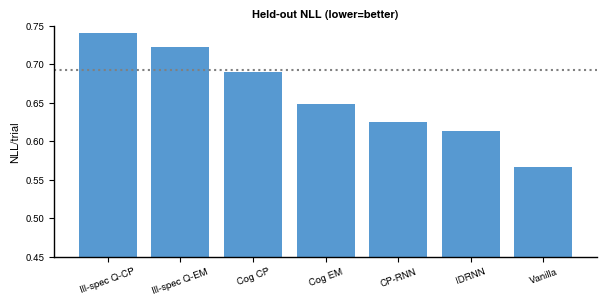

In [13]:
df=pd.read_csv('final_plots/thalmann_z3/per_participant_nll.csv')
cols={'Ill-spec Q-CP':'nll_ill_cp','Ill-spec Q-EM':'nll_ill_em','Cog CP':'nll_cog_cp','Cog EM':'nll_cog_em','CP-RNN':'nll_cp_rnn_all','IDRNN':'nll_idrnn_all','Vanilla':'nll_vanilla_all'}
m={k:df[v].mean() for k,v in cols.items() if v in df}
display(pd.Series(m, name='mean NLL/trial').round(3))
_barcol={'Ill-spec Q-CP':COL_Q_CP,'Ill-spec Q-EM':COL_Q_EM,'Cog CP':COL_FQ_CP,'Cog EM':COL_FQ_EM,'CP-RNN':COL_RNN_CP,'IDRNN':COL_IDRNN,'Vanilla':COL_VANILLA}
fig,ax=plt.subplots(figsize=(7,3)); ax.bar(list(m), list(m.values()), color=[_barcol[k] for k in m]); ax.axhline(np.log(2),ls=':',color=COL_TRUE)
ax.set_ylabel('NLL/trial'); ax.set_ylim(0.45,0.75); plt.xticks(rotation=20); plt.title('Held-out NLL (lower=better)'); plt.show()

## 8. Does adding the horizon task improve the readout? (2-task vs 3-task)
Separate 3-task model (2-armed + restless + horizon); horizon stays held-out for transfer via the 2-task model, and WM/questionnaire targets are external, so this is not circular. Seed-averaged LOO R².

,IDRNN 2t,IDRNN 3t,Vanilla 2t,Vanilla 3t,Van3t frac+
target,,,,,
PANAS_PA,-0.022,0.017,0.025,-0.011,0.0
PANAS_NA,-0.009,0.012,0.021,-0.015,0.0
STICSA,-0.014,-0.015,-0.012,-0.013,0.0
PHQ,-0.011,-0.011,-0.013,-0.014,0.0
CEI,-0.011,0.009,-0.027,-0.016,0.1
BIG5_open,0.022,0.044,-0.010,-0.004,0.4
AxDep,-0.016,-0.014,-0.015,-0.020,0.0
posMood,-0.013,-0.016,-0.020,-0.014,0.0
negMood,-0.014,-0.014,-0.024,-0.016,0.0


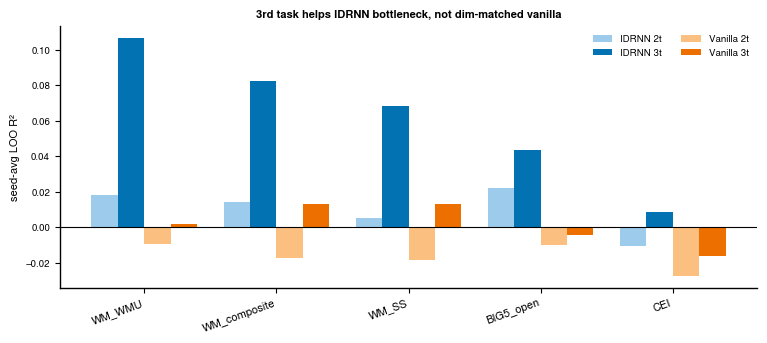

In [14]:
a=pd.read_csv('final_plots/thalmann_z3_s2_full/decoding/seed_averaged_decoding.csv').set_index('target')
b=pd.read_csv('final_plots/thalmann_z3_3task_full/decoding/seed_averaged_decoding.csv').set_index('target')
cmp=pd.DataFrame({'IDRNN 2t':a.idrnn_loo_r2_mean,'IDRNN 3t':b.idrnn_loo_r2_mean,
                  'Vanilla 2t':a.vanilla_loo_r2_mean,'Vanilla 3t':b.vanilla_loo_r2_mean,
                  'Van3t frac+':b.vanilla_frac_pos}).round(3)
display(cmp)
# Control: does the 3rd task help only IDRNN, or also the dim-matched vanilla?
k=['WM_WMU','WM_composite','WM_SS','BIG5_open','CEI']; x=np.arange(len(k)); w=.2
fig,ax=plt.subplots(figsize=(9,3.4))
ax.bar(x-1.5*w,[a.loc[t,'idrnn_loo_r2_mean'] for t in k],w,label='IDRNN 2t',color=lighten(COL_IDRNN,0.5))
ax.bar(x-0.5*w,[b.loc[t,'idrnn_loo_r2_mean'] for t in k],w,label='IDRNN 3t',color=COL_IDRNN)
ax.bar(x+0.5*w,[a.loc[t,'vanilla_loo_r2_mean'] for t in k],w,label='Vanilla 2t',color=COL_VAN_H)
ax.bar(x+1.5*w,[b.loc[t,'vanilla_loo_r2_mean'] for t in k],w,label='Vanilla 3t',color=COL_VANILLA)
ax.axhline(0,color='k',lw=.8); ax.set_xticks(x); ax.set_xticklabels(k,rotation=20,ha='right',fontsize=8)
ax.set_ylabel('seed-avg LOO R²'); ax.set_title('3rd task helps IDRNN bottleneck, not dim-matched vanilla'); ax.legend(fontsize=7,ncol=2); plt.show()

## 8b. 3-task fit — four decodability metrics, IDRNN vs dim-matched Vanilla
**Seed-averaged (mean±SD over 10 seeds)** — Pearson r (in-sample multiple-R), Spearman r (in-sample), LOO r (pred vs target; negative = no-info artifact), LOO R² (out-of-sample). Seed-averaging is essential: a single lucky seed can show spurious signal (e.g. vanilla openness) that vanishes on averaging.

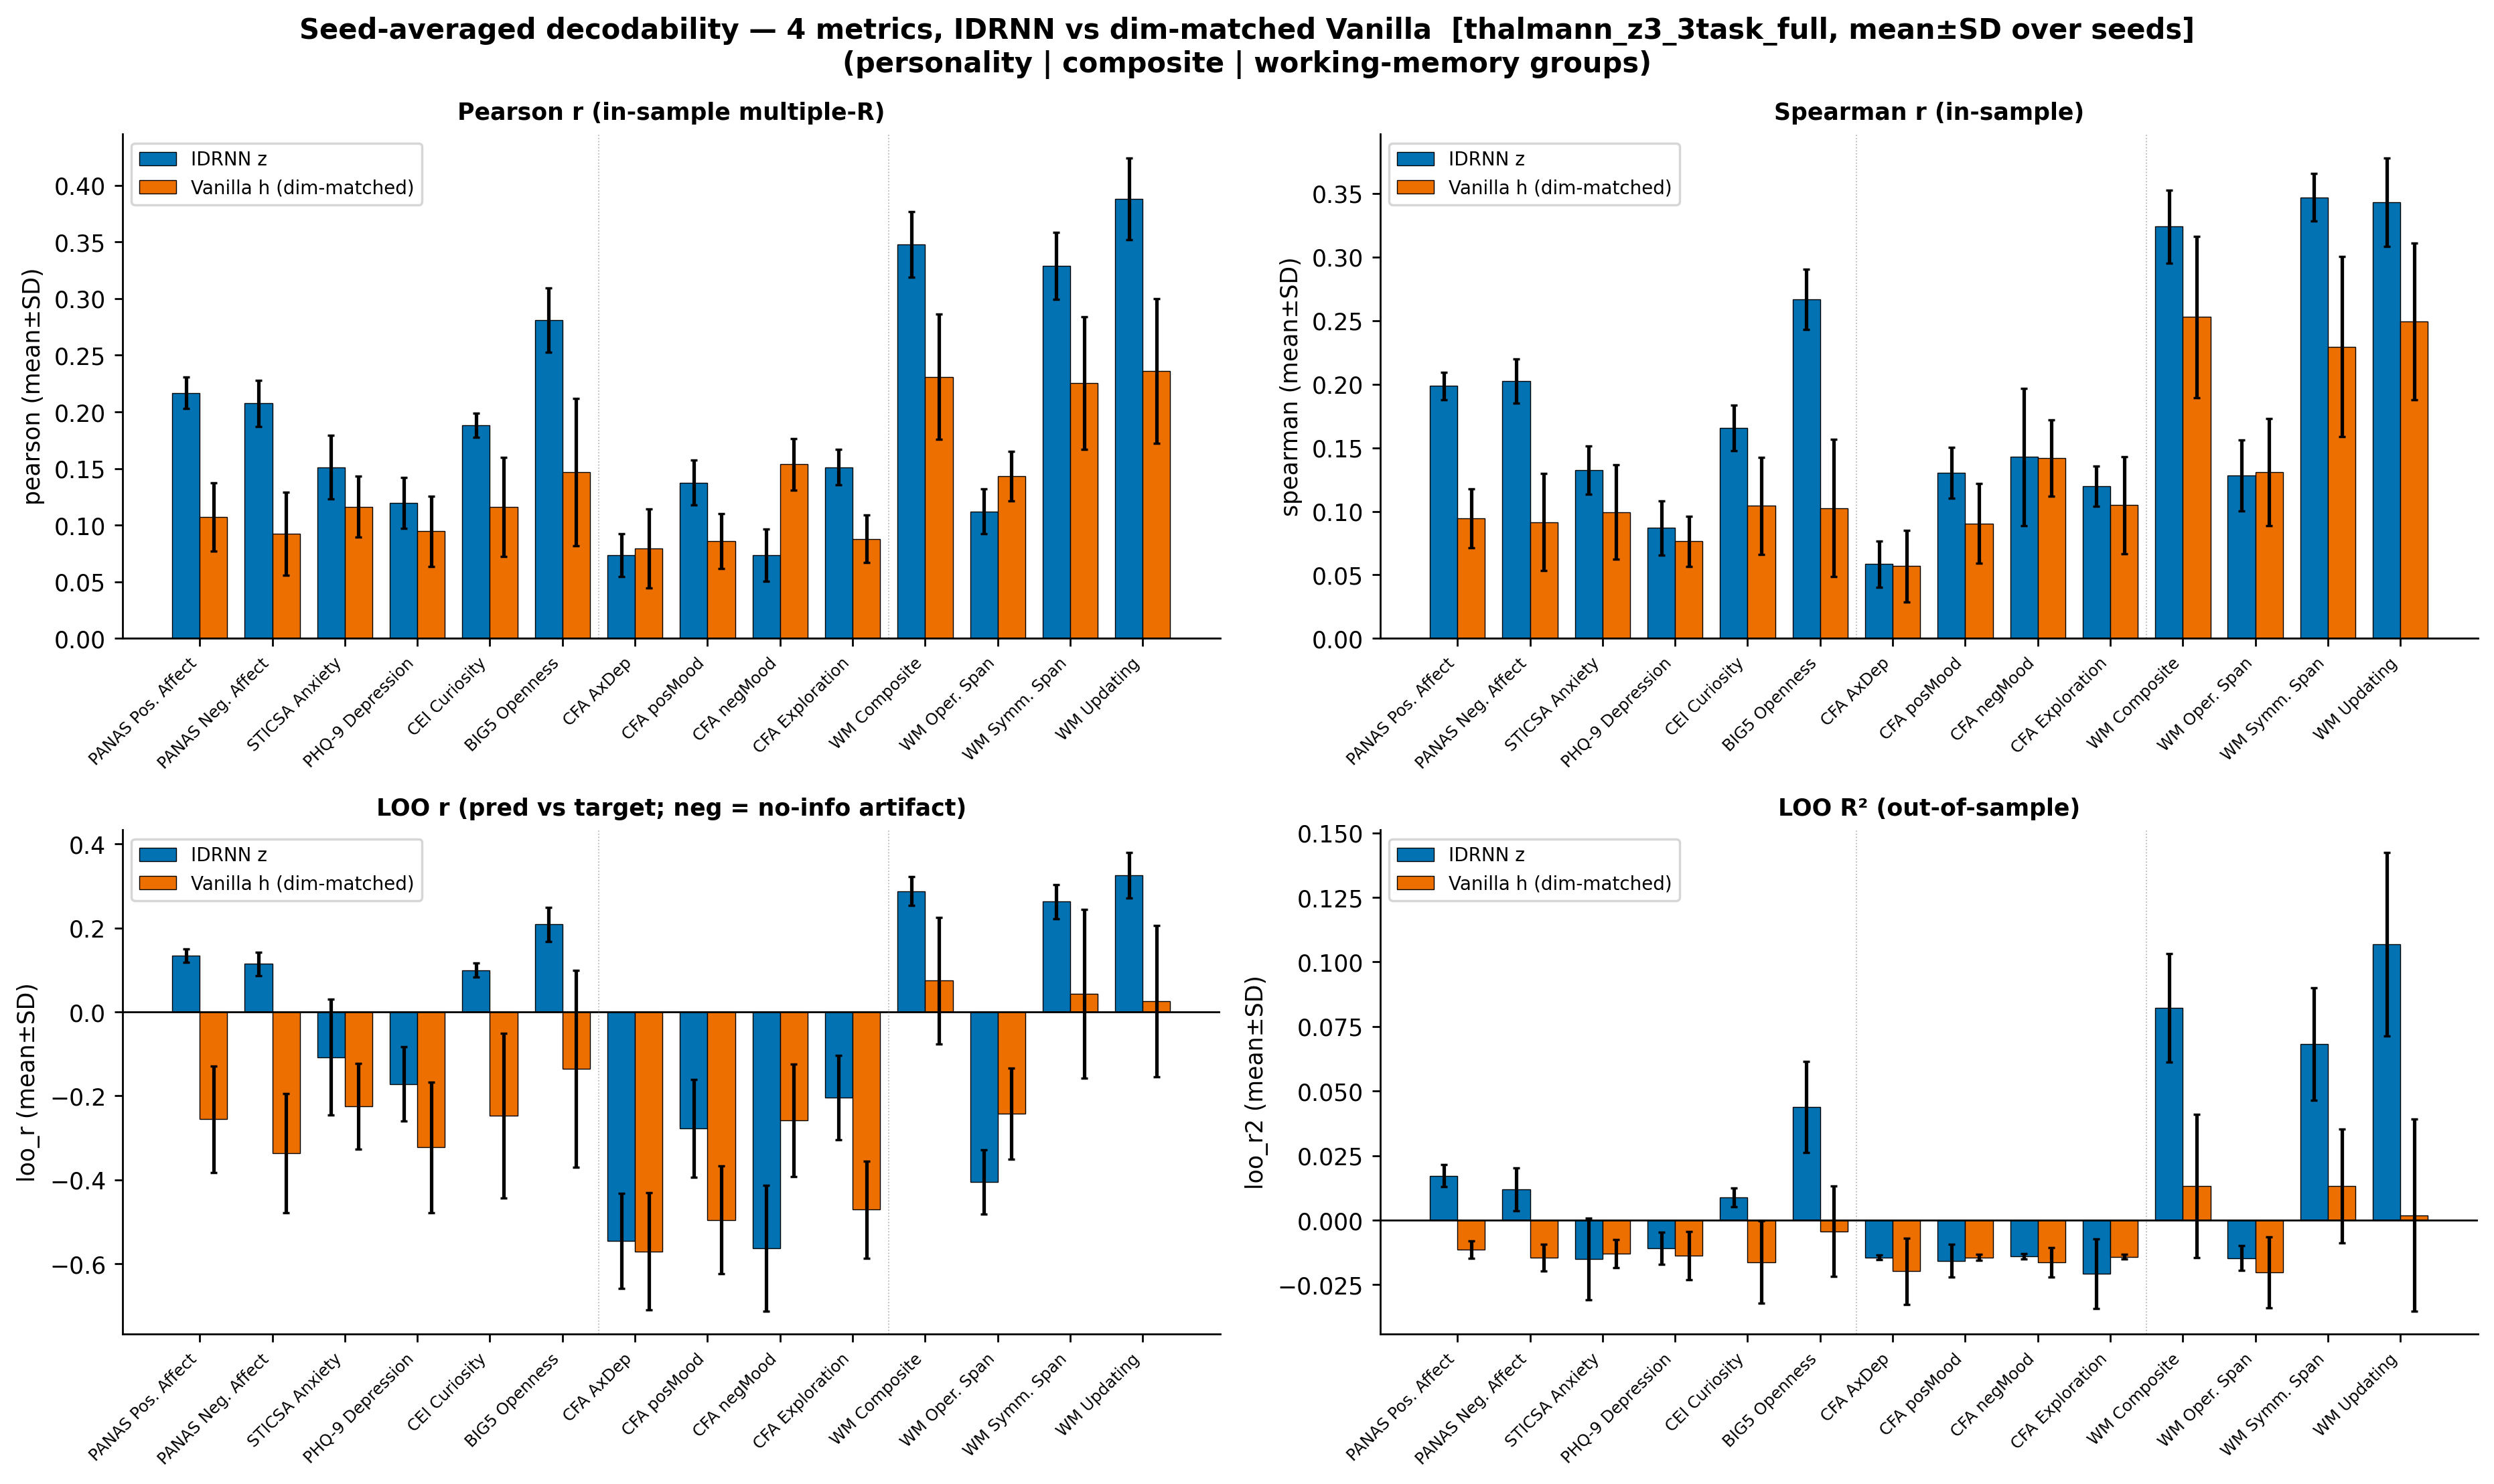

In [15]:
show('final_plots/thalmann_z3_3task_full/decoding/four_metrics.png', 1100)

In [16]:
fm=pd.read_csv('final_plots/thalmann_z3_3task_full/decoding/seed_averaged_decoding.csv').set_index('target')
cols=[f'{a}_{m}_mean' for a in ['idrnn','vanilla'] for m in ['pearson','spearman','loo_r','loo_r2']]
display(fm[cols].round(3))

,idrnn_pearson_mean,idrnn_spearman_mean,idrnn_loo_r_mean,idrnn_loo_r2_mean,vanilla_pearson_mean,vanilla_spearman_mean,vanilla_loo_r_mean,vanilla_loo_r2_mean
target,,,,,,,,
PANAS_PA,0.217,0.199,0.134,0.017,0.107,0.095,-0.256,-0.011
PANAS_NA,0.208,0.202,0.114,0.012,0.092,0.091,-0.336,-0.015
STICSA,0.151,0.132,-0.108,-0.015,0.116,0.099,-0.225,-0.013
PHQ,0.120,0.087,-0.172,-0.011,0.095,0.076,-0.322,-0.014
CEI,0.188,0.166,0.099,0.009,0.116,0.104,-0.247,-0.016
BIG5_open,0.281,0.267,0.209,0.044,0.147,0.103,-0.135,-0.004
AxDep,0.074,0.059,-0.545,-0.014,0.079,0.057,-0.570,-0.020
posMood,0.138,0.130,-0.278,-0.016,0.086,0.091,-0.495,-0.014
negMood,0.074,0.143,-0.563,-0.014,0.154,0.142,-0.258,-0.016


## 8c. Data scaling — does the readout improve with more training tasks?
Clean nested S1 ladder: 1 task (restless) ⊂ 2 tasks (+2-armed) ⊂ 3 tasks (+horizon), both archs fully retrained at each rung. **IDRNN's readout climbs** (driven by the exploration/horizon task); the **dim-matched Vanilla stays flat near zero** — no individual-difference mechanism to exploit the extra data.

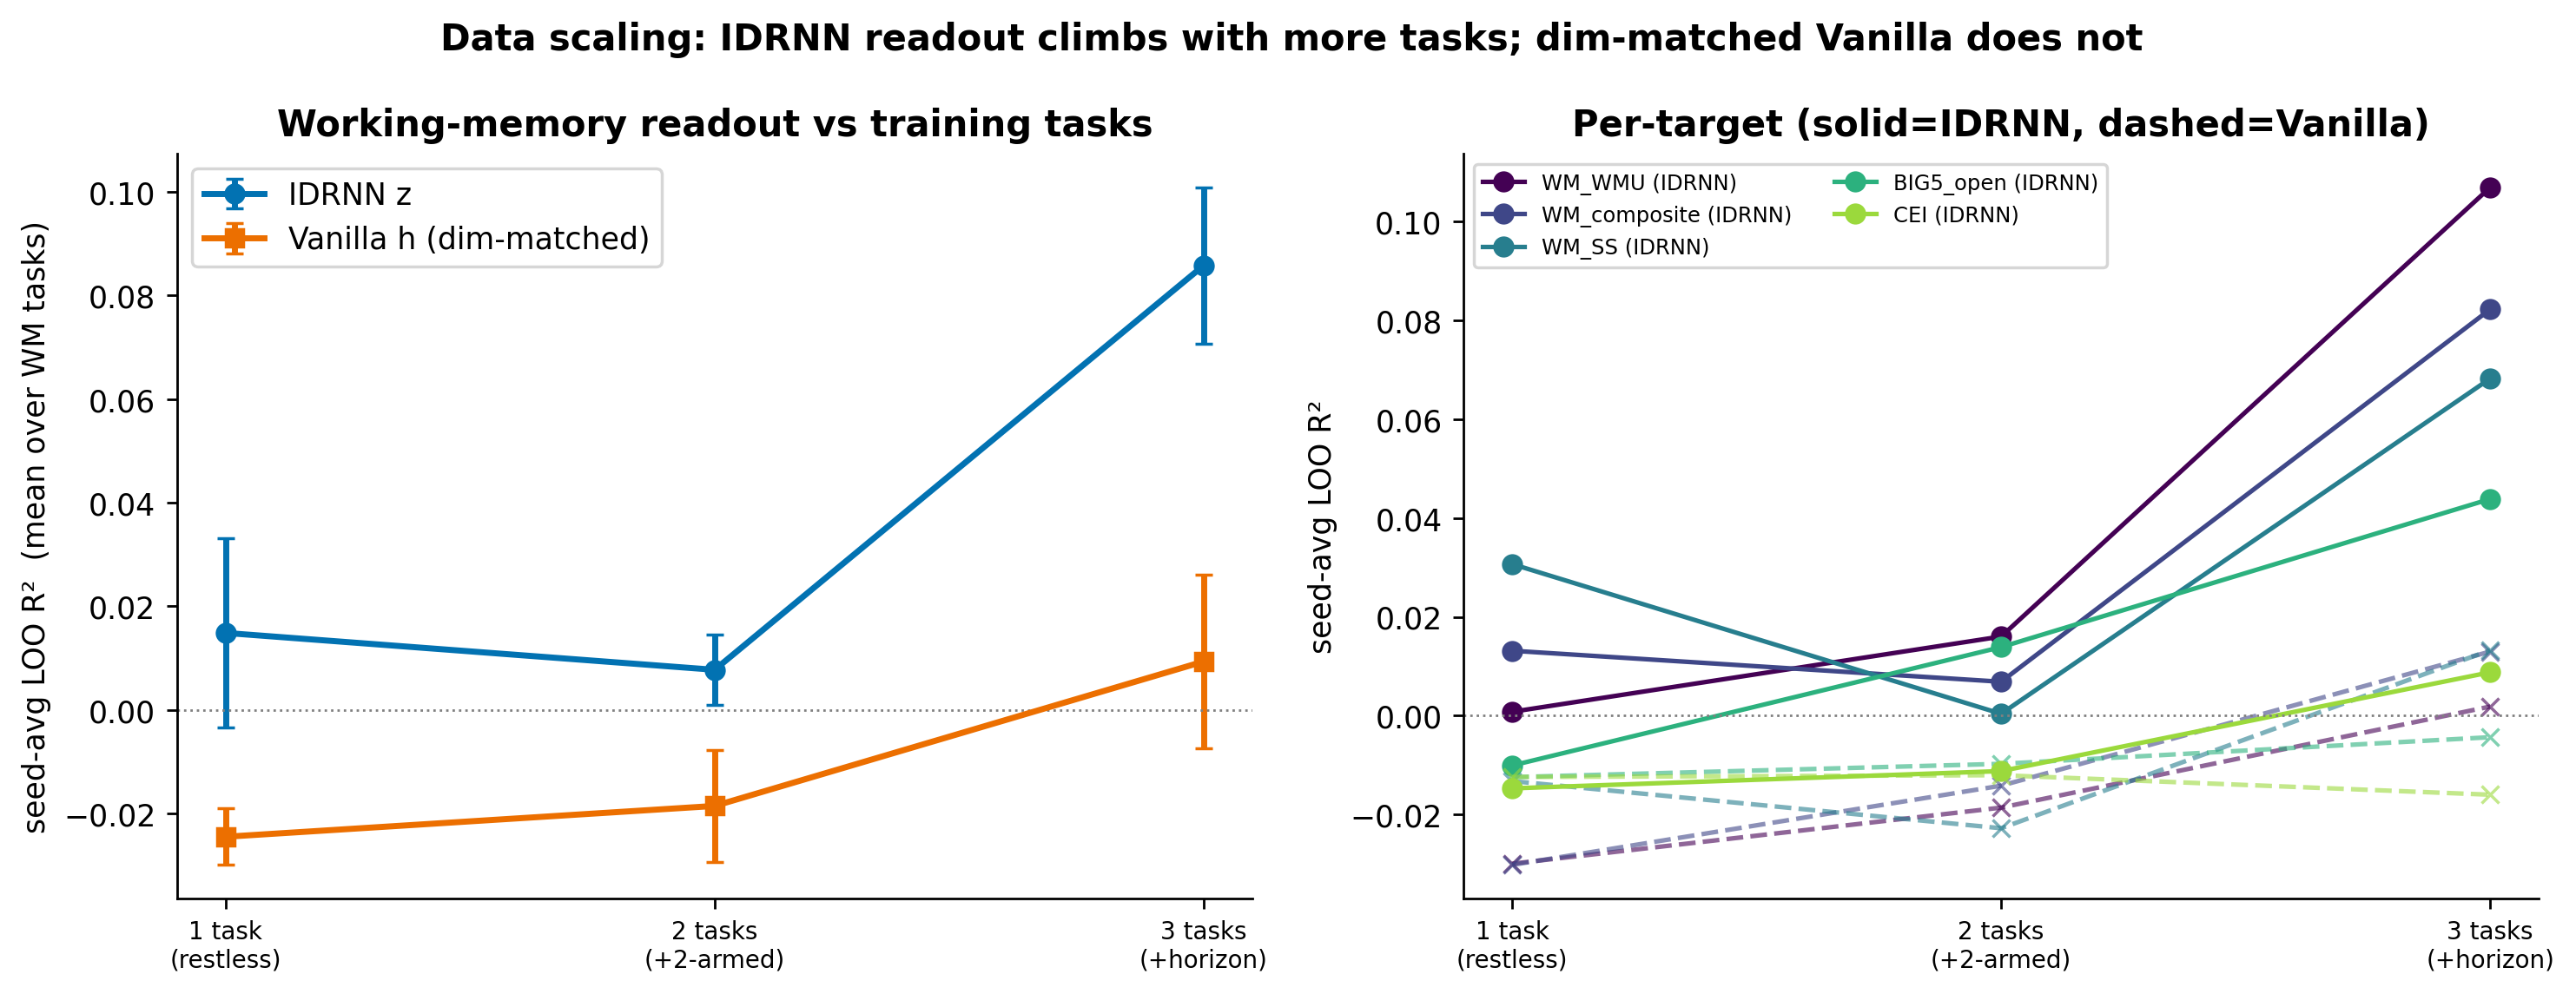

In [17]:
show('final_plots/thalmann_data_scaling.png', 1100)

In [18]:
ds=pd.read_csv('final_plots/thalmann_data_scaling_summary.csv')
for t in ['WM_WMU','WM_composite','WM_SS','BIG5_open','CEI']:
    display(Markdown(f'**{t}** — seed-avg LOO R² (rows=arch, cols=#tasks)'))
    display(ds[ds.target==t].pivot(index='arch',columns='ntasks',values='loo_r2').round(3))

**WM_WMU** — seed-avg LOO R² (rows=arch, cols=#tasks)

ntasks,1,2,3
arch,,,
idrnn,0.001,0.016,0.107
vanilla,-0.030,-0.019,0.002


**WM_composite** — seed-avg LOO R² (rows=arch, cols=#tasks)

ntasks,1,2,3
arch,,,
idrnn,0.013,0.007,0.082
vanilla,-0.030,-0.014,0.013


**WM_SS** — seed-avg LOO R² (rows=arch, cols=#tasks)

ntasks,1,2,3
arch,,,
idrnn,0.031,0.000,0.068
vanilla,-0.013,-0.023,0.013


**BIG5_open** — seed-avg LOO R² (rows=arch, cols=#tasks)

ntasks,1,2,3
arch,,,
idrnn,-0.010,0.014,0.044
vanilla,-0.012,-0.010,-0.004


**CEI** — seed-avg LOO R² (rows=arch, cols=#tasks)

ntasks,1,2,3
arch,,,
idrnn,-0.015,-0.011,0.009
vanilla,-0.012,-0.012,-0.016


## 9. Conclusions
1. **Only IDRNN carries generalisable individual-difference signal** (LOO R²>0), concentrated on **working memory + openness**; robust across 10 seeds; Vanilla 0/14.
2. **Generative validity**: counterfactual regret (R4) predicts held-out **horizon** regret (task0 r≈+0.43) **and working memory** (r≈−0.22) — and survives environment marginalisation, arguing against a fixed-schedule artifact.
3. **Both sessions** strengthen the cross-task transfer; decoding readout is similar.
4. Affect/mood/depression show no generalisable signal in any readout.
5. **Adding the horizon (exploration) task to training markedly strengthens the WM + openness readout** (e.g. WM-updating LOO R² +0.018→+0.107, 100% of seeds positive) — and this gain is **IDRNN-specific**: the dim-matched vanilla barely moves (WM-updating −0.009→+0.002), so it is the individual-difference bottleneck, not just more data, that isolates the signal.
6. **Data scaling**: across the 1→2→3-task ladder the IDRNN WM readout climbs (mean WM LOO R² +0.015→+0.008→+0.086; WM-updating 0.001→0.016→0.107) while the dim-matched Vanilla stays flat near 0 (−0.024→−0.019→+0.009) — IDRNN exploits more (informative) data, Vanilla cannot.

## Representational data-scaling — IDRNN readout climbs with #tasks
Decoding **LOO $R^2$** (leave-one-out, out-of-sample) of working-memory and openness from the IDRNN latent vs a dim-matched vanilla hidden state, as #training tasks grows (all 7 subsets of {2-armed, restless, horizon}, pooled S1+S2). IDRNN climbs; the dim-matched vanilla stays flat near 0.

In [ ]:
# ── Representational data-scaling: IDRNN trait/WM readout climbs with more tasks ──
# Leakage-free per-fold pipeline, EXACT same philosophy as the main LOO-R² panel
# (compute_loo_r2_canonical_bf.py + compute_loo_r2_traintest_bootstrap_perfold.py):
#   point     = canonical LOO R² per task constellation (per-fold PCA dim-match on raw
#               vanilla h, per-fold standardisation, per-fold RidgeCV α — all fit on
#               train rows only; ŷ seed-averaged over 10 seeds; WM = mean over 3 traits)
#   error bar = SD of the train-resample bootstrap (B=500, T shared across seeds/traits)
#   bold line = mean of the constellation means per #tasks (≤3 constellations → no bar)
# One-sided correlation BF10 + permutation p per (constellation, trait) are computed in
# datascaling_canonical_bf.csv but NOT annotated here. Produced by
# compute_datascaling_perfold.sbatch → final_plots/thalmann_z3_datascaling/datascaling_panel.csv
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from nature_plot_style import nature_colors

plt.rcParams.update({
    "pdf.fonttype": 42, "font.family": "sans-serif",
    "font.sans-serif": ["Nimbus Sans", "DejaVu Sans"],
    "font.size": 8, "axes.titlesize": 8, "axes.titleweight": "bold",
    "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7, "legend.frameon": False, "axes.linewidth": 1,
    "axes.spines.top": False, "axes.spines.right": False,
})
COL_IDRNN, COL_VANILLA, COL_TRUE = "#132551", "#f59e57", nature_colors['Grey'][5]

PANELS = [("Working-memory readout", "wm"), ("Openness readout", "openness")]

def draw(ax, grp, title):
    _ds = pd.read_csv("final_plots/thalmann_z3_datascaling/datascaling_panel.csv")
    _ds = _ds[_ds.group == grp]
    for arch, col, off, ls, mk, lab in [("idrnn", COL_IDRNN, -0.12, "-", "o", "IDRNN z"),
                                        ("vanilla", COL_VANILLA, +0.12, "--", "s", "Vanilla h (dim-matched)")]:
        _a = _ds[_ds.arch == arch]; _mx, _my = [], []
        for _K in (1, 2, 3):
            _ck = _a[_a.ntasks == _K].reset_index(drop=True); _m = len(_ck)
            for _j in range(_m):  # constellation: canonical R² ± train-resample bootstrap SD
                ax.errorbar(_K + off + (_j - (_m - 1) / 2) * 0.06, _ck.canonical_r2[_j], yerr=_ck.boot_sd[_j],
                            fmt=mk, ms=3, color=col, alpha=0.45, elinewidth=0.6, capsize=1.2, zorder=2)
            _mx.append(_K + off); _my.append(float(_ck.canonical_r2.mean()))
        ax.plot(_mx, _my, ls=ls, color=col, lw=1.7, zorder=3)                       # mean-of-means climb line
        ax.plot(_mx[:2], _my[:2], ls="none", marker=mk, color=col, ms=6, zorder=4, label=lab)  # (#tasks 1,2 only)
    ax.axhline(0, color=COL_TRUE, lw=.6, ls=":")
    ax.set_xticks([1, 2, 3]); ax.set_xlabel("# training tasks")
    ax.set_ylabel("decoding LOO $R^2$"); ax.set_title(title); ax.legend(loc="upper left")

for title, grp in PANELS:
    fig, ax = plt.subplots(figsize=(3.6, 3.0))
    draw(ax, grp, title)
    fig.tight_layout()
    fig.savefig(f"final_plots/thalmann_z3_datascaling/repr_climb_{grp}.png",
                    dpi=600, bbox_inches="tight")
    plt.show()

## In-sample decodability — multiple R (IDRNN z vs dim-matched vanilla)
Top-left of the 4-metric grid, on its own. In-sample multiple R regressing each trait on the 3 latent dims; IDRNN z vs PCA-dim-matched vanilla h. Grey band = k=3 chance.

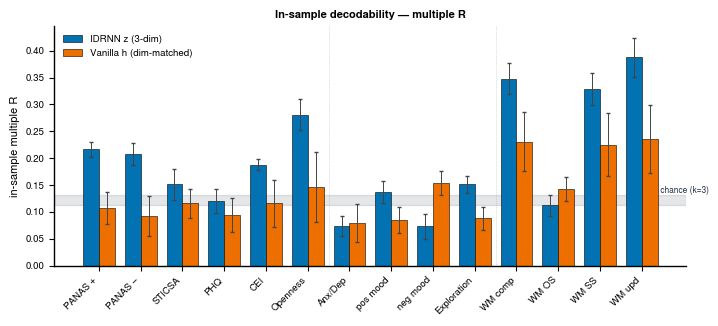

In [3]:
# === panel — in-sample multiple-R (IDRNN z vs dim-matched vanilla h) ===
import os, numpy as np, pandas as pd
FULL = "final_plots/thalmann_z3_3task_full"   # 3-task fit (cell-8b data)
PERSONALITY = ["PANAS_PA","PANAS_NA","STICSA","PHQ","CEI","BIG5_open"]
COMPOSITE   = ["AxDep","posMood","negMood","Exp"]
WM_KEYS     = ["WM_composite","WM_OS","WM_SS","WM_WMU"]
ALL_KEYS    = PERSONALITY + COMPOSITE + WM_KEYS
LBL = {"PANAS_PA":"PANAS +","PANAS_NA":"PANAS −","STICSA":"STICSA","PHQ":"PHQ","CEI":"CEI",
       "BIG5_open":"Openness","AxDep":"Anx/Dep","posMood":"pos mood","negMood":"neg mood",
       "Exp":"Exploration","WM_composite":"WM comp","WM_OS":"WM OS","WM_SS":"WM SS","WM_WMU":"WM upd"}
labels = [LBL[k] for k in ALL_KEYS]
x = np.arange(len(labels)); w = 0.38

df = pd.read_csv(f"{FULL}/decoding/seed_averaged_decoding.csv").set_index("target").reindex(ALL_KEYS)
fig, ax = plt.subplots(figsize=(7.2, 3.3))
ax.bar(x - w/2, df["idrnn_pearson_mean"], w, yerr=df["idrnn_pearson_sd"], color=COL_IDRNN,
       edgecolor="black", linewidth=0.4, capsize=1.5, error_kw=dict(elinewidth=0.7, ecolor="#444444"),
       label="IDRNN z (3-dim)", zorder=2)
ax.bar(x + w/2, df["vanilla_pearson_mean"], w, yerr=df["vanilla_pearson_sd"], color=COL_VANILLA,
       edgecolor="black", linewidth=0.4, capsize=1.5, error_kw=dict(elinewidth=0.7, ecolor="#444444"),
       label="Vanilla h (dim-matched)", zorder=2)
# in-sample multiple-R null E[R]~sqrt(k/(n-1)), k=3; n=236 (personality) .. 175 (WM)
ax.axhspan(np.sqrt(3/235), np.sqrt(3/174), color=COL_TRUE, alpha=0.12, zorder=0)
ax.text(len(labels)+0.6, np.sqrt(3/174), " chance (k=3)", va="bottom", ha="right", fontsize=6, color=COL_TRUE)
for xb in (len(PERSONALITY)-.5, len(PERSONALITY)+len(COMPOSITE)-.5):
    ax.axvline(xb, color="grey", lw=.5, ls=":", alpha=.5)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("in-sample multiple R"); ax.legend(loc="upper left")
ax.set_title("In-sample decodability — multiple R")
fig.tight_layout(); fig.savefig(f"{FULL}/decoding/panel_multiple_R.png", dpi=600, bbox_inches="tight"); plt.show()

## Out-of-sample readout — LOO r (IDRNN vs dim-matched vanilla)
Bottom-left of the 4-metric grid. Leave-one-out pred-vs-target correlation (negative = no generalizable structure). IDRNN is positive for WM + openness; dim-matched vanilla is ~0/negative.

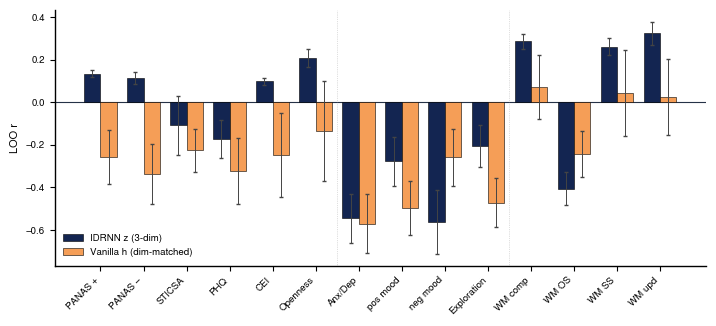

In [30]:
# === panel — LOO pred-vs-target r (IDRNN vs dim-matched vanilla) ===
import os, numpy as np, pandas as pd
FULL = "final_plots/thalmann_z3_3task_full"   # 3-task fit (cell-8b data)
PERSONALITY = ["PANAS_PA","PANAS_NA","STICSA","PHQ","CEI","BIG5_open"]
COMPOSITE   = ["AxDep","posMood","negMood","Exp"]
WM_KEYS     = ["WM_composite","WM_OS","WM_SS","WM_WMU"]
ALL_KEYS    = PERSONALITY + COMPOSITE + WM_KEYS
LBL = {"PANAS_PA":"PANAS +","PANAS_NA":"PANAS −","STICSA":"STICSA","PHQ":"PHQ","CEI":"CEI",
       "BIG5_open":"Openness","AxDep":"Anx/Dep","posMood":"pos mood","negMood":"neg mood",
       "Exp":"Exploration","WM_composite":"WM comp","WM_OS":"WM OS","WM_SS":"WM SS","WM_WMU":"WM upd"}
labels = [LBL[k] for k in ALL_KEYS]
x = np.arange(len(labels)); w = 0.38

df = pd.read_csv(f"{FULL}/decoding/seed_averaged_decoding.csv").set_index("target").reindex(ALL_KEYS)
fig, ax = plt.subplots(figsize=(7.2, 3.3))
ax.bar(x - w/2, df["idrnn_loo_r_mean"], w, yerr=df["idrnn_loo_r_sd"], color=COL_IDRNN,
       edgecolor="black", linewidth=0.4, capsize=1.5, error_kw=dict(elinewidth=0.7, ecolor="#444444"),
       label="IDRNN z (3-dim)", zorder=2)
ax.bar(x + w/2, df["vanilla_loo_r_mean"], w, yerr=df["vanilla_loo_r_sd"], color=COL_VANILLA,
       edgecolor="black", linewidth=0.4, capsize=1.5, error_kw=dict(elinewidth=0.7, ecolor="#444444"),
       label="Vanilla h (dim-matched)", zorder=2)
ax.axhline(0, color=COL_TRUE, lw=0.8, zorder=1)
for xb in (len(PERSONALITY)-.5, len(PERSONALITY)+len(COMPOSITE)-.5):
    ax.axvline(xb, color="grey", lw=.5, ls=":", alpha=.5)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("LOO r"); ax.legend(loc="lower left")
#ax.set_title("Out-of-sample readout — LOO r  (negative = no generalizable signal)")
fig.tight_layout(); fig.savefig(f"{FULL}/decoding/panel_loo_r.png", dpi=600, bbox_inches="tight"); plt.show()

## Latent dimension z2 — the individual-difference axis
Pearson r of the single latent dim z2 with every questionnaire/WM score. z2 is consistently the trait axis: strong for WM (≈−0.35) and openness (+0.21).

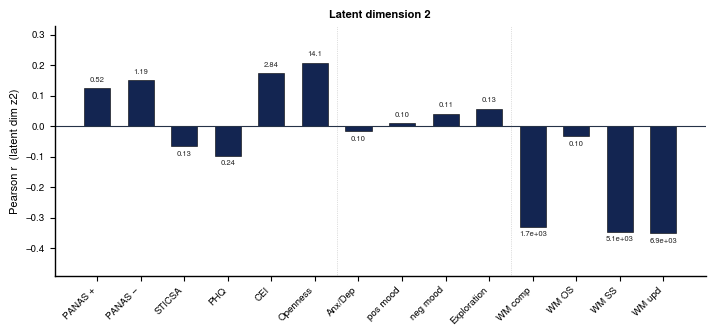

In [37]:
# === panel — latent dimension z2 correlations with every trait ===
import os, numpy as np, pandas as pd
FULL = "final_plots/thalmann_z3_3task_full"   # 3-task fit (cell-8b data)
PERSONALITY = ["PANAS_PA","PANAS_NA","STICSA","PHQ","CEI","BIG5_open"]
COMPOSITE   = ["AxDep","posMood","negMood","Exp"]
WM_KEYS     = ["WM_composite","WM_OS","WM_SS","WM_WMU"]
ALL_KEYS    = PERSONALITY + COMPOSITE + WM_KEYS
LBL = {"PANAS_PA":"PANAS +","PANAS_NA":"PANAS −","STICSA":"STICSA","PHQ":"PHQ","CEI":"CEI",
       "BIG5_open":"Openness","AxDep":"Anx/Dep","posMood":"pos mood","negMood":"neg mood",
       "Exp":"Exploration","WM_composite":"WM comp","WM_OS":"WM OS","WM_SS":"WM SS","WM_WMU":"WM upd"}
labels = [LBL[k] for k in ALL_KEYS]
x = np.arange(len(labels)); w = 0.38

df = pd.read_csv(f"{FULL}/decoding/idrnn_latent_correlations.csv").set_index("target").reindex(ALL_KEYS)
r = df["z2_pearson_r"].values; n = df["n"].values.astype(int)
bf = [float(bayesfactor_pearson(rr, int(nn))) for rr, nn in zip(r, n)]   # JZS BF per correlation
fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.bar(x, r, 0.6, color=COL_IDRNN, edgecolor="black", linewidth=0.4, zorder=2)   # all blue = IDRNN z2
ax.axhline(0, color=COL_TRUE, lw=0.8)
for i, (v, b) in enumerate(zip(r, bf)):                                  # report Bayes factors, not stars
    ax.text(x[i], v + (0.015 if v >= 0 else -0.015), fmt_bf(b).replace("BF=", ""), ha="center",
            va="bottom" if v >= 0 else "top", fontsize=5.5, color="#222222")
for xb in (len(PERSONALITY)-.5, len(PERSONALITY)+len(COMPOSITE)-.5):
    ax.axvline(xb, color="grey", lw=.5, ls=":", alpha=.5)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax.set_ylim(min(r)-0.14, max(r)+0.12)
ax.set_ylabel("Pearson r  (latent dim z2)")
ax.set_title("Latent dimension 2")
fig.tight_layout(); fig.savefig(f"{FULL}/decoding/panel_z2_correlations.png", dpi=600, bbox_inches="tight"); plt.show()

## Openness — 41× increase in evidence over the original study
The original study's strongest Openness↔task-measure correlation was r=0.11 (BF₁₀=0.34, favoring the null). The IDRNN latent z2 gives r=0.21 (BF₁₀≈14, ×42) — a ~42× increase, flipping from no evidence to strong evidence (n=236).

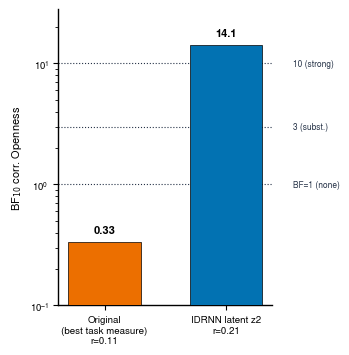

openness: original r=0.11 BF=0.33 | ours r=0.208 BF=14.07 | ratio 42x


In [ ]:
# === panel — openness evidence: IDRNN latent vs original study's best task measure ===
import os, numpy as np, pandas as pd
FULL = "final_plots/thalmann_z3_3task_full"
N_OPEN = 236
R_ORIG = 0.11   # original study: strongest Openness x task-measure across their 13 measures
r_ours = float(pd.read_csv(f"{FULL}/decoding/idrnn_latent_correlations.csv")
               .set_index("target").loc["BIG5_open", "z2_pearson_r"])      # IDRNN latent z2
bf_orig = float(bayesfactor_pearson(R_ORIG, N_OPEN))
bf_ours = float(bayesfactor_pearson(r_ours, N_OPEN))
labels = [f"Original\n(best task measure)\nr={R_ORIG:.2f}", f"IDRNN latent z2\nr={r_ours:.2f}"]
vals = [bf_orig, bf_ours]; cols = [COL_VANILLA, COL_IDRNN]
fig, ax = plt.subplots(figsize=(3.6, 3.6))
ax.bar([0, 1], vals, 0.6, color=cols, edgecolor="black", linewidth=0.5, zorder=3)
for thr, lab in [(1, "BF=1 (none)"), (3, "3 (subst.)"), (10, "10 (strong)")]:
    ax.axhline(thr, ls=":", color=COL_TRUE, lw=0.8, zorder=1)
    ax.text(1.55, thr, lab, va="center", ha="left", fontsize=6, color=COL_TRUE)
for i, v in enumerate(vals):
    ax.text(i, v*1.15, fmt_bf(v).replace("BF=", ""), ha="center", va="bottom", fontsize=8, fontweight="bold")
#ax.annotate(f"×{bf_ours/bf_orig:.0f} evidence", xy=(0.5, bf_ours), ha="center", va="bottom",
#            fontsize=8, color=COL_IDRNN, fontweight="bold", xytext=(0.5, bf_ours*2.2),
#            arrowprops=None)
ax.set_yscale("log"); ax.set_ylim(0.1, max(vals)*2)
ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel("BF$_{10}$ corr. Openness")
#ax.set_title("Openness: undetectable → strong\n(BF favoring null → strong evidence)")
fig.tight_layout(); fig.savefig(f"{FULL}/decoding/panel_openness_evidence.png", dpi=600, bbox_inches="tight"); plt.show()
print(f"openness: original r={R_ORIG} BF={bf_orig:.2f} | ours r={r_ours:.3f} BF={bf_ours:.2f} | ratio {bf_ours/bf_orig:.0f}x")

## z2 is the explore/exploit axis — directed switching, not randomness
**Left:** the latent z2 tracks each subject's overall **switch rate** (r=0.64, BF≈10²⁴) — high z2 = exploratory (switches a lot), low z2 = exploitative (sticks). **Right:** the partial correlation of z2 with switch rate **controlling for choice entropy**, per task — z2 still tracks switching after removing choice randomness, in every task (strongest in the horizon exploration task). So z2 captures *directed* exploration, not stochastic responding — which is why it loads negatively on WM (control→exploit) and positively on openness/curiosity (novelty→explore).

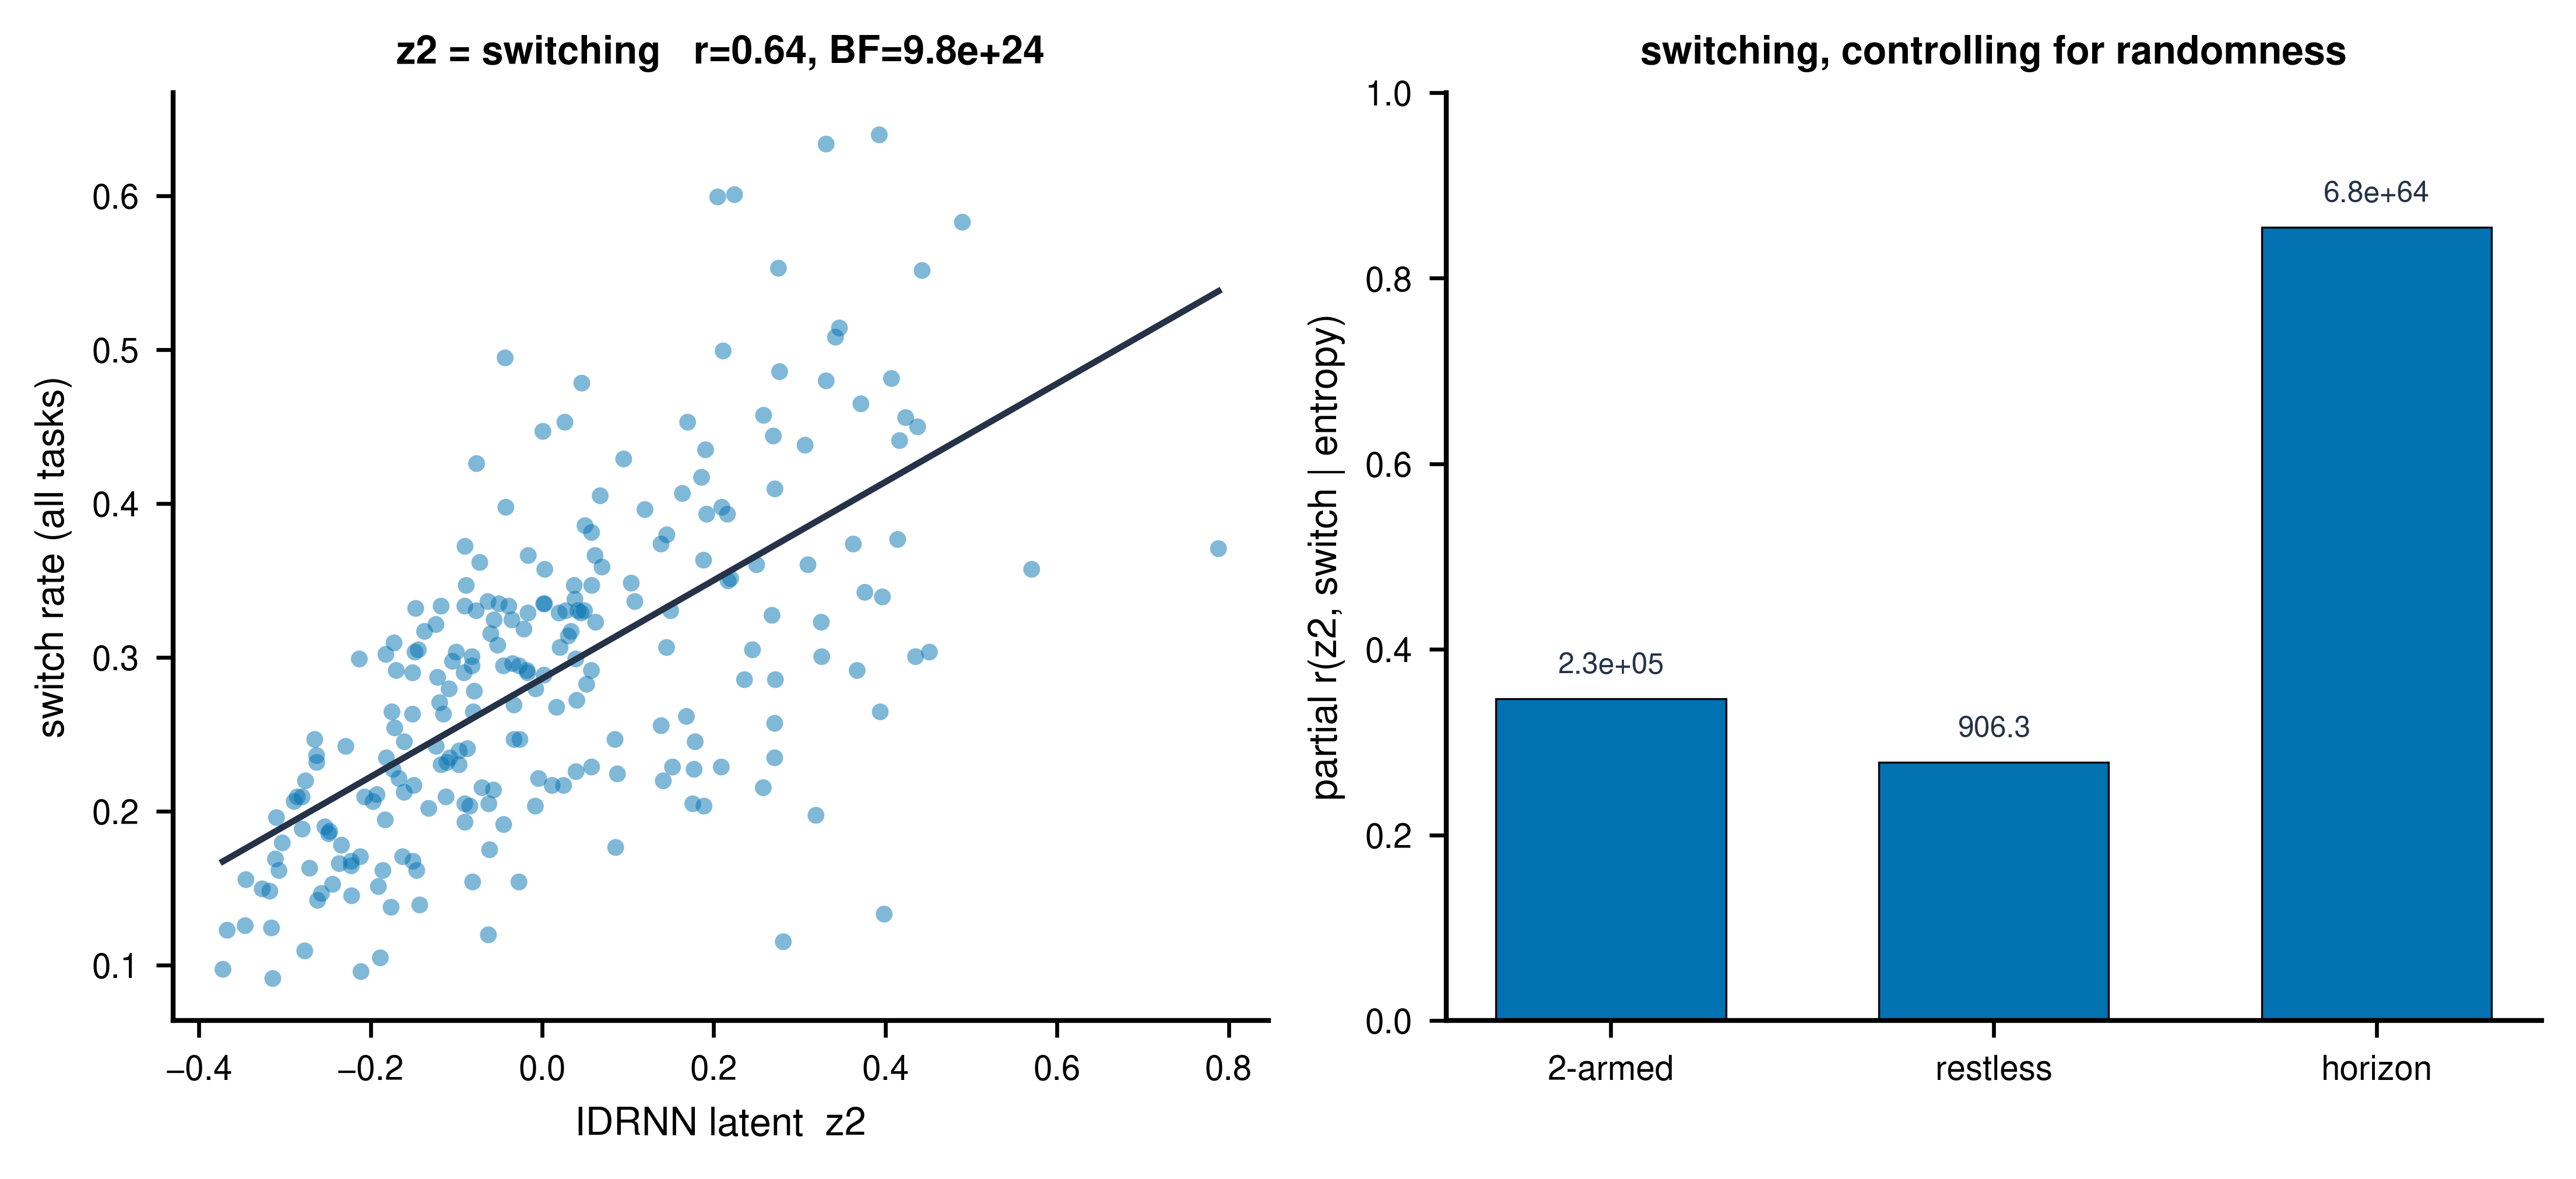

In [ ]:
# === panel — z2 is the explore/exploit (switching) axis, not randomness ===
import os, numpy as np, pandas as pd, pingouin as pg
from scipy.stats import pearsonr
FULL = "final_plots/thalmann_z3_3task_full"
z2  = np.load(f"{FULL}/canonical/idrnn/latents_train_step1.npy")[:, 2]      # IDRNN latent dim 2
c   = np.load("data_thalmann_3task_full/c_train.npy")                       # (236,111,200) choices (-100=pad/forced)
tid = np.load("data_thalmann_3task_full/task_ids_per_block.npy")
N = c.shape[0]

def switch_rate(bl):
    s = p = 0
    for b in range(bl.shape[0]):
        ch = bl[b]; ch = ch[ch >= 0]
        if len(ch) < 2: continue
        s += int((ch[1:] != ch[:-1]).sum()); p += len(ch) - 1
    return s / p if p else np.nan

def entropy(bl, k):
    ch = bl[bl >= 0].astype(int)
    if len(ch) == 0: return np.nan
    pr = np.bincount(ch, minlength=k) / len(ch); pr = pr[pr > 0]
    return float(-(pr * np.log(pr)).sum())

TASKS = [("2-armed", tid == 0, 2), ("restless", tid == 1, 4), ("horizon", tid == 2, 2)]
SW = {t: np.array([switch_rate(c[i][m]) for i in range(N)]) for t, m, k in TASKS}
EN = {t: np.array([entropy(c[i][m], k) for i in range(N)]) for t, m, k in TASKS}
sw_all = np.array([switch_rate(c[i]) for i in range(N)])
en_all = np.array([entropy(c[i], 4) for i in range(N)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.4, 3.4))
# (left) z2 vs overall switch rate
r, _ = pearsonr(z2, sw_all); bf = float(bayesfactor_pearson(r, N))
ax1.scatter(z2, sw_all, s=12, color=COL_IDRNN, alpha=0.5, edgecolors="none", zorder=2)
b = np.polyfit(z2, sw_all, 1); xs = np.linspace(z2.min(), z2.max(), 50)
ax1.plot(xs, b[0]*xs + b[1], color=COL_TRUE, lw=1.3, zorder=3)
ax1.set_xlabel("IDRNN latent  z2"); ax1.set_ylabel("switch rate (all tasks)")
ax1.set_title(f"z2 = switching   r={r:.2f}, {fmt_bf(bf)}")
# (right) per-task PARTIAL r(z2, switch | entropy): switching beyond randomness
xt = np.arange(len(TASKS))
prs, bfs = [], []
for t, m, k in TASKS:
    d = pd.DataFrame({"z2": z2, "switch": SW[t], "entropy": EN[t]}).dropna()
    r = float(pg.partial_corr(d, x="z2", y="switch", covar="entropy")["r"].values[0])
    prs.append(r); bfs.append(float(bayesfactor_pearson(r, len(d) - 1)))
ax2.bar(xt, prs, 0.6, color=COL_IDRNN, edgecolor="black", lw=0.4, zorder=2)
ax2.axhline(0, color=COL_TRUE, lw=0.8)
for i, (r, bf) in enumerate(zip(prs, bfs)):
    ax2.text(xt[i], r + 0.02, fmt_bf(bf).replace("BF=", ""), ha="center", va="bottom", fontsize=6, color=COL_TRUE)
ax2.set_xticks(xt); ax2.set_xticklabels([t for t, _, _ in TASKS])
ax2.set_ylabel("partial r(z2, switch | entropy)"); ax2.set_ylim(top=1.0)
ax2.set_title("switching, controlling for randomness")
fig.tight_layout(); fig.savefig(f"{FULL}/decoding/panel_z2_switching.png", dpi=600, bbox_inches="tight"); plt.show()
# partial correlation: does switching predict z2 independent of entropy?
dfp = pd.DataFrame({"z2": z2, "switch": sw_all, "entropy": en_all}).dropna()
pr = pg.partial_corr(dfp, x="z2", y="switch", covar="entropy")
print("r(z2,switch):", {t: round(float(pearsonr(z2, SW[t])[0]), 3) for t, _, _ in TASKS},
      "| all", round(r, 3))
print("r(z2,entropy):", {t: round(re[i], 3) for i, (t, _, _) in enumerate(TASKS)})
print(f"partial r(z2,switch | entropy) = {pr['r'].values[0]:+.3f}  p={pr['p-val'].values[0]:.1e}"
      f"  -> switching predicts z2 independent of randomness")

## Trait signal beyond working memory — openness/curiosity are not a WM confound
Raw vs **WM-partialled** correlation of openness and curiosity with the exploration latent z2 (n=175). **Both survive controlling for working memory** (openness +0.20, curiosity +0.21, p<.01) — genuine individual-difference variance the behavioural axis captures *beyond* cognitive ability, directly addressing the original study's worry that exploration measures are merely a WM confound. (Working memory and openness/curiosity are themselves nearly uncorrelated, so these are separable sources, not a redundant signal.)

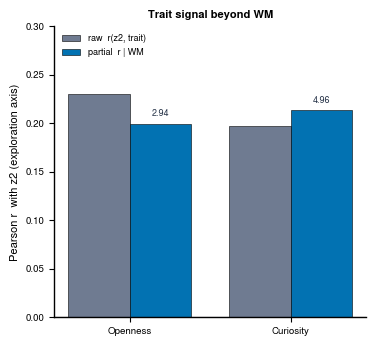

raw : {'Openness': 0.23, 'Curiosity': 0.197}
|WM : {'Openness': 0.199, 'Curiosity': 0.213}  BF: [2.94, 4.96]
r(WM,open)=-0.134 r(WM,CEI)=+0.013


In [ ]:
# === panel — exploration-axis trait correlates, raw vs controlling for WM ===
import numpy as np, pandas as pd, pingouin as pg
FULL = "final_plots/thalmann_z3_3task_full"
z2 = np.load(f"{FULL}/canonical/idrnn/latents_train_step1.npy")[:, 2]
tg = pd.read_csv(f"{FULL}/decoding/trait_targets.csv")   # torch-free; rows aligned to z2 (subids_full order)
TRAITS = [("BIG5_open", "Openness"), ("CEI", "Curiosity")]
df = pd.DataFrame({"z2": z2, "WM": tg["WM_composite"].values,
                   **{k: tg[k].values for k, _ in TRAITS}}).dropna()
n = len(df)
raw, par, bfs = [], [], []
for k, _ in TRAITS:
    raw.append(float(pg.corr(df["z2"], df[k])["r"].values[0]))
    rp = float(pg.partial_corr(df, x="z2", y=k, covar="WM")["r"].values[0])
    par.append(rp); bfs.append(float(bayesfactor_pearson(rp, n - 1)))   # BF on the WM-adjusted r

x = np.arange(len(TRAITS)); w = 0.38; GREY = nature_colors['Grey'][3]
fig, ax = plt.subplots(figsize=(3.8, 3.5))
ax.bar(x - w/2, raw, w, color=GREY, edgecolor="black", lw=0.4, label="raw  r(z2, trait)", zorder=2)
ax.bar(x + w/2, par, w, color=COL_IDRNN, edgecolor="black", lw=0.4, label="partial  r | WM", zorder=2)
ax.axhline(0, color=COL_TRUE, lw=0.8)
for i, (rp, bf) in enumerate(zip(par, bfs)):
    ax.text(x[i] + w/2, rp + (0.006 if rp >= 0 else -0.012), fmt_bf(bf).replace("BF=", ""),
            ha="center", va="bottom" if rp >= 0 else "top", fontsize=6.5, color=COL_TRUE)
ax.set_xticks(x); ax.set_xticklabels([l for _, l in TRAITS])
ax.set_ylim(top=0.30)
ax.set_ylabel("Pearson r  with z2 (exploration axis)")
ax.legend(loc="upper left", fontsize=6.5)
ax.set_title(f"Trait signal beyond WM")
fig.tight_layout(); fig.savefig('final_plots/thalmann_z3_3task_full/decoding/panel_partial_wm.png', dpi=600, bbox_inches="tight"); plt.show()
print("raw :", {l: round(r, 3) for (_, l), r in zip(TRAITS, raw)})
print("|WM :", {l: round(r, 3) for (_, l), r in zip(TRAITS, par)}, " BF:", [round(b, 2) for b in bfs])
print(f"r(WM,open)={pg.corr(df['WM'],df['BIG5_open'])['r'].values[0]:+.3f} "
      f"r(WM,CEI)={pg.corr(df['WM'],df['CEI'])['r'].values[0]:+.3f}")

## The latent extracts an openness signal that behavioural summaries miss
**Left:** openness correlates ~0 with an overall switch-rate summary, modestly with horizon switching, and most strongly with the IDRNN latent z2 — the model learns *which* switching carries the trait signal (it weights directed/horizon exploration). **Right:** z2 predicts openness even after removing raw switching (partial r≈+0.26), whereas raw switching adds nothing beyond z2 (≈−0.13, n.s.). So the openness link was *accessible* in the behaviour but was discarded by conventional summary statistics — the model-based latent recovers it.

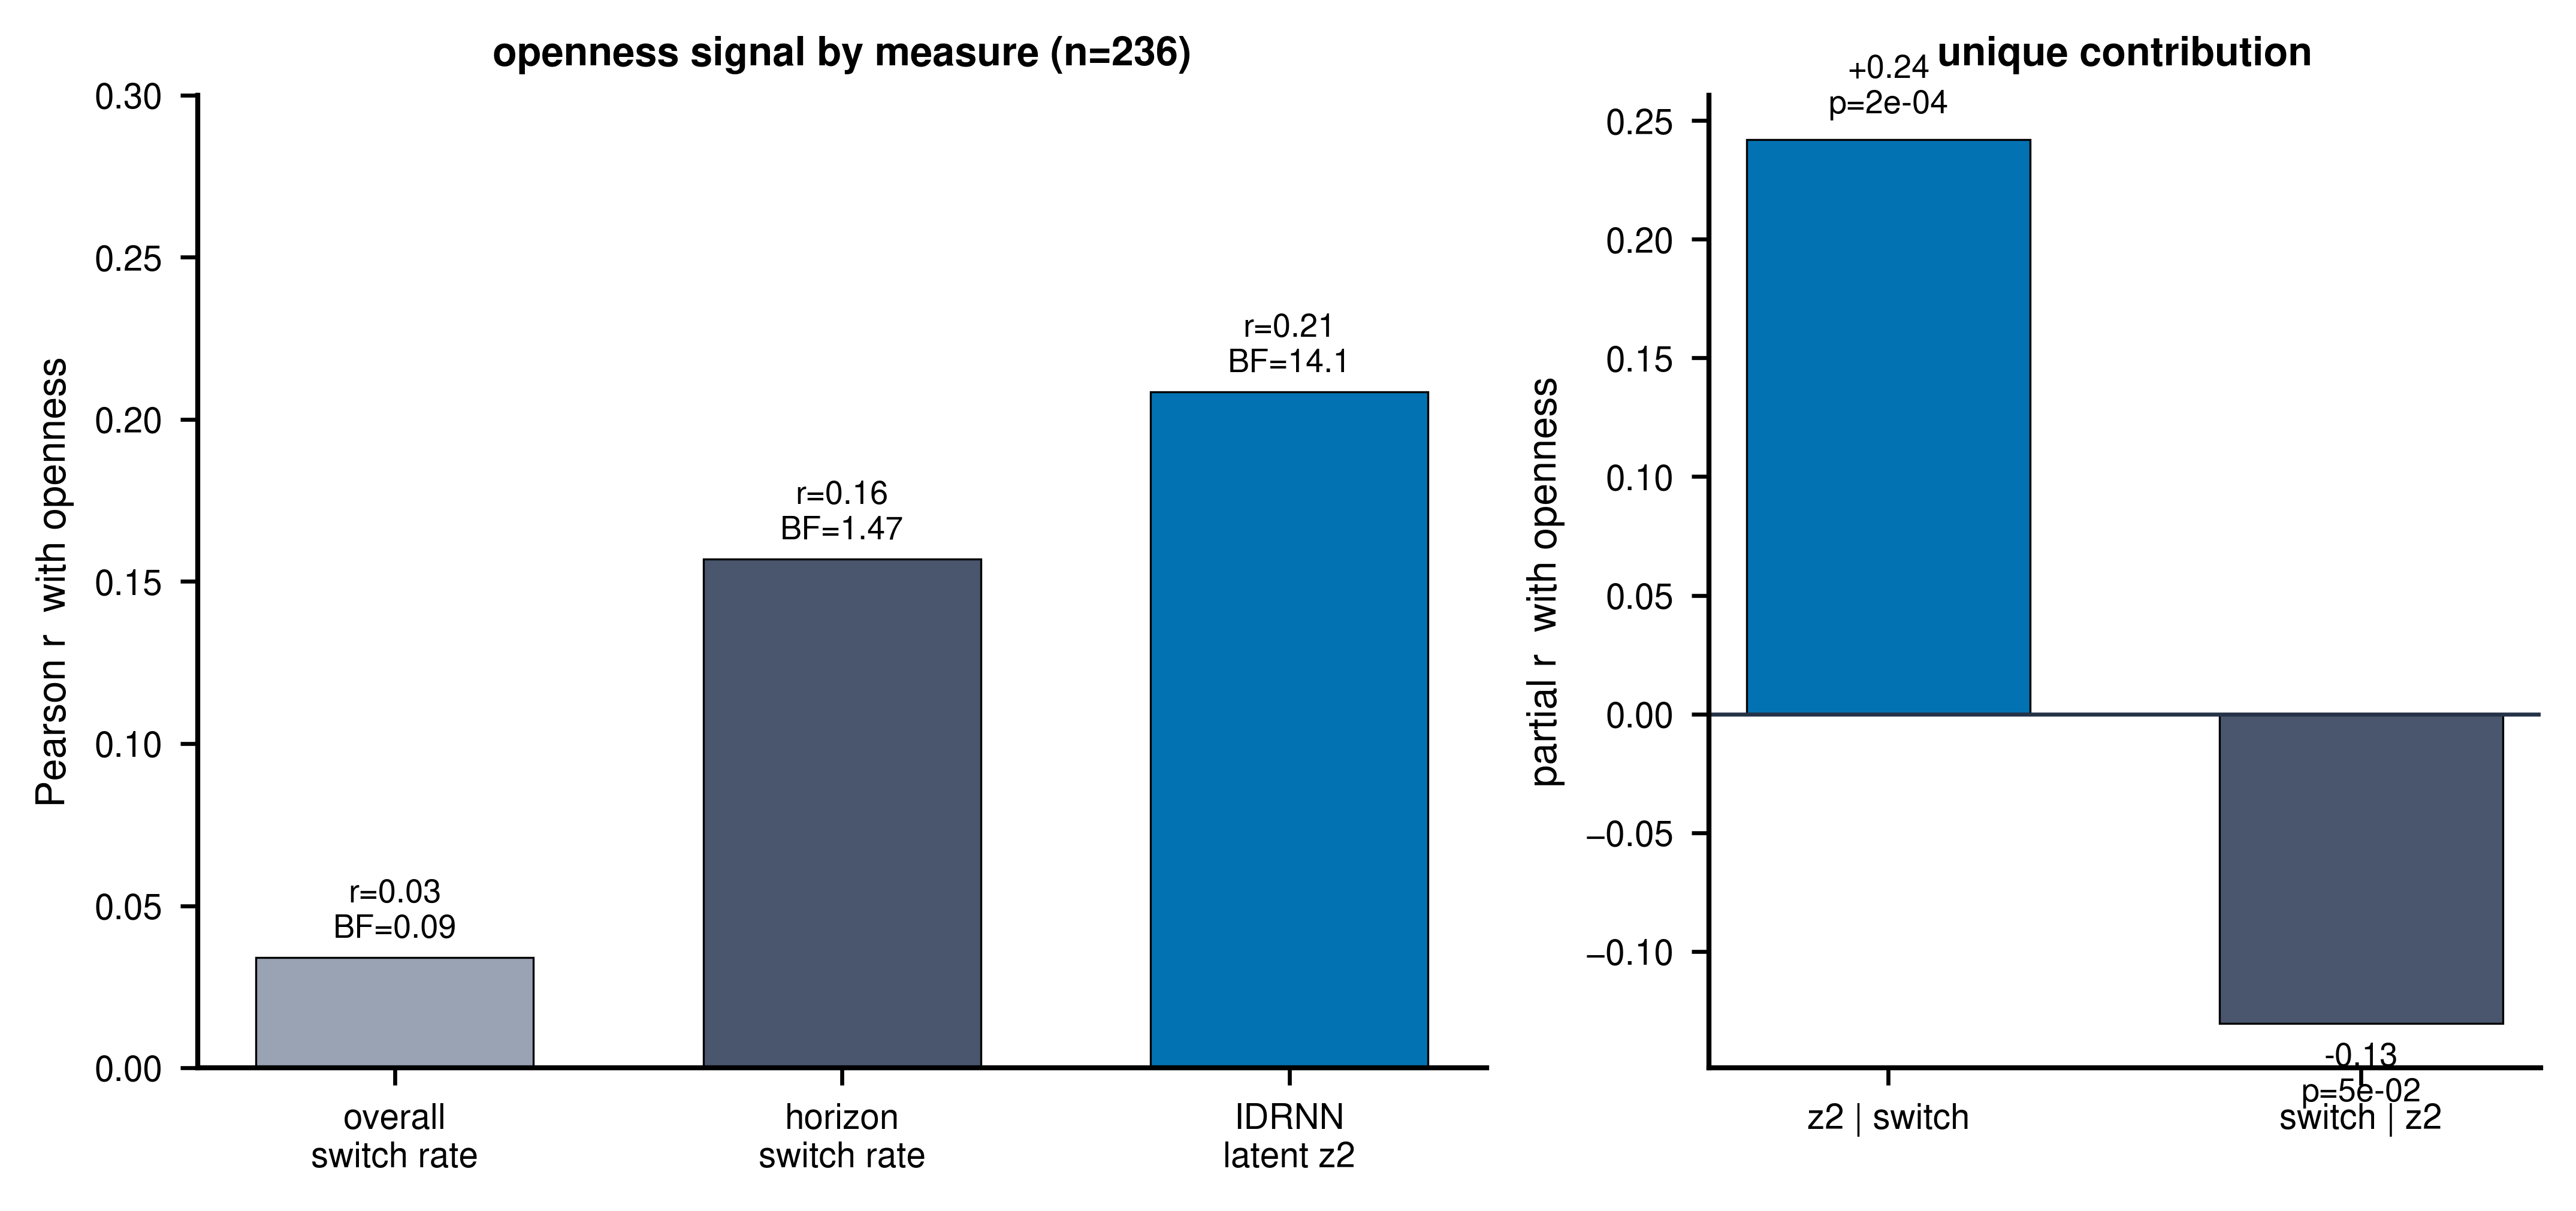

In [ ]:
# === panel — the latent extracts openness that behavioural summaries miss ===
import numpy as np, pandas as pd, pingouin as pg
FULL = "final_plots/thalmann_z3_3task_full"
z2 = np.load(f"{FULL}/canonical/idrnn/latents_train_step1.npy")[:, 2]
c = np.load("data_thalmann_3task_full/c_train.npy"); tid = np.load("data_thalmann_3task_full/task_ids_per_block.npy")
N = c.shape[0]
def sw(bl):
    s = p = 0
    for b in range(bl.shape[0]):
        ch = bl[b]; ch = ch[ch >= 0]
        if len(ch) < 2: continue
        s += int((ch[1:] != ch[:-1]).sum()); p += len(ch) - 1
    return s / p if p else np.nan
sw_all = np.array([sw(c[i]) for i in range(N)])
sw_h   = np.array([sw(c[i][tid == 2]) for i in range(N)])
op = pd.read_csv(f"{FULL}/decoding/trait_targets.csv")["BIG5_open"].values   # torch-free
df = pd.DataFrame({"z2": z2, "sw": sw_all, "swh": sw_h, "open": op}).dropna(); n = len(df)
def C(a, b): return float(pg.corr(df[a], df[b])["r"].values[0])

GREY2, GREY4 = nature_colors['Grey'][2], nature_colors['Grey'][4]
ITEMS = [("overall\nswitch rate", "sw", GREY2), ("horizon\nswitch rate", "swh", GREY4),
         ("IDRNN\nlatent z2", "z2", COL_IDRNN)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.4), gridspec_kw={"width_ratios": [1.55, 1]})
for i, (lab, k, col) in enumerate(ITEMS):
    r = C(k, "open"); bf = float(bayesfactor_pearson(r, n))
    ax1.bar(i, r, 0.62, color=col, edgecolor="black", lw=0.4, zorder=2)
    ax1.text(i, r + 0.004, f"r={r:.2f}\n{fmt_bf(bf)}", ha="center", va="bottom", fontsize=6.5)
ax1.axhline(0, color=COL_TRUE, lw=0.8)
ax1.set_xticks(range(len(ITEMS))); ax1.set_xticklabels([l for l, _, _ in ITEMS], fontsize=7)
ax1.set_ylabel("Pearson r  with openness"); ax1.set_ylim(top=0.30)
ax1.set_title(f"openness signal by measure (n={n})")
# right: unique contributions (partial r)
pz = pg.partial_corr(df, x="z2", y="open", covar="sw")
ps = pg.partial_corr(df, x="sw", y="open", covar="z2")
vals = [float(pz["r"].values[0]), float(ps["r"].values[0])]
pvs  = [float(pz["p-val"].values[0]), float(ps["p-val"].values[0])]
ax2.bar([0, 1], vals, 0.6, color=[COL_IDRNN, GREY4], edgecolor="black", lw=0.4, zorder=2)
ax2.axhline(0, color=COL_TRUE, lw=0.8)
for i, (v, pp) in enumerate(zip(vals, pvs)):
    ax2.text(i, v + (0.008 if v >= 0 else -0.008), f"{v:+.2f}\np={pp:.0e}", ha="center",
             va="bottom" if v >= 0 else "top", fontsize=6.5)
ax2.set_xticks([0, 1]); ax2.set_xticklabels(["z2 | switch", "switch | z2"], fontsize=7)
ax2.set_ylabel("partial r  with openness"); ax2.set_title("unique contribution")
fig.tight_layout(); fig.savefig('final_plots/thalmann_z3_3task_full/decoding/panel_latent_vs_summary.png', dpi=600, bbox_inches="tight"); plt.show()
print(f"n={n}  r(open): overall-switch={C('sw','open'):+.3f}  horizon-switch={C('swh','open'):+.3f}  z2={C('z2','open'):+.3f}")
print(f"partial r(z2,open|switch)={vals[0]:+.3f} (p={pvs[0]:.1e})   r(switch,open|z2)={vals[1]:+.3f} (p={pvs[1]:.1e})")

# Seed-averaged exploration axis (structure-matched + PCA)
Individual latent dimensions are basis-arbitrary across independent trainings, so the single-seed (canonical 999) panels above can't establish robustness on their own. Here we recompute the exploration-axis trait analysis **across all 10 seeds**. In each seed we select the exploration axis by a **trait-independent** rule — the latent dimension most correlated with **horizon-task switch rate** (the behavioural signature of directed exploration), sign-aligned positive — so the trait read-outs are not circular. The matched dimension is dim 0/1/2 depending on the seed. We cross-check against a fingerprint-cosine match and a **pooled-PCA fixed dimension** (PC1 of the standardized latents pooled over seeds), which recovers the same axis without any per-seed choice. Bars are seed means ± across-seed SE; numbers are Bayes factors from a one-sample test over the 10 seeds.

**Seed-averaged trait correlates.** WM −0.32, openness +0.20, curiosity +0.16 — all reproduce across every seed (one-sample BF over seeds shown). The canonical-999 numbers above sit right on these means (it is representative, not an outlier).

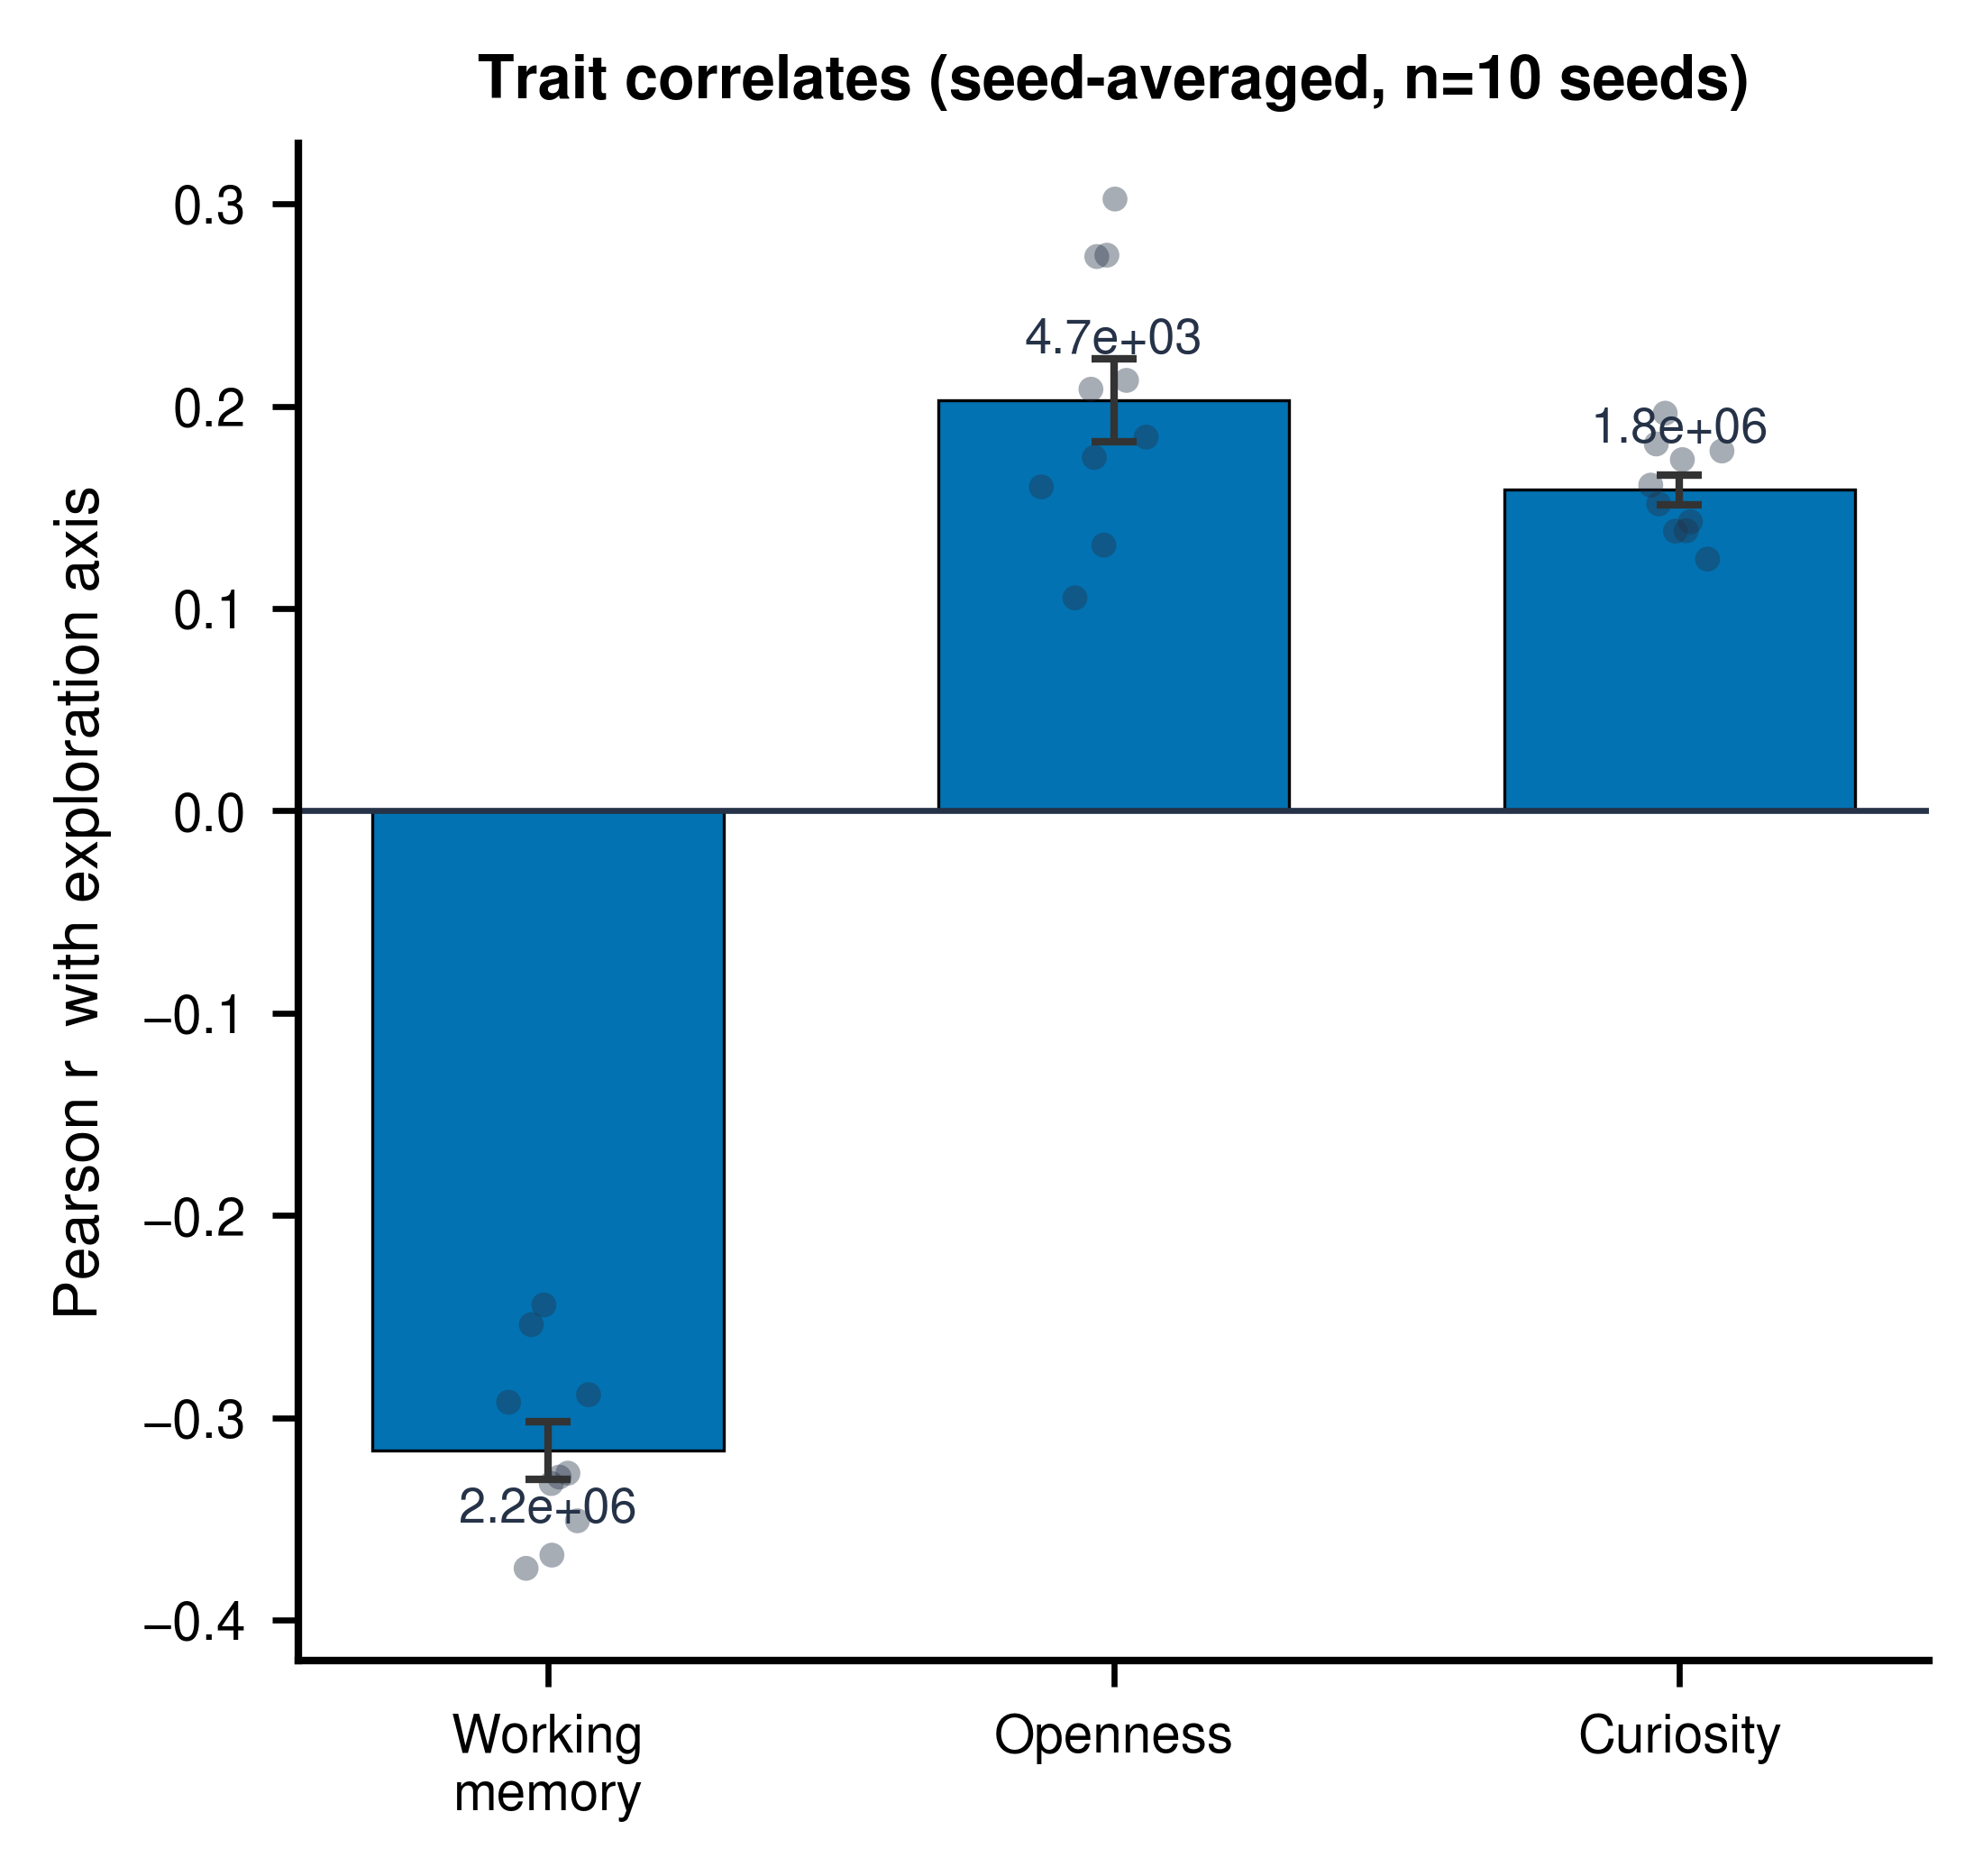

In [ ]:
# === panel — seed-averaged exploration-axis trait correlations ===
import numpy as np, pandas as pd
from scipy.stats import ttest_1samp
DEC = "final_plots/thalmann_z3_3task_full/decoding"
R = pd.read_csv(f"{DEC}/z2_seed_matched.csv")          # per-seed, structure-matched dim
ITEMS = [("r_wm", "Working\nmemory"), ("r_open", "Openness"), ("r_cei", "Curiosity")]
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(3.7, 3.5))
for i, (k, lab) in enumerate(ITEMS):
    v = R[k].dropna().values; m = v.mean(); se = v.std(ddof=1) / np.sqrt(len(v))
    t, _ = ttest_1samp(v, 0.0); bf = float(bayesfactor_ttest(t, len(v)))
    ax.bar(i, m, 0.62, color=COL_IDRNN, edgecolor="black", lw=0.4, zorder=2)
    ax.errorbar(i, m, yerr=se, fmt="none", ecolor="#333333", elinewidth=1.0, capsize=3, zorder=4)
    ax.scatter(np.full(len(v), i) + rng.normal(0, 0.055, len(v)), v, s=11,
               color=COL_TRUE, alpha=0.4, zorder=3, edgecolors="none")
    ax.text(i, m + (0.018 if m >= 0 else -0.018), fmt_bf(bf).replace("BF=", ""),
            ha="center", va="bottom" if m >= 0 else "top", fontsize=6.5, color=COL_TRUE)
ax.axhline(0, color=COL_TRUE, lw=0.8)
ax.set_xticks(range(len(ITEMS))); ax.set_xticklabels([l for _, l in ITEMS])
ax.set_ylabel("Pearson r  with exploration axis")
ax.set_title(f"Trait correlates (seed-averaged, n=10 seeds)")
ax.set_ylim(-0.42, 0.33)
fig.tight_layout(); fig.savefig(f"{DEC}/panel_seedavg_traits.png", dpi=600, bbox_inches="tight"); plt.show()
for k, lab in ITEMS:
    v = R[k].dropna().values; t, _ = ttest_1samp(v, 0.0)
    print(f"{lab.replace(chr(10),' '):16s} r={v.mean():+.3f} +/- {v.std(ddof=1)/np.sqrt(len(v)):.3f}  t9={t:+.2f}")

**The axis is directed switching, seed-averaged.** Left: a **PCA-free** seed-averaged latent — the sign-aligned **mean of the 10 per-seed matched exploration dimensions** (no PCA; just averaging the structure-matched axes) — tracks each subject's switch rate. Right: per-task partial r(z, switch | choice entropy) — switching beyond randomness, strongest in the horizon exploration task — averaged over seeds with across-seed error bars. (The pooled-PCA version of this latent lives only in the PCA fixed-dim panel.)

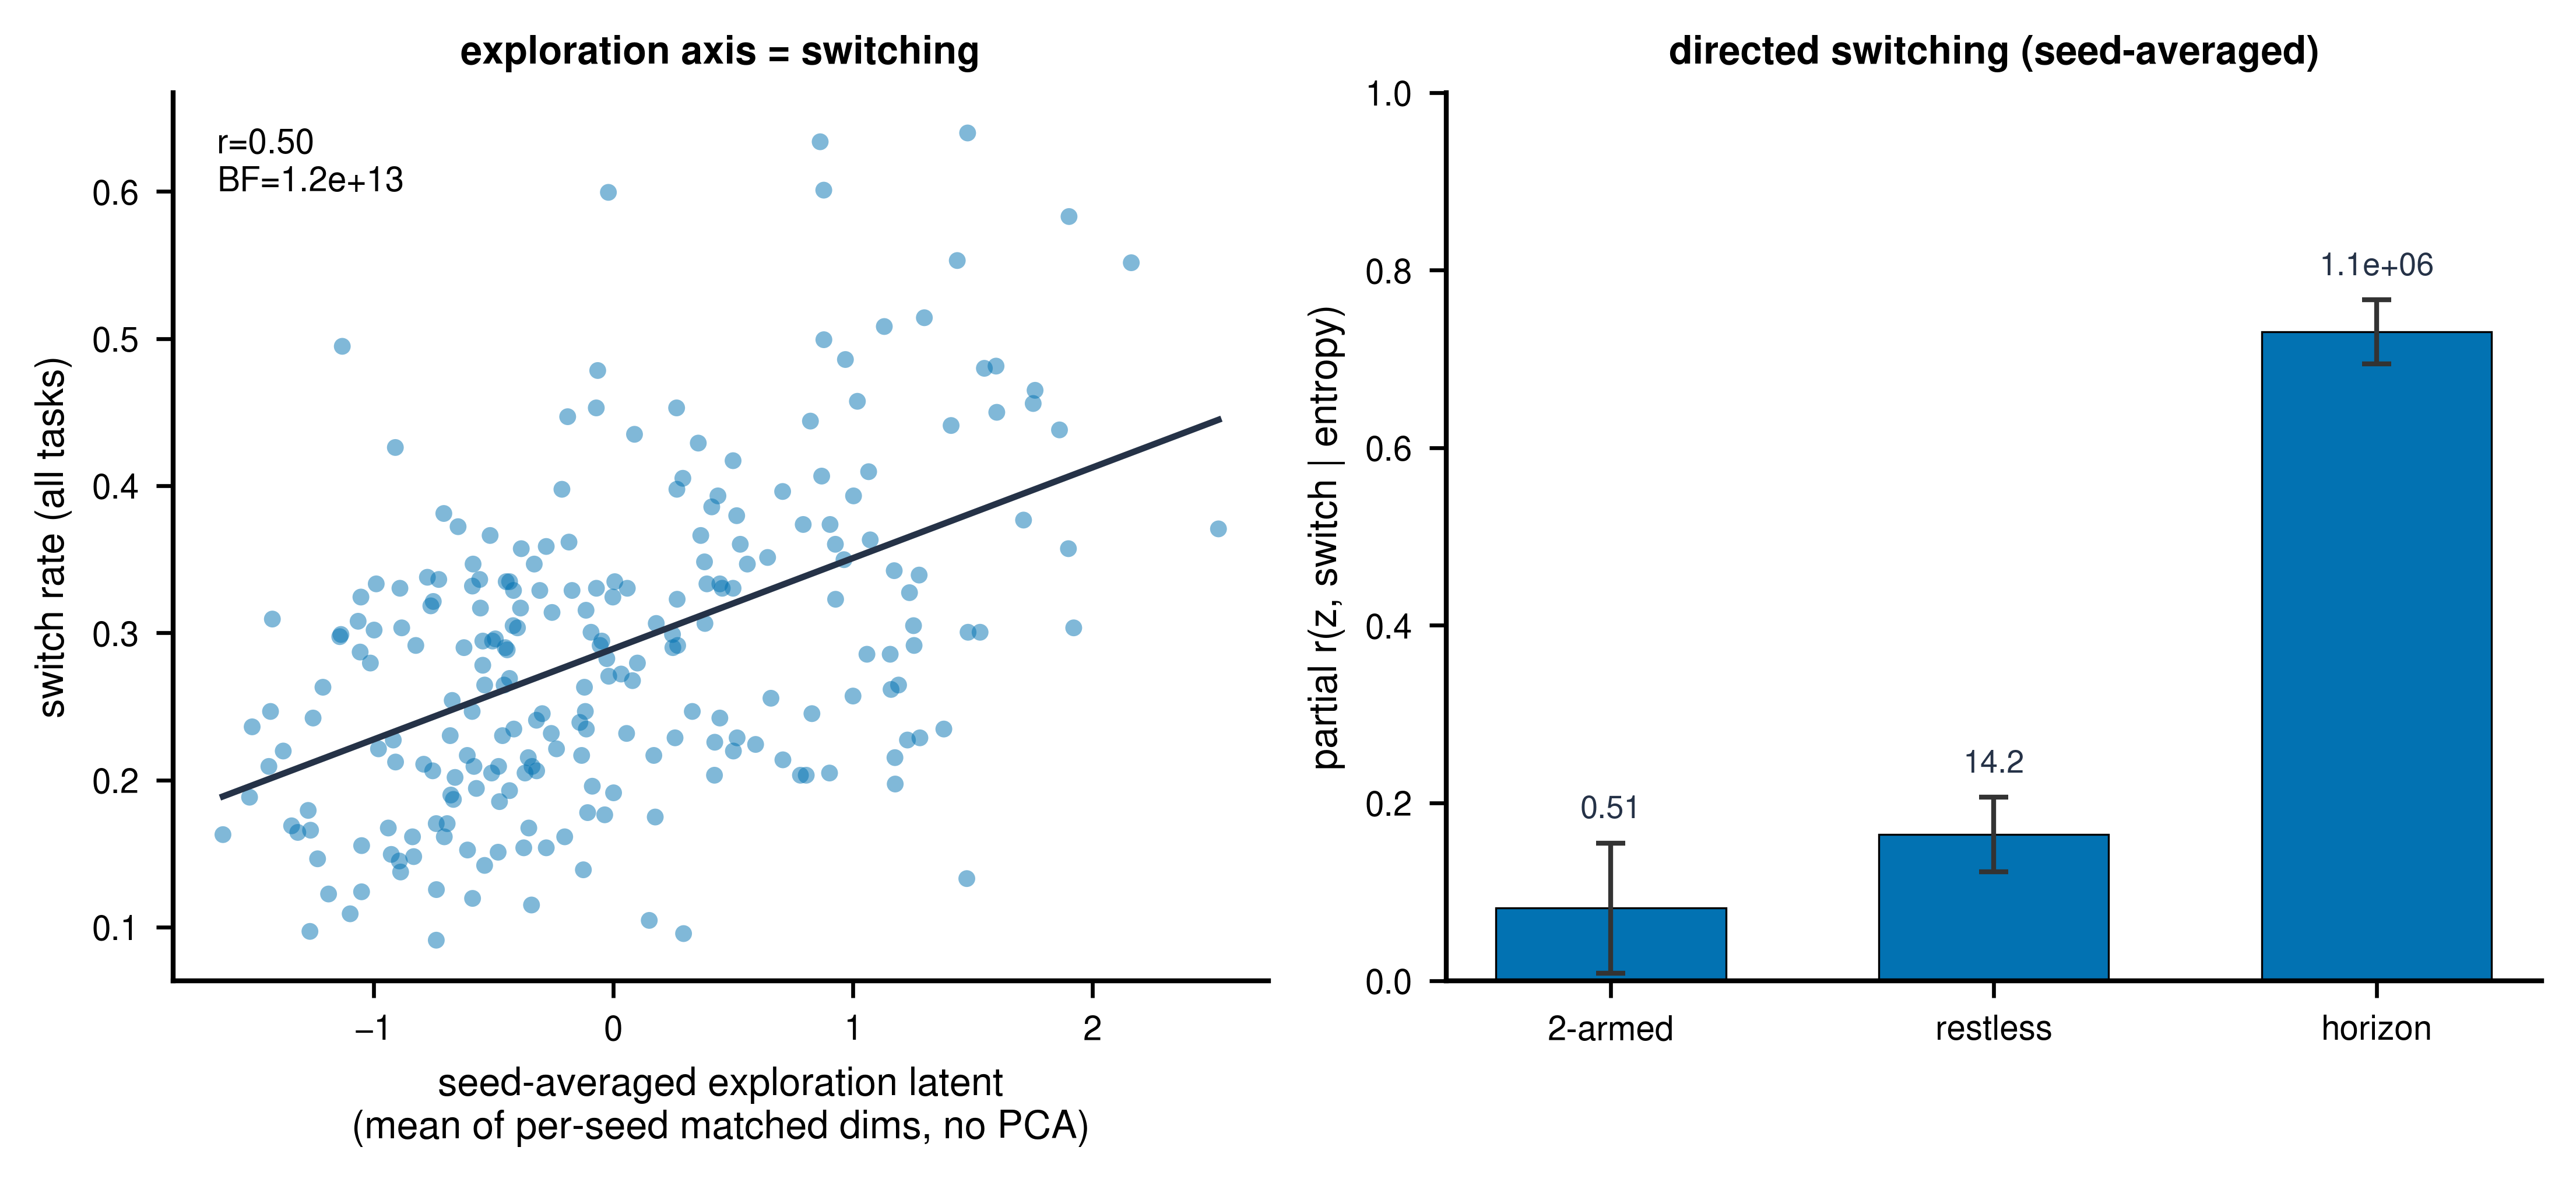

In [ ]:
# === panel — seed-averaged exploration axis is directed switching ===
import numpy as np, pandas as pd
from scipy.stats import ttest_1samp, pearsonr
DEC = "final_plots/thalmann_z3_3task_full/decoding"
R = pd.read_csv(f"{DEC}/z2_seed_matched.csv")
zc = np.load(f"{DEC}/z2_seedavg_mean.npy")              # PCA-FREE: sign-aligned MEAN of the 10 per-seed matched dims
c = np.load("data_thalmann_3task_full/c_train.npy"); N = c.shape[0]
def sw(bl):
    s = p = 0
    for b in range(bl.shape[0]):
        ch = bl[b]; ch = ch[ch >= 0]
        if len(ch) < 2: continue
        s += int((ch[1:] != ch[:-1]).sum()); p += len(ch) - 1
    return s / p if p else np.nan
sw_all = np.array([sw(c[i]) for i in range(N)])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.4, 3.4))
# (left) seed-averaged exploration latent (PCA-free mean of matched dims) vs overall switch
m = np.isfinite(zc) & np.isfinite(sw_all); r, _ = pearsonr(zc[m], sw_all[m]); bf = float(bayesfactor_pearson(r, m.sum()))
ax1.scatter(zc, sw_all, s=12, color=COL_IDRNN, alpha=0.5, edgecolors="none", zorder=2)
b = np.polyfit(zc[m], sw_all[m], 1); xs = np.linspace(zc[m].min(), zc[m].max(), 50)
ax1.plot(xs, b[0]*xs + b[1], color=COL_TRUE, lw=1.3, zorder=3)
ax1.text(0.04, 0.96, f"r={r:.2f}\n{fmt_bf(bf)}", transform=ax1.transAxes, va="top", ha="left", fontsize=7)
ax1.set_xlabel("seed-averaged exploration latent\n(mean of per-seed matched dims, no PCA)"); ax1.set_ylabel("switch rate (all tasks)")
ax1.set_title("exploration axis = switching")
# (right) per-task partial r(z, switch | entropy), seed-averaged with across-seed SE
TASKS = [("pr_sw2a", "2-armed"), ("pr_swre", "restless"), ("pr_swho", "horizon")]
xt = np.arange(len(TASKS))
for i, (k, lab) in enumerate(TASKS):
    v = R[k].dropna().values; mm = v.mean(); se = v.std(ddof=1) / np.sqrt(len(v))
    t, _ = ttest_1samp(v, 0.0); bf = float(bayesfactor_ttest(t, len(v)))
    ax2.bar(i, mm, 0.6, color=COL_IDRNN, edgecolor="black", lw=0.4, zorder=2)
    ax2.errorbar(i, mm, yerr=se, fmt="none", ecolor="#333333", elinewidth=1.0, capsize=3, zorder=4)
    ax2.text(i, mm + se + 0.02, fmt_bf(bf).replace("BF=", ""), ha="center", va="bottom", fontsize=6.5, color=COL_TRUE)
ax2.axhline(0, color=COL_TRUE, lw=0.8)
ax2.set_xticks(xt); ax2.set_xticklabels([l for _, l in TASKS])
ax2.set_ylabel("partial r(z, switch | entropy)"); ax2.set_ylim(top=1.0)
ax2.set_title("directed switching (seed-averaged)")
fig.tight_layout(); fig.savefig(f"{DEC}/panel_seedavg_switching.png", dpi=600, bbox_inches="tight"); plt.show()
print("seed-avg partial r(switch|entropy):", {l: round(R[k].mean(), 3) for k, l in TASKS})

**Trait signal beyond working memory, seed-averaged.** Openness and curiosity survive partialling out WM in every seed (partial r ≈ +0.19 / +0.16) — not a WM confound.

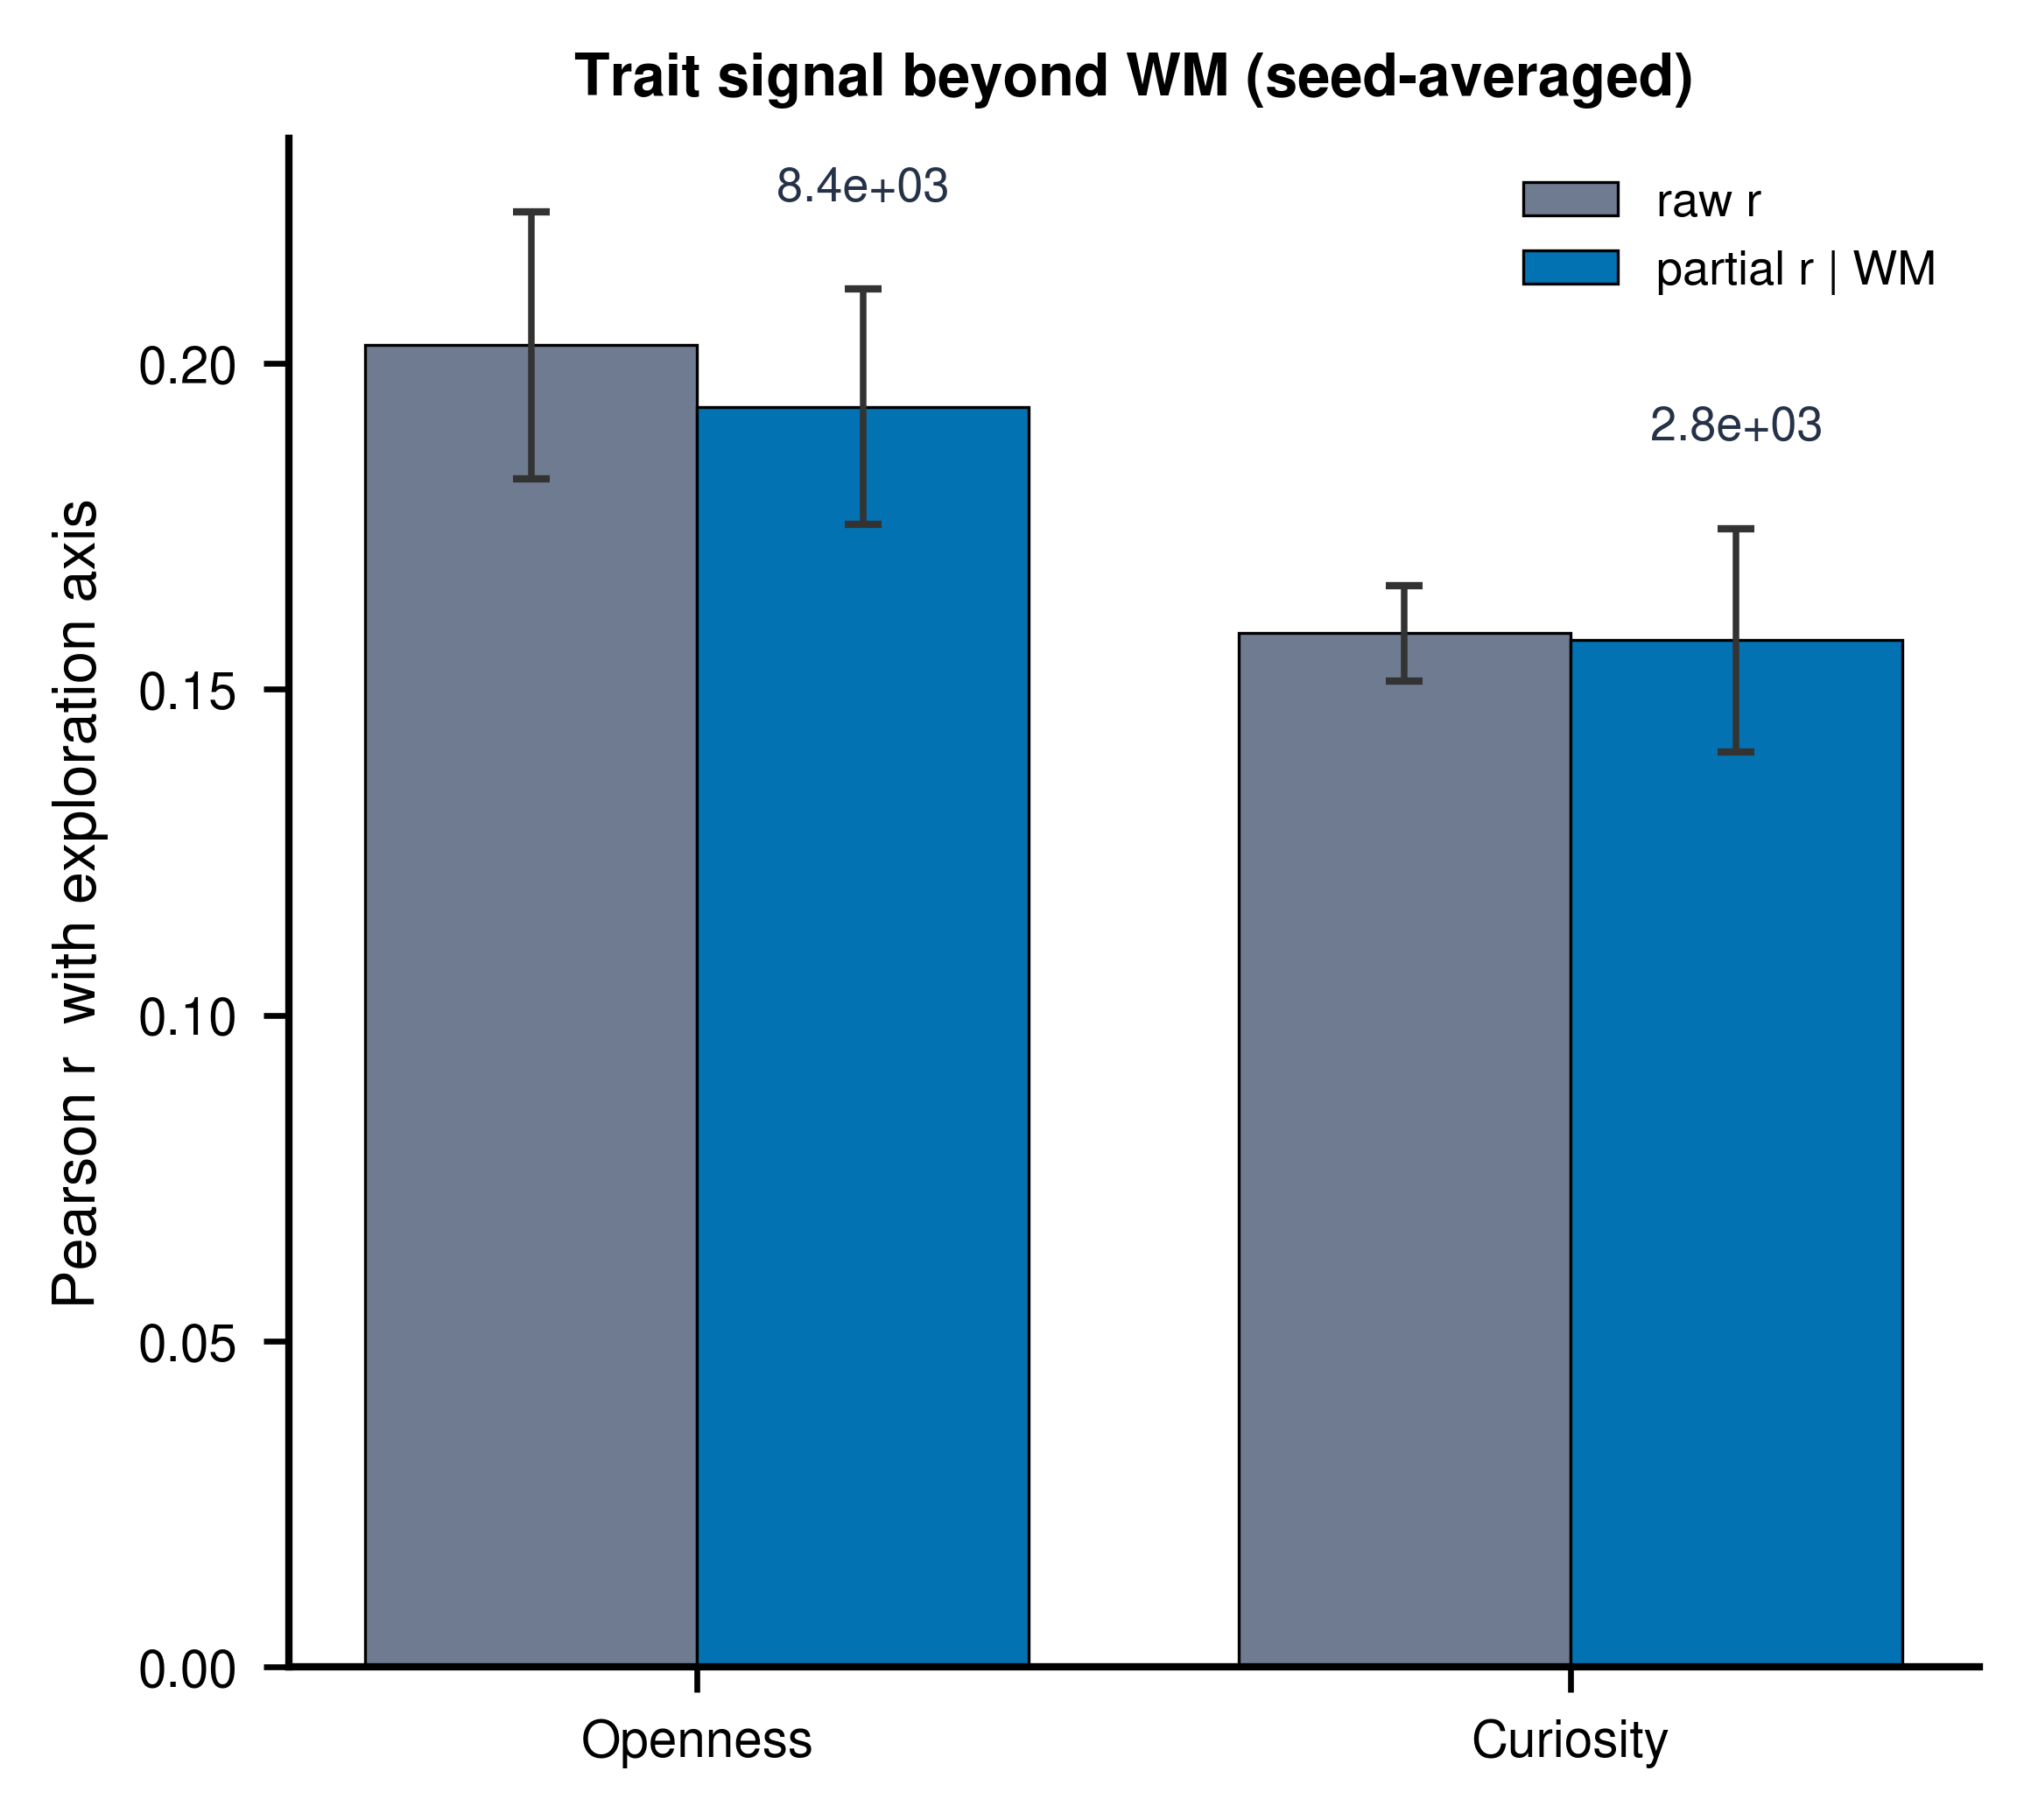

In [ ]:
# === panel — seed-averaged trait signal beyond working memory ===
import numpy as np, pandas as pd
from scipy.stats import ttest_1samp
DEC = "final_plots/thalmann_z3_3task_full/decoding"
R = pd.read_csv(f"{DEC}/z2_seed_matched.csv")
TRAITS = [("r_open", "pr_open_wm", "Openness"), ("r_cei", "pr_cei_wm", "Curiosity")]
x = np.arange(len(TRAITS)); w = 0.38; GREY = nature_colors['Grey'][3]
fig, ax = plt.subplots(figsize=(3.9, 3.5))
for i, (rk, pk, lab) in enumerate(TRAITS):
    rv = R[rk].dropna().values; pv = R[pk].dropna().values
    rm, rse = rv.mean(), rv.std(ddof=1)/np.sqrt(len(rv)); pm, pse = pv.mean(), pv.std(ddof=1)/np.sqrt(len(pv))
    t, _ = ttest_1samp(pv, 0.0); bf = float(bayesfactor_ttest(t, len(pv)))
    ax.bar(i - w/2, rm, w, color=GREY, edgecolor="black", lw=0.4, zorder=2, label="raw r" if i == 0 else None)
    ax.bar(i + w/2, pm, w, color=COL_IDRNN, edgecolor="black", lw=0.4, zorder=2, label="partial r | WM" if i == 0 else None)
    ax.errorbar(i - w/2, rm, yerr=rse, fmt="none", ecolor="#333333", elinewidth=0.9, capsize=2.5, zorder=4)
    ax.errorbar(i + w/2, pm, yerr=pse, fmt="none", ecolor="#333333", elinewidth=0.9, capsize=2.5, zorder=4)
    ax.text(i + w/2, pm + pse + 0.012, fmt_bf(bf).replace("BF=", ""), ha="center", va="bottom", fontsize=6.5, color=COL_TRUE)
ax.axhline(0, color=COL_TRUE, lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([l for _, _, l in TRAITS])
ax.set_ylabel("Pearson r  with exploration axis"); ax.legend(loc="upper right", fontsize=6.5)
ax.set_title("Trait signal beyond WM (seed-averaged)")
fig.tight_layout(); fig.savefig(f"{DEC}/panel_seedavg_beyond_wm.png", dpi=600, bbox_inches="tight"); plt.show()
print("raw :", {l: round(R[rk].mean(), 3) for rk, _, l in TRAITS})
print("|WM :", {l: round(R[pk].mean(), 3) for _, pk, l in TRAITS})

**The latent recovers openness that summaries miss, seed-averaged.** Openness ≈ 0 with an overall switch-rate summary, modest with horizon switching, strongest with the model latent; and the latent predicts openness beyond raw switching while switching adds nothing beyond the latent.

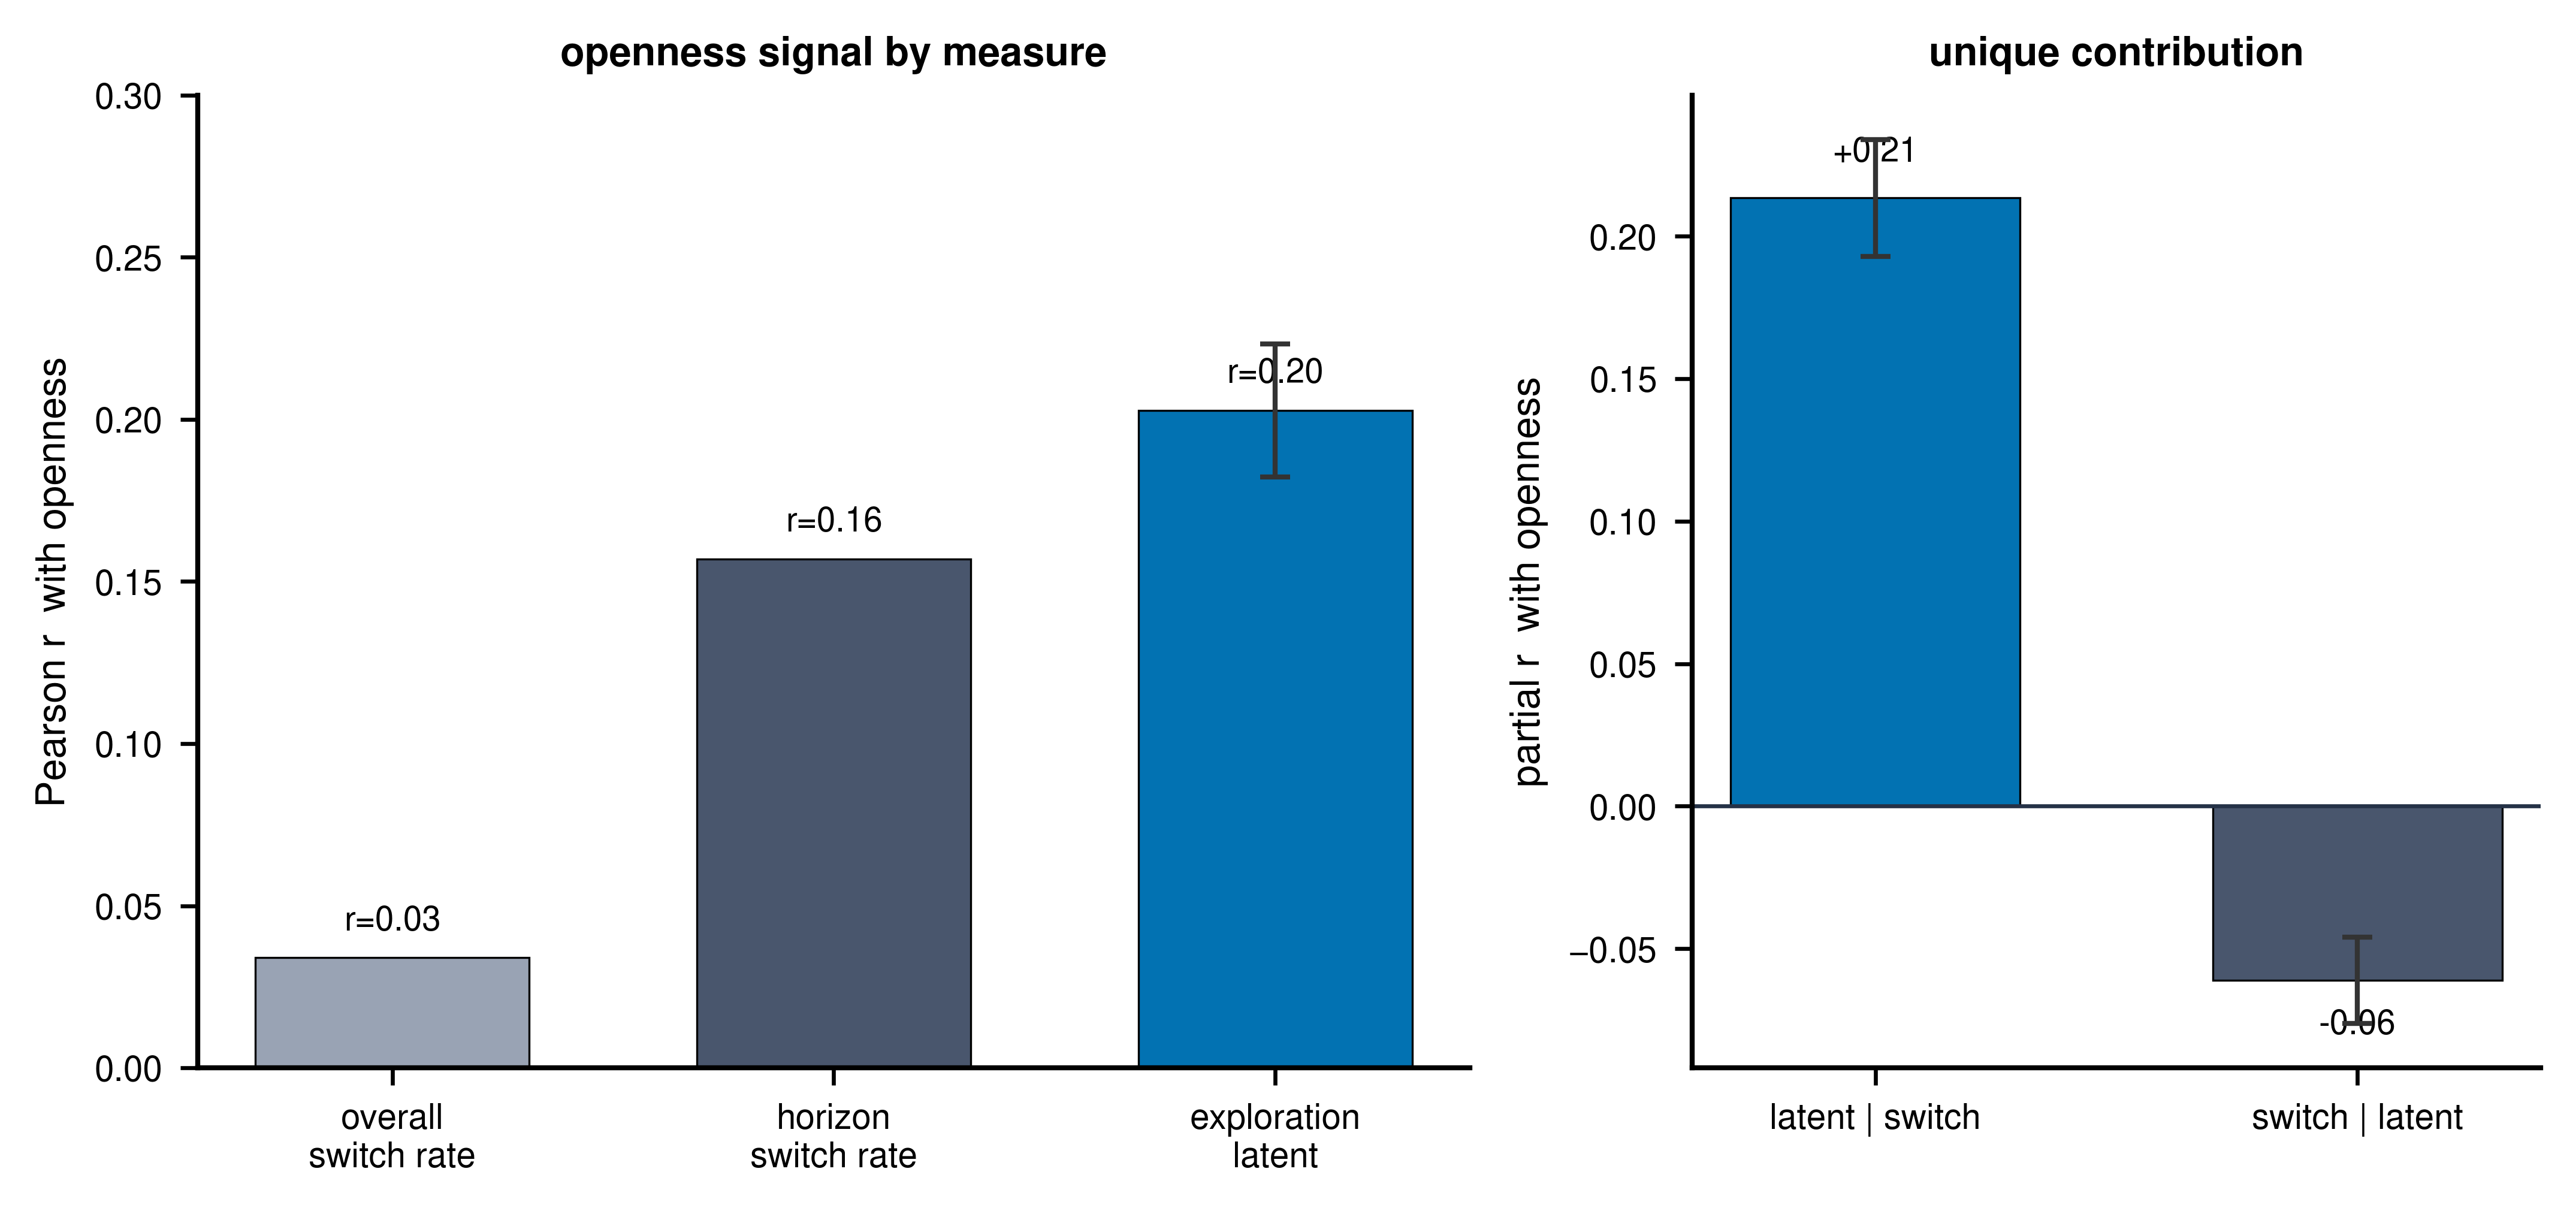

In [ ]:
# === panel — seed-averaged latent extracts openness summaries miss ===
import json, numpy as np, pandas as pd
from scipy.stats import ttest_1samp
DEC = "final_plots/thalmann_z3_3task_full/decoding"
R = pd.read_csv(f"{DEC}/z2_seed_matched.csv")
S = json.load(open(f"{DEC}/z2_seed_matched_summary.json"))
base = S["open_summary_baselines"]    # seed-independent behavioural summaries
GREY2, GREY4 = nature_colors['Grey'][2], nature_colors['Grey'][4]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.4), gridspec_kw={"width_ratios": [1.5, 1]})
# (left) openness signal: overall-switch vs horizon-switch vs the model latent
ro = R["r_open"].dropna().values; rom, rose = ro.mean(), ro.std(ddof=1)/np.sqrt(len(ro))
items = [("overall\nswitch rate", base["overall_switch"], None, GREY2),
         ("horizon\nswitch rate", base["horizon_switch"], None, GREY4),
         ("exploration\nlatent", rom, rose, COL_IDRNN)]
for i, (lab, val, se, col) in enumerate(items):
    ax1.bar(i, val, 0.62, color=col, edgecolor="black", lw=0.4, zorder=2)
    if se is not None:
        ax1.errorbar(i, val, yerr=se, fmt="none", ecolor="#333333", elinewidth=1.0, capsize=3, zorder=4)
    ax1.text(i, val + 0.006, f"r={val:.2f}", ha="center", va="bottom", fontsize=6.8)
ax1.axhline(0, color=COL_TRUE, lw=0.8)
ax1.set_xticks(range(3)); ax1.set_xticklabels([l for l, *_ in items], fontsize=7)
ax1.set_ylabel("Pearson r  with openness"); ax1.set_ylim(top=0.30)
ax1.set_title("openness signal by measure")
# (right) unique contributions (seed-averaged partial correlations)
pz = R["pr_open_sw"].dropna().values; ps = R["pr_sw_open"].dropna().values
vals = [pz.mean(), ps.mean()]; ses = [pz.std(ddof=1)/np.sqrt(len(pz)), ps.std(ddof=1)/np.sqrt(len(ps))]
ax2.bar([0, 1], vals, 0.6, color=[COL_IDRNN, GREY4], edgecolor="black", lw=0.4, zorder=2)
ax2.errorbar([0, 1], vals, yerr=ses, fmt="none", ecolor="#333333", elinewidth=1.0, capsize=3, zorder=4)
ax2.axhline(0, color=COL_TRUE, lw=0.8)
for i, v in enumerate(vals):
    ax2.text(i, v + (0.01 if v >= 0 else -0.01), f"{v:+.2f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=6.8)
ax2.set_xticks([0, 1]); ax2.set_xticklabels(["latent | switch", "switch | latent"], fontsize=7)
ax2.set_ylabel("partial r  with openness"); ax2.set_title("unique contribution")
fig.tight_layout(); fig.savefig(f"{DEC}/panel_seedavg_latent_vs_summary.png", dpi=600, bbox_inches="tight"); plt.show()
print(f"openness: overall-switch={base['overall_switch']:+.3f}  horizon-switch={base['horizon_switch']:+.3f}  latent={rom:+.3f}")
print(f"partial r(latent,open|switch)={vals[0]:+.3f}   r(switch,open|latent)={vals[1]:+.3f}")

**PCA generalizes the finding to a fixed dimension.** *Construction:* each seed's 3 latent dims are z-scored and concatenated into one 236×30 matrix, and a **single PCA** is run; the exploration component is picked by its **horizon-switch** correlation — selection is blind to the questionnaire traits. The top 3 PCs span the shared individual-difference subspace (91% variance); PC1 is the exploration axis and reproduces WM −0.28 / openness +0.29 / curiosity +0.19, with openness loading on PC1 *only* (PC2/PC3 ≈ 0).

*Why this is defensible, not a fishing artifact:* PCA is **unsupervised** (never sees the traits); and it is **not overfitting** — leave-one-**subject**-out (refit PCA on 235 subjects, project the held-out subject) gives r(open)=+0.29, identical to in-sample. *What the gain over a single seed means:* this PC1 is the **max-variance** consensus; a transparent sign-aligned **mean** of the per-seed axes (zero cross-subject fitting) gives r(open)=+0.24 — exactly the **de-attenuation** expected from averaging (single-seed +0.20 ÷ √[cross-seed reliability 0.72] = +0.24). So the consensus number is a *denoised* estimate; the conservative single-model number is the per-seed ~+0.20 reported above.

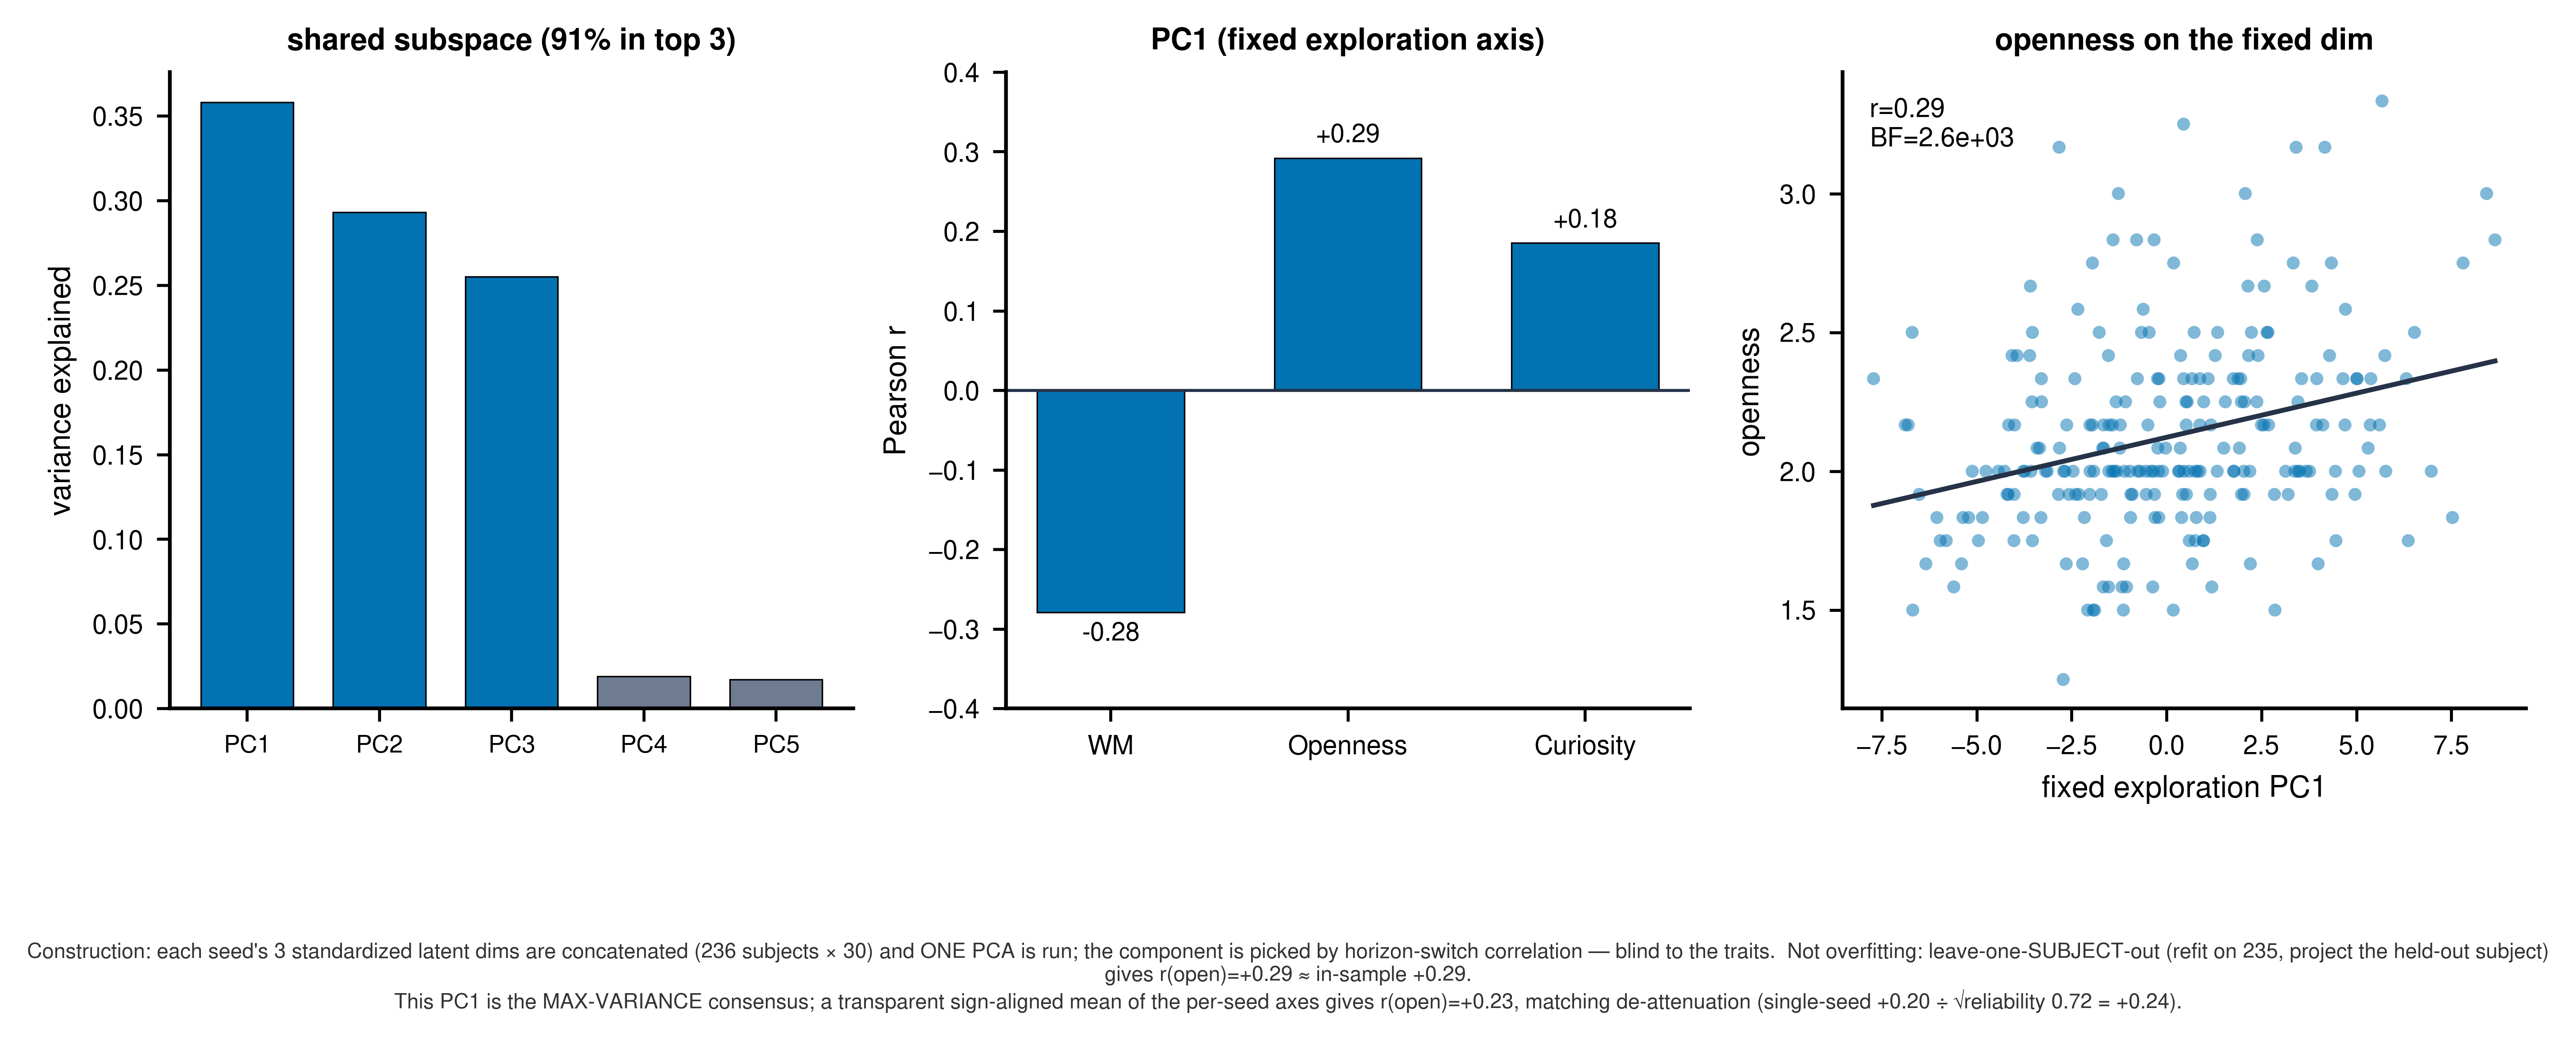

In [ ]:
# === panel — pooled-PCA fixed-dimension confirmation ===
import json, numpy as np, pandas as pd
from scipy.stats import pearsonr
DEC = "final_plots/thalmann_z3_3task_full/decoding"
S = json.load(open(f"{DEC}/z2_seed_matched_summary.json"))["pca"]
zc = np.load(f"{DEC}/z2_consensus_pca.npy")            # PC1 scores (fixed, basis-free)
op = pd.read_csv(f"{DEC}/trait_targets.csv")["BIG5_open"].values
fig, axes = plt.subplots(1, 3, figsize=(9.4, 3.1))
# (a) variance explained — top 3 PCs = the shared individual-difference subspace
ve = S["var_explained"]; xs = np.arange(len(ve))
cols = [COL_IDRNN if j < 3 else nature_colors['Grey'][3] for j in range(len(ve))]
axes[0].bar(xs, ve, 0.7, color=cols, edgecolor="black", lw=0.4)
axes[0].set_xticks(xs); axes[0].set_xticklabels([f"PC{j+1}" for j in xs], fontsize=6.5)
axes[0].set_ylabel("variance explained")
axes[0].set_title(f"shared subspace ({sum(ve[:3])*100:.0f}% in top 3)")
# (b) the fixed exploration PC's trait correlations
TR = [("r_wm", "WM"), ("r_open", "Openness"), ("r_cei", "Curiosity")]
for i, (k, lab) in enumerate(TR):
    axes[1].bar(i, S[k], 0.62, color=COL_IDRNN, edgecolor="black", lw=0.4)
    axes[1].text(i, S[k] + (0.012 if S[k] >= 0 else -0.012), f"{S[k]:+.2f}", ha="center",
                 va="bottom" if S[k] >= 0 else "top", fontsize=6.8)
axes[1].axhline(0, color=COL_TRUE, lw=0.8)
axes[1].set_xticks(range(len(TR))); axes[1].set_xticklabels([l for _, l in TR], fontsize=7)
axes[1].set_ylabel("Pearson r"); axes[1].set_ylim(-0.40, 0.40)
axes[1].set_title(f"PC{S['exp_pc']} (fixed exploration axis)")
# (c) scatter: fixed PC vs openness
m = np.isfinite(zc) & np.isfinite(op); r, _ = pearsonr(zc[m], op[m]); bf = float(bayesfactor_pearson(r, m.sum()))
axes[2].scatter(zc, op, s=12, color=COL_IDRNN, alpha=0.5, edgecolors="none", zorder=2)
b = np.polyfit(zc[m], op[m], 1); xx = np.linspace(zc[m].min(), zc[m].max(), 50)
axes[2].plot(xx, b[0]*xx + b[1], color=COL_TRUE, lw=1.3, zorder=3)
axes[2].text(0.04, 0.96, f"r={r:.2f}\n{fmt_bf(bf)}", transform=axes[2].transAxes, va="top", ha="left", fontsize=7)
axes[2].set_xlabel(f"fixed exploration PC{S['exp_pc']}"); axes[2].set_ylabel("openness")
axes[2].set_title("openness on the fixed dim")
V = S["validation"]
cap = ("Construction: each seed's 3 standardized latent dims are concatenated (236 subjects × 30) and ONE PCA is run; "
       f"the component is picked by horizon-switch correlation — blind to the traits.  Not overfitting: leave-one-"
       f"SUBJECT-out (refit on 235, project the held-out subject) gives r(open)={V['pooled_pca_loo']['r_open']:+.2f} "
       f"≈ in-sample {S['r_open']:+.2f}.\nThis PC1 is the MAX-VARIANCE consensus; a transparent sign-aligned mean of the "
       f"per-seed axes gives r(open)={V['simple_mean']['r_open']:+.2f}, matching de-attenuation "
       f"(single-seed {V['single_seed_open']:+.2f} ÷ √reliability {V['cross_seed_reliability']:.2f} = {V['deattenuated_open']:+.2f}).")
fig.text(0.5, -0.13, cap, ha="center", va="top", fontsize=5.6, color="#333333", wrap=True)
fig.tight_layout(); fig.savefig(f"{DEC}/panel_pca_fixed_dim.png", dpi=600, bbox_inches="tight"); plt.show()
print(f"PC{S['exp_pc']} (fixed): r(WM)={S['r_wm']:+.3f}  r(open)={S['r_open']:+.3f}  r(CEI)={S['r_cei']:+.3f}  var(top3)={sum(ve[:3]):.2f}")
print(f"validation: LOO r(open)={V['pooled_pca_loo']['r_open']}  simple-mean r(open)={V['simple_mean']['r_open']}  "
      f"reliability={V['cross_seed_reliability']}  de-attenuated={V['deattenuated_open']}")

**Three ways to identify the axis across seeds agree.** (i) **raw-dim, per-seed → combine:** in each seed pick the raw latent dim whose behavioural fingerprint matches the exploration axis, correlate with traits, average the per-seed correlations (this is the single-model estimate, ~+0.20 openness). (ii) **within-seed PCA → combine:** run PCA *inside each seed*, pick the exploration component, then average the per-seed correlations — each independent training analysed on its own footing. (iii) **pooled PCA (fixed dim):** concatenate all seeds and read one fixed component — a *denoised consensus* (no across-seed error bar; its higher openness +0.29 is the de-attenuation gain, see the PCA panel). All three give WM −0.27 to −0.32, openness +0.18 to +0.29, curiosity +0.13 to +0.19 — the conclusion does not depend on how the dimension is identified.

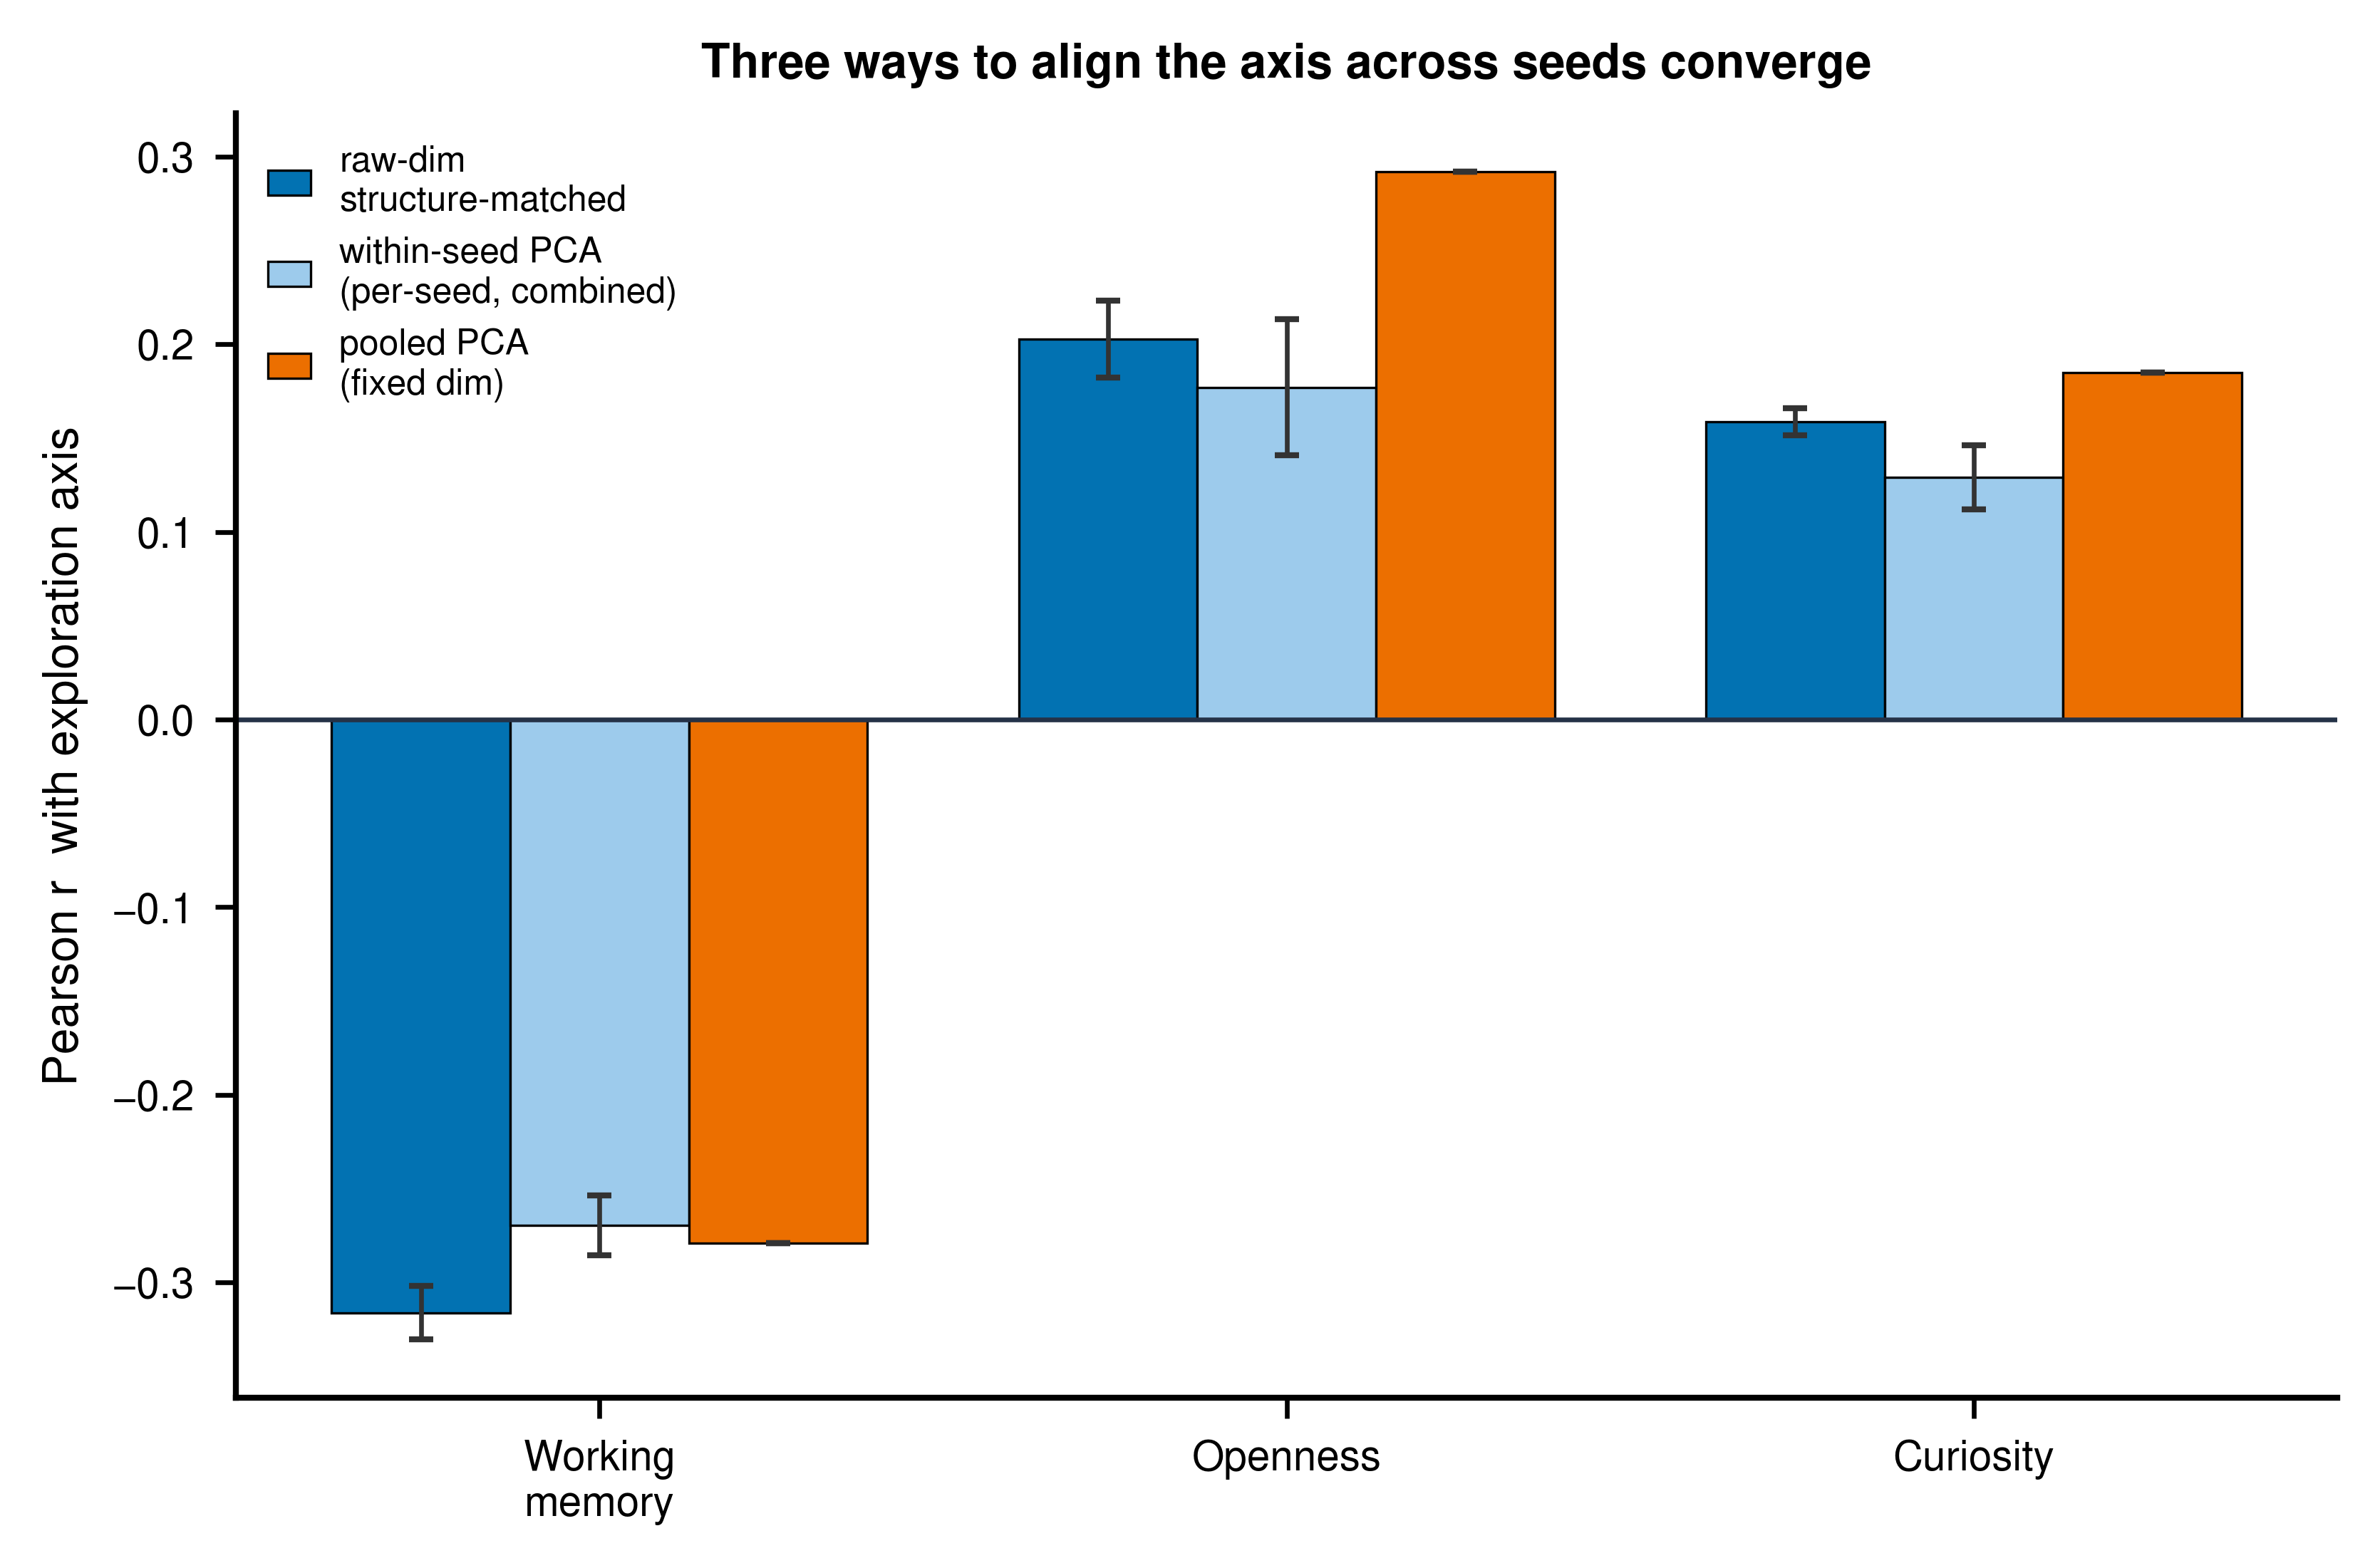

In [ ]:
# === panel — three ways to align the exploration axis converge ===
import json, numpy as np, pandas as pd
from scipy.stats import ttest_1samp
DEC = "final_plots/thalmann_z3_3task_full/decoding"
R = pd.read_csv(f"{DEC}/z2_seed_matched.csv")
P = json.load(open(f"{DEC}/z2_seed_matched_summary.json"))["pca"]
TR = [("Working\nmemory", "r_wm", "ws_r_wm", "r_wm"), ("Openness", "r_open", "ws_r_open", "r_open"),
      ("Curiosity", "r_cei", "ws_r_cei", "r_cei")]
methods = ["raw-dim\nstructure-matched", "within-seed PCA\n(per-seed, combined)", "pooled PCA\n(fixed dim)"]
cols = [COL_IDRNN, COL_IDRNN_H, COL_VANILLA]
x = np.arange(len(TR)); w = 0.26
fig, ax = plt.subplots(figsize=(5.6, 3.7))
for mi, mlab in enumerate(methods):
    means, ses = [], []
    for lab, rk, wk, pk in TR:
        if mi == 0:
            v = R[rk].dropna().values; means.append(v.mean()); ses.append(v.std(ddof=1)/np.sqrt(len(v)))
        elif mi == 1:
            v = R[wk].dropna().values; means.append(v.mean()); ses.append(v.std(ddof=1)/np.sqrt(len(v)))
        else:
            means.append(P[pk]); ses.append(0.0)
    off = (mi - 1) * w
    ax.bar(x + off, means, w, color=cols[mi], edgecolor="black", lw=0.4, zorder=2, label=mlab)
    ax.errorbar(x + off, means, yerr=ses, fmt="none", ecolor="#333333", elinewidth=0.8, capsize=2, zorder=4)
ax.axhline(0, color=COL_TRUE, lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([t[0] for t in TR])
ax.set_ylabel("Pearson r  with exploration axis")
ax.legend(loc="upper left", fontsize=6, ncol=1, handlelength=1.2)
ax.set_title("Three ways to align the axis across seeds converge")
fig.tight_layout(); fig.savefig(f"{DEC}/panel_three_method_convergence.png", dpi=600, bbox_inches="tight"); plt.show()
print("raw-dim    :", {t[0].replace(chr(10),' '): round(R[t[1]].mean(), 3) for t in TR})
print("within-PCA :", {t[0].replace(chr(10),' '): round(R[t[2]].mean(), 3) for t in TR})
print("pooled-PCA :", {t[0].replace(chr(10),' '): P[t[3]] for t in TR})

# Ensemble (pooled-PCA consensus) replication of the z2 analysis
The single-seed (canonical 999) z2 panels above are replicated here using the **strongest ensemble latent** — the consensus axis from one PCA over **all 10 seeds' concatenated latents** (`z2_consensus_pca.npy`). It is a single fixed, basis-free 236-vector, so it slots in exactly where single-seed z2 was used. As a denoised consensus it carries a somewhat stronger trait signal than any single seed (de-attenuation; see the pooled-PCA validation panel). Each plot is its own cell.

## Ensemble consensus latent — the individual-difference axis
Pearson r of the consensus ensemble latent with every questionnaire/WM score (all bars = the same latent; numbers = BF₁₀ per correlation). Same axis as single-seed z2: strong negative for WM, positive for openness/curiosity — sharper because the latent is denoised across seeds.

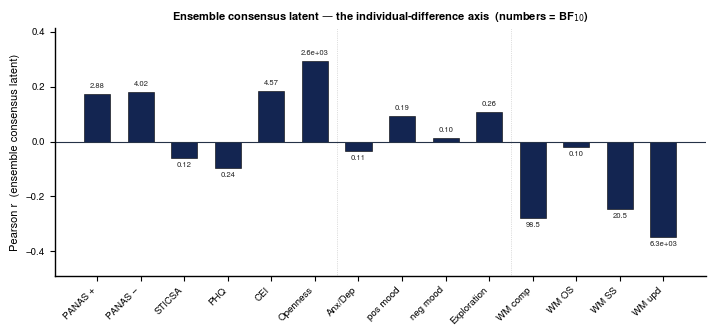

{'PANAS +': 0.174, 'PANAS −': 0.182, 'STICSA': -0.059, 'PHQ': -0.096, 'CEI': 0.185, 'Openness': 0.292, 'Anx/Dep': -0.035, 'pos mood': 0.091, 'neg mood': 0.012, 'Exploration': 0.108, 'WM comp': -0.279, 'WM OS': -0.02, 'WM SS': -0.247, 'WM upd': -0.349}


In [ ]:
# === ensemble panel — consensus latent correlations with every trait (individual-difference axis) ===
import numpy as np, pandas as pd
from scipy.stats import pearsonr
DEC = "final_plots/thalmann_z3_3task_full/decoding"
zc = np.load(f"{DEC}/z2_consensus_pca.npy")           # ENSEMBLE: pooled PCA over all seeds' latents
tg = pd.read_csv(f"{DEC}/trait_targets.csv")          # torch-free trait scores (subids_full order)
def corr_n(y):
    m = np.isfinite(zc) & np.isfinite(y); return float(pearsonr(zc[m], y[m])[0]), int(m.sum())

PERSONALITY = ["PANAS_PA","PANAS_NA","STICSA","PHQ","CEI","BIG5_open"]
COMPOSITE   = ["AxDep","posMood","negMood","Exp"]
WM_KEYS     = ["WM_composite","WM_OS","WM_SS","WM_WMU"]
ALL_KEYS = PERSONALITY + COMPOSITE + WM_KEYS
LBL = {"PANAS_PA":"PANAS +","PANAS_NA":"PANAS −","STICSA":"STICSA","PHQ":"PHQ","CEI":"CEI",
       "BIG5_open":"Openness","AxDep":"Anx/Dep","posMood":"pos mood","negMood":"neg mood",
       "Exp":"Exploration","WM_composite":"WM comp","WM_OS":"WM OS","WM_SS":"WM SS","WM_WMU":"WM upd"}
labels = [LBL[k] for k in ALL_KEYS]; x = np.arange(len(labels))
r = np.array([corr_n(tg[k].values)[0] for k in ALL_KEYS])
bf = [float(bayesfactor_pearson(*( (corr_n(tg[k].values)) ))) for k in ALL_KEYS]
fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.bar(x, r, 0.6, color=COL_IDRNN, edgecolor="black", linewidth=0.4, zorder=2)   # all blue = consensus latent
ax.axhline(0, color=COL_TRUE, lw=0.8)
for i, (v, b) in enumerate(zip(r, bf)):
    ax.text(x[i], v + (0.015 if v >= 0 else -0.015), fmt_bf(b).replace("BF=", ""), ha="center",
            va="bottom" if v >= 0 else "top", fontsize=5.5, color="#222222")
for xb in (len(PERSONALITY)-.5, len(PERSONALITY)+len(COMPOSITE)-.5):
    ax.axvline(xb, color="grey", lw=.5, ls=":", alpha=.5)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax.set_ylim(min(r)-0.14, max(r)+0.12)
ax.set_ylabel("Pearson r  (ensemble consensus latent)")
#ax.set_title("Ensemble consensus latent — the individual-difference axis  (numbers = BF$_{10}$)")
fig.tight_layout(); fig.savefig(f"{DEC}/panel_ens_correlations.png", dpi=600, bbox_inches="tight"); plt.show()
print({LBL[k]: round(corr_n(tg[k].values)[0], 3) for k in ALL_KEYS})

## Openness — evidence increase over the original study (ensemble latent)
Original study's strongest Openness↔task-measure correlation was r=0.11 (BF₁₀≈0.34, favouring the null). The ensemble consensus latent gives r≈0.29 (BF₁₀ in the thousands) — flipping from no evidence to strong evidence. The ratio is larger than the single-seed (~41×) because the consensus latent is de-attenuated; treat it as the upper-reliability estimate, single-seed as the conservative one.

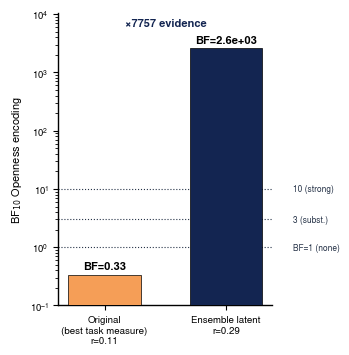

openness: original r=0.11 BF=0.33 | ensemble r=0.292 BF=2595.41 | ratio 7757x


In [4]:
# === ensemble panel — openness evidence: consensus latent vs original study's best task measure ===
import numpy as np, pandas as pd
from scipy.stats import pearsonr
DEC = "final_plots/thalmann_z3_3task_full/decoding"
zc = np.load(f"{DEC}/z2_consensus_pca.npy")           # ENSEMBLE: pooled PCA over all seeds' latents
tg = pd.read_csv(f"{DEC}/trait_targets.csv")          # torch-free trait scores (subids_full order)
def corr_n(y):
    m = np.isfinite(zc) & np.isfinite(y); return float(pearsonr(zc[m], y[m])[0]), int(m.sum())

R_ORIG = 0.11                                  # original study: strongest Openness x task-measure (of 13)
r_ours, n = corr_n(tg["BIG5_open"].values)
bf_orig = float(bayesfactor_pearson(R_ORIG, n)); bf_ours = float(bayesfactor_pearson(r_ours, n))
ratio = bf_ours / bf_orig
labels = [f"Original\n(best task measure)\nr={R_ORIG:.2f}", f"Ensemble latent\nr={r_ours:.2f}"]
vals = [bf_orig, bf_ours]; cols = [COL_VANILLA, COL_IDRNN]
fig, ax = plt.subplots(figsize=(3.6, 3.6))
ax.bar([0, 1], vals, 0.6, color=cols, edgecolor="black", linewidth=0.5, zorder=3)
for thr, lab in [(1, "BF=1 (none)"), (3, "3 (subst.)"), (10, "10 (strong)")]:
    ax.axhline(thr, ls=":", color=COL_TRUE, lw=0.8, zorder=1)
    ax.text(1.55, thr, lab, va="center", ha="left", fontsize=6, color=COL_TRUE)
for i, v in enumerate(vals):
    ax.text(i, v*1.15, fmt_bf(v), ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.annotate(f"×{ratio:.0f} evidence", xy=(0.5, bf_ours), ha="center", va="bottom",
            fontsize=8, color=COL_IDRNN, fontweight="bold", xytext=(0.5, bf_ours*2.2), arrowprops=None)
ax.set_yscale("log"); ax.set_ylim(0.1, max(vals)*4)
ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel("BF$_{10}$ Openness encoding")
#ax.set_title("Openness: undetectable → strong\n(ensemble consensus latent)")
fig.tight_layout(); fig.savefig(f"{DEC}/panel_ens_openness_evidence.png", dpi=600, bbox_inches="tight"); plt.show()
print(f"openness: original r={R_ORIG} BF={bf_orig:.2f} | ensemble r={r_ours:.3f} BF={bf_ours:.2f} | ratio {ratio:.0f}x")

## Consensus latent = the explore/exploit axis — directed switching, not randomness
The consensus latent is **PC1** — the top shared-variance direction (≈36%); PCA is blind to switch rates and traits, so its switch correlation is **emergent, not definitional**. **Left:** PC1 tracks each subject's overall switch rate (r≈0.28). **Right:** partial r(latent, switch | choice entropy) per task — directed switching beyond randomness, **concentrated in the horizon task** (2-armed/restless ≈ 0). Note the ensemble axis is *more horizon-specific* than single-seed z2 (which also loaded on 2-armed/restless switching): the axis **shared across seeds** is specifically horizon-directed exploration, while the broader switching in z2 was partly seed-specific.

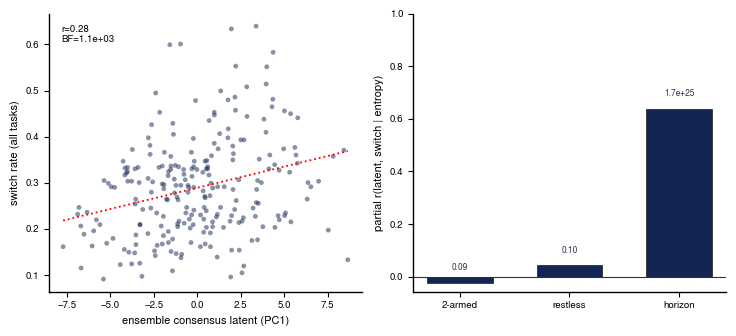

r(latent,switch): {'2-armed': -0.063, 'restless': 0.107, 'horizon': 0.648} | all 0.28
partial r(switch|entropy): {'2-armed': -0.024, 'restless': 0.043, 'horizon': 0.639}


In [46]:
# === ensemble panel — consensus latent is the explore/exploit (switching) axis, not randomness ===
import numpy as np, pandas as pd, pingouin as pg
from scipy.stats import pearsonr
DEC = "final_plots/thalmann_z3_3task_full/decoding"
zc = np.load(f"{DEC}/z2_consensus_pca.npy")
c   = np.load("data_thalmann_3task_full/c_train.npy")
tid = np.load("data_thalmann_3task_full/task_ids_per_block.npy")
N = c.shape[0]
def switch_rate(bl):
    s = p = 0
    for b in range(bl.shape[0]):
        ch = bl[b]; ch = ch[ch >= 0]
        if len(ch) < 2: continue
        s += int((ch[1:] != ch[:-1]).sum()); p += len(ch) - 1
    return s / p if p else np.nan
def entropy(bl, k):
    ch = bl[bl >= 0].astype(int)
    if len(ch) == 0: return np.nan
    pr = np.bincount(ch, minlength=k) / len(ch); pr = pr[pr > 0]
    return float(-(pr * np.log(pr)).sum())
TASKS = [("2-armed", tid == 0, 2), ("restless", tid == 1, 4), ("horizon", tid == 2, 2)]
SW = {t: np.array([switch_rate(c[i][m]) for i in range(N)]) for t, m, k in TASKS}
EN = {t: np.array([entropy(c[i][m], k) for i in range(N)]) for t, m, k in TASKS}
sw_all = np.array([switch_rate(c[i]) for i in range(N)])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.4, 3.4))
# (left) consensus latent vs overall switch rate
r, _ = pearsonr(zc, sw_all); bf = float(bayesfactor_pearson(r, N))
ax1.scatter(zc, sw_all, s=12, color=COL_IDRNN, alpha=0.5, edgecolors="none", zorder=2)
b = np.polyfit(zc, sw_all, 1); xs = np.linspace(zc.min(), zc.max(), 50)
ax1.plot(xs, b[0]*xs + b[1], "r:", lw=1.3, zorder=3)
ax1.text(0.04, 0.96, f"r={r:.2f}\n{fmt_bf(bf)}", transform=ax1.transAxes, va="top", ha="left", fontsize=7)
ax1.set_xlabel("ensemble consensus latent (PC1)"); ax1.set_ylabel("switch rate (all tasks)")
#ax1.set_title("consensus axis (PC1) = switching")
# (right) per-task partial r(latent, switch | entropy)
xt = np.arange(len(TASKS)); prs, bfs = [], []
for t, m, k in TASKS:
    d = pd.DataFrame({"z": zc, "switch": SW[t], "entropy": EN[t]}).dropna()
    rr = float(pg.partial_corr(d, x="z", y="switch", covar="entropy")["r"].values[0])
    prs.append(rr); bfs.append(float(bayesfactor_pearson(rr, len(d) - 1)))
ax2.bar(xt, prs, 0.6, color=COL_IDRNN, edgecolor="black", lw=0.4, zorder=2)
ax2.axhline(0, color=COL_TRUE, lw=0.8)
for i, (rr, bf) in enumerate(zip(prs, bfs)):
    ax2.text(xt[i], rr + 0.04, fmt_bf(bf).replace("BF=", ""), ha="center", va="bottom", fontsize=6, color=COL_TRUE)
ax2.set_xticks(xt); ax2.set_xticklabels([t for t, _, _ in TASKS])
ax2.set_ylabel("partial r(latent, switch | entropy)"); ax2.set_ylim(top=1.0)
#ax2.set_title("switching, controlling for randomness")
fig.tight_layout(); fig.savefig(f"{DEC}/panel_ens_switching.png", dpi=600, bbox_inches="tight"); plt.show()
print("r(latent,switch):", {t: round(float(pearsonr(zc, SW[t])[0]), 3) for t, _, _ in TASKS}, "| all", round(r, 3))
print("partial r(switch|entropy):", {t: round(p, 3) for t, p in zip([x[0] for x in TASKS], prs)})

## Trait signal beyond working memory (ensemble latent)
Raw vs WM-partialled correlation of openness and curiosity with the ensemble consensus latent. Both survive controlling for working memory — genuine individual-difference variance beyond cognitive ability, now on the denoised ensemble axis.

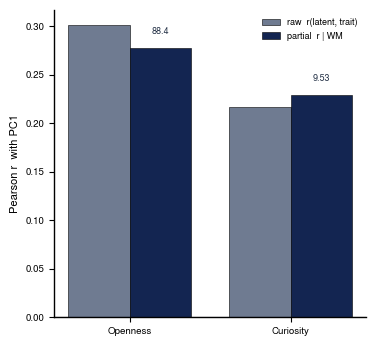

raw : {'Openness': 0.302, 'Curiosity': 0.217}
|WM : {'Openness': 0.278, 'Curiosity': 0.23}  BF: [88.37, 9.53]


In [54]:
# === ensemble panel — trait signal beyond working memory (raw vs partial | WM) ===
import numpy as np, pandas as pd, pingouin as pg
DEC = "final_plots/thalmann_z3_3task_full/decoding"
zc = np.load(f"{DEC}/z2_consensus_pca.npy")
tg = pd.read_csv(f"{DEC}/trait_targets.csv")
TRAITS = [("BIG5_open", "Openness"), ("CEI", "Curiosity")]
df = pd.DataFrame({"z": zc, "WM": tg["WM_composite"].values, **{k: tg[k].values for k, _ in TRAITS}}).dropna()
n = len(df); raw, par, bfs = [], [], []
for k, _ in TRAITS:
    raw.append(float(pg.corr(df["z"], df[k])["r"].values[0]))
    rp = float(pg.partial_corr(df, x="z", y=k, covar="WM")["r"].values[0])
    par.append(rp); bfs.append(float(bayesfactor_pearson(rp, n - 1)))
x = np.arange(len(TRAITS)); w = 0.38; GREY = nature_colors['Grey'][3]
fig, ax = plt.subplots(figsize=(3.8, 3.5))
ax.bar(x - w/2, raw, w, color=GREY, edgecolor="black", lw=0.4, label="raw  r(latent, trait)", zorder=2)
ax.bar(x + w/2, par, w, color=COL_IDRNN, edgecolor="black", lw=0.4, label="partial  r | WM", zorder=2)
ax.axhline(0, color=COL_TRUE, lw=0.8)
for i, (rp, bf) in enumerate(zip(par, bfs)):
    ax.text(x[i] + w/2, rp + (0.012 if rp >= 0 else -0.012), fmt_bf(bf).replace("BF=", ""),
            ha="center", va="bottom" if rp >= 0 else "top", fontsize=6.5, color=COL_TRUE)
ax.set_xticks(x); ax.set_xticklabels([l for _, l in TRAITS])
ax.set_ylabel("Pearson r  with PC1")
ax.legend(loc="upper right", fontsize=6.5)
#ax.set_title(f"Trait signal beyond WM  (ensemble; n={n}; number = BF$_{{10}}$ on partial r)")
fig.tight_layout(); fig.savefig(f"{DEC}/panel_ens_beyond_wm.png", dpi=600, bbox_inches="tight"); plt.show()
print("raw :", {l: round(r, 3) for (_, l), r in zip(TRAITS, raw)})
print("|WM :", {l: round(r, 3) for (_, l), r in zip(TRAITS, par)}, " BF:", [round(b, 2) for b in bfs])

## Seed average exploration axis
**Individual-difference axis, seed-averaged (every trait).** *What was done to the latents:* in each of the 10 seeds I take that model's per-subject latent (236×3), pick the one dimension that is the exploration axis (largest |corr| with horizon-task switch rate, sign-aligned — trait-blind), and correlate **that single seed's** axis with each trait. *What the average means:* the bar is the **mean across the 10 seeds of those per-seed correlations** (correlate-then-average), the error bar is the across-seed SE, and dots are the individual seeds — so the bar is the **typical single-model** correlation and the spread shows training-to-training reproducibility. The latents are **never combined**; each seed is analysed on its own (contrast the pooled-PCA panel, which averages the latents first → de-attenuated, larger). Numbers are BF₁₀ on the mean r (effect-size evidence, comparable to the single-seed and ensemble panels).

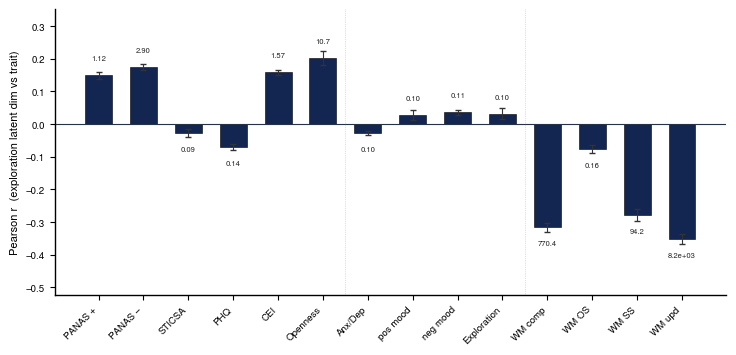

{'PANAS +': 0.149, 'PANAS −': 0.174, 'STICSA': -0.026, 'PHQ': -0.07, 'CEI': 0.159, 'Openness': 0.203, 'Anx/Dep': -0.027, 'pos mood': 0.028, 'neg mood': 0.036, 'Exploration': 0.032, 'WM comp': -0.316, 'WM OS': -0.076, 'WM SS': -0.278, 'WM upd': -0.353}


In [42]:
# === panel — seed-averaged individual-difference axis (every trait) ===
import numpy as np, pandas as pd
DEC = "final_plots/thalmann_z3_3task_full/decoding"
A = pd.read_csv(f"{DEC}/z2_seed_matched_alltraits.csv").set_index("seed")   # per-seed matched-dim r, every trait
tg = pd.read_csv(f"{DEC}/trait_targets.csv")
PERSONALITY = ["PANAS_PA","PANAS_NA","STICSA","PHQ","CEI","BIG5_open"]
COMPOSITE   = ["AxDep","posMood","negMood","Exp"]
WM_KEYS     = ["WM_composite","WM_OS","WM_SS","WM_WMU"]
ALL_KEYS = PERSONALITY + COMPOSITE + WM_KEYS
LBL = {"PANAS_PA":"PANAS +","PANAS_NA":"PANAS −","STICSA":"STICSA","PHQ":"PHQ","CEI":"CEI",
       "BIG5_open":"Openness","AxDep":"Anx/Dep","posMood":"pos mood","negMood":"neg mood",
       "Exp":"Exploration","WM_composite":"WM comp","WM_OS":"WM OS","WM_SS":"WM SS","WM_WMU":"WM upd"}
labels = [LBL[k] for k in ALL_KEYS]; x = np.arange(len(labels))
means = np.array([A[k].mean() for k in ALL_KEYS])
ses   = np.array([A[k].std(ddof=1)/np.sqrt(len(A)) for k in ALL_KEYS])
ns    = [int(np.isfinite(tg[k].values).sum()) for k in ALL_KEYS]
bf    = [float(bayesfactor_pearson(means[i], ns[i])) for i in range(len(ALL_KEYS))]   # effect-size BF on the mean r
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.bar(x, means, 0.6, color=COL_IDRNN, edgecolor="black", linewidth=0.4, zorder=2)
ax.errorbar(x, means, yerr=ses, fmt="none", ecolor="#333333", elinewidth=0.8, capsize=2, zorder=4)
#for i, k in enumerate(ALL_KEYS):
    #v = A[k].values
    #ax.scatter(x[i] + rng.normal(0, 0.05, len(v)), v, s=7, color=COL_TRUE, alpha=0.35, zorder=3, edgecolors="none")
ax.axhline(0, color=COL_TRUE, lw=0.8)
for i, (m, b) in enumerate(zip(means, bf)):
    ax.text(x[i], m + (0.04 if m >= 0 else -0.04), fmt_bf(b).replace("BF=", ""), ha="center",
            va="bottom" if m >= 0 else "top", fontsize=5.5, color="#222222")
for xb in (len(PERSONALITY)-.5, len(PERSONALITY)+len(COMPOSITE)-.5):
    ax.axvline(xb, color="grey", lw=.5, ls=":", alpha=.5)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax.set_ylim(means.min()-0.17, means.max()+0.15)
ax.set_ylabel("Pearson r  (exploration latent dim vs trait)")
#ax.set_title("Individual-difference axis, seed-averaged  (n=10 seeds; numbers = BF$_{10}$ on mean r)")
fig.tight_layout(); fig.savefig(f"{DEC}/panel_seedavg_correlations.png", dpi=600, bbox_inches="tight"); plt.show()
print({LBL[k]: round(A[k].mean(), 3) for k in ALL_KEYS})

**Openness — evidence increase, seed-averaged axis.** The original study's strongest Openness↔task-measure correlation was r=0.11 (BF₁₀≈0.33, favouring the null). The seed-averaged exploration axis (mean of per-seed openness correlations, r≈0.20) gives BF₁₀≈11 — a ~32× increase, flipping no-evidence → strong. This is the **conservative single-model** estimate (each per-seed correlation is attenuated by that seed's noise; averaging the correlations does not remove that). The denoised ensemble axis (average-the-latents-first) is larger (r≈0.29, ×7757).

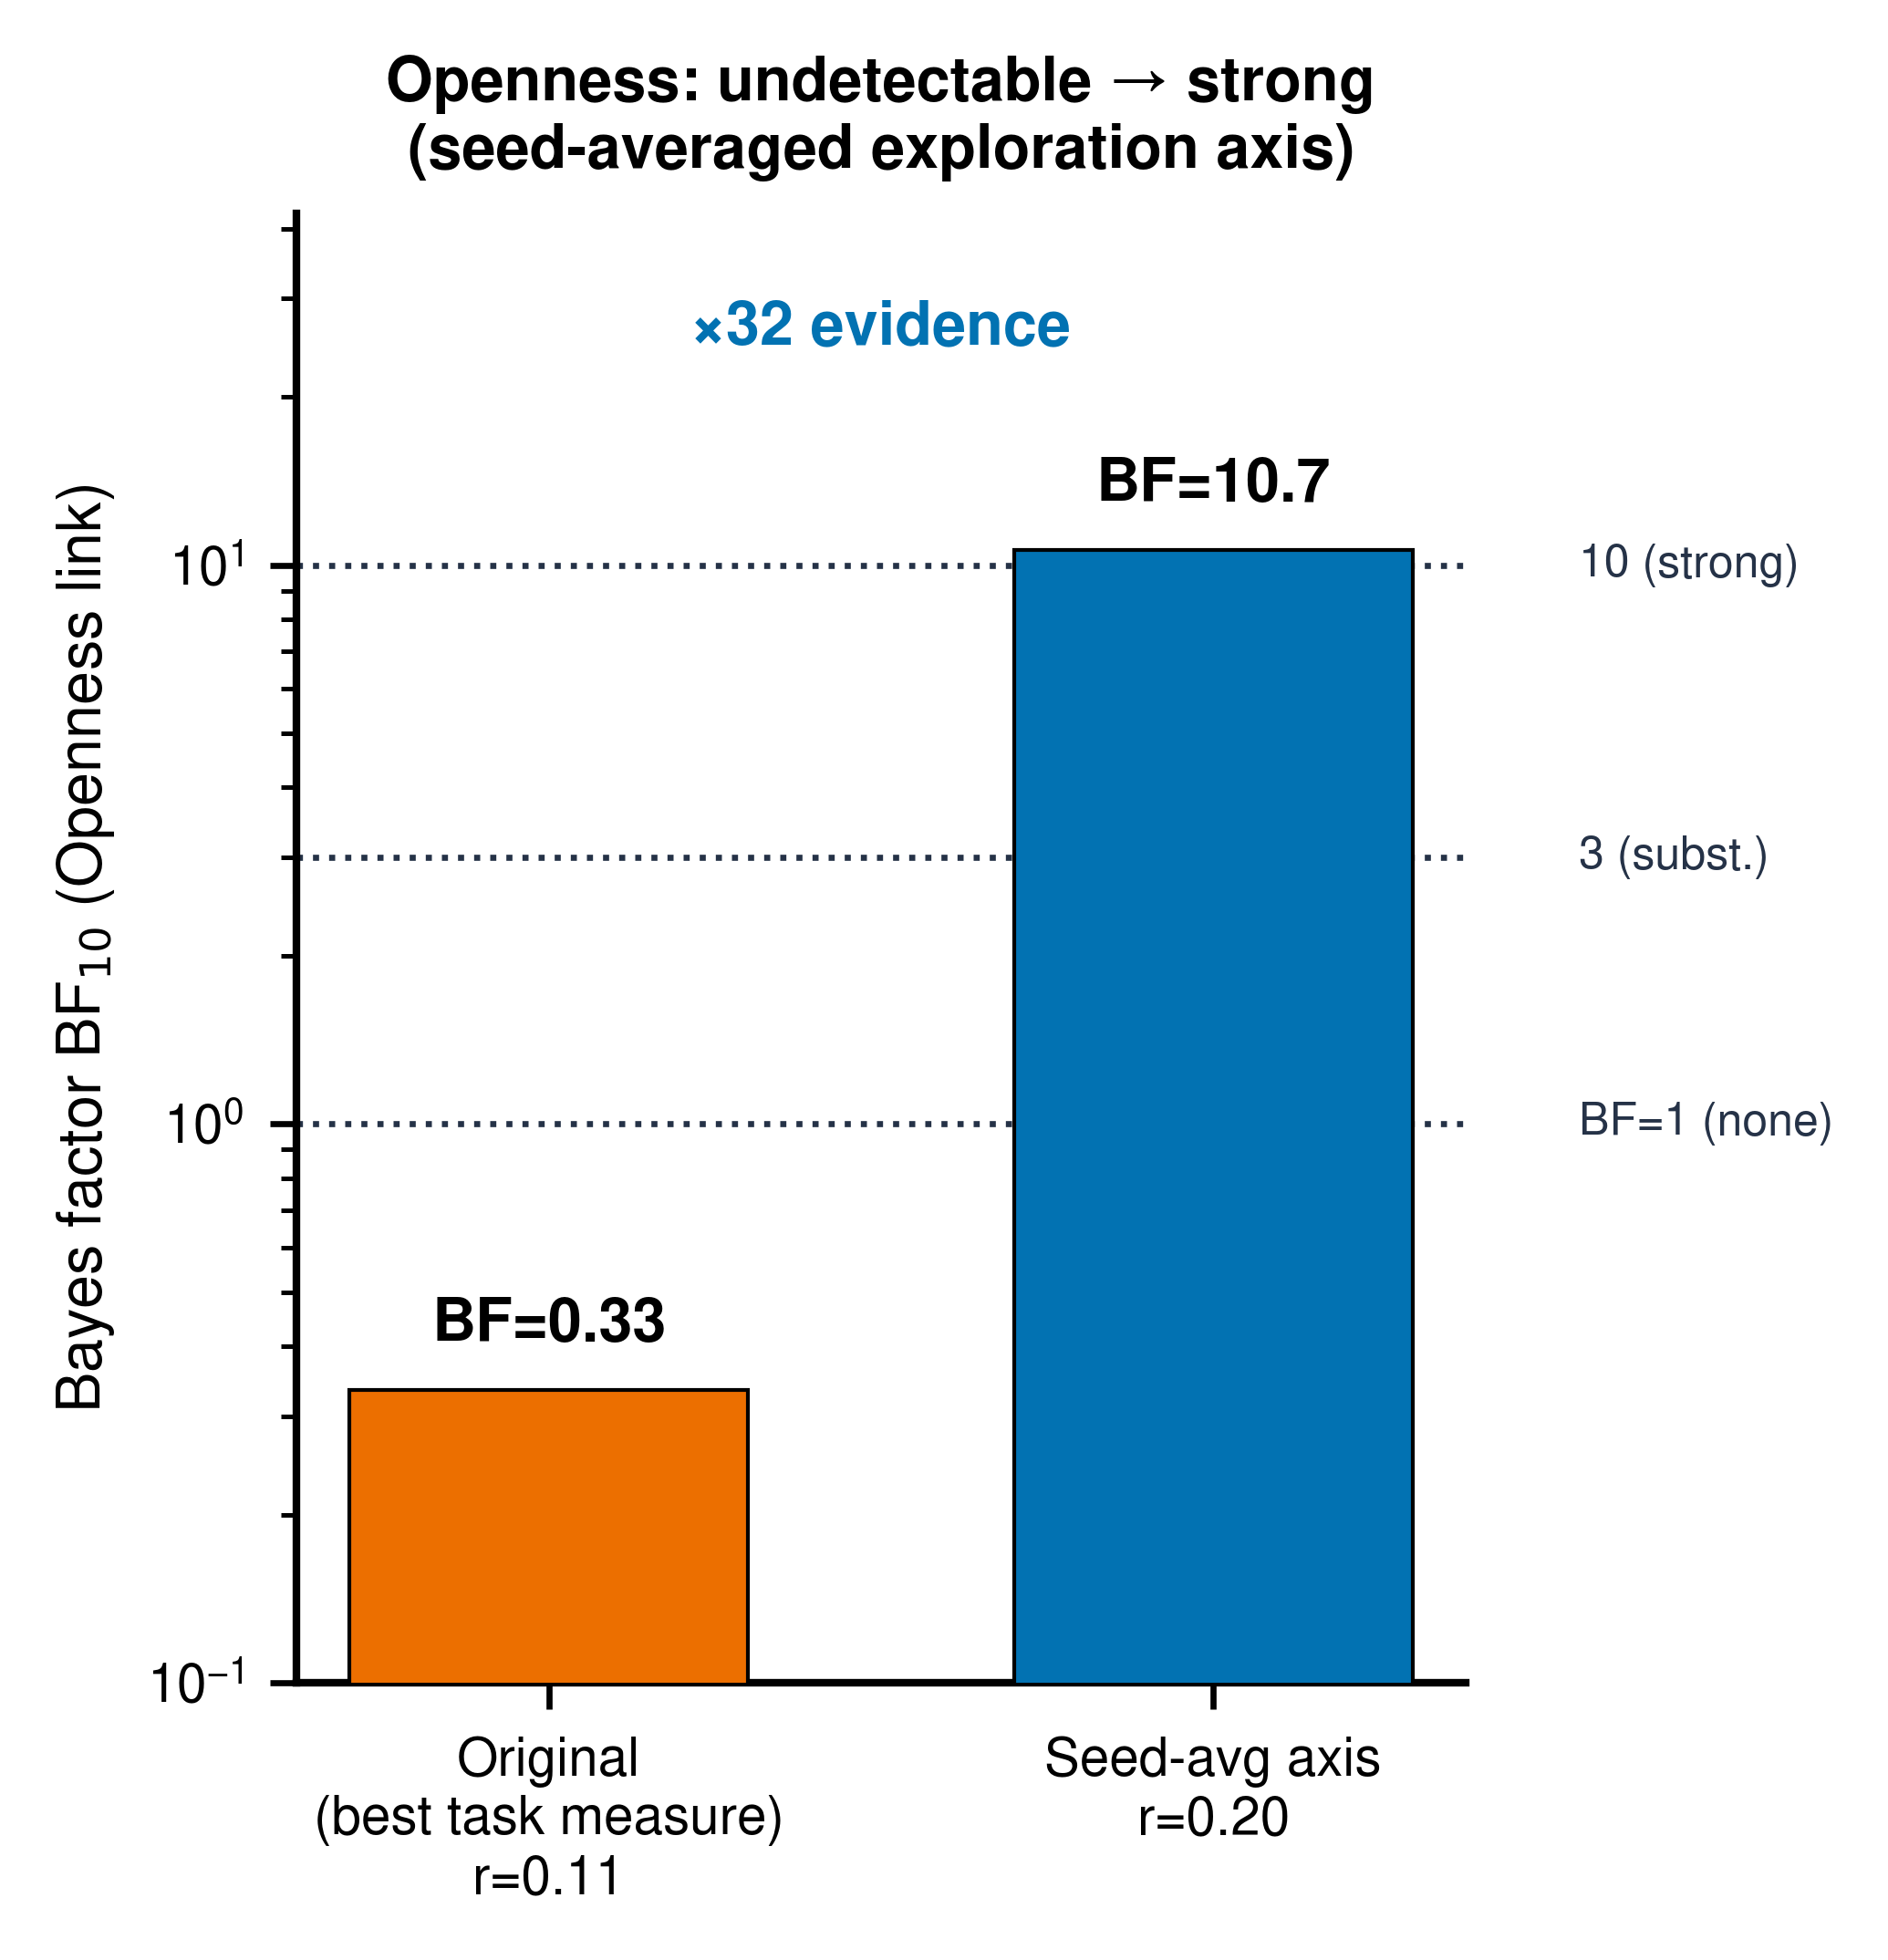

In [ ]:
# === panel — seed-averaged openness evidence vs original study ===
import numpy as np, pandas as pd
DEC = "final_plots/thalmann_z3_3task_full/decoding"
A = pd.read_csv(f"{DEC}/z2_seed_matched_alltraits.csv")
tg = pd.read_csv(f"{DEC}/trait_targets.csv")
n = int(np.isfinite(tg["BIG5_open"].values).sum())
r_ours = float(A["BIG5_open"].mean())                # mean of per-seed openness correlations
R_ORIG = 0.11                                        # original study's strongest Openness x task-measure
bf_orig = float(bayesfactor_pearson(R_ORIG, n)); bf_ours = float(bayesfactor_pearson(r_ours, n))
ratio = bf_ours / bf_orig
labels = [f"Original\n(best task measure)\nr={R_ORIG:.2f}", f"Seed-avg axis\nr={r_ours:.2f}"]
vals = [bf_orig, bf_ours]; cols = [COL_VANILLA, COL_IDRNN]
fig, ax = plt.subplots(figsize=(3.6, 3.6))
ax.bar([0, 1], vals, 0.6, color=cols, edgecolor="black", linewidth=0.5, zorder=3)
for thr, lab in [(1, "BF=1 (none)"), (3, "3 (subst.)"), (10, "10 (strong)")]:
    ax.axhline(thr, ls=":", color=COL_TRUE, lw=0.8, zorder=1)
    ax.text(1.55, thr, lab, va="center", ha="left", fontsize=6, color=COL_TRUE)
for i, v in enumerate(vals):
    ax.text(i, v*1.15, fmt_bf(v), ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.annotate(f"×{ratio:.0f} evidence", xy=(0.5, bf_ours), ha="center", va="bottom", fontsize=8,
            color=COL_IDRNN, fontweight="bold", xytext=(0.5, bf_ours*2.2), arrowprops=None)
ax.set_yscale("log"); ax.set_ylim(0.1, max(vals)*4)
ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel("Bayes factor BF$_{10}$ (Openness link)")
ax.set_title("Openness: undetectable → strong\n(seed-averaged exploration axis)")
fig.tight_layout(); fig.savefig(f"{DEC}/panel_seedavg_openness_evidence.png", dpi=600, bbox_inches="tight"); plt.show()
print(f"openness seed-avg r={r_ours:.3f} BF={bf_ours:.2f} | original r={R_ORIG} BF={bf_orig:.2f} | ratio {ratio:.0f}x")

## Poster panel — combined (a · b · c)
Panel **a** held-out NLL · **b** generative cross-task regret (R1–R4) · **c** out-of-sample LOO r. Native subplots in one figure with uniform fonts/sizes (mirrors the synthetic notebook's poster panel). Saves `final_plots/thalmann_poster_panel.{png,pdf,svg}`.

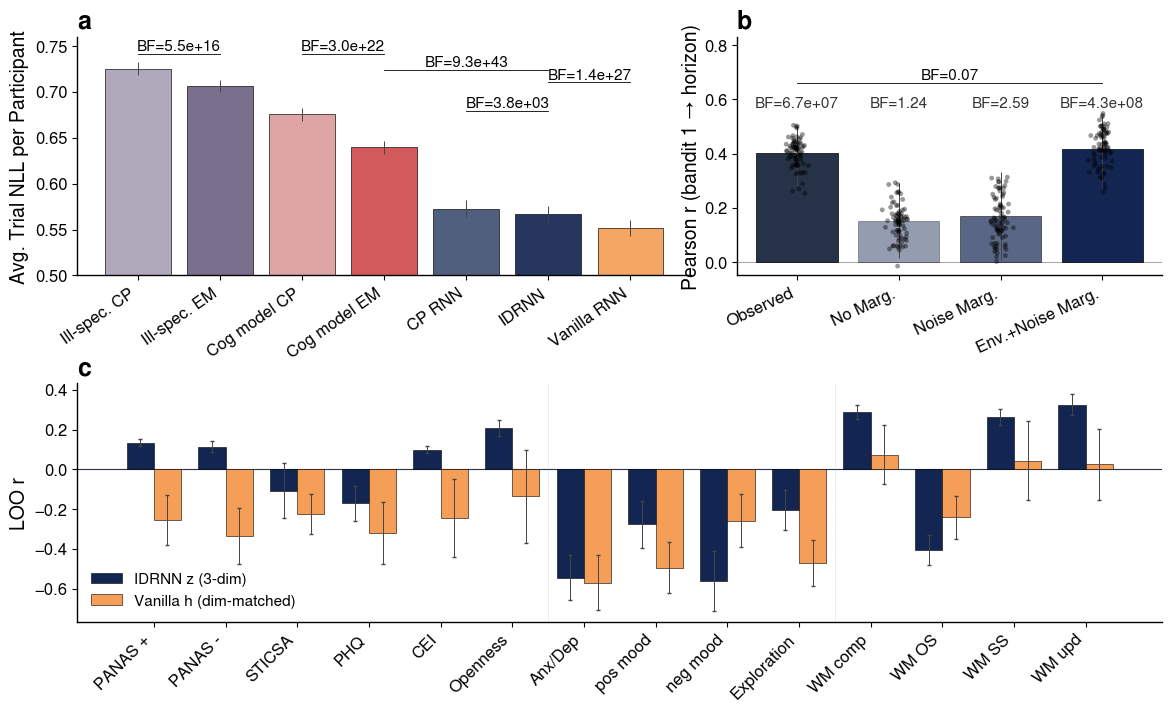

Saved final_plots/thalmann_poster_panel.png / .pdf / .svg


In [36]:
# === POSTER PANEL — a (held-out NLL) · b (generative cross-task regret) · c (out-of-sample LOO r) ===
# Combines three thalmann panels as NATIVE subplots in ONE figure, so the font family and every
# font size are identical across panels (compositing the saved PNGs would not be uniform — each was
# saved at its own figsize). Mirrors the "Poster panel" in synthetic_publication_panels.ipynb.
# Colours come from the COL_* variables in the setup cell, so editing the palette there updates this
# panel too. Self-contained: reads only light data files (CSV/NPZ/NPY); never runs seed-walking cells.
import matplotlib.gridspec as gridspec

# --- Uniform poster typography, applied to the whole figure via rc_context ---
FS_BASE, FS_LABEL, FS_TICK, FS_ANNOT, FS_LETTER = 13, 14, 12, 11, 18
POSTER_RC = {
    "font.size":       FS_BASE,
    "axes.titlesize":  FS_BASE,
    "axes.labelsize":  FS_LABEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_ANNOT,
    "mathtext.default": "regular",
}

def _bracket(ax, x1, x2, y, h, txt, fs=FS_ANNOT):
    ax.plot([x1, x2], [y + h, y + h], lw=0.6, c="black")
    ax.text((x1 + x2) / 2, y + h * 1.1, txt, ha="center", va="bottom", fontsize=fs)

with plt.rc_context(POSTER_RC):
    fig = plt.figure(figsize=(14, 7.6))
    gs = gridspec.GridSpec(2, 12, figure=fig, height_ratios=[1.0, 1.0],
                           hspace=0.45, wspace=0.95)
    ax_a = fig.add_subplot(gs[0, 0:7])
    ax_b = fig.add_subplot(gs[0, 7:12])
    ax_c = fig.add_subplot(gs[1, 0:12])

    # ============================================== Panel a: held-out NLL per participant
    df = pd.read_csv("final_plots/thalmann_z3_s2_pooled/per_participant_nll_marginal.csv")
    tid = np.load("data_thalmann_s2/task_ids_per_block.npy")
    nt0 = nt1 = 0.0
    for _f in range(3):
        _c = np.load(f"data_thalmann_s2/fold{_f}/c_test.npy"); _v = (_c >= 0)
        nt0 += _v[:, tid == 0].sum(); nt1 += _v[:, tid == 1].sum()
    chance = float((nt0 * np.log(2) + nt1 * np.log(4)) / (nt0 + nt1))
    cog_keys = [("nll_ill_cp", "Ill-spec. CP", COL_Q_CP), ("nll_ill_em", "Ill-spec. EM", COL_Q_EM),
                ("nll_cog_cp", "Cog model CP", COL_FQ_CP), ("nll_cog_em", "Cog model EM", COL_FQ_EM),
                ("nll_cp_rnn_all", "CP RNN", COL_RNN_CP), ("nll_idrnn_all", "IDRNN", COL_IDRNN),
                ("nll_vanilla_all", "Vanilla RNN", COL_VANILLA)]
    keys   = [k for k, _, _ in cog_keys]
    labels = [l for _, l, _ in cog_keys]
    cols   = [c for _, _, c in cog_keys]
    means  = [df[k].mean() for k in keys]
    sems   = [stats.sem(df[k].dropna()) for k in keys]
    xs     = np.arange(len(labels))
    bf_Q  = paired_bf(df["nll_ill_cp"],  df["nll_ill_em"])
    bf_FQ = paired_bf(df["nll_cog_cp"],  df["nll_cog_em"])
    bf_RNNCP_IDRNN = paired_bf(df["nll_cp_rnn_all"],  df["nll_idrnn_all"])
    bf_Van_IDRNN   = paired_bf(df["nll_vanilla_all"], df["nll_idrnn_all"])
    bf_IDRNN_FQ_EM = paired_bf(df["nll_cog_em"],      df["nll_idrnn_all"])
    ax_a.bar(xs, means, color=cols, alpha=0.92, edgecolor="black", linewidth=0.5, zorder=2)
    ax_a.errorbar(xs, means, yerr=sems, fmt="none", ecolor="#444444", elinewidth=0.7, capsize=0, zorder=3)
    ax_a.axhline(chance, ls=":", color=COL_TRUE, lw=1.2, zorder=1)
    ymax = max(means) + max(sems); h_step = 0.05 * (chance - min(means)); yb = ymax + h_step
    _bracket(ax_a, 0, 1, yb - 0.02,             h_step * 0.3, fmt_bf(bf_Q))
    _bracket(ax_a, 2, 3, yb - 0.02,             h_step * 0.3, fmt_bf(bf_FQ))
    _bracket(ax_a, 4, 5, yb - 3 * h_step - 0.02, h_step * 0.3, fmt_bf(bf_RNNCP_IDRNN))
    _bracket(ax_a, 5, 6, yb - h_step * 1.5 - 0.02, h_step * 0.3, fmt_bf(bf_Van_IDRNN))
    _bracket(ax_a, 3, 5, yb - 0.85 * h_step - 0.02, h_step * 0.3, fmt_bf(bf_IDRNN_FQ_EM))
    ax_a.set_xticks(xs); ax_a.set_xticklabels(labels, rotation=35, ha="right")
    ax_a.set_ylabel("Avg. Trial NLL per Participant")
    ax_a.set_ylim(bottom=0.5, top=0.76)  # chance line sits above this range (as in the standalone panel a)

    # ============================================== Panel b: generative cross-task regret (R1-R4)
    d = np.load("final_plots/thalmann_z3_s2_full/regret/step1_cross_task_regret.npz")
    subids = d["subids"].astype(int); y = d["hum_regret_task3"]
    ab = pd.read_csv("data/final2armedBanditSession1.csv"); o = {}
    for sid, grp in ab.groupby("ID"):
        arr = grp[["reward1", "reward2"]].values.astype(float)
        o[int(sid)] = float((arr.max(1) - grp["reward"].values).mean())
    R1 = np.array([o.get(int(sid), np.nan) for sid in subids])
    BARS = [("R1", R1, COL_TRUE, 1.00),
            ("R2", d["sim_regret_task0_r2_exact_single"], COL_IDRNN, 0.45),
            ("R3", d["sim_regret_task0_r3_exact_margrng"], COL_IDRNN, 0.70),
            ("R4", d["sim_regret_task0_r4_marg"], COL_IDRNN, 1.00)]
    recs = []; rng = np.random.default_rng(1)
    for lab, x, col, al in BARS:
        m = np.isfinite(x) & np.isfinite(y); xv, yv = x[m], y[m]; nbt = len(xv)
        r = float(pearsonr(xv, yv)[0]); boots = np.empty(2000)
        for i in range(2000):
            idx = rng.integers(0, nbt, nbt); boots[i] = np.corrcoef(xv[idx], yv[idx])[0, 1]
        lo, hi = np.nanpercentile(boots, [2.5, 97.5])
        recs.append(dict(label=lab, color=col, alpha=al, r=r, ci=(lo, hi), boots=boots,
                         bf=float(bayesfactor_pearson(r, nbt))))
    xs = np.arange(4); heights = [r["r"] for r in recs]
    sd_err = [float(np.std(r["boots"])) for r in recs]   # ±SD of the bootstrap-r distribution
    for xi, r in zip(xs, recs):
        ax_b.bar(xi, r["r"], color=r["color"], alpha=r["alpha"], edgecolor="black", linewidth=0.5, zorder=2)
    ax_b.errorbar(xs, heights, yerr=sd_err, fmt="none", ecolor="#444444",
                  elinewidth=0.7, capsize=0, zorder=3)
    allb = np.concatenate([r["boots"] for r in recs]); y_top = float(np.nanpercentile(allb, 99)) + 0.04
    for xi, r in zip(xs, recs):
        ax_b.text(xi, y_top, fmt_bf(r["bf"]), ha="center", fontsize=FS_ANNOT, color="#333333")
    mm = np.isfinite(R1) & np.isfinite(y) & np.isfinite(d["sim_regret_task0_r4_marg"])
    _zc = lambda a: (np.asarray(a, float) - np.asarray(a, float).mean()) / (np.asarray(a, float).std() + 1e-12)
    bf_cmp = paired_bf(_zc(R1[mm]) * _zc(y[mm]), _zc(d["sim_regret_task0_r4_marg"][mm]) * _zc(y[mm]))
    _bracket(ax_b, 0, 3, y_top + 0.06, 0.03, fmt_bf(bf_cmp))
    ax_b.axhline(0, color="grey", lw=0.5, zorder=1)
    ax_b.set_xticks(xs)
    ax_b.set_xticklabels(["Observed", "No Marg.", "Noise Marg.", "Env.+Noise Marg."], rotation=25, ha="right")
    ax_b.set_ylabel("Pearson r (bandit 1 → horizon)", labelpad=2)
    ax_b.set_ylim(min(0, min(heights)) - 0.05, y_top + 0.26)

    # ============================================== Panel c: out-of-sample LOO r (IDRNN vs dim-matched vanilla)
    FULL = "final_plots/thalmann_z3_3task_full"
    PERSONALITY = ["PANAS_PA", "PANAS_NA", "STICSA", "PHQ", "CEI", "BIG5_open"]
    COMPOSITE   = ["AxDep", "posMood", "negMood", "Exp"]
    WM_KEYS     = ["WM_composite", "WM_OS", "WM_SS", "WM_WMU"]
    ALL_KEYS    = PERSONALITY + COMPOSITE + WM_KEYS
    LBL = {"PANAS_PA": "PANAS +", "PANAS_NA": "PANAS -", "STICSA": "STICSA", "PHQ": "PHQ", "CEI": "CEI",
           "BIG5_open": "Openness", "AxDep": "Anx/Dep", "posMood": "pos mood", "negMood": "neg mood",
           "Exp": "Exploration", "WM_composite": "WM comp", "WM_OS": "WM OS", "WM_SS": "WM SS", "WM_WMU": "WM upd"}
    lbls = [LBL[k] for k in ALL_KEYS]
    x = np.arange(len(lbls)); w = 0.38
    dl = pd.read_csv(f"{FULL}/decoding/seed_averaged_decoding.csv").set_index("target").reindex(ALL_KEYS)
    ax_c.bar(x - w / 2, dl["idrnn_loo_r2_mean"], w, yerr=dl["idrnn_loo_r2_sd"], color=COL_IDRNN,
             edgecolor="black", linewidth=0.4, capsize=1.5, error_kw=dict(elinewidth=0.7, ecolor="#444444"),
             label="IDRNN z (3-dim)", zorder=2)
    ax_c.bar(x + w / 2, dl["vanilla_loo_r2_mean"], w, yerr=dl["vanilla_loo_r2_sd"], color=COL_VANILLA,
             edgecolor="black", linewidth=0.4, capsize=1.5, error_kw=dict(elinewidth=0.7, ecolor="#444444"),
             label="Vanilla h (dim-matched)", zorder=2)
    ax_c.axhline(0, color=COL_TRUE, lw=0.8, zorder=1)
    for xb in (len(PERSONALITY) - .5, len(PERSONALITY) + len(COMPOSITE) - .5):
        ax_c.axvline(xb, color="grey", lw=.5, ls=":", alpha=.5)
    ax_c.set_xticks(x); ax_c.set_xticklabels(lbls, rotation=45, ha="right")
    ax_c.set_ylabel("LOO $R^2$"); ax_c.legend(loc="lower left")

    # --- Panel letters (uniform, bold) ---
    for ax, lett in [(ax_a, "a"), (ax_b, "b"), (ax_c, "c")]:
        ax.set_title(lett, loc="left", fontweight="bold", fontsize=FS_LETTER)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    fig.savefig("final_plots/thalmann_poster_panel.png", dpi=300, bbox_inches="tight")
    fig.savefig("final_plots/thalmann_poster_panel.pdf", bbox_inches="tight")
    fig.savefig("final_plots/thalmann_poster_panel.svg", bbox_inches="tight")
    plt.show()
print("Saved final_plots/thalmann_poster_panel.png / .pdf / .svg")


## Poster panel 2 — consensus latent (a · b · c · d)
Panel **a** ensemble consensus-latent trait correlations (individual-difference axis) · **b** consensus latent vs overall switch rate · **c** openness decoding LOO R² vs #training tasks (IDRNN z vs dim-matched vanilla h) · **d** trait signal beyond working memory (raw vs partial | WM, n=175). Native subplots in one figure with uniform fonts/sizes (mirrors the synthetic poster panel). Saves `final_plots/thalmann_poster_panel2.{png,pdf,svg}`.

In [ ]:
# === POSTER PANEL 2 — consensus latent: a (individual-difference axis) · b (= switching) · c (switching | randomness) ===
# Combines three thalmann ensemble panels as NATIVE subplots in ONE figure, with uniform fonts/sizes
# (same POSTER_RC device as the synthetic notebook's poster panel). Panel a = consensus-latent trait
# correlations; b = consensus latent vs overall switch rate; c = per-task partial r(switch | entropy).
# Colours come from the COL_* set in the setup cell. Reads only light files (NPY/CSV); no seed walking.
import matplotlib.gridspec as gridspec
import pingouin as pg

FS_BASE, FS_LABEL, FS_TICK, FS_ANNOT, FS_LETTER = 13, 14, 12, 11, 18
FS_BFNUM = 9  # dense per-bar BF labels in panel a (14 bars) — sized to fit, axes text stays uniform
POSTER_RC = {
    "font.size":       FS_BASE,
    "axes.titlesize":  FS_BASE,
    "axes.labelsize":  FS_LABEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_ANNOT,
    "mathtext.default": "regular",
}

DEC = "final_plots/thalmann_z3_3task_full/decoding"
zc = np.load(f"{DEC}/z2_consensus_pca.npy")        # ensemble consensus latent (pooled PCA over seeds)
tg = pd.read_csv(f"{DEC}/trait_targets.csv")       # torch-free trait scores (subids_full order)

PERSONALITY = ["PANAS_PA", "PANAS_NA", "STICSA", "PHQ", "CEI", "BIG5_open"]
COMPOSITE   = ["AxDep", "posMood", "negMood", "Exp"]
WM_KEYS     = ["WM_composite", "WM_OS", "WM_SS", "WM_WMU"]
ALL_KEYS = PERSONALITY + COMPOSITE + WM_KEYS
LBL = {"PANAS_PA": "PANAS +", "PANAS_NA": "PANAS −", "STICSA": "STICSA", "PHQ": "PHQ", "CEI": "CEI",
       "BIG5_open": "Openness", "AxDep": "Anx/Dep", "posMood": "pos mood", "negMood": "neg mood",
       "Exp": "Exploration", "WM_composite": "WM comp", "WM_OS": "WM OS", "WM_SS": "WM SS", "WM_WMU": "WM upd"}

def corr_n(y):
    m = np.isfinite(zc) & np.isfinite(y)
    return float(pearsonr(zc[m], y[m])[0]), int(m.sum())

c   = np.load("data_thalmann_3task_full/c_train.npy")
tid = np.load("data_thalmann_3task_full/task_ids_per_block.npy")
N = c.shape[0]

def switch_rate(bl):
    s = p = 0
    for b in range(bl.shape[0]):
        ch = bl[b]; ch = ch[ch >= 0]
        if len(ch) < 2:
            continue
        s += int((ch[1:] != ch[:-1]).sum()); p += len(ch) - 1
    return s / p if p else np.nan

def entropy(bl, k):
    ch = bl[bl >= 0].astype(int)
    if len(ch) == 0:
        return np.nan
    pr = np.bincount(ch, minlength=k) / len(ch); pr = pr[pr > 0]
    return float(-(pr * np.log(pr)).sum())

TASKS = [("2-armed", tid == 0, 2), ("restless", tid == 1, 4), ("horizon", tid == 2, 2)]
SW = {t: np.array([switch_rate(c[i][m]) for i in range(N)]) for t, m, k in TASKS}
EN = {t: np.array([entropy(c[i][m], k) for i in range(N)]) for t, m, k in TASKS}
sw_all = np.array([switch_rate(c[i]) for i in range(N)])

with plt.rc_context(POSTER_RC):
    fig = plt.figure(figsize=(15, 7.2))
    gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[1.0, 1.0], hspace=0.5, wspace=0.3)
    ax_a = fig.add_subplot(gs[0, :])
    ax_b = fig.add_subplot(gs[1, 0])
    ax_c = fig.add_subplot(gs[1, 1])
    ax_d = fig.add_subplot(gs[1, 2])

    # ============================================== Panel a: individual-difference axis (14 traits)
    labels = [LBL[k] for k in ALL_KEYS]; x = np.arange(len(labels))
    r = np.array([corr_n(tg[k].values)[0] for k in ALL_KEYS])
    bf = [float(bayesfactor_pearson(*corr_n(tg[k].values))) for k in ALL_KEYS]
    ax_a.bar(x, r, 0.6, color=COL_IDRNN, edgecolor="black", linewidth=0.4, zorder=2)
    ax_a.axhline(0, color=COL_TRUE, lw=0.8)
    for i, (v, b) in enumerate(zip(r, bf)):
        ax_a.text(x[i], v + (0.02 if v >= 0 else -0.02), fmt_bf(b).replace("BF=", ""), ha="center",
                  va="bottom" if v >= 0 else "top", fontsize=FS_BFNUM, color="#222222")
    for xb in (len(PERSONALITY) - .5, len(PERSONALITY) + len(COMPOSITE) - .5):
        ax_a.axvline(xb, color="grey", lw=.5, ls=":", alpha=.5)
    ax_a.set_xticks(x); ax_a.set_xticklabels(labels, rotation=45, ha="right")
    ax_a.set_ylim(min(r) - 0.22, max(r) + 0.22)
    ax_a.set_ylabel("Pearson r with PC1")

    # ============================================== Panel b: consensus latent vs overall switch rate
    rr, _ = pearsonr(zc, sw_all); bf_b = float(bayesfactor_pearson(rr, N))
    ax_b.scatter(zc, sw_all, s=14, color=COL_IDRNN, alpha=0.5, edgecolors="none", zorder=2)
    bb = np.polyfit(zc, sw_all, 1); xs = np.linspace(zc.min(), zc.max(), 50)
    ax_b.plot(xs, bb[0] * xs + bb[1], "r:", lw=1.5, zorder=3)
    ax_b.text(0.04, 0.96, f"r = {rr:.2f}\n{fmt_bf(bf_b)}", transform=ax_b.transAxes,
              va="top", ha="left", fontsize=FS_ANNOT)
    ax_b.set_xlabel("PC1"); ax_b.set_ylabel("switch rate (all tasks)")

    # ============================================== Panel c: openness readout climbs with #training tasks
    # Data-scaling: openness decoding LOO R² (seed-averaged, IDRNN z vs dim-matched vanilla h) vs #tasks.
    _SUBSETS = {"t0": (1, "2-armed"), "t1": (1, "restless"), "t2": (1, "horizon"),
                "t01": (2, "2-arm+rest"), "t02": (2, "2-arm+horiz"), "t12": (2, "rest+horiz"),
                "t012": (3, "all 3")}
    _FALLBACK = {"t1": "thalmann_z3_1task_full", "t01": "thalmann_z3_full", "t012": "thalmann_z3_3task_full"}
    def _load_decode(sub):
        p = f"final_plots/thalmann_z3_ds_{sub}/decoding/seed_averaged_decoding.csv"
        if not os.path.exists(p) and sub in _FALLBACK:
            p = f"final_plots/{_FALLBACK[sub]}/decoding/seed_averaged_decoding.csv"
        return pd.read_csv(p).set_index("target") if os.path.exists(p) else None
    def _collect(tgts):
        rr = {}
        for sub, (nn, lab) in _SUBSETS.items():
            dd = _load_decode(sub)
            if dd is None:
                continue
            tk = [t for t in tgts if t in dd.index]
            if not tk:
                continue
            rr[sub] = dict(n=nn,
                im=np.mean([dd.loc[t, "idrnn_loo_r2_mean"] for t in tk]),
                isd=np.mean([dd.loc[t, "idrnn_loo_r2_sd"] for t in tk]) / np.sqrt(len(tk)),
                vm=np.mean([dd.loc[t, "vanilla_loo_r2_mean"] for t in tk]),
                vsd=np.mean([dd.loc[t, "vanilla_loo_r2_sd"] for t in tk]) / np.sqrt(len(tk)))
        return rr
    _ds_pc = pd.read_csv("final_plots/thalmann_z3_datascaling/datascaling_panel.csv")
    _ds_pc = _ds_pc[_ds_pc.group == "openness"]
    for arch, col, off, ls, mk, lab in [("idrnn", COL_IDRNN, -0.12, "-", "o", "IDRNN z"),
                                        ("vanilla", COL_VANILLA, +0.12, "--", "s", "Vanilla h (dim-matched)")]:
        _a = _ds_pc[_ds_pc.arch == arch]; _mx, _my = [], []
        for _K in (1, 2, 3):
            _ck = _a[_a.ntasks == _K].reset_index(drop=True); _m = len(_ck)
            for _j in range(_m):
                ax_c.errorbar(_K + off + (_j - (_m - 1) / 2) * 0.06, _ck.canonical_r2[_j], yerr=_ck.boot_sd[_j],
                            fmt=mk, ms=3, color=col, alpha=0.45, elinewidth=0.6, capsize=1.2, zorder=2)
            _mx.append(_K + off); _my.append(float(_ck.canonical_r2.mean()))
        ax_c.plot(_mx, _my, ls=ls, color=col, lw=1.5, zorder=3)                       # mean-of-means climb line
        ax_c.plot(_mx[:2], _my[:2], ls="none", marker=mk, color=col, ms=5.5, zorder=4, label=lab)  # mean-of-means (#tasks 1,2 only)
    ax_c.axhline(0, color=COL_TRUE, lw=.6, ls=":")
    ax_c.set_xticks([1, 2, 3]); ax_c.set_xlabel("# training tasks")
    ax_c.set_ylabel("Openness readout LOO $R^2$"); ax_c.legend(loc="upper left", fontsize=FS_ANNOT - 2)

    # ============================================== Panel d: trait signal beyond working memory (raw vs partial | WM)
    # Same-sample comparison: raw AND partial both on the WM-complete subsample (n=175; matches cell 75,
    # NOT panel a, whose raw bars use all n=236 pairwise-complete cases).
    TRAITS = [("BIG5_open", "Openness"), ("CEI", "Curiosity")]
    dfw = pd.DataFrame({"z": zc, "WM": tg["WM_composite"].values,
                        **{k: tg[k].values for k, _ in TRAITS}}).dropna()
    n_wm = len(dfw); raw, par, bfs_d = [], [], []
    for k, _ in TRAITS:
        raw.append(float(pg.corr(dfw["z"], dfw[k])["r"].values[0]))
        rp = float(pg.partial_corr(dfw, x="z", y=k, covar="WM")["r"].values[0])
        par.append(rp); bfs_d.append(float(bayesfactor_pearson(rp, n_wm - 1)))
    xd = np.arange(len(TRAITS)); wd = 0.38; GREY = nature_colors["Grey"][3]
    ax_d.bar(xd - wd / 2, raw, wd, color=GREY, edgecolor="black", lw=0.4, label="raw  r", zorder=2)
    ax_d.bar(xd + wd / 2, par, wd, color=COL_IDRNN, edgecolor="black", lw=0.4, label="partial  r | WM", zorder=2)
    ax_d.axhline(0, color=COL_TRUE, lw=0.8)
    for i, (rp, bff) in enumerate(zip(par, bfs_d)):
        ax_d.text(xd[i] + wd / 2, rp + (0.012 if rp >= 0 else -0.012), fmt_bf(bff).replace("BF=", ""),
                  ha="center", va="bottom" if rp >= 0 else "top", fontsize=FS_ANNOT, color=COL_TRUE)
    ax_d.set_xticks(xd); ax_d.set_xticklabels([l for _, l in TRAITS])
    ax_d.set_ylabel("Pearson r  with PC1")
    ax_d.set_ylim(top=max(max(raw), max(par)) + 0.10)
    ax_d.legend(loc="upper right")

    # --- Panel letters (uniform, bold) ---
    for ax, lett in [(ax_a, "a"), (ax_b, "b"), (ax_c, "c"), (ax_d, "d")]:
        ax.set_title(lett, loc="left", fontweight="bold", fontsize=FS_LETTER)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    fig.savefig("final_plots/thalmann_poster_panel2.png", dpi=300, bbox_inches="tight")
    fig.savefig("final_plots/thalmann_poster_panel2.pdf", bbox_inches="tight")
    fig.savefig("final_plots/thalmann_poster_panel2.svg", bbox_inches="tight")
    plt.show()
print("Saved final_plots/thalmann_poster_panel2.png / .pdf / .svg")


## Poster panel 3 — openness (a · b)
Panel **a** ensemble consensus-latent openness BF₁₀ vs the original study's best task measure (evidence increase) · **b** openness decoding LOO R² (seed-averaged, IDRNN z vs dim-matched vanilla h) vs the number of training tasks. Native subplots in one figure with uniform fonts/sizes (mirrors the synthetic poster panel). Saves `final_plots/thalmann_poster_panel3.{png,pdf,svg}`.

In [ ]:
# === POSTER PANEL 3 — openness: a (evidence increase over original study) · b (readout climbs with #tasks) ===
# Two thalmann openness panels as NATIVE subplots in ONE figure with uniform fonts/sizes (same POSTER_RC
# device as the synthetic poster panel). a: ensemble consensus-latent openness BF vs the original study's
# best task measure. b: openness decoding LOO R² (seed-averaged, IDRNN z vs dim-matched vanilla h) vs the
# number of training tasks. Colours come from the COL_* set in the setup cell. Reads only light files.
import os
import matplotlib.gridspec as gridspec

FS_BASE, FS_LABEL, FS_TICK, FS_ANNOT, FS_LETTER = 13, 14, 12, 11, 18
POSTER_RC = {
    "font.size":       FS_BASE,
    "axes.titlesize":  FS_BASE,
    "axes.labelsize":  FS_LABEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_ANNOT,
    "mathtext.default": "regular",
}

DEC = "final_plots/thalmann_z3_3task_full/decoding"
zc = np.load(f"{DEC}/z2_consensus_pca.npy")
tg = pd.read_csv(f"{DEC}/trait_targets.csv")

def corr_n(y):
    m = np.isfinite(zc) & np.isfinite(y)
    return float(pearsonr(zc[m], y[m])[0]), int(m.sum())

# --- data-scaling helpers (per-subset seed-averaged decoding) ---
SUBSETS = {"t0": (1, "2-armed"), "t1": (1, "restless"), "t2": (1, "horizon"),
           "t01": (2, "2-arm+rest"), "t02": (2, "2-arm+horiz"), "t12": (2, "rest+horiz"),
           "t012": (3, "all 3")}
FALLBACK = {"t1": "thalmann_z3_1task_full", "t01": "thalmann_z3_full", "t012": "thalmann_z3_3task_full"}

def load_decode(sub):
    p = f"final_plots/thalmann_z3_ds_{sub}/decoding/seed_averaged_decoding.csv"
    if not os.path.exists(p) and sub in FALLBACK:
        p = f"final_plots/{FALLBACK[sub]}/decoding/seed_averaged_decoding.csv"
    return pd.read_csv(p).set_index("target") if os.path.exists(p) else None

def collect(targets):
    rows = {}
    for sub, (nn, lab) in SUBSETS.items():
        df = load_decode(sub)
        if df is None:
            continue
        tk = [t for t in targets if t in df.index]
        if not tk:
            continue
        rows[sub] = dict(n=nn,
            im=np.mean([df.loc[t, "idrnn_loo_r2_mean"] for t in tk]),
            isd=np.mean([df.loc[t, "idrnn_loo_r2_sd"] for t in tk]) / np.sqrt(len(tk)),
            vm=np.mean([df.loc[t, "vanilla_loo_r2_mean"] for t in tk]),
            vsd=np.mean([df.loc[t, "vanilla_loo_r2_sd"] for t in tk]) / np.sqrt(len(tk)))
    return rows

with plt.rc_context(POSTER_RC):
    fig = plt.figure(figsize=(9.6, 3.7))
    gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.32)
    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])

    # ============================================== Panel a: openness evidence vs original study
    R_ORIG = 0.11
    r_ours, n = corr_n(tg["BIG5_open"].values)
    bf_orig = float(bayesfactor_pearson(R_ORIG, n)); bf_ours = float(bayesfactor_pearson(r_ours, n))
    ratio = bf_ours / bf_orig
    labels = [f"Original\n(best task measure)\nr={R_ORIG:.2f}", f"Ensemble latent\nr={r_ours:.2f}"]
    vals = [bf_orig, bf_ours]
    ax_a.bar([0, 1], vals, 0.6, color=[COL_VANILLA, COL_IDRNN], edgecolor="black", linewidth=0.5, zorder=3)
    for thr, lab in [(1, "BF=1 (none)"), (3, "3 (subst.)"), (10, "10 (strong)")]:
        ax_a.axhline(thr, ls=":", color=COL_TRUE, lw=0.8, zorder=1)
        ax_a.text(1.62, thr, lab, va="center", ha="left", fontsize=FS_ANNOT - 2, color=COL_TRUE)
    for i, v in enumerate(vals):
        ax_a.text(i, v * 1.15, fmt_bf(v), ha="center", va="bottom", fontsize=FS_ANNOT, fontweight="bold")
    ax_a.annotate(f"×{ratio:.0f} evidence", xy=(0.5, bf_ours), ha="center", va="bottom",
                  fontsize=FS_ANNOT, color=COL_IDRNN, fontweight="bold", xytext=(0.5, bf_ours * 2.2))
    ax_a.set_yscale("log"); ax_a.set_ylim(0.1, max(vals) * 4); ax_a.set_xlim(-0.6, 2.6)
    ax_a.set_xticks([0, 1]); ax_a.set_xticklabels(labels)
    ax_a.set_ylabel("BF$_{10}$ Openness encoding")

    # ============================================== Panel b: openness readout climbs with #tasks
    _ds_pc = pd.read_csv("final_plots/thalmann_z3_datascaling/datascaling_panel.csv")
    _ds_pc = _ds_pc[_ds_pc.group == "openness"]
    for arch, col, off, ls, mk, lab in [("idrnn", COL_IDRNN, -0.12, "-", "o", "IDRNN z"),
                                        ("vanilla", COL_VANILLA, +0.12, "--", "s", "Vanilla h (dim-matched)")]:
        _a = _ds_pc[_ds_pc.arch == arch]; _mx, _my = [], []
        for _K in (1, 2, 3):
            _ck = _a[_a.ntasks == _K].reset_index(drop=True); _m = len(_ck)
            for _j in range(_m):
                ax_b.errorbar(_K + off + (_j - (_m - 1) / 2) * 0.06, _ck.canonical_r2[_j], yerr=_ck.boot_sd[_j],
                            fmt=mk, ms=3, color=col, alpha=0.45, elinewidth=0.6, capsize=1.2, zorder=2)
            _mx.append(_K + off); _my.append(float(_ck.canonical_r2.mean()))
        ax_b.plot(_mx, _my, ls=ls, color=col, lw=1.5, zorder=3)                       # mean-of-means climb line
        ax_b.plot(_mx[:2], _my[:2], ls="none", marker=mk, color=col, ms=5.5, zorder=4, label=lab)  # mean-of-means (#tasks 1,2 only)
    ax_b.axhline(0, color=COL_TRUE, lw=.6, ls=":")
    ax_b.set_xticks([1, 2, 3]); ax_b.set_xlabel("# training tasks")
    ax_b.set_ylabel("Openness readout LOO $R^2$"); ax_b.legend(loc="upper left")

    # --- Panel letters (uniform, bold) ---
    for ax, lett in [(ax_a, "a"), (ax_b, "b")]:
        ax.set_title(lett, loc="left", fontweight="bold", fontsize=FS_LETTER)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    fig.savefig("final_plots/thalmann_poster_panel3.png", dpi=300, bbox_inches="tight")
    fig.savefig("final_plots/thalmann_poster_panel3.pdf", bbox_inches="tight")
    fig.savefig("final_plots/thalmann_poster_panel3.svg", bbox_inches="tight")
    plt.show()
print(f"Saved thalmann_poster_panel3 — openness r={r_ours:.3f} BF={bf_ours:.1f} (×{ratio:.0f} vs original)")


## Poster panel 1 — bootstrap-c variant (a · b · c)
Identical to poster panel 1, except **panel c**'s bars/error bars come from the **train-resample bootstrap** (B=500): each iteration does LOO over the real participants with the **training fold bootstrap-resampled and the readout refit** (test participant excluded first → no CV leakage), then averages R² over the 10 seeds. Bar = mean of the 500 R² values; error bar = ±SD of those 500 values. This isolates readout-fitting (training-sample) uncertainty. Saves `final_plots/thalmann_poster_panel_bootc.{png,pdf,svg}`.

In [ ]:
# === JOURNAL FIGURE (Nature Human Behaviour) — a (reward structures) · b (LOO R²) · c (NLL) · d (regret) ===
# Combines three thalmann panels as NATIVE subplots in ONE figure, so the font family and every
# font size are identical across panels (compositing the saved PNGs would not be uniform — each was
# saved at its own figsize). Mirrors the "Poster panel" in synthetic_publication_panels.ipynb.
# Colours come from the COL_* variables in the setup cell, so editing the palette there updates this
# panel too. Self-contained: reads only light data files (CSV/NPZ/NPY); never runs seed-walking cells.
import matplotlib.gridspec as gridspec
MM = 1 / 25.4
W_FULL = 180 * MM     # 180 mm = 7.087 in (NHB double-column hard max); also defined in setup cell

# --- Uniform poster typography, applied to the whole figure via rc_context ---
FS_BASE, FS_LABEL, FS_TICK, FS_ANNOT, FS_LETTER = 6, 6, 6, 5, 8
POSTER_RC = {
    "font.size":       FS_BASE,
    "axes.titlesize":  FS_BASE,
    "axes.labelsize":  FS_LABEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_ANNOT,
    "mathtext.default": "regular",
}

def _bracket(ax, x1, x2, y, h, txt, fs=FS_ANNOT):
    ax.plot([x1, x2], [y + h, y + h], lw=0.6, c="black")
    ax.text((x1 + x2) / 2, y + h * 1.1, txt, ha="center", va="bottom", fontsize=fs)




# ---- Panel a helpers: reward-structure schematic (native redraw of the TikZ figure) ----
_ARM = {"red": (237/255, 83/255, 80/255), "cyan": (38/255, 198/255, 218/255),
        "green": (102/255, 205/255, 109/255), "purple": (171/255, 99/255, 205/255)}

def _rw_walk(n, seed):                       # restless-arm reward walk (reproduces coords.tex)
    r = np.random.default_rng(seed)
    mu = np.zeros(n); mu[0] = r.uniform(35, 65)
    for t in range(1, n):
        mu[t] = 0.9836 * mu[t - 1] + (1 - 0.9836) * 50 + r.normal(0, 2.8)
    return mu

def _reward_frame(ax, title, xlim, xticks, subtitle):
    ax.set_xlim(*xlim); ax.set_xticks(xticks)
    ax.set_ylim(25, 75); ax.set_yticks([30, 50, 70])
    ax.set_xlabel("trial", labelpad=2)
    ax.set_title(title, loc="center", fontweight="normal", fontsize=FS_TICK, pad=4)
    ax.tick_params(length=3)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.text(0.5, -0.255, subtitle, transform=ax.transAxes, ha="center", va="top",
            fontsize=FS_ANNOT, color="black")

def _draw_reward_structures(ax1, ax2, ax3):
    # --- Horizon task ---
    ax1.axvspan(1, 4.5, color=(0.93, 0.93, 0.93), lw=0, zorder=0)
    ax1.axvline(4.5, ls=(0, (4, 3)), color=(0, 0, 0, 0.5), lw=0.8, zorder=1)
    ax1.plot([1, 10], [56, 56], color=_ARM["red"],  lw=1.0, solid_capstyle="round", zorder=2)
    ax1.plot([1, 10], [44, 44], color=_ARM["cyan"], lw=1.0, solid_capstyle="round", zorder=2)
    ax1.annotate("", xy=(9.28, 55.2), xytext=(9.28, 44.8),
                 arrowprops=dict(arrowstyle="<->", color=(0, 0, 0, 0.6), lw=0.8))
    ax1.text(9.05, 50, r"$\Delta$", ha="right", va="center", fontsize=FS_ANNOT, color="black")
    ax1.text(2.75, 33, "forced", rotation=90, ha="center", va="center", fontsize=FS_ANNOT, color="black")
    ax1.text(5.1, 32.5, "1 or 6 free\nchoices", ha="left", va="center", fontsize=FS_ANNOT, color="black")
    _reward_frame(ax1, "Horizon task", (1, 10), [1, 5, 10], "stable, $\\Delta$ = 4–30\n80 rounds")
    ax1.set_ylabel("mean reward", labelpad=2)
    # --- Two-armed bandit ---
    _rng = np.random.default_rng(0)
    stable = 46.0 * np.ones(10)
    drift = np.zeros(10); drift[0] = 52
    for t in range(1, 10):
        drift[t] = drift[t - 1] + _rng.normal(0, 3.0)
    tt = np.arange(1, 11)
    ax2.plot(tt, stable, color=_ARM["cyan"], lw=1.0, solid_capstyle="round", zorder=2)
    ax2.plot(tt, drift,  color=_ARM["red"],  lw=1.0, solid_capstyle="round", zorder=2)
    ax2.text(1.2, 45, "stable",   ha="left", va="top",    fontsize=FS_ANNOT,
             color=tuple(0.6 * c for c in _ARM["cyan"]))
    ax2.text(1.2, 54, "drifting", ha="left", va="bottom", fontsize=FS_ANNOT,
             color=tuple(0.75 * c for c in _ARM["red"]))
    _reward_frame(ax2, "Two-armed bandit", (1, 10), [1, 5, 10], "stable and/or drifting\n30 rounds")
    # --- Restless bandit ---
    tr = np.arange(1, 201)
    for k, col in zip(range(4), ["red", "cyan", "green", "purple"]):
        ax3.plot(tr, _rw_walk(200, 9 * 4 + k), color=_ARM[col], lw=0.6, solid_capstyle="round", zorder=2)
    _reward_frame(ax3, "Restless bandit", (1, 200), [1, 100, 200], "4 drifting arms\n1 round")

with plt.rc_context(POSTER_RC):
    fig = plt.figure(figsize=(W_FULL, 5.0))
    outer = fig.add_gridspec(2, 1, height_ratios=[0.62, 1.0], hspace=0.42)

    # ---- Row 0: panel a — reward structures (three native sub-axes, grouped & centred) ----
    gs_top = outer[0].subgridspec(1, 20, wspace=0.0)
    ax_a1 = fig.add_subplot(gs_top[0, 2:6])
    ax_a2 = fig.add_subplot(gs_top[0, 8:12])
    ax_a3 = fig.add_subplot(gs_top[0, 14:18])
    _draw_reward_structures(ax_a1, ax_a2, ax_a3)

    # ---- Row 1: data panels (b · c · d) ----
    gs_bot = outer[1].subgridspec(1, 30, wspace=0.45)
    ax_c = fig.add_subplot(gs_bot[0, 0:15])   # LOO R²  -> b
    ax_a = fig.add_subplot(gs_bot[0, 16:24])  # NLL     -> c
    ax_b = fig.add_subplot(gs_bot[0, 25:30])  # regret  -> d

    # ============================================== Panel a: held-out NLL per participant
    df = pd.read_csv("final_plots/thalmann_z3_s2_pooled/per_participant_nll_marginal.csv")
    tid = np.load("data_thalmann_s2/task_ids_per_block.npy")
    nt0 = nt1 = 0.0
    for _f in range(3):
        _c = np.load(f"data_thalmann_s2/fold{_f}/c_test.npy"); _v = (_c >= 0)
        nt0 += _v[:, tid == 0].sum(); nt1 += _v[:, tid == 1].sum()
    chance = float((nt0 * np.log(2) + nt1 * np.log(4)) / (nt0 + nt1))
    cog_keys = [("nll_ill_cp", "Ill-spec. CP", COL_Q_CP), ("nll_ill_em", "Ill-spec. EM", COL_Q_EM),
                ("nll_cog_cp", "Cog model CP", COL_FQ_CP), ("nll_cog_em", "Cog model EM", COL_FQ_EM),
                ("nll_cp_rnn_all", "CP RNN", COL_RNN_CP), ("nll_idrnn_all", "IDRNN", COL_IDRNN),
                ("nll_vanilla_all", "Vanilla RNN", COL_VANILLA)]
    keys   = [k for k, _, _ in cog_keys]
    labels = [l for _, l, _ in cog_keys]
    cols   = [c for _, _, c in cog_keys]
    means  = [df[k].mean() for k in keys]
    sems   = [stats.sem(df[k].dropna()) for k in keys]
    xs     = np.arange(len(labels))
    bf_Q  = paired_bf(df["nll_ill_cp"],  df["nll_ill_em"])
    bf_FQ = paired_bf(df["nll_cog_cp"],  df["nll_cog_em"])
    bf_RNNCP_IDRNN = paired_bf(df["nll_cp_rnn_all"],  df["nll_idrnn_all"])
    bf_Van_IDRNN   = paired_bf(df["nll_vanilla_all"], df["nll_idrnn_all"])
    bf_IDRNN_FQ_EM = paired_bf(df["nll_cog_em"],      df["nll_idrnn_all"])
    ax_a.bar(xs, means, color=cols, alpha=0.92, edgecolor="black", linewidth=0.5, zorder=2)
    ax_a.errorbar(xs, means, yerr=sems, fmt="none", ecolor="#444444", elinewidth=0.7, capsize=0, zorder=3)
    ax_a.axhline(chance, ls=":", color=COL_TRUE, lw=1.2, zorder=1)
    ymax = max(means) + max(sems); h_step = 0.05 * (chance - min(means)); yb = ymax + h_step
    _bracket(ax_a, 0, 1, yb - 0.02,             h_step * 0.3, fmt_bf(bf_Q))
    _bracket(ax_a, 2, 3, yb - 0.02,             h_step * 0.3, fmt_bf(bf_FQ))
    _bracket(ax_a, 4, 5, yb - 3 * h_step - 0.02, h_step * 0.3, fmt_bf(bf_RNNCP_IDRNN))
    _bracket(ax_a, 5, 6, yb - h_step * 1.8 - 0.02, h_step * 0.3, fmt_bf(bf_Van_IDRNN))
    _bracket(ax_a, 3, 5, yb - 0.85 * h_step - 0.02, h_step * 0.3, fmt_bf(bf_IDRNN_FQ_EM))
    ax_a.set_xticks(xs); ax_a.set_xticklabels(labels, rotation=35, ha="right")
    ax_a.set_ylabel("Avg. Trial NLL per Participant")
    ax_a.set_ylim(bottom=0.5, top=0.76)  # chance line sits above this range (as in the standalone panel a)

    # ============================================== Panel b: generative cross-task regret (R1-R4)
    d = np.load("final_plots/thalmann_z3_s2_full/regret/step1_cross_task_regret.npz")
    subids = d["subids"].astype(int); y = d["hum_regret_task3"]
    ab = pd.read_csv("data/final2armedBanditSession1.csv"); o = {}
    for sid, grp in ab.groupby("ID"):
        arr = grp[["reward1", "reward2"]].values.astype(float)
        o[int(sid)] = float((arr.max(1) - grp["reward"].values).mean())
    R1 = np.array([o.get(int(sid), np.nan) for sid in subids])
    BARS = [("R1", R1, COL_TRUE, 1.00),
            ("R2", d["sim_regret_task0_r2_exact_single"], COL_IDRNN, 0.45),
            ("R3", d["sim_regret_task0_r3_exact_margrng"], COL_IDRNN, 0.70),
            ("R4", d["sim_regret_task0_r4_marg"], COL_IDRNN, 1.00)]
    recs = []; rng = np.random.default_rng(1)
    for lab, x, col, al in BARS:
        m = np.isfinite(x) & np.isfinite(y); xv, yv = x[m], y[m]; nbt = len(xv)
        r = float(pearsonr(xv, yv)[0]); boots = np.empty(2000)
        for i in range(2000):
            idx = rng.integers(0, nbt, nbt); boots[i] = np.corrcoef(xv[idx], yv[idx])[0, 1]
        lo, hi = np.nanpercentile(boots, [2.5, 97.5])
        recs.append(dict(label=lab, color=col, alpha=al, r=r, ci=(lo, hi), boots=boots,
                         bf=float(bayesfactor_pearson(r, nbt))))
    xs = np.arange(4); heights = [r["r"] for r in recs]
    sd_err = [float(np.std(r["boots"])) for r in recs]   # ±SD of the bootstrap-r distribution
    for xi, r in zip(xs, recs):
        ax_b.bar(xi, r["r"], color=r["color"], alpha=r["alpha"], edgecolor="black", linewidth=0.5, zorder=2)
    ax_b.errorbar(xs, heights, yerr=sd_err, fmt="none", ecolor="#444444",
                  elinewidth=0.7, capsize=0, zorder=3)
    allb = np.concatenate([r["boots"] for r in recs]); y_top = float(np.nanpercentile(allb, 99)) + 0.04
    for xi, r in zip(xs, recs):
        ax_b.text(xi, y_top, fmt_bf(r["bf"]), ha="center", fontsize=FS_ANNOT, color="#333333")
    mm = np.isfinite(R1) & np.isfinite(y) & np.isfinite(d["sim_regret_task0_r4_marg"])
    _zc = lambda a: (np.asarray(a, float) - np.asarray(a, float).mean()) / (np.asarray(a, float).std() + 1e-12)
    bf_cmp = paired_bf(_zc(R1[mm]) * _zc(y[mm]), _zc(d["sim_regret_task0_r4_marg"][mm]) * _zc(y[mm]))
    _bracket(ax_b, 0, 3, y_top + 0.06, 0.03, fmt_bf(bf_cmp))
    ax_b.axhline(0, color="grey", lw=0.5, zorder=1)
    ax_b.set_xticks(xs)
    ax_b.set_xticklabels(["Observed", "No Marg.", "Noise Marg.", "Env.+Noise Marg."], rotation=25, ha="right")
    ax_b.set_ylabel("Pearson r (bandit 1 → horizon)", labelpad=2)
    ax_b.set_ylim(min(0, min(heights)) - 0.05, y_top + 0.26)

    # ===== Panel c: out-of-sample LOO R² — error bars = ±SD of train-resample bootstrap (B=500) =====
    FULL = "final_plots/thalmann_z3_3task_full"
    PERSONALITY = ["PANAS_PA", "PANAS_NA", "STICSA", "PHQ", "CEI", "BIG5_open"]
    COMPOSITE   = ["AxDep", "posMood", "negMood", "Exp"]
    WM_KEYS     = ["WM_composite", "WM_OS", "WM_SS", "WM_WMU"]
    ALL_KEYS    = PERSONALITY + COMPOSITE + WM_KEYS
    LBL = {"PANAS_PA": "PANAS +", "PANAS_NA": "PANAS -", "STICSA": "STICSA", "PHQ": "PHQ", "CEI": "CEI",
           "BIG5_open": "Openness", "AxDep": "Anx/Dep", "posMood": "pos mood", "negMood": "neg mood",
           "Exp": "Exploration", "WM_composite": "WM comp", "WM_OS": "WM OS", "WM_SS": "WM SS", "WM_WMU": "WM upd"}
    lbls = [LBL[k] for k in ALL_KEYS]
    x = np.arange(len(lbls)); w = 0.38
    bt = pd.read_csv(f"{FULL}/decoding/loo_r2_panel.csv").set_index("target").reindex(ALL_KEYS)
    # bar = canonical (full-data) LOO R² values; error bars = ±SD of those 500 values.
    # Bootstrap (per iteration): LOO over real participants with the TRAIN fold resampled and the
    # readout REFIT — the test participant is excluded before resampling, so no leakage; R² is then
    # averaged over the 10 seeds. Captures readout-fit (training-sample) uncertainty.
    i_m = bt["idrnn_r2"].values; v_m = bt["vanilla_r2"].values
    i_err = bt["idrnn_sd"].values
    v_err = bt["vanilla_sd"].values
    ax_c.bar(x - w / 2, i_m, w, yerr=i_err, color=COL_IDRNN,
             edgecolor="black", linewidth=0.4, capsize=1.5, error_kw=dict(elinewidth=0.7, ecolor="#444444"),
             label="IDRNN z (3-dim)", zorder=2)
    ax_c.bar(x + w / 2, v_m, w, yerr=v_err, color=COL_VANILLA,
             edgecolor="black", linewidth=0.4, capsize=1.5, error_kw=dict(elinewidth=0.7, ecolor="#444444"),
             label="Vanilla h (dim-matched)", zorder=2)
    for _xi, _k in zip(x, ALL_KEYS):  # BF10 (one-sided) over each positive-R2 bar
        for _dx, _pfx, _col in ((-w / 2, "idrnn", COL_IDRNN), (w / 2, "vanilla", COL_VANILLA)):
            if bt.loc[_k, _pfx + "_r2"] > 0:
                ax_c.text(_xi + _dx, bt.loc[_k, _pfx + "_r2"] + bt.loc[_k, _pfx + "_sd"] + 0.004,
                        fmt_bf(bt.loc[_k, _pfx + "_bf"]).replace("BF=", ""),
                        ha="center", va="bottom", rotation=90, fontsize=FS_ANNOT, color=_col, zorder=4)
    ax_c.axhline(0, color=COL_TRUE, lw=0.8, zorder=1)
    for xb in (len(PERSONALITY) - .5, len(PERSONALITY) + len(COMPOSITE) - .5):
        ax_c.axvline(xb, color="grey", lw=.5, ls=":", alpha=.5)
    ax_c.set_xticks(x); ax_c.set_xticklabels(lbls, rotation=45, ha="right")
    ax_c.set_ylabel("LOO $R^2$"); ax_c.legend(loc="upper left")

    # --- Panel letters (uniform, bold): a=reward structures, b=LOO R², c=NLL, d=regret ---
    ax_a1.set_title("a", loc="left", fontweight="bold", fontsize=FS_LETTER)
    for ax, lett in [(ax_c, "b"), (ax_a, "c"), (ax_b, "d")]:
        ax.set_title(lett, loc="left", fontweight="bold", fontsize=FS_LETTER)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    fig.savefig("final_plots/thalmann_poster_panel_bootc.png", dpi=600)
    fig.savefig("final_plots/thalmann_poster_panel_bootc.pdf")
    fig.savefig("final_plots/thalmann_poster_panel_bootc.svg")
    plt.show()
print("Saved final_plots/thalmann_poster_panel_bootc.png / .pdf / .svg")


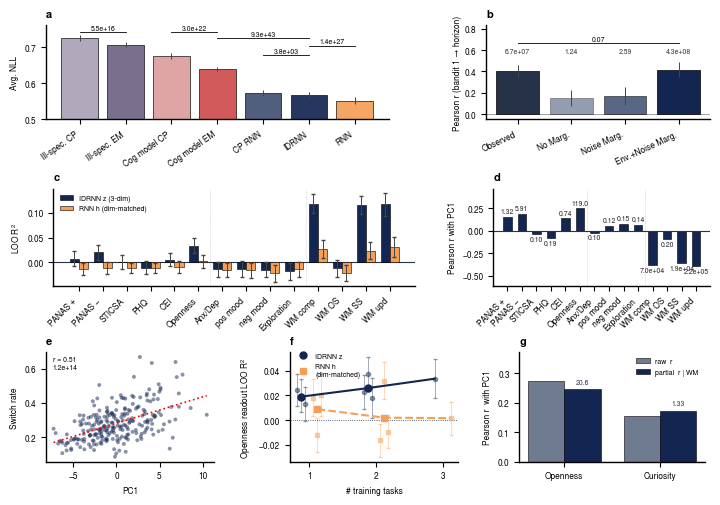

Saved final_plots/thalmann_combined_figure.png / .pdf / .svg


In [ ]:
# === COMBINED JOURNAL FIGURE (Nature Human Behaviour) ===
# Two analysis groups, visually separated by a wider gap:
#   MODEL COMPARISON (rows 1-2):  a  NLL          b  cross-task regret     c  LOO R² (full width)
#   TRAIT AXIS       (rows 3-4):  d  trait axis (PC1)   e  PC1<->switch    f  openness scaling   g  beyond WM
# (former panel a — reward structures — is commented out below and no longer plotted;
#  letters re-sequenced: old b->c, c->a, d->b, e->d, f->e, g->f, h->g)
# All panels are NATIVE subplots in ONE figure at W_FULL (180 mm) with uniform journal typography
# (5–7 pt). Saved WITHOUT bbox_inches="tight" so figsize stays authoritative under the globally
# enabled constrained_layout. Reads only light data files (CSV/NPZ/NPY); never runs seed-walking cells.
import matplotlib.gridspec as gridspec
import pingouin as pg
MM = 1 / 25.4
W_FULL = 180 * MM     # NHB double-column hard max

FS_BASE, FS_LABEL, FS_TICK, FS_ANNOT, FS_LETTER = 6, 6, 6, 5, 8
FS_BFNUM = 5          # dense per-bar BF labels (trait axis, 14 bars)
JOURNAL_RC = {
    "font.size": FS_BASE, "axes.titlesize": FS_BASE, "axes.labelsize": FS_LABEL,
    "xtick.labelsize": FS_TICK, "ytick.labelsize": FS_TICK, "legend.fontsize": FS_ANNOT,
    "mathtext.default": "regular",
}

def _bracket(ax, x1, x2, y, h, txt, fs=FS_ANNOT):
    ax.plot([x1, x2], [y + h, y + h], lw=0.6, c="black")
    ax.text((x1 + x2) / 2, y + h * 1.1, txt, ha="center", va="bottom", fontsize=fs)

# ---------- (COMMENTED OUT) former panel a: reward-structure schematic (native redraw of the TikZ figure) ----------
# _ARM = {"red": (237/255, 83/255, 80/255), "cyan": (38/255, 198/255, 218/255),
#         "green": (102/255, 205/255, 109/255), "purple": (171/255, 99/255, 205/255)}
#
# def _rw_walk(n, seed):
#     r = np.random.default_rng(seed)
#     mu = np.zeros(n); mu[0] = r.uniform(35, 65)
#     for t in range(1, n):
#         mu[t] = 0.9836 * mu[t - 1] + (1 - 0.9836) * 50 + r.normal(0, 2.8)
#     return mu
#
# def _reward_frame(ax, title, xlim, xticks, subtitle):
#     ax.set_xlim(*xlim); ax.set_xticks(xticks)
#     ax.set_ylim(25, 75); ax.set_yticks([30, 50, 70])
#     ax.set_xlabel("trial", labelpad=2)
#     ax.set_title(title, loc="center", fontweight="normal", fontsize=FS_TICK, pad=4)
#     ax.tick_params(length=3)
#     ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
#     ax.text(0.5, -0.22, subtitle, transform=ax.transAxes, ha="center", va="top",
#             fontsize=FS_ANNOT, color="black")
#
# def _draw_reward_structures(ax1, ax2, ax3):
#     ax1.axvspan(1, 4.5, color=(0.93, 0.93, 0.93), lw=0, zorder=0)
#     ax1.axvline(4.5, ls=(0, (4, 3)), color=(0, 0, 0, 0.5), lw=0.8, zorder=1)
#     ax1.plot([1, 10], [56, 56], color=_ARM["red"],  lw=1.0, solid_capstyle="round", zorder=2)
#     ax1.plot([1, 10], [44, 44], color=_ARM["cyan"], lw=1.0, solid_capstyle="round", zorder=2)
#     ax1.annotate("", xy=(9.28, 55.2), xytext=(9.28, 44.8),
#                  arrowprops=dict(arrowstyle="<->", color=(0, 0, 0, 0.6), lw=0.8))
#     ax1.text(9.05, 50, r"$\Delta$", ha="right", va="center", fontsize=FS_ANNOT, color="black")
#     ax1.text(2.75, 33, "forced", rotation=90, ha="center", va="center", fontsize=FS_ANNOT, color="black")
#     ax1.text(5.1, 32.5, "1 or 6 free\nchoices", ha="left", va="center", fontsize=FS_ANNOT, color="black")
#     _reward_frame(ax1, "Horizon task", (1, 10), [1, 5, 10], "stable, $\\Delta$ = 4–30\n80 rounds")
#     ax1.set_ylabel("mean reward", labelpad=2)
#     _rng = np.random.default_rng(0)
#     stable = 46.0 * np.ones(10); drift = np.zeros(10); drift[0] = 52
#     for t in range(1, 10): drift[t] = drift[t - 1] + _rng.normal(0, 3.0)
#     tt = np.arange(1, 11)
#     ax2.plot(tt, stable, color=_ARM["cyan"], lw=1.0, solid_capstyle="round", zorder=2)
#     ax2.plot(tt, drift,  color=_ARM["red"],  lw=1.0, solid_capstyle="round", zorder=2)
#     ax2.text(1.2, 45, "stable",   ha="left", va="top",    fontsize=FS_ANNOT, color=tuple(0.6 * c for c in _ARM["cyan"]))
#     ax2.text(1.2, 54, "drifting", ha="left", va="bottom", fontsize=FS_ANNOT, color=tuple(0.75 * c for c in _ARM["red"]))
#     _reward_frame(ax2, "Two-armed bandit", (1, 10), [1, 5, 10], "stable and/or drifting\n30 rounds")
#     tr = np.arange(1, 201)
#     for k, col in zip(range(4), ["red", "cyan", "green", "purple"]):
#         ax3.plot(tr, _rw_walk(200, 9 * 4 + k), color=_ARM[col], lw=0.6, solid_capstyle="round", zorder=2)
#     _reward_frame(ax3, "Restless bandit", (1, 200), [1, 100, 200], "4 drifting arms\n1 round")

# ---------- data shared by d–g (from poster panel 2) ----------
DEC = "final_plots/thalmann_z3_s2_3task_full/decoding"
zc = np.load(f"{DEC}/z2_consensus_pca.npy")
tg = pd.read_csv(f"{DEC}/trait_targets.csv")
PERSONALITY = ["PANAS_PA", "PANAS_NA", "STICSA", "PHQ", "CEI", "BIG5_open"]
COMPOSITE   = ["AxDep", "posMood", "negMood", "Exp"]
WM_KEYS     = ["WM_composite", "WM_OS", "WM_SS", "WM_WMU"]
ALL_KEYS = PERSONALITY + COMPOSITE + WM_KEYS
LBL = {"PANAS_PA": "PANAS +", "PANAS_NA": "PANAS −", "STICSA": "STICSA", "PHQ": "PHQ", "CEI": "CEI",
       "BIG5_open": "Openness", "AxDep": "Anx/Dep", "posMood": "pos mood", "negMood": "neg mood",
       "Exp": "Exploration", "WM_composite": "WM comp", "WM_OS": "WM OS", "WM_SS": "WM SS", "WM_WMU": "WM upd"}
def corr_n(y):
    m = np.isfinite(zc) & np.isfinite(y); return float(pearsonr(zc[m], y[m])[0]), int(m.sum())
_c3 = np.load("data_sub_t012_full/c_train.npy")
_tid3 = np.load("data_sub_t012_full/task_ids_per_block.npy")
_N3 = _c3.shape[0]
def _switch_rate(bl):
    s = p = 0
    for b in range(bl.shape[0]):
        ch = bl[b]; ch = ch[ch >= 0]
        if len(ch) < 2: continue
        s += int((ch[1:] != ch[:-1]).sum()); p += len(ch) - 1
    return s / p if p else np.nan
sw_all = np.array([_switch_rate(_c3[i]) for i in range(_N3)])

with plt.rc_context(JOURNAL_RC):
    fig = plt.figure(figsize=(W_FULL, 3.3))
    fig.get_layout_engine().set(h_pad=0.02, hspace=0.0)   # h_pad is in inches; hspace is a fraction
    outer = fig.add_gridspec(3, 1, height_ratios=[1.0, 1.0, 1.0])

    # ===== Group 1 — model comparison (rows 1-2) =====
    gs0 = outer[0].subgridspec(1, 100, wspace=0.0)
    ax_nll = fig.add_subplot(gs0[0, 0:55])        # a — held-out NLL
    ax_reg = fig.add_subplot(gs0[0, 64:100])      # b — cross-task regret
    gs1 = outer[1].subgridspec(1, 100, wspace=0.0)
    ax_loo = fig.add_subplot(gs1[0, 0:60])       # c — LOO R² (full width)
    ax_trait = fig.add_subplot(gs1[0, 64:100]) # d — trait axis (PC1)

    # ===== Group 2 — trait axis (rows 3-4, below the spacer) =====
    gs2 = outer[2].subgridspec(1, 100, wspace=0.0)
    ax_sw    = fig.add_subplot(gs2[0, 0:30])      # e — PC1 <-> switch rate
    ax_scale = fig.add_subplot(gs2[0, 33:63])     # f — openness scaling
    ax_wm    = fig.add_subplot(gs2[0, 66:99])     # g — beyond WM

    # -------- Panel a: held-out NLL per participant --------
    df = pd.read_csv("final_plots/thalmann_z3_s2_pooled/per_participant_nll_marginal.csv")
    tid = np.load("data_thalmann_s2/task_ids_per_block.npy")
    nt0 = nt1 = 0.0
    for _f in range(3):
        _cc = np.load(f"data_thalmann_s2/fold{_f}/c_test.npy"); _v = (_cc >= 0)
        nt0 += _v[:, tid == 0].sum(); nt1 += _v[:, tid == 1].sum()
    chance = float((nt0 * np.log(2) + nt1 * np.log(4)) / (nt0 + nt1))
    cog_keys = [("nll_ill_cp", "Ill-spec. CP", COL_Q_CP), ("nll_ill_em", "Ill-spec. EM", COL_Q_EM),
                ("nll_cog_cp", "Cog model CP", COL_FQ_CP), ("nll_cog_em", "Cog model EM", COL_FQ_EM),
                ("nll_cp_rnn_all", "CP RNN", COL_RNN_CP), ("nll_idrnn_all", "IDRNN", COL_IDRNN),
                ("nll_vanilla_all", "RNN", COL_VANILLA)]
    keys = [k for k, _, _ in cog_keys]; labels = [l for _, l, _ in cog_keys]; cols = [c for _, _, c in cog_keys]
    means = [df[k].mean() for k in keys]; sems = [stats.sem(df[k].dropna()) for k in keys]; xs = np.arange(len(labels))
    bf_Q = paired_bf(df["nll_ill_cp"], df["nll_ill_em"]); bf_FQ = paired_bf(df["nll_cog_cp"], df["nll_cog_em"])
    bf_RNNCP_IDRNN = paired_bf(df["nll_cp_rnn_all"], df["nll_idrnn_all"])
    bf_Van_IDRNN = paired_bf(df["nll_vanilla_all"], df["nll_idrnn_all"])
    bf_IDRNN_FQ_EM = paired_bf(df["nll_cog_em"], df["nll_idrnn_all"])
    ax_nll.bar(xs, means, color=cols, alpha=0.92, edgecolor="black", linewidth=0.5, zorder=2)
    ax_nll.errorbar(xs, means, yerr=sems, fmt="none", ecolor="#444444", elinewidth=0.7, capsize=0, zorder=3)
    ax_nll.axhline(chance, ls=":", color=COL_TRUE, lw=1.2, zorder=1)
    ymax = max(means) + max(sems); h_step = 0.05 * (chance - min(means)); yb = ymax + h_step
    _bracket(ax_nll, 0, 1, yb - 0.02, h_step * 0.3, fmt_bf(bf_Q))
    _bracket(ax_nll, 2, 3, yb - 0.02, h_step * 0.3, fmt_bf(bf_FQ))
    _bracket(ax_nll, 4, 5, yb - 3 * h_step - 0.02, h_step * 0.3, fmt_bf(bf_RNNCP_IDRNN))
    _bracket(ax_nll, 5, 6, yb - h_step * 1.8 - 0.02, h_step * 0.3, fmt_bf(bf_Van_IDRNN))
    _bracket(ax_nll, 3, 5, yb - 0.85 * h_step - 0.02, h_step * 0.3, fmt_bf(bf_IDRNN_FQ_EM))
    ax_nll.set_xticks(xs); ax_nll.set_xticklabels(labels, rotation=35, ha="right")
    ax_nll.set_ylabel("Avg. NLL"); ax_nll.set_ylim(bottom=0.5, top=0.76)

    # -------- Panel b: generative cross-task regret (R1-R4) --------
    dd = np.load("final_plots/thalmann_z3_s2_full/regret/step1_cross_task_regret.npz")
    subids = dd["subids"].astype(int); yv_ = dd["hum_regret_task3"]
    ab = pd.read_csv("data/final2armedBanditSession1.csv"); o = {}
    for sid, grp in ab.groupby("ID"):
        arr = grp[["reward1", "reward2"]].values.astype(float); o[int(sid)] = float((arr.max(1) - grp["reward"].values).mean())
    R1 = np.array([o.get(int(sid), np.nan) for sid in subids])
    BARS = [("R1", R1, COL_TRUE, 1.00), ("R2", dd["sim_regret_task0_r2_exact_single"], COL_IDRNN, 0.45),
            ("R3", dd["sim_regret_task0_r3_exact_margrng"], COL_IDRNN, 0.70), ("R4", dd["sim_regret_task0_r4_marg"], COL_IDRNN, 1.00)]
    recs = []; rng = np.random.default_rng(1)
    for lab, xx, col, al in BARS:
        m = np.isfinite(xx) & np.isfinite(yv_); xv, yv = xx[m], yv_[m]; nbt = len(xv)
        r = float(pearsonr(xv, yv)[0]); boots = np.empty(2000)
        for i in range(2000):
            idx = rng.integers(0, nbt, nbt); boots[i] = np.corrcoef(xv[idx], yv[idx])[0, 1]
        recs.append(dict(color=col, alpha=al, r=r, boots=boots, bf=float(bayesfactor_pearson(r, nbt))))
    xs = np.arange(4); heights = [r["r"] for r in recs]; sd_err = [float(np.std(r["boots"])) for r in recs]
    for xi, r in zip(xs, recs):
        ax_reg.bar(xi, r["r"], color=r["color"], alpha=r["alpha"], edgecolor="black", linewidth=0.5, zorder=2)
    ax_reg.errorbar(xs, heights, yerr=sd_err, fmt="none", ecolor="#444444", elinewidth=0.7, capsize=0, zorder=3)
    allb = np.concatenate([r["boots"] for r in recs]); y_top = float(np.nanpercentile(allb, 99)) + 0.04
    for xi, r in zip(xs, recs):
        ax_reg.text(xi, y_top, fmt_bf(r["bf"]), ha="center", fontsize=FS_ANNOT, color="#333333")
    mm = np.isfinite(R1) & np.isfinite(yv_) & np.isfinite(dd["sim_regret_task0_r4_marg"])
    _zc = lambda a: (np.asarray(a, float) - np.asarray(a, float).mean()) / (np.asarray(a, float).std() + 1e-12)
    bf_cmp = paired_bf(_zc(R1[mm]) * _zc(yv_[mm]), _zc(dd["sim_regret_task0_r4_marg"][mm]) * _zc(yv_[mm]))
    _bracket(ax_reg, 0, 3, y_top + 0.06, 0.03, fmt_bf(bf_cmp))
    ax_reg.axhline(0, color="grey", lw=0.5, zorder=1); ax_reg.set_xticks(xs)
    ax_reg.set_xticklabels(["Observed", "No Marg.", "Noise Marg.", "Env.+Noise Marg."], rotation=25, ha="right")
    ax_reg.set_ylabel("Pearson r (bandit 1 → horizon)", labelpad=2)
    ax_reg.set_ylim(min(0, min(heights)) - 0.05, y_top + 0.26)

    # -------- Panel c: out-of-sample LOO R² --------
    FULL = "final_plots/thalmann_z3_s2_3task_full"
    lbls = [LBL[k] for k in ALL_KEYS]; x = np.arange(len(lbls)); w = 0.38
    # S1-EXTRACTION convention: models are trained on pooled S1+S2 (fully informed), but
    # vanilla h is trial-averaged over SESSION-1 BLOCKS ONLY (identical block set for all
    # 236 has_s1 participants), so the representation cannot encode session coverage —
    # see the coverage-confound cell at the end of this notebook for the full argument.
    bt = pd.read_csv(f"{FULL}/decoding/loo_r2_panel_s1extract.csv").set_index("target").reindex(ALL_KEYS)
    ax_loo.bar(x - w / 2, bt["idrnn_r2"].values, w, yerr=bt["idrnn_sd"].values, color=COL_IDRNN,
               edgecolor="black", linewidth=0.4, capsize=1.5, error_kw=dict(elinewidth=0.7, ecolor="#444444"),
               label="IDRNN z (3-dim)", zorder=2)
    ax_loo.bar(x + w / 2, bt["vanilla_r2"].values, w, yerr=bt["vanilla_sd"].values, color=COL_VANILLA,
               edgecolor="black", linewidth=0.4, capsize=1.5, error_kw=dict(elinewidth=0.7, ecolor="#444444"),
               label="RNN h (dim-matched)", zorder=2)
    # for _xi, _k in zip(x, ALL_KEYS):  # BF10 (one-sided) over each positive-R2 bar
    #     for _dx, _pfx, _col in ((-w / 2, "idrnn", COL_IDRNN), (w / 2, "vanilla", COL_VANILLA)):
    #         if bt.loc[_k, _pfx + "_r2"] > 0:
    #             ax_loo.text(_xi + _dx, bt.loc[_k, _pfx + "_r2"] + bt.loc[_k, _pfx + "_sd"] + 0.004,
    #                     fmt_bf(bt.loc[_k, _pfx + "_bf"]).replace("BF=", ""),
    #                     ha="center", va="bottom", rotation=90, fontsize=FS_ANNOT, color=_col, zorder=4)
    ax_loo.axhline(0, color=COL_TRUE, lw=0.8, zorder=1)
    for xb in (len(PERSONALITY) - .5, len(PERSONALITY) + len(COMPOSITE) - .5):
        ax_loo.axvline(xb, color="grey", lw=.5, ls=":", alpha=.5)
    ax_loo.set_xticks(x); ax_loo.set_xticklabels(lbls, rotation=45, ha="right")
    ax_loo.set_ylabel("LOO $R^2$"); ax_loo.legend(loc="upper left")

    # -------- Panel d: individual-difference axis (14 traits) --------
    labels_e = [LBL[k] for k in ALL_KEYS]; xe = np.arange(len(labels_e))
    r_e = np.array([corr_n(tg[k].values)[0] for k in ALL_KEYS])
    bf_e = [float(bayesfactor_pearson(*corr_n(tg[k].values))) for k in ALL_KEYS]
    ax_trait.bar(xe, r_e, 0.6, color=COL_IDRNN, edgecolor="black", linewidth=0.4, zorder=2)
    ax_trait.axhline(0, color=COL_TRUE, lw=0.8)
    for i, (v, b) in enumerate(zip(r_e, bf_e)):
        ax_trait.text(xe[i], v + (0.02 if v >= 0 else -0.02), fmt_bf(b).replace("BF=", ""), ha="center",
                      va="bottom" if v >= 0 else "top", fontsize=FS_BFNUM, color="#222222")
    for xb in (len(PERSONALITY) - .5, len(PERSONALITY) + len(COMPOSITE) - .5):
        ax_trait.axvline(xb, color="grey", lw=.5, ls=":", alpha=.5)
    ax_trait.set_xticks(xe); ax_trait.set_xticklabels(labels_e, rotation=45, ha="right")
    ax_trait.set_ylim(min(r_e) - 0.22, max(r_e) + 0.22); ax_trait.set_ylabel("Pearson r with PC1")

    # -------- Panel e: consensus latent vs overall switch rate --------
    rr, _ = pearsonr(zc, sw_all); bf_b = float(bayesfactor_pearson(rr, _N3))
    ax_sw.scatter(zc, sw_all, s=8, color=COL_IDRNN, alpha=0.5, edgecolors="none", zorder=2)
    bb = np.polyfit(zc, sw_all, 1); xs2 = np.linspace(zc.min(), zc.max(), 50)
    ax_sw.plot(xs2, bb[0] * xs2 + bb[1], "r:", lw=1.2, zorder=3)
    ax_sw.text(0.04, 0.96, f"r = {rr:.2f}\n{fmt_bf(bf_b)}", transform=ax_sw.transAxes, va="top", ha="left", fontsize=FS_ANNOT)
    ax_sw.set_xlabel("PC1"); ax_sw.set_ylabel("Switch rate")

    # -------- Panel f: openness readout climbs with #training tasks --------
    _SUBSETS = {"t0": (1, "2-armed"), "t1": (1, "restless"), "t2": (1, "horizon"),
                "t01": (2, "2-arm+rest"), "t02": (2, "2-arm+horiz"), "t12": (2, "rest+horiz"), "t012": (3, "all 3")}
    _FALLBACK = {"t1": "thalmann_z3_1task_full", "t01": "thalmann_z3_full", "t012": "thalmann_z3_3task_full"}
    def _load_decode(sub):
        p = f"final_plots/thalmann_z3_ds_{sub}/decoding/seed_averaged_decoding.csv"
        if not os.path.exists(p) and sub in _FALLBACK:
            p = f"final_plots/{_FALLBACK[sub]}/decoding/seed_averaged_decoding.csv"
        return pd.read_csv(p).set_index("target") if os.path.exists(p) else None
    def _collect(tgts):
        rr_ = {}
        for sub, (nn, lab) in _SUBSETS.items():
            ddc = _load_decode(sub)
            if ddc is None: continue
            tk = [t for t in tgts if t in ddc.index]
            if not tk: continue
            rr_[sub] = dict(n=nn, im=np.mean([ddc.loc[t, "idrnn_loo_r2_mean"] for t in tk]),
                isd=np.mean([ddc.loc[t, "idrnn_loo_r2_sd"] for t in tk]) / np.sqrt(len(tk)),
                vm=np.mean([ddc.loc[t, "vanilla_loo_r2_mean"] for t in tk]),
                vsd=np.mean([ddc.loc[t, "vanilla_loo_r2_sd"] for t in tk]) / np.sqrt(len(tk)))
        return rr_
    # S1-EXTRACTION convention (matches panel c): vanilla h from S1 blocks only,
    # has_s1 cohort; models pooled-trained. Produced by DS_S1_EXTRACT=1 pipeline.
    _ds_pc = pd.read_csv("final_plots/thalmann_z3_datascaling_s1x/datascaling_panel.csv")
    _ds_pc = _ds_pc[_ds_pc.group == "openness"]
    for arch, col, off, ls, mk, lab in [("idrnn", COL_IDRNN, -0.12, "-", "o", "IDRNN z"),
                                        ("vanilla", COL_VANILLA, +0.12, "--", "s", "RNN h\n(dim-matched)")]:
        _a = _ds_pc[_ds_pc.arch == arch]; _mx, _my = [], []
        for _K in (1, 2, 3):
            _ck = _a[_a.ntasks == _K].reset_index(drop=True); _m = len(_ck)
            for _j in range(_m):
                ax_scale.errorbar(_K + off + (_j - (_m - 1) / 2) * 0.06, _ck.canonical_r2[_j], yerr=_ck.boot_sd[_j],
                            fmt=mk, ms=3, color=col, alpha=0.45, elinewidth=0.6, capsize=1.2, zorder=2)
            _mx.append(_K + off); _my.append(float(_ck.canonical_r2.mean()))
        ax_scale.plot(_mx, _my, ls=ls, color=col, lw=1.5, zorder=3)                       # mean-of-means climb line
        ax_scale.plot(_mx[:2], _my[:2], ls="none", marker=mk, color=col, ms=5, zorder=4, label=lab)  # mean-of-means (#tasks 1,2 only)
    ax_scale.axhline(0, color=COL_TRUE, lw=.6, ls=":")
    ax_scale.set_xticks([1, 2, 3]); ax_scale.set_xlabel("# training tasks")
    ax_scale.set_ylabel("Openness readout LOO $R^2$"); ax_scale.legend(
    loc="upper left",
    bbox_to_anchor=(0.0, 1.05),  # move 5% above the axes
    fontsize=FS_ANNOT
)

    # -------- Panel g: trait signal beyond working memory --------
    TRAITS = [("BIG5_open", "Openness"), ("CEI", "Curiosity")]
    dfw = pd.DataFrame({"z": zc, "WM": tg["WM_composite"].values, **{k: tg[k].values for k, _ in TRAITS}}).dropna()
    n_wm = len(dfw); raw, par, bfs_d = [], [], []
    for k, _ in TRAITS:
        raw.append(float(pg.corr(dfw["z"], dfw[k])["r"].values[0]))
        rp = float(pg.partial_corr(dfw, x="z", y=k, covar="WM")["r"].values[0])
        par.append(rp); bfs_d.append(float(bayesfactor_pearson(rp, n_wm - 1)))
    xd = np.arange(len(TRAITS)); wd = 0.38; GREY = nature_colors["Grey"][3]
    ax_wm.bar(xd - wd / 2, raw, wd, color=GREY, edgecolor="black", lw=0.4, label="raw  r", zorder=2)
    ax_wm.bar(xd + wd / 2, par, wd, color=COL_IDRNN, edgecolor="black", lw=0.4, label="partial  r | WM", zorder=2)
    ax_wm.axhline(0, color=COL_TRUE, lw=0.8)
    for i, (rp, bff) in enumerate(zip(par, bfs_d)):
        ax_wm.text(xd[i] + wd / 2, rp + (0.012 if rp >= 0 else -0.012), fmt_bf(bff).replace("BF=", ""),
                   ha="center", va="bottom" if rp >= 0 else "top", fontsize=FS_ANNOT, color=COL_TRUE)
    ax_wm.set_xticks(xd); ax_wm.set_xticklabels([l for _, l in TRAITS]); ax_wm.set_ylabel("Pearson r  with PC1")
    ax_wm.set_ylim(top=max(max(raw), max(par)) + 0.10); ax_wm.legend(loc="upper right")

    # -------- Panel letters --------
    for ax, lett in [(ax_nll, "a"), (ax_reg, "b"), (ax_loo, "c"),
                     (ax_trait, "d"), (ax_sw, "e"), (ax_scale, "f"), (ax_wm, "g")]:
        ax.set_title(lett, loc="left", fontweight="bold", fontsize=FS_LETTER)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    fig.savefig("final_plots/thalmann_combined_figure.png", dpi=600)
    fig.savefig("final_plots/thalmann_combined_figure.pdf")
    fig.savefig("final_plots/thalmann_combined_figure.svg")
    plt.show()
print("Saved final_plots/thalmann_combined_figure.png / .pdf / .svg")

## Standalone — generative cross-task regret (bootstrap)

Panel b of the bootstrap-c poster, extracted as its own figure: the generative
cross-task simulation (R1–R4), bootstrapped Pearson r (bandit 1 → horizon).
Relies on the shared setup cell for the palette/helpers. Saves PNG/PDF/SVG.

In [ ]:
# === STANDALONE — generative cross-task regret (R1-R4), bootstrapped ===
# Panel b of the "bootstrap-c" poster as its own figure. Uses the shared setup cell
# (COL_*, fmt_bf, paired_bf, imports); only the poster typography is defined locally,
# matching the composite poster panel. Self-contained: reads light data files only.
FS_BASE, FS_LABEL, FS_TICK, FS_ANNOT = 6, 6, 6, 4.5  # 6pt body, smaller BF annotations (1.80x1.81 in tile)
POSTER_RC = {
    "font.size": FS_BASE, "axes.titlesize": FS_BASE,
    "axes.labelsize": FS_LABEL, "xtick.labelsize": FS_TICK, "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_ANNOT, "mathtext.default": "regular",
}
def _bracket(ax, x1, x2, y, h, txt, fs=FS_ANNOT):
    ax.plot([x1, x2], [y + h, y + h], lw=0.6, c="black")
    ax.text((x1 + x2) / 2, y + h * 1.1, txt, ha="center", va="bottom", fontsize=fs)

with plt.rc_context(POSTER_RC):
    fig, ax_b = plt.subplots(figsize=(1.80, 1.81))

    # ===== generative cross-task regret (R1-R4) =====
    d = np.load("final_plots/thalmann_z3_s2_full/regret/step1_cross_task_regret.npz")
    subids = d["subids"].astype(int); y = d["hum_regret_task3"]
    ab = pd.read_csv("data/final2armedBanditSession1.csv"); o = {}
    for sid, grp in ab.groupby("ID"):
        arr = grp[["reward1", "reward2"]].values.astype(float)
        o[int(sid)] = float((arr.max(1) - grp["reward"].values).mean())
    R1 = np.array([o.get(int(sid), np.nan) for sid in subids])
    BARS = [("R1", R1, COL_TRUE, 1.00),
            ("R2", d["sim_regret_task0_r2_exact_single"], COL_IDRNN, 0.45),
            ("R3", d["sim_regret_task0_r3_exact_margrng"], COL_IDRNN, 0.70),
            ("R4", d["sim_regret_task0_r4_marg"], COL_IDRNN, 1.00)]
    recs = []; rng = np.random.default_rng(1)
    for lab, x, col, al in BARS:
        m = np.isfinite(x) & np.isfinite(y); xv, yv = x[m], y[m]; nbt = len(xv)
        r = float(pearsonr(xv, yv)[0]); boots = np.empty(2000)
        for i in range(2000):
            idx = rng.integers(0, nbt, nbt); boots[i] = np.corrcoef(xv[idx], yv[idx])[0, 1]
        lo, hi = np.nanpercentile(boots, [2.5, 97.5])
        recs.append(dict(label=lab, color=col, alpha=al, r=r, ci=(lo, hi), boots=boots,
                         bf=float(bayesfactor_pearson(r, nbt))))
    xs = np.arange(4); heights = [r["r"] for r in recs]
    sd_err = [float(np.std(r["boots"])) for r in recs]   # ±SD of the bootstrap-r distribution
    for xi, r in zip(xs, recs):
        ax_b.bar(xi, r["r"], color=r["color"], alpha=r["alpha"], edgecolor="black", linewidth=0.5, zorder=2)
    ax_b.errorbar(xs, heights, yerr=sd_err, fmt="none", ecolor="#444444",
                  elinewidth=0.7, capsize=0, zorder=3)
    allb = np.concatenate([r["boots"] for r in recs]); y_top = float(np.nanpercentile(allb, 99)) + 0.04
    for xi, r in zip(xs, recs):
        ax_b.text(xi, y_top, fmt_bf(r["bf"]), ha="center", fontsize=FS_ANNOT, color="#333333")
    mm = np.isfinite(R1) & np.isfinite(y) & np.isfinite(d["sim_regret_task0_r4_marg"])
    _zc = lambda a: (np.asarray(a, float) - np.asarray(a, float).mean()) / (np.asarray(a, float).std() + 1e-12)
    bf_cmp = paired_bf(_zc(R1[mm]) * _zc(y[mm]), _zc(d["sim_regret_task0_r4_marg"][mm]) * _zc(y[mm]))
    _bracket(ax_b, 0, 3, y_top + 0.06, 0.03, fmt_bf(bf_cmp))
    ax_b.axhline(0, color="grey", lw=0.5, zorder=1)
    ax_b.set_xticks(xs)
    ax_b.set_xticklabels(["Observed", "No Marg.", "Noise Marg.", "Env.+Noise Marg."], rotation=25, ha="right")
    ax_b.set_ylabel("Pearson r (bandit 1 → horizon)", labelpad=2)
    ax_b.set_ylim(min(0, min(heights)) - 0.05, y_top + 0.26)
    ax_b.spines["top"].set_visible(False); ax_b.spines["right"].set_visible(False)

    out = "final_plots/thalmann_panel_b_regret_standalone"
    fig.savefig(out + ".png", dpi=300, bbox_inches="tight")
    fig.savefig(out + ".pdf", bbox_inches="tight")
    fig.savefig(out + ".svg", bbox_inches="tight")
    plt.show()
print("Saved", out + ".png / .pdf / .svg")

## Standalone — out-of-sample LOO R² decoding (train-resample bootstrap)
The panel-c plot from the poster-1 bootstrap-c variant, on its own axis: IDRNN z vs dim-matched Vanilla h decoding LOO R² across all 14 traits. Bar = mean of the B=500 train-resample bootstrap R² values, error bar = ±SD of those values (readout-fit uncertainty; test participant excluded before resampling → no leakage; R² averaged over 10 seeds). Saves `final_plots/thalmann_loo_r2_bootstrap_standalone.{png,pdf,svg}`.

In [ ]:
# === STANDALONE — out-of-sample LOO R² decoding (IDRNN z vs dim-matched Vanilla h) ===
# Same panel as poster-panel-1 bootstrap-c variant panel c, rendered on its own axis.
# Bar = mean of the B=500 train-resample bootstrap LOO R²; error bars = ±SD of those values.
# (Bootstrap: LOO over real participants with the TRAIN fold resampled + readout refit — test
# participant excluded first, so no leakage; R² averaged over 10 seeds.) Reads the light CSV only.
FS_BASE, FS_LABEL, FS_TICK, FS_ANNOT, FS_LETTER = 13, 14, 12, 11, 18
POSTER_RC = {
    "font.size":       FS_BASE,
    "axes.titlesize":  FS_BASE,
    "axes.labelsize":  FS_LABEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_ANNOT,
    "mathtext.default": "regular",
}

FULL = "final_plots/thalmann_z3_s2_3task_full"
PERSONALITY = ["PANAS_PA", "PANAS_NA", "STICSA", "PHQ", "CEI", "BIG5_open"]
COMPOSITE   = ["AxDep", "posMood", "negMood", "Exp"]
WM_KEYS     = ["WM_composite", "WM_OS", "WM_SS", "WM_WMU"]
ALL_KEYS    = PERSONALITY + COMPOSITE + WM_KEYS
LBL = {"PANAS_PA": "PANAS +", "PANAS_NA": "PANAS -", "STICSA": "STICSA", "PHQ": "PHQ", "CEI": "CEI",
       "BIG5_open": "Openness", "AxDep": "Anx/Dep", "posMood": "pos mood", "negMood": "neg mood",
       "Exp": "Exploration", "WM_composite": "WM comp", "WM_OS": "WM OS", "WM_SS": "WM SS", "WM_WMU": "WM upd"}
lbls = [LBL[k] for k in ALL_KEYS]
x = np.arange(len(lbls)); w = 0.38
# S1-EXTRACTION convention (matches journal figure panel c)
bt = pd.read_csv(f"{FULL}/decoding/loo_r2_panel_s1extract.csv").set_index("target").reindex(ALL_KEYS)
i_m = bt["idrnn_r2"].values; v_m = bt["vanilla_r2"].values
i_err = bt["idrnn_sd"].values;  v_err = bt["vanilla_sd"].values

with plt.rc_context(POSTER_RC):
    fig, ax = plt.subplots(figsize=(11, 4.2))
    ax.bar(x - w / 2, i_m, w, yerr=i_err, color=COL_IDRNN,
           edgecolor="black", linewidth=0.4, capsize=1.5, error_kw=dict(elinewidth=0.7, ecolor="#444444"),
           label="IDRNN z (3-dim)", zorder=2)
    ax.bar(x + w / 2, v_m, w, yerr=v_err, color=COL_VANILLA,
           edgecolor="black", linewidth=0.4, capsize=1.5, error_kw=dict(elinewidth=0.7, ecolor="#444444"),
           label="Vanilla h (dim-matched)", zorder=2)
    for _xi, _k in zip(x, ALL_KEYS):  # BF10 (one-sided) over each positive-R2 bar
        for _dx, _pfx, _col in ((-w / 2, "idrnn", COL_IDRNN), (w / 2, "vanilla", COL_VANILLA)):
            if bt.loc[_k, _pfx + "_r2"] > 0:
                ax.text(_xi + _dx, bt.loc[_k, _pfx + "_r2"] + bt.loc[_k, _pfx + "_sd"] + 0.004,
                        fmt_bf(bt.loc[_k, _pfx + "_bf"]).replace("BF=", ""),
                        ha="center", va="bottom", rotation=90, fontsize=FS_ANNOT, color=_col, zorder=4)
    ax.axhline(0, color=COL_TRUE, lw=0.8, zorder=1)
    for xb in (len(PERSONALITY) - .5, len(PERSONALITY) + len(COMPOSITE) - .5):
        ax.axvline(xb, color="grey", lw=.5, ls=":", alpha=.5)
    ax.set_xticks(x); ax.set_xticklabels(lbls, rotation=45, ha="right")
    ax.set_ylabel("LOO $R^2$"); ax.legend(loc="upper left")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    fig.tight_layout()
    fig.savefig("final_plots/thalmann_loo_r2_bootstrap_standalone.png", dpi=300, bbox_inches="tight")
    fig.savefig("final_plots/thalmann_loo_r2_bootstrap_standalone.pdf", bbox_inches="tight")
    fig.savefig("final_plots/thalmann_loo_r2_bootstrap_standalone.svg", bbox_inches="tight")
    plt.show()
print("Saved final_plots/thalmann_loo_r2_bootstrap_standalone.{png,pdf,svg}")


## Standalone — consensus latent (PC1) vs overall switch rate
Panel b from poster panel 2, on its own axis: the ensemble consensus latent vs each participant's switch rate across all tasks, with a linear fit and Pearson r / BF. Saves `final_plots/thalmann_consensus_switch_scatter_standalone.{png,pdf,svg}`.

In [ ]:
# === STANDALONE — ensemble consensus latent (PC1) vs overall switch rate ===
# Panel b from poster panel 2, on its own axis: the ensemble consensus latent vs each participant's
# switch rate across all tasks, with a linear fit and Pearson r / BF. Reads light NPY only.
FS_BASE, FS_LABEL, FS_TICK, FS_ANNOT, FS_LETTER = 13, 14, 12, 11, 18
POSTER_RC = {
    "font.size":       FS_BASE,
    "axes.titlesize":  FS_BASE,
    "axes.labelsize":  FS_LABEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_ANNOT,
    "mathtext.default": "regular",
}

DEC = "final_plots/thalmann_z3_s2_3task_full/decoding"
zc = np.load(f"{DEC}/z2_consensus_pca.npy")        # ensemble consensus latent (pooled PCA over seeds)
c  = np.load("data_sub_t012_full/c_train.npy")
N  = c.shape[0]

def switch_rate(bl):
    s = p = 0
    for b in range(bl.shape[0]):
        ch = bl[b]; ch = ch[ch >= 0]
        if len(ch) < 2:
            continue
        s += int((ch[1:] != ch[:-1]).sum()); p += len(ch) - 1
    return s / p if p else np.nan

sw_all = np.array([switch_rate(c[i]) for i in range(N)])

with plt.rc_context(POSTER_RC):
    fig, ax = plt.subplots(figsize=(4.8, 4.4))
    rr, _ = pearsonr(zc, sw_all); bf_b = float(bayesfactor_pearson(rr, N))
    ax.scatter(zc, sw_all, s=14, color=COL_IDRNN, alpha=0.5, edgecolors="none", zorder=2)
    bb = np.polyfit(zc, sw_all, 1); xs = np.linspace(zc.min(), zc.max(), 50)
    ax.plot(xs, bb[0] * xs + bb[1], "r:", lw=1.5, zorder=3)
    ax.text(0.04, 0.96, f"r = {rr:.2f}\n{fmt_bf(bf_b)}", transform=ax.transAxes,
            va="top", ha="left", fontsize=FS_ANNOT)
    ax.set_xlabel("consensus latent (PC1)"); ax.set_ylabel("switch rate (all tasks)")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    fig.tight_layout()
    fig.savefig("final_plots/thalmann_consensus_switch_scatter_standalone.png", dpi=300, bbox_inches="tight")
    fig.savefig("final_plots/thalmann_consensus_switch_scatter_standalone.pdf", bbox_inches="tight")
    fig.savefig("final_plots/thalmann_consensus_switch_scatter_standalone.svg", bbox_inches="tight")
    plt.show()
print(f"Saved final_plots/thalmann_consensus_switch_scatter_standalone.{{png,pdf,svg}}  (r={rr:.3f})")


## Coverage confound — why vanilla's readouts are shaped by environmental exposure, and why panel c uses S1-extraction

**The argument (paper-ready):** both models are *fully informed* — trained on all pooled S1+S2
behaviour. But a per-participant representation must also be **extracted**, and here the two
architectures differ fundamentally. The IDRNN consolidates each participant into a trained latent
`z` during learning. The ablated model has no such mechanism, so its participant summary is the
trial-averaged hidden state over whatever data exists — and 61/236 participants did not return
for session 2. Averaging over *unequal coverage* makes the summary encode **who has session-2
data**: the coverage flag is PC1 of vanilla's h (~95% of variance) and is decodable at r ≈ 1.0
(panel **a**, **b**). Attrition is not random — returning correlates with affect and curiosity
(panel **c**) — so a supervised readout "decodes" personality partly by detecting attrition:
an inflated, erroneous trait attribution.

The fix adopted in the main figure's panel c: extract vanilla's h from the **identical
session-1 block set for every participant** (models still pooled-trained). The coverage signal
vanishes (decode r ≈ −0.13, at the LOO null), and with it vanilla's apparent affect signal;
openness drops to null. The IDRNN readouts are essentially **invariant across all extraction
regimes** (panel **d**) because `z` is fixed by training, not recomputed from exposure.

**The broader point:** the ablated model's latents are shaped by environmental factors —
what data a participant happened to contribute — as much as by the participant. Its readouts
therefore hinge on analysis contingencies (cohort composition, extraction window), and can be
confidently wrong. The IDRNN's individual-difference bottleneck separates *who the participant
is* from *what they were exposed to*; that separation is what makes its exploration/exploitation
axis discoverable and stable.


**Mechanism decomposition (extraction-mask audit):** the r ≈ 1.0 coverage decode has two
channels. (i) A *trivial* one: in the pooled arrays, blocks from a session a participant did not
do carry zero-valued input features from trial 1 (targets are masked, so training is unaffected),
and the standard extraction mask counted those trials as valid — so non-returners' "all-session"
averages included ~1,200 identical zero-input GRU timesteps, a shared constant that PCA elevates
to PC1. (ii) A *compositional* one that survives fully corrected exclude-only averaging: whose
average covers which sessions remains decodable at r = +0.72, and the curiosity readout stays
inflated (+0.020 vs −0.004 in the coverage-homogeneous cohort) while affect largely collapses
(PANAS +0.028 → −0.007). Both channels are absent by construction under S1-extraction. The
confound conclusion is unchanged — mixed-coverage summaries are nuisance-dominated — but the
mechanism statement above is the accurate one.

**Causal direction (ruling out "more data = more genuine signal"):** correlation of attrition
with traits does not by itself show the inflated readouts *flow through* the coverage channel.
Three tests separate the accounts (`confound_causal_tests.npz`; reported here as text by design):

1. **Coverage-axis ablation at constant data** — all 238 participants, full two-session
   extraction; the returners-vs-non direction is removed *within the readout's per-fold PCA
   score space* (identical basis to the baseline readout, only the coverage component differs).
   The affect/curiosity signal **collapses** (PANAS + : +0.025 → −0.011; PANAS − : +0.026 → −0.011;
   CEI: +0.017 → +0.008) while openness **rises** (+0.006 → +0.011): the affect signal lived on
   the coverage component, which was simultaneously *masking* genuine openness signal.
2. **Extraction dose at fixed cohort** — the 175 both-session participants, S1-extracted vs
   both-session-extracted h. Doubling data does **nothing** for affect/curiosity
   (PANAS + : −0.015 → −0.021) but grows the clean traits (openness +0.004 → +0.035;
   WM +0.026 → +0.070).
3. **Session-specific extraction at identical quantity** — S1 and S2 each contribute exactly
   111 blocks, so S1-only vs S2-only extraction (same 175 participants) holds data volume fixed.
   Openness: S1-only +0.004 vs **S2-only +0.023** (both: +0.035); WM: +0.026 vs **+0.059**
   (both: +0.070). The Δh probe (S2−S1 summary change) decodes **nothing** (openness −0.018,
   WM +0.013): the signal is in session *levels*, not in change-on-re-exposure.

A fourth check confirms the grand average is the ablated model's most favourable summary:
a session-concatenated representation ([h̄_S1, h̄_S2], 30-dim, same PCA-3 dim-match) — which
preserves session-specific structure instead of collapsing it — *reduces* the readouts
(openness +0.016 vs +0.035; WM +0.056 vs +0.070), because the session-specific variance it
retains is trait-noise (cf. the null Δh) and competes with the stable directions for the
dim-matched readout's three components. Conclusions do not hinge on the pooling choice.

Together: affect/curiosity readouts are purely confound-carried (die under axis ablation at
constant data; null in every within-cohort variant). Openness/WM readouts in vanilla are genuine
within-cohort signal — but they are a property of **participant × exposure**, not of the
participant alone: at identical data volume, *which* session the summary reflects changes the
readout by a factor of ~2–5, and most of the two-session gain is carried by second-session
behaviour (where task-learning transients have settled) plus cross-session aggregation. The
ablated model has no mechanism to consolidate this into a participant-level code — its readout
quality is inherited from whatever exposure happens to be summarized. The IDRNN's `z` delivers
equal-or-better decoding under **every** regime from the trained code alone, because
consolidation across exposures is what the architecture does. (The ablation test is **not valid
for the 3-dim z**: attrition correlates with the exploration axis itself — r(PC1, has-S2) = −0.21,
high-switchers return less often — so the "coverage direction" in a compact code aligns with the
trait axis and ablation amputates real signal; IDRNN's causal controls are the cohort-restriction
and S1-extraction invariance, both passed.) Transparency note: with two sessions of clean
extraction data vanilla approximates the openness *readout* (~0.035, panel d) — but it never
organizes the exploration/exploitation *axis* (unsupervised consensus-PCA control), and its
readouts remain exposure-contingent.


In [ ]:
# === STANDALONE — coverage-confound argument, 6 panels (2x3) ===
# a: coverage in vanilla's PC structure   b: coverage decodability (fix verified)
# c: trait-selective attrition            d: readout consequences across regimes
# e: CAUSAL - ablation at constant data   f: exposure-specificity at equal data
# Torch-free: reads decoding/confound_panel.npz + confound_causal_tests.npz.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pingouin as _pg

DEC = "final_plots/thalmann_z3_s2_3task_full/decoding"
d  = np.load(f"{DEC}/confound_panel.npz", allow_pickle=True)
dc = np.load(f"{DEC}/confound_causal_tests.npz", allow_pickle=True)
_CI = globals().get("COL_IDRNN", "#26547C"); _CV = globals().get("COL_VANILLA", "#E08214")
_CT = globals().get("COL_TRUE", "#333333")
try:
    _GREY = nature_colors["Grey"][3]
except Exception:
    _GREY = "#888888"
_fmt_bf = globals().get("fmt_bf", lambda b: f"BF={b:.3g}" if b < 1000 else f"BF={b:.1e}")
BAR_KW = dict(edgecolor="black", linewidth=0.4, zorder=2)
ERR_KW = dict(elinewidth=0.7, ecolor="#444444")

fig, axes = plt.subplots(2, 3, figsize=(13.6, 6.4))
(ax_a, ax_b, ax_c), (ax_d, ax_e, ax_f) = axes

# (a) corrected exclude-only averaging: compositional coverage channel in the PC spectrum
vr = d["pc_var_vancorr"].mean(0); vr_sd = d["pc_var_vancorr"].std(0)
rs = d["pc_rs2_vancorr"].mean(0)
x = np.arange(len(vr))
ax_a.bar(x, vr, 0.65, yerr=vr_sd, color=_CV, capsize=1.5, error_kw=ERR_KW, **BAR_KW)
for xi, (v, r) in enumerate(zip(vr, rs)):
    ax_a.text(xi, v + 0.03, f"|r|={r:.2f}", ha="center", fontsize=8,
              fontweight="bold" if r > 0.35 else "normal")
ax_a.set_xticks(x); ax_a.set_xticklabels([f"PC{j+1}" for j in x])
ax_a.set_ylabel("variance explained"); ax_a.set_ylim(0, 0.62)
ax_a.set_title("a   coverage pervades vanilla’s top PCs", loc="left", fontweight="bold")
ax_a.text(0.98, 0.96, "|r| = corr with has-S2", transform=ax_a.transAxes, ha="right",
          va="top", fontsize=8, color="#555555")

# (b) coverage decodability per representation (has_s1 cohort) — fix verified on the right
bars = [("Vanilla h, mixed cohort\n(exclude-only avg)", float(d["cov_decode_vancorr"][0]), _CV, 1.0),
        ("IDRNN z", float(d["cov_decode_idrnn_hs1"][0]), _CI, 1.0),
        ("Vanilla h\n(S1-extracted)", float(d["cov_decode_vans1x_hs1"][0]), _CV, 0.45)]
for i, (lbl, v, c, a_) in enumerate(bars):
    ax_b.bar(i, v, 0.6, color=c, alpha=a_, **BAR_KW)
    ax_b.text(i, v + (0.03 if v >= 0 else -0.05), f"{v:+.2f}", ha="center", fontsize=8)
# both-session cohort: the coverage label is constant there, so the channel is
# absent BY DESIGN — shown as an explicit n/a slot rather than a bar.
ax_b.text(3, 0.06, "n/a\ncoverage constant\nby design", ha="center", va="bottom",
          fontsize=8, color="#555555", style="italic")
ax_b.axhline(0, color=_CT, lw=0.8)
ax_b.set_xticks(range(4))
ax_b.set_xticklabels([b[0] for b in bars] + ["Vanilla h\n(both-session cohort)"], fontsize=8)
ax_b.set_xlim(-0.6, 3.6)
ax_b.set_ylabel("LOO decode of has-S2  (r)"); ax_b.set_ylim(-0.28, 0.92)
ax_b.set_title("b   coverage is readable from vanilla", loc="left", fontweight="bold")

# (c) attrition is trait-selective: point-biserial r, JZS two-sample t-test BF in-bar
_tg = pd.read_csv(f"{DEC}/trait_targets.csv")
_s2 = (pd.read_csv("data_thalmann_s2/df_all.csv").set_index("subid")
         .loc[_tg["subid"], "has_s2"].values == 1)
traits = list(d["ret_traits"]); rr_ = d["ret_r"]
bfs = []
for _k in traits:
    _y = _tg[_k].values.astype(float); _m = np.isfinite(_y)
    bfs.append(float(_pg.ttest(_y[_m & _s2], _y[_m & ~_s2])["BF10"].iloc[0]))
LBLC = {"PANAS_PA": "PANAS +", "PANAS_NA": "PANAS −", "CEI": "Curiosity", "BIG5_open": "Openness"}
x = np.arange(len(traits))
ax_c.bar(x, rr_, 0.6, color=_GREY, **BAR_KW)
for xi, (v, b) in enumerate(zip(rr_, bfs)):
    ax_c.text(xi, v / 2, _fmt_bf(b), ha="center", va="center",
              fontsize=8, color="white", fontweight="bold")
ax_c.axhline(0, color=_CT, lw=0.8)
ax_c.set_xticks(x); ax_c.set_xticklabels([LBLC[t] for t in traits], fontsize=8)
ax_c.set_ylabel("r  (trait, has-S2)")
ax_c.set_title("c   attrition is trait-selective", loc="left", fontweight="bold")
ax_c.text(0.98, 0.02, "in-bar: BF$_{10}$, two-sample JZS t-test\n(returners vs non-returners)",
          transform=ax_c.transAxes, ha="right", va="bottom", fontsize=7, color="#555555")

# (d) readout consequences: vanilla swings across regimes, IDRNN does not
RT = list(d["regime_traits"])
LBLD = {"PANAS_PA": "PANAS +", "PANAS_NA": "PANAS −", "CEI": "Curiosity",
        "BIG5_open": "Openness", "WM_composite": "WM comp"}
regimes = [("mixed_corr", "mixed cohort (exclude-only avg)", 1.0),
           ("both_full", "both-session cohort", 0.7),
           ("s1_extract", "S1-extracted (adopted)", 0.4)]
x = np.arange(len(RT)); w = 0.26
for j, (rg, lbl, a_) in enumerate(regimes):
    ax_d.bar(x + (j - 1) * w, d[f"regime_{rg}_vanilla"], w, color=_CV, alpha=a_,
             label=f"vanilla — {lbl}", **BAR_KW)
    ax_d.scatter(x + (j - 1) * w, d[f"regime_{rg}_idrnn"], marker="D", s=14,
                 color=_CI, zorder=4, label="IDRNN (same regime)" if j == 0 else None)
ax_d.axhline(0, color=_CT, lw=0.8)
ax_d.set_xticks(x); ax_d.set_xticklabels([LBLD[t] for t in RT], fontsize=8)
ax_d.set_ylabel("LOO $R^2$"); ax_d.legend(fontsize=7, loc="upper left")
ax_d.set_title("d   vanilla readouts hinge on the regime", loc="left", fontweight="bold")

# (e) CAUSAL: coverage-direction ablation at constant data (238, full extraction);
# removal happens inside the readout's PCA score space (identical basis).
at = list(dc["abl_traits"]); ab = dc["abl_corr"]      # corrected exclude-only baseline
x = np.arange(len(at)); w = 0.38
ax_e.bar(x - w/2, ab[:, 0], w, color=_CV, alpha=1.0, label="full readout", **BAR_KW)
ax_e.bar(x + w/2, ab[:, 1], w, color=_CV, alpha=0.45,
         label="coverage direction removed\n(same data, same PCA basis)", **BAR_KW)
ax_e.axhline(0, color=_CT, lw=0.8)
ax_e.set_xticks(x); ax_e.set_xticklabels([LBLC[t] for t in at], fontsize=8)
ax_e.set_ylabel("LOO $R^2$"); ax_e.legend(fontsize=7, loc="upper left"); ax_e.set_ylim(top=0.027)
ax_e.set_title("e   residual signal flows through the coverage direction", loc="left", fontweight="bold")
ax_e.text(0.98, 0.02, "n=236 mixed cohort, exclude-only averaging\n(coverage must vary for the test); WM n/a",
          transform=ax_e.transAxes, ha="right", va="bottom", fontsize=7, color="#555555")

# (f) exposure-specificity at equal data (S1/S2 = 111 blocks each; fixed cohort n=175)
t3t = list(dc["test3_traits"]); t3 = dc["test3"]
x = np.arange(len(t3t)); w = 0.19
VARIANTS = [("S1-only extr.", 0.35), ("S2-only extr. (equal data)", 0.65),
            ("Δ (S2−S1)", 0.15), ("both sessions", 1.0)]
for j, (lbl, a_) in enumerate(VARIANTS):
    ax_f.bar(x + (j - 1.5) * w, t3[:, j], w, color=_CV, alpha=a_, label=lbl, **BAR_KW)
ax_f.axhline(0, color=_CT, lw=0.8)
ax_f.set_xticks(x); ax_f.set_xticklabels([LBLD[t] for t in t3t], fontsize=8)
ax_f.set_ylabel("LOO $R^2$"); ax_f.legend(fontsize=7, loc="upper left")
ax_f.set_title("f   vanilla readout is exposure-specific", loc="left", fontweight="bold")
ax_f.text(0.98, 0.02, "n=175 both-session cohort; S1/S2 = 111 blocks each",
          transform=ax_f.transAxes, ha="right", va="bottom", fontsize=7, color="#555555")

for ax in axes.ravel():
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
fig.savefig("final_plots/thalmann_coverage_confound.png", dpi=300)
fig.savefig("final_plots/thalmann_coverage_confound.pdf")
print("Saved final_plots/thalmann_coverage_confound.{png,pdf}")


## Supplementary — the exploration/exploitation axis is never the ablated model's first principal component

The consensus axis is defined as **PC1 of the pooled seed latents** (fixed *ex ante*; behaviour
used only to set the sign — see `analyze_vanilla_axis.py`). This figure tests every analysis
scenario: for the IDRNN, PC1 carries the full joint signature — directed horizon exploration,
openness (+), working memory (−) — in both cohorts. For the ablated model, PC1 carries it in
**no scenario**: not under corrected mixed-cohort averaging, not under the adopted S1-extraction,
and not in its most favourable regime (both-session cohort, both-session extraction); openness
evidence on vanilla's PC1 is *for the null* throughout (BF₁₀ ≤ 0.36). Allowing post-hoc component
selection (switch-anchored argmax, the transparency rows of `vanilla_axis_test.csv`) recovers at
most a tertiary component with weak, regime-dependent coupling (openness BF₁₀ = 5.8 in one regime
only). The discovery claim therefore does not depend on any extraction or cohort choice.


In [ ]:
# === STANDALONE SUPPLEMENT — PC1 axis content across all scenarios ===
# Reads decoding/vanilla_axis_test.csv (analyze_vanilla_axis.py); definition == "pc1" rows.
import numpy as np, pandas as pd, matplotlib.pyplot as plt

DEC = "final_plots/thalmann_z3_s2_3task_full/decoding"
ax_df = pd.read_csv(f"{DEC}/vanilla_axis_test.csv")
ax_df = ax_df[ax_df.definition == "pc1"].reset_index(drop=True)
_CI = globals().get("COL_IDRNN", "#26547C"); _CV = globals().get("COL_VANILLA", "#E08214")
_CT = globals().get("COL_TRUE", "#333333")
_fmt_bf = globals().get("fmt_bf", lambda b: f"BF={b:.3g}" if b < 1000 else f"BF={b:.1e}")

ORDER = [("idrnn", "has_s1_236",     "IDRNN\n(n=236)",                _CI, 1.0),
         ("idrnn", "both_175",       "IDRNN\n(both-sess, 175)",       _CI, 0.65),
         ("vanilla", "mixed_corr_236", "Vanilla\nmixed corr. (236)",  _CV, 1.0),
         ("vanilla", "s1_extract_236", "Vanilla\nS1-extr. (236)",     _CV, 0.65),
         ("vanilla", "both_full_175",  "Vanilla\nboth-sess (175)",    _CV, 0.35)]
rows = [ax_df[(ax_df.arch == a) & (ax_df.regime == r)].iloc[0] for a, r, *_ in ORDER]

PANELS = [("r_sw_hor", None,          "a   PC1 ↔ directed exploration\n     (horizon switch; sign anchor)"),
          ("r_BIG5_open", "bf_BIG5_open", "b   PC1 ↔ Openness"),
          ("r_WM_composite", "bf_WM_composite", "c   PC1 ↔ Working memory")]
fig, axes = plt.subplots(1, 3, figsize=(13.6, 3.5))
x = np.arange(len(ORDER))
for ax, (col, bfcol, title) in zip(axes, PANELS):
    vals = [row[col] for row in rows]
    for i, ((a, r, lbl, c, al), v) in enumerate(zip(ORDER, vals)):
        ax.bar(i, v, 0.62, color=c, alpha=al, edgecolor="black", linewidth=0.4, zorder=2)
        if bfcol is not None:
            b = rows[i][bfcol]
            ax.text(i, v + (0.015 if v >= 0 else -0.015), _fmt_bf(b),
                    ha="center", va="bottom" if v >= 0 else "top", fontsize=7, rotation=0)
    ax.axhline(0, color=_CT, lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels([o[2] for o in ORDER], fontsize=7)
    ax.set_ylabel("Pearson r with PC1")
    ax.set_title(title, loc="left", fontweight="bold")
    lo, hi = min(vals + [0]), max(vals + [0])
    ax.set_ylim(lo - 0.14, hi + 0.14)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
# annotate PC1 variance share under panel a bars
for i, row in enumerate(rows):
    axes[0].text(i, axes[0].get_ylim()[0] + 0.02, f"{row['var_ratio']:.0%} var",
                 ha="center", va="bottom", fontsize=6, color="#555555")
fig.savefig("final_plots/thalmann_pc1_axis_supplement.png", dpi=300)
fig.savefig("final_plots/thalmann_pc1_axis_supplement.pdf")
print("Saved final_plots/thalmann_pc1_axis_supplement.{png,pdf}")


## Supplementary — trait axis, switch coupling, and beyond-WM (both architectures, clean both-session cohort, n=175)

Panels d/e/g of the journal figure rebuilt on the coverage-free both-session cohort, for **both**
architectures. Consensus axis = PC1 of the pooled seed latents (sign anchored to horizon
switching); vanilla uses its most favourable regime (full both-session extraction). Same
aesthetics/colors as the journal figure. Three standalone files:
`thalmann_trait_axis_both175`, `thalmann_pc1_switch_both175`, `thalmann_beyond_wm_both175`.


In [ ]:
# === STANDALONE SUPPLEMENT — journal panels d/e/g on the both-session cohort (n=175),
# both architectures. PC1-by-definition consensus axis; vanilla = both-session extraction
# (its best case). Aesthetics replicate the combined journal figure exactly.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pingouin as pg
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

DEC = "final_plots/thalmann_z3_s2_3task_full/decoding"
_CI = globals().get("COL_IDRNN", "#26547C"); _CV = globals().get("COL_VANILLA", "#E08214")
_CT = globals().get("COL_TRUE", "#333333")
try:
    _GREY = nature_colors["Grey"][3]
except Exception:
    _GREY = "#888888"
_fmt_bf = globals().get("fmt_bf", lambda b: f"BF={b:.3g}" if b < 1000 else f"BF={b:.1e}")

tg   = pd.read_csv(f"{DEC}/trait_targets.csv")
meta = pd.read_csv("data_thalmann_s2/df_all.csv").set_index("subid").loc[tg["subid"]]
both = ((meta["has_s1"] == 1) & (meta["has_s2"] == 1)).values
Zi   = np.load("final_plots/thalmann_z3_ds_t012/decoding/_bootreps_idrnn.npy")
Hall = np.load("final_plots/thalmann_z3_ds_t012/decoding/_bootreps_vanilla_rawh.npy")
_c   = np.load("data_sub_t012_full/c_train.npy")
_tid = np.load("data_sub_t012_full/task_ids_per_block.npy")

def _swr(bl):
    s = p = 0
    for b in range(bl.shape[0]):
        ch = bl[b]; ch = ch[ch >= 0]
        if len(ch) < 2: continue
        s += int((ch[1:] != ch[:-1]).sum()); p += len(ch) - 1
    return s / p if p else np.nan
sw_hor = np.array([_swr(_c[i][_tid == 2]) for i in range(_c.shape[0])])[both]
sw_all = np.array([_swr(_c[i]) for i in range(_c.shape[0])])[both]

def pc1(reps):
    cols = [(Z[both] - Z[both].mean(0)) / (Z[both].std(0) + 1e-9) for Z in reps]
    sc = PCA(n_components=1).fit_transform(np.hstack(cols))[:, 0]
    return sc if pearsonr(sc, sw_hor)[0] >= 0 else -sc
PC1 = {"idrnn": pc1(Zi), "vanilla": pc1(Hall)}
ARCHS = [("idrnn", "IDRNN z", _CI), ("vanilla", "Vanilla h (both-sess extr.)", _CV)]

def corr_n(v, y):
    m = np.isfinite(v) & np.isfinite(y)
    return float(pearsonr(v[m], y[m])[0]), int(m.sum())

PERSONALITY = ["PANAS_PA", "PANAS_NA", "STICSA", "PHQ", "CEI", "BIG5_open"]
COMPOSITE   = ["AxDep", "posMood", "negMood", "Exp"]
WM_KEYS     = ["WM_composite", "WM_OS", "WM_SS", "WM_WMU"]
ALL_KEYS = PERSONALITY + COMPOSITE + WM_KEYS
LBL = {"PANAS_PA": "PANAS +", "PANAS_NA": "PANAS −", "STICSA": "STICSA", "PHQ": "PHQ",
       "CEI": "CEI", "BIG5_open": "Openness", "AxDep": "Anx/Dep", "posMood": "pos mood",
       "negMood": "neg mood", "Exp": "Exploration", "WM_composite": "WM comp",
       "WM_OS": "WM OS", "WM_SS": "WM SS", "WM_WMU": "WM upd"}

# ── (1) panel-d analog: individual-difference axis, both archs ─────────────────
fig, ax = plt.subplots(figsize=(9.0, 3.6))
x = np.arange(len(ALL_KEYS)); w = 0.38
for off, (a, lbl, col) in zip((-w/2, w/2), ARCHS):
    rs = [corr_n(PC1[a], tg[k].values.astype(float)[both])[0] for k in ALL_KEYS]
    ax.bar(x + off, rs, w, color=col, edgecolor="black", linewidth=0.4, zorder=2, label=lbl)
ax.axhline(0, color=_CT, lw=0.8)
for xb in (len(PERSONALITY) - .5, len(PERSONALITY) + len(COMPOSITE) - .5):
    ax.axvline(xb, color="grey", lw=.5, ls=":", alpha=.5)
ax.set_xticks(x); ax.set_xticklabels([LBL[k] for k in ALL_KEYS], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Pearson r with PC1"); ax.set_ylim(-0.46, 0.36)
ax.legend(fontsize=8, loc="lower left")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
fig.savefig("final_plots/thalmann_trait_axis_both175.png", dpi=300)
fig.savefig("final_plots/thalmann_trait_axis_both175.pdf")
plt.close(fig)

# ── (2) panel-e analog: PC1 vs overall switch rate, one subpanel per arch ─────
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6))
for ax, (a, lbl, col) in zip(axes, ARCHS):
    v = PC1[a]
    rr_, n = corr_n(v, sw_all); bf = float(bayesfactor_pearson(rr_, n))
    ax.scatter(v, sw_all, s=8, color=col, alpha=0.5, edgecolors="none", zorder=2)
    bb = np.polyfit(v, sw_all, 1); xs = np.linspace(v.min(), v.max(), 50)
    ax.plot(xs, bb[0] * xs + bb[1], "r:", lw=1.2, zorder=3)
    ax.text(0.04, 0.96, f"r = {rr_:.2f}\n{_fmt_bf(bf)}", transform=ax.transAxes,
            va="top", ha="left", fontsize=8)
    ax.set_xlabel(f"PC1  ({lbl})"); ax.set_ylabel("Switch rate (all tasks)")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
fig.savefig("final_plots/thalmann_pc1_switch_both175.png", dpi=300)
fig.savefig("final_plots/thalmann_pc1_switch_both175.pdf")
plt.close(fig)

# ── (3) panel-g analog: beyond WM, one subpanel per arch ──────────────────────
TRAITS = [("BIG5_open", "Openness"), ("CEI", "Curiosity")]
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6))
for ax, (a, lbl, col) in zip(axes, ARCHS):
    dfw = pd.DataFrame({"z": PC1[a], "WM": tg["WM_composite"].values[both],
                        **{k: tg[k].values[both] for k, _ in TRAITS}}).dropna()
    n_wm = len(dfw); raw, par, bfs_d = [], [], []
    for k, _ in TRAITS:
        raw.append(float(pg.corr(dfw["z"], dfw[k])["r"].values[0]))
        rp = float(pg.partial_corr(dfw, x="z", y=k, covar="WM")["r"].values[0])
        par.append(rp); bfs_d.append(float(bayesfactor_pearson(rp, n_wm - 1)))
    xd = np.arange(len(TRAITS)); wd = 0.38
    ax.bar(xd - wd/2, raw, wd, color=_GREY, edgecolor="black", lw=0.4, label="raw  r", zorder=2)
    ax.bar(xd + wd/2, par, wd, color=col, edgecolor="black", lw=0.4, label="partial  r | WM", zorder=2)
    ax.axhline(0, color=_CT, lw=0.8)
    for i, (rp, bff) in enumerate(zip(par, bfs_d)):
        ax.text(xd[i] + wd/2, rp + (0.012 if rp >= 0 else -0.012), _fmt_bf(bff).replace("BF=", ""),
                ha="center", va="bottom" if rp >= 0 else "top", fontsize=7, color=_CT)
    ax.set_xticks(xd); ax.set_xticklabels([l for _, l in TRAITS])
    ax.set_ylabel("Pearson r  with PC1"); ax.set_title(lbl, fontsize=9)
    ax.set_ylim(-0.12, max(max(raw), max(par), 0.02) + 0.10)
    ax.legend(loc="upper right", fontsize=7)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
fig.savefig("final_plots/thalmann_beyond_wm_both175.png", dpi=300)
fig.savefig("final_plots/thalmann_beyond_wm_both175.pdf")
plt.close(fig)
print("Saved thalmann_trait_axis_both175 / thalmann_pc1_switch_both175 / thalmann_beyond_wm_both175")


## Supplementary — the CLEAN EXTRACTION cohort (canonical name)

**Definition — "clean extraction": every has_s1 participant (n = 236), with vanilla's summary
h averaged over exactly the trials that exist** (single-session participants contribute their
true S1-only average; no zero-block artefacts). This is the maximally inclusive correct
condition: all available data, correctly post-hoc masked. IDRNN's z is the trained lookup
(extraction-free). Coverage still *varies* in this cohort, so the compositional coverage channel
remains in vanilla's summaries — quantified in the r(PC1, has-S2) figure and absorbed by the
orthogonalized second row of the trait-axis figure.

Figures (journal aesthetics): `thalmann_trait_axis_cleanextr236` (row 1 raw; row 2 partial
r | has-S2 — vanilla's affect bars collapse, openness stays null, IDRNN unchanged),
`thalmann_pc1_switch_cleanextr236`, `thalmann_beyond_wm_cleanextr236`,
`thalmann_pc1_coverage_cleanextr236` (r(PC1, has-S2) per architecture, incl. the S1-extracted
control), and `thalmann_loo_r2_cleanextr236` (panel-c-style decoding, B=500 bootstrap SDs).
The separate task-scaling figure (panel-f analog) is also computed on this cohort
(`thalmann_z3_datascaling_cleanextr/`).

In [ ]:
# === STANDALONE SUPPLEMENT — PC1 analyses on the CLEAN EXTRACTION cohort (n=236):
# every has_s1 participant, vanilla h = average over existing trials only.
# Trait axis has TWO rows: raw r, and partial r | has-S2 (coverage-orthogonalized).
# Plus: r(PC1, has-S2) per architecture. Journal aesthetics throughout.
import warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pingouin as pg
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

DEC = "final_plots/thalmann_z3_s2_3task_full/decoding"
_CI = globals().get("COL_IDRNN", "#26547C"); _CV = globals().get("COL_VANILLA", "#E08214")
_CT = globals().get("COL_TRUE", "#333333")
try:
    _GREY = nature_colors["Grey"][3]
except Exception:
    _GREY = "#888888"
_fmt_bf = globals().get("fmt_bf", lambda b: f"BF={b:.3g}" if b < 1000 else f"BF={b:.1e}")

tg   = pd.read_csv(f"{DEC}/trait_targets.csv")
meta = pd.read_csv("data_thalmann_s2/df_all.csv").set_index("subid").loc[tg["subid"]]
has_s1 = (meta["has_s1"] == 1).values
s1only = has_s1 & (meta["has_s2"] == 0).values
s2v = (meta["has_s2"] == 1).values.astype(float)
Zi   = np.load("final_plots/thalmann_z3_ds_t012/decoding/_bootreps_idrnn.npy")
Hall = np.load("final_plots/thalmann_z3_ds_t012/decoding/_bootreps_vanilla_rawh.npy")
Hs1  = np.load(f"{DEC}/_bootreps_vanilla_rawh_s1extract.npy")
Hcorr = Hall.copy(); Hcorr[:, s1only] = Hs1[:, s1only]        # clean extraction
_c   = np.load("data_sub_t012_full/c_train.npy")
_tid = np.load("data_sub_t012_full/task_ids_per_block.npy")

def _swr(bl):
    s = p = 0
    for b in range(bl.shape[0]):
        ch = bl[b]; ch = ch[ch >= 0]
        if len(ch) < 2: continue
        s += int((ch[1:] != ch[:-1]).sum()); p += len(ch) - 1
    return s / p if p else np.nan
sw_hor = np.array([_swr(_c[i][_tid == 2]) for i in range(_c.shape[0])])[has_s1]
sw_all = np.array([_swr(_c[i]) for i in range(_c.shape[0])])[has_s1]

def pc1(reps):
    cols = [(Z[has_s1] - Z[has_s1].mean(0)) / (Z[has_s1].std(0) + 1e-9) for Z in reps]
    sc = PCA(n_components=1).fit_transform(np.hstack(cols))[:, 0]
    return sc if pearsonr(sc, sw_hor)[0] >= 0 else -sc
PC1 = {"idrnn": pc1(Zi), "vanilla": pc1(Hcorr), "vanilla_s1x": pc1(Hs1)}
ARCHS = [("idrnn", "IDRNN z", _CI), ("vanilla", "Vanilla h (clean extraction)", _CV)]
s2c = s2v[has_s1]

def corr_n(v, y):
    m = np.isfinite(v) & np.isfinite(y)
    return float(pearsonr(v[m], y[m])[0]), int(m.sum())

def partial_s2(v, y):
    """r(v, y | has_s2); when the covariate is constant in the finite subset (WM
    sample = all returners) there is nothing to remove — returns the raw r."""
    df = pd.DataFrame({"p": v, "y": y, "s2": s2c}).dropna()
    if df["s2"].nunique() < 2:
        return float(pearsonr(df["p"], df["y"])[0])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return float(pg.partial_corr(df, x="p", y="y", covar="s2")["r"].values[0])

PERSONALITY = ["PANAS_PA", "PANAS_NA", "STICSA", "PHQ", "CEI", "BIG5_open"]
COMPOSITE   = ["AxDep", "posMood", "negMood", "Exp"]
WM_KEYS     = ["WM_composite", "WM_OS", "WM_SS", "WM_WMU"]
ALL_KEYS = PERSONALITY + COMPOSITE + WM_KEYS
LBL = {"PANAS_PA": "PANAS +", "PANAS_NA": "PANAS −", "STICSA": "STICSA", "PHQ": "PHQ",
       "CEI": "CEI", "BIG5_open": "Openness", "AxDep": "Anx/Dep", "posMood": "pos mood",
       "negMood": "neg mood", "Exp": "Exploration", "WM_composite": "WM comp",
       "WM_OS": "WM OS", "WM_SS": "WM SS", "WM_WMU": "WM upd"}

# ── (1) trait axis, TWO ROWS: raw / partial | has-S2 ──────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.0, 6.6), sharex=True)
x = np.arange(len(ALL_KEYS)); w = 0.38
for ax, fn, ylab in ((ax1, lambda a, k: corr_n(PC1[a], tg[k].values.astype(float)[has_s1])[0], "Pearson r with PC1"),
                     (ax2, lambda a, k: partial_s2(PC1[a], tg[k].values.astype(float)[has_s1]), "partial r | has-S2")):
    for off, (a, lbl, col) in zip((-w/2, w/2), ARCHS):
        rs = [fn(a, k) for k in ALL_KEYS]
        ax.bar(x + off, rs, w, color=col, edgecolor="black", linewidth=0.4, zorder=2, label=lbl)
    ax.axhline(0, color=_CT, lw=0.8)
    for xb in (len(PERSONALITY) - .5, len(PERSONALITY) + len(COMPOSITE) - .5):
        ax.axvline(xb, color="grey", lw=.5, ls=":", alpha=.5)
    ax.set_ylabel(ylab); ax.set_ylim(-0.46, 0.36)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax1.legend(fontsize=8, loc="lower left")
ax1.set_title("raw", loc="right", fontsize=8, color="#555555")
ax2.set_title("coverage-orthogonalized (WM sample all-returners: partial ≡ raw)",
              loc="right", fontsize=8, color="#555555")
ax2.set_xticks(x); ax2.set_xticklabels([LBL[k] for k in ALL_KEYS], rotation=45, ha="right", fontsize=8)
fig.savefig("final_plots/thalmann_trait_axis_cleanextr236.png", dpi=300)
fig.savefig("final_plots/thalmann_trait_axis_cleanextr236.pdf")
plt.close(fig)

# ── (2) PC1 vs switch ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6))
for ax, (a, lbl, col) in zip(axes, ARCHS):
    v = PC1[a]
    rr_, n = corr_n(v, sw_all); bf = float(bayesfactor_pearson(rr_, n))
    ax.scatter(v, sw_all, s=8, color=col, alpha=0.5, edgecolors="none", zorder=2)
    bb = np.polyfit(v, sw_all, 1); xs = np.linspace(v.min(), v.max(), 50)
    ax.plot(xs, bb[0] * xs + bb[1], "r:", lw=1.2, zorder=3)
    ax.text(0.04, 0.96, f"r = {rr_:.2f}\n{_fmt_bf(bf)}", transform=ax.transAxes,
            va="top", ha="left", fontsize=8)
    ax.set_xlabel(f"PC1  ({lbl})"); ax.set_ylabel("Switch rate (all tasks)")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
fig.savefig("final_plots/thalmann_pc1_switch_cleanextr236.png", dpi=300)
fig.savefig("final_plots/thalmann_pc1_switch_cleanextr236.pdf")
plt.close(fig)

# ── (3) beyond WM ──────────────────────────────────────────────────────────────
TRAITS = [("BIG5_open", "Openness"), ("CEI", "Curiosity")]
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6))
for ax, (a, lbl, col) in zip(axes, ARCHS):
    dfw = pd.DataFrame({"z": PC1[a], "WM": tg["WM_composite"].values[has_s1],
                        **{k: tg[k].values[has_s1] for k, _ in TRAITS}}).dropna()
    n_wm = len(dfw); raw, par, bfs_d = [], [], []
    for k, _ in TRAITS:
        raw.append(float(pg.corr(dfw["z"], dfw[k])["r"].values[0]))
        rp = float(pg.partial_corr(dfw, x="z", y=k, covar="WM")["r"].values[0])
        par.append(rp); bfs_d.append(float(bayesfactor_pearson(rp, n_wm - 1)))
    xd = np.arange(len(TRAITS)); wd = 0.38
    ax.bar(xd - wd/2, raw, wd, color=_GREY, edgecolor="black", lw=0.4, label="raw  r", zorder=2)
    ax.bar(xd + wd/2, par, wd, color=col, edgecolor="black", lw=0.4, label="partial  r | WM", zorder=2)
    ax.axhline(0, color=_CT, lw=0.8)
    for i, (rp, bff) in enumerate(zip(par, bfs_d)):
        ax.text(xd[i] + wd/2, rp + (0.012 if rp >= 0 else -0.012), _fmt_bf(bff).replace("BF=", ""),
                ha="center", va="bottom" if rp >= 0 else "top", fontsize=7, color=_CT)
    ax.set_xticks(xd); ax.set_xticklabels([l for _, l in TRAITS])
    ax.set_ylabel("Pearson r  with PC1"); ax.set_title(lbl, fontsize=9)
    ax.set_ylim(min(min(raw), min(par), -0.02) - 0.10, max(max(raw), max(par), 0.02) + 0.10)
    ax.legend(loc="upper right", fontsize=7)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
fig.savefig("final_plots/thalmann_beyond_wm_cleanextr236.png", dpi=300)
fig.savefig("final_plots/thalmann_beyond_wm_cleanextr236.pdf")
plt.close(fig)

# ── (4) r(PC1, has-S2) per architecture ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.6, 3.6))
bars = [("IDRNN z", pearsonr(PC1["idrnn"], s2c)[0], _CI, 1.0),
        ("Vanilla h\n(clean extraction)", pearsonr(PC1["vanilla"], s2c)[0], _CV, 1.0),
        ("Vanilla h\n(S1-extracted)", pearsonr(PC1["vanilla_s1x"], s2c)[0], _CV, 0.45)]
for i, (lbl, v, c, a_) in enumerate(bars):
    ax.bar(i, v, 0.6, color=c, alpha=a_, edgecolor="black", linewidth=0.4, zorder=2)
    ax.text(i, v + (0.03 if v >= 0 else -0.05), f"{v:+.2f}", ha="center", fontsize=8)
ax.axhline(0, color=_CT, lw=0.8)
ax.set_xticks(range(3)); ax.set_xticklabels([b[0] for b in bars], fontsize=8)
ax.set_ylabel("r (PC1, has-S2)"); ax.set_ylim(-0.42, 0.68)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
fig.savefig("final_plots/thalmann_pc1_coverage_cleanextr236.png", dpi=300)
fig.savefig("final_plots/thalmann_pc1_coverage_cleanextr236.pdf")
plt.close(fig)
print("Saved thalmann_{trait_axis,pc1_switch,beyond_wm,pc1_coverage}_cleanextr236")


In [ ]:
# === STANDALONE SUPPLEMENT — LOO R² panel, "all available data" condition ===
# Panel-c aesthetics; reads loo_r2_panel_mixedcorr.csv (compute_mixedcorr_panel.py,
# vanilla = exclude-only average on 236; IDRNN columns condition-identical to s1extract).
import numpy as np, pandas as pd, matplotlib.pyplot as plt

DEC = "final_plots/thalmann_z3_s2_3task_full/decoding"
_CI = globals().get("COL_IDRNN", "#26547C"); _CV = globals().get("COL_VANILLA", "#E08214")
_CT = globals().get("COL_TRUE", "#333333")
PERSONALITY = ["PANAS_PA", "PANAS_NA", "STICSA", "PHQ", "CEI", "BIG5_open"]
COMPOSITE   = ["AxDep", "posMood", "negMood", "Exp"]
ALL_KEYS = PERSONALITY + COMPOSITE + ["WM_composite", "WM_OS", "WM_SS", "WM_WMU"]
LBL = {"PANAS_PA": "PANAS +", "PANAS_NA": "PANAS −", "STICSA": "STICSA", "PHQ": "PHQ",
       "CEI": "CEI", "BIG5_open": "Openness", "AxDep": "Anx/Dep", "posMood": "pos mood",
       "negMood": "neg mood", "Exp": "Exploration", "WM_composite": "WM comp",
       "WM_OS": "WM OS", "WM_SS": "WM SS", "WM_WMU": "WM upd"}
bt = pd.read_csv(f"{DEC}/loo_r2_panel_mixedcorr.csv").set_index("target").reindex(ALL_KEYS)

fig, ax = plt.subplots(figsize=(9.0, 3.6))
x = np.arange(len(ALL_KEYS)); w = 0.38
ax.bar(x - w/2, bt["idrnn_r2"].values, w, yerr=bt["idrnn_sd"].values, color=_CI,
       edgecolor="black", linewidth=0.4, capsize=1.5,
       error_kw=dict(elinewidth=0.7, ecolor="#444444"), label="IDRNN z (3-dim)", zorder=2)
ax.bar(x + w/2, bt["vanilla_r2"].values, w, yerr=bt["vanilla_sd"].values, color=_CV,
       edgecolor="black", linewidth=0.4, capsize=1.5,
       error_kw=dict(elinewidth=0.7, ecolor="#444444"),
       label="Vanilla h (dim-matched, clean extraction)", zorder=2)
ax.axhline(0, color=_CT, lw=0.8, zorder=1)
for xb in (len(PERSONALITY) - .5, len(PERSONALITY) + len(COMPOSITE) - .5):
    ax.axvline(xb, color="grey", lw=.5, ls=":", alpha=.5)
ax.set_xticks(x); ax.set_xticklabels([LBL[k] for k in ALL_KEYS], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("LOO $R^2$"); ax.legend(loc="upper left", fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
fig.savefig("final_plots/thalmann_loo_r2_cleanextr236.png", dpi=300)
fig.savefig("final_plots/thalmann_loo_r2_cleanextr236.pdf")
print("Saved final_plots/thalmann_loo_r2_cleanextr236.{png,pdf}")


## Supplementary — task-scaling on the clean-extraction cohort (panel-f analog, standalone)

Same analysis as journal panel f, on the **clean extraction** cohort (n=236; vanilla h averaged
over existing trials only). Left: openness group; right: WM group. Point = canonical per-fold
LOO R² per constellation (seed-averaged ŷ, leakage-free readout), error bar = B=500
train-resample bootstrap SD, line = mean-of-means across constellations per #tasks.
Regime context for the openness contrast: vanilla is flat-null here and under S1-extraction,
but climbs to the ~0.035 ceiling in the both-session/full-extraction best case
(`thalmann_z3_datascaling_both175/`) — the task-scaling contrast for openness is
regime-dependent; the WM contrast (IDRNN steeper and higher) holds in every regime.

In [ ]:
# === STANDALONE SUPPLEMENT — task-scaling, clean-extraction cohort (openness | WM) ===
# Exact journal panel-f aesthetics, applied per group.
import numpy as np, pandas as pd, matplotlib.pyplot as plt

_CI = globals().get("COL_IDRNN", "#26547C"); _CV = globals().get("COL_VANILLA", "#E08214")
_CT = globals().get("COL_TRUE", "#333333")
_ds = pd.read_csv("final_plots/thalmann_z3_datascaling_cleanextr/datascaling_panel.csv")

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6))
for ax, grp, ylab in ((axes[0], "openness", "Openness readout LOO $R^2$"),
                      (axes[1], "wm", "WM readout LOO $R^2$")):
    _g = _ds[_ds.group == grp]
    for arch, col, off, ls, mk, lab in [("idrnn", _CI, -0.12, "-", "o", "IDRNN z"),
                                        ("vanilla", _CV, +0.12, "--", "s",
                                         "Vanilla h\n(dim-matched, clean extraction)")]:
        _a = _g[_g.arch == arch]; _mx, _my = [], []
        for _K in (1, 2, 3):
            _ck = _a[_a.ntasks == _K].reset_index(drop=True); _m = len(_ck)
            for _j in range(_m):
                ax.errorbar(_K + off + (_j - (_m - 1) / 2) * 0.06, _ck.canonical_r2[_j],
                            yerr=_ck.boot_sd[_j], fmt=mk, ms=3, color=col, alpha=0.45,
                            elinewidth=0.6, capsize=1.2, zorder=2)
            _mx.append(_K + off); _my.append(float(_ck.canonical_r2.mean()))
        ax.plot(_mx, _my, ls=ls, color=col, lw=1.5, zorder=3)
        ax.plot(_mx[:2], _my[:2], ls="none", marker=mk, color=col, ms=5, zorder=4, label=lab)
    ax.axhline(0, color=_CT, lw=.6, ls=":")
    ax.set_xticks([1, 2, 3]); ax.set_xlabel("# training tasks")
    ax.set_ylabel(ylab)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
axes[0].legend(loc="upper left", bbox_to_anchor=(0.0, 1.05), fontsize=7)
fig.savefig("final_plots/thalmann_datascaling_cleanextr236.png", dpi=300)
fig.savefig("final_plots/thalmann_datascaling_cleanextr236.pdf")
print("Saved final_plots/thalmann_datascaling_cleanextr236.{png,pdf}")
